# Загрузка датасета

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df1 = pd.read_csv("Утечка_1.csv", parse_dates=["Time"])                 # 2025-04-25 16:00:00 по 2025-07-02 09:20:00
df2 = pd.read_csv("Утечка_2.csv", parse_dates=["Time"])                 # 2025-07-10 15:25:00	по 2025-08-20 14:35:00
df3 = pd.read_csv("Утечка_3.csv", parse_dates=["Time"])                 # 2025-08-22 00:00:00	по 2025-09-24 12:00:00
df4 = pd.read_csv("Загрязнение_1.csv", parse_dates=["Time"])            # 2025-09-29 15:10:00	по 2025-10-07 07:45:00
df5 = pd.read_csv("Норма_1.csv", parse_dates=["Time"])                  # 2025-10-13 14:15:00	по 2025-10-20 09:30:00
df6 = pd.read_csv("Норма_2.csv", parse_dates=["Time"])                  # 2025-10-20 09:30:00	по 2025-10-27 10:00:00
df7 = pd.read_csv("Загрязнение_2.csv", parse_dates=["Time"])            # 2025-10-27 10:30:00	по  2025-11-13 13:00:00
df8 = pd.read_csv("Норма_3.csv", parse_dates=["Time"])                  # 2025-11-13 15:00:00	по 2025-11-27 16:00:00
df9 = pd.read_csv("Stend_datark_norm.csv", parse_dates=["Time"])        # 2025-11-27 16:00:00 по 2025-12-08 15:00:00
df10 = pd.read_csv("norm5_new.csv", parse_dates=["Time"])               # 2025-12-31 15:00:00	по 2026-01-14 16:00:00


time_col = "Time"
required_columns = [
    "Температура компрессора",
    "Температура фреона на линии нагнетания",
    "Температура в горячем коридоре",
    "Температура фреона на входе в фильтр",
    "Температура фреона после ресивера",
    "Температура фреона на выходе из фильтра",
    "Температура наружного воздуха",
    "Температура фреона после конденсатора",
    "Активная мощность компрессора",
    "Полная мощность компрессора",
    "Ток компрессора",
    "Частота компрессора",
    "Реактивная мощность компрессора",
    "Коэффициент мощности компрессора",
    "Напряжение компрессора",
    "Поток воздуха",
    "Статус компрессора",
    "Потребность в охлаждении",
    "Давление на сбросе",
    "Средняя производительность вентиляторов на испарителе",
    "Дифференциальное давление воздушного фильтра",
    "Положение клапана HGBP",
    "Мощность кондиционера",
    "Давление на всасывании",
    "Температура фреона на всасывании",
    "Температура перегрева фреона после испарителя",
    "Температура воздуха на входе в стойку",
    "Температура воздуха на входе в кондиционер",
    "Температура воздуха на входе в кондиционер float",
    "Температура воздуха на выходе из кондиционера",
    "Температура воздуха на выходе из кондиционера float",
    "Активная мощность L2_PDU_1",
    "Активная мощность L3_PDU_1",
    "Полная мощность L2_PDU_1",
    "Полная мощность L3_PDU_1",
    "Ток L2_PDU_1",
    "Ток L3_PDU_1",
    "Напряжение L2_PDU_1",
    "Напряжение L3_PDU_1",
    "Активная мощность L2_PDU_2",
    "Активная мощность L3_PDU_2",
    "Полная мощность L2_PDU_2",
    "Полная мощность L3_PDU_2",
    "Ток L2_PDU_2",
    "Ток L3_PDU_2",
    "Напряжение L2_PDU_2",
    "Напряжение L3_PDU_2",
    "Активная мощность наружного блока",
    "Полная мощность наружного блока",
    "Ток наружного блока",
    "Частота наружного блока",
    "Реактивная мощность наружного блока",
    "Коэффициент мощности наружного блока",
    "Напряжение наружного блока",
    "Температура насыщения на испарителе (по таблице)",
    "Температура насыщения на конденсаторе",
    "Температура насыщения на испарителе (по кондиционеру)",
    "Перегрев фреона на сбросе",
    "Температура переохлаждения фреона после ресивера",
    "Температура разности конденсации и внешней"
]

filtered_dfs = []
for df in [df1, df2, df3, df4, df5, df6, df7, df8, df9, df10]:
    cols_to_keep = [time_col] + [col for col in required_columns if col in df.columns]
    filtered_dfs.append(df[cols_to_keep])

df = pd.concat(filtered_dfs, ignore_index=True)
df[time_col] = pd.to_datetime(df[time_col])

print(df.shape)
print(df['Time'].min(), "—", df['Time'].max())

(315329, 61)
2025-04-25 16:00:00 — 2026-01-14 16:00:00


In [ ]:
# ресемплинг по 30 мин
df = df.set_index(time_col)
df = df.resample('30min').mean()
df = df.reset_index()
df.head()

,Time,Температура компрессора,Температура фреона на линии нагнетания,Температура в горячем коридоре,Температура фреона на входе в фильтр,Температура фреона после ресивера,Температура фреона на выходе из фильтра,Температура наружного воздуха,Коэффициент мощности компрессора,Поток воздуха,...,Реактивная мощность наружного блока,Коэффициент мощности наружного блока,Напряжение наружного блока,Температура фреона после конденсатора,Активная мощность компрессора,Полная мощность компрессора,Ток компрессора,Частота компрессора,Реактивная мощность компрессора,Напряжение компрессора
0,2025-04-25 16:00:00,24.517827,55.661786,28.907654,32.669480,40.412827,25.478706,19.468985,0.935575,372.863413,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-04-25 16:30:00,24.288499,55.602950,28.880689,32.648878,40.390000,25.478706,19.374367,0.940843,374.901667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-04-25 17:00:00,24.185854,55.619661,28.895728,32.632990,40.414700,25.478706,19.041294,0.941552,377.438333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-04-25 17:30:00,24.071737,55.592128,28.813689,32.610818,40.428267,25.478706,18.968094,0.941229,379.776667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-04-25 18:00:00,23.617707,55.306600,28.705250,32.626384,40.453617,25.478706,18.737311,0.937865,382.185000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Заполнение пропусков

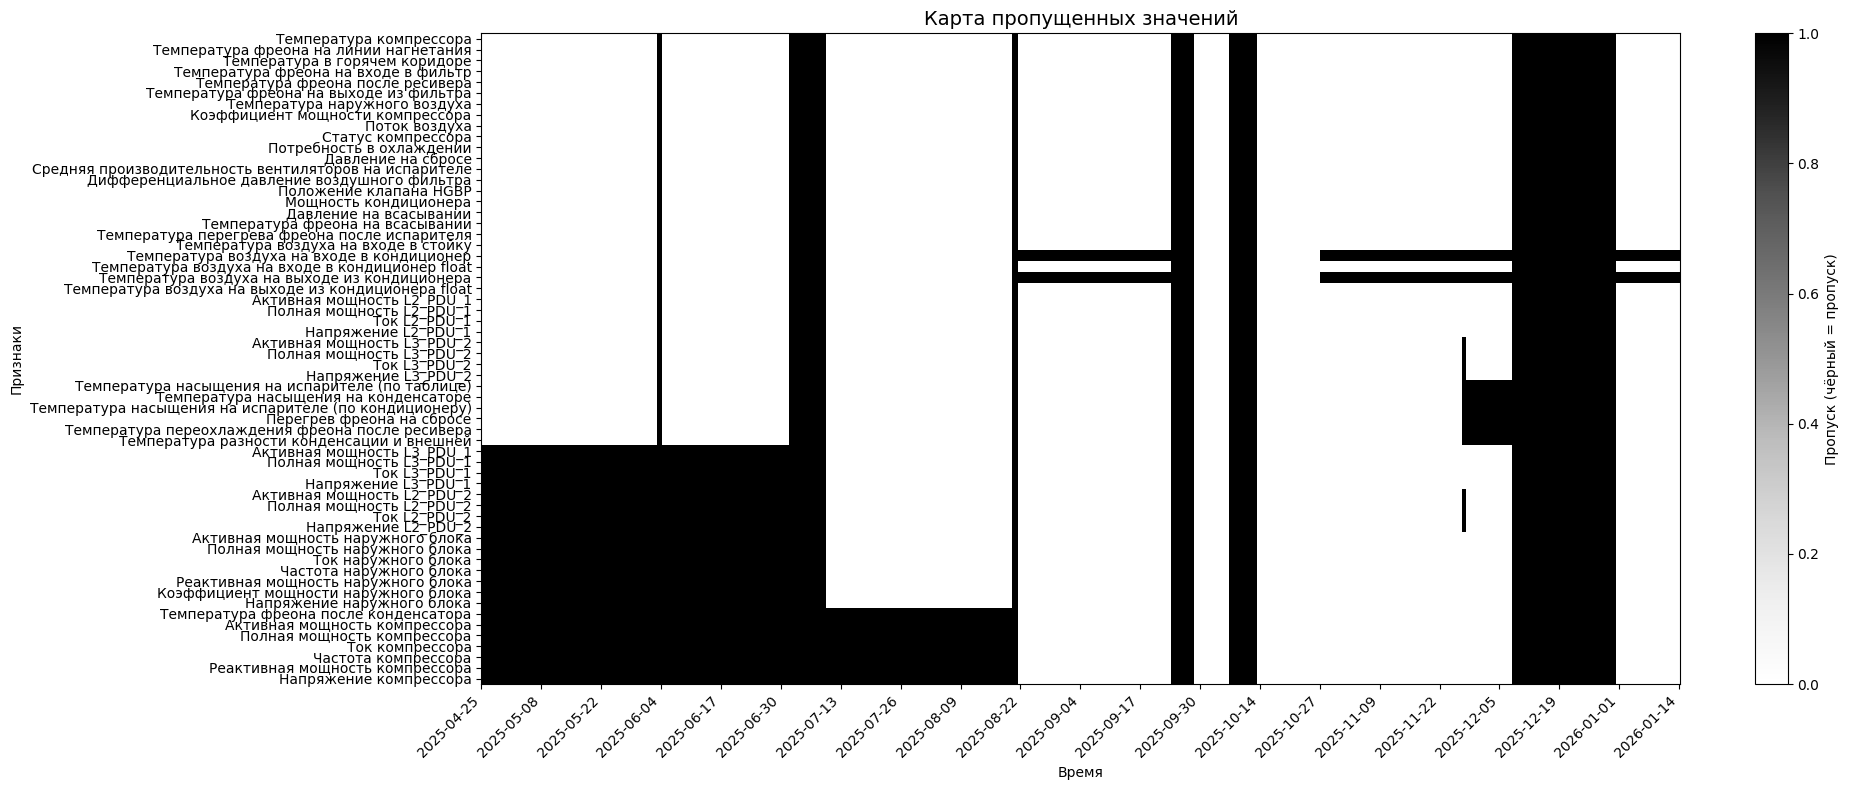

In [ ]:
df['Time'] = pd.to_datetime(df['Time'])
feature_columns = [col for col in df.columns if col not in ['Time', 'label']]

missing_matrix = df[feature_columns].isnull()

missing_matrix_t = missing_matrix.T
date_labels = df['Time'].dt.strftime('%Y-%m-%d').values

plt.figure(figsize=(20, 8))

im = plt.imshow(missing_matrix_t, cmap='Greys', aspect='auto', interpolation='nearest')

n_ticks = min(20, len(date_labels))
step = max(1, len(date_labels) // n_ticks)
tick_positions = np.arange(0, len(date_labels), step)
tick_labels = date_labels[::step]

plt.xticks(tick_positions, tick_labels, rotation=45, ha='right')
plt.yticks(np.arange(len(feature_columns)), feature_columns)

plt.title('Карта пропущенных значений', fontsize=14)
plt.xlabel('Время')
plt.ylabel('Признаки')
plt.colorbar(im, label='Пропуск (чёрный = пропуск)')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

if not pd.api.types.is_datetime64_any_dtype(df['Time']):
    df['Time'] = pd.to_datetime(df['Time'])

df = df.sort_values('Time').reset_index(drop=True)

events = [
    ("adjust1", "2025-04-30 00:00:00", "2025-05-07 17:00:00"),
    ("Normal0", "2025-05-07 17:00:00", "2025-05-17 00:00:00"),
    ("Normal1", "2025-05-17 00:00:00", "2025-06-01 00:00:00"),
    ("Leaky1_begin", "2025-06-04 10:20:00", "2025-06-10 05:50:00"),
    ("Leaky1_adv", "2025-06-10 06:00:00", "2025-06-21 23:50:00"),
    ("Leaky1_disast", "2025-06-22 00:00:00", "2025-07-02 09:20:00"),
    ("Leaky2_begin", "2025-07-10 15:20:00", "2025-07-25 05:50:00"),
    ("Leaky2_adv", "2025-07-25 06:00:00", "2025-08-10 01:50:00"),
    ("Leaky2_disast", "2025-08-10 02:00:00", "2025-08-20 14:30:00"),
    ("Normal3", "2025-08-22 00:00:00", "2025-08-29 11:00:00"),
    ("Leaky3_begin", "2025-08-29 11:10:00", "2025-09-23 09:40:00"),
    ("Leaky3_disast", "2025-09-23 09:50:00", "2025-09-23 12:50:00"),
    ("Normal4", "2025-09-29 15:10:00", "2025-09-30 07:30:00"),
    ("Dirty1_01_05", "2025-09-30 07:40:00", "2025-10-02 17:00:00"),
    ("Dirty1_06_10", "2025-10-02 17:00:00", "2025-10-07 07:30:00"),
    ("Normal5", "2025-10-13 14:10:00", "2025-10-27 10:00:00"),
    ("Dirty2_02", "2025-10-27 10:30:00", "2025-10-30 11:20:00"),
    ("Dirty2_04", "2025-10-30 11:30:00", "2025-11-05 12:50:00"),
    ("Dirty2_06", "2025-11-05 13:00:00", "2025-11-10 10:50:00"),
    ("Dirty2_08", "2025-11-10 11:00:00", "2025-11-13 10:50:00"),
    ("Dirty2_10", "2025-11-13 11:00:00", "2025-11-13 13:00:00"),
    ("Normal6", "2025-11-13 15:00:00", "2025-11-21 19:10:00"),
    ("adjust2", "2025-11-21 19:10:00", "2025-11-28 19:50:00"),
    ("Normal7", "2025-11-28 19:50:00", "2025-12-08 15:00:00"),
    ("Leaky4", "2025-12-10 15:40:00", "2025-12-30 18:00:00"),
    ("Normal8", "2025-12-31 12:00:00", "2026-01-14 16:00:00"),
]

df['label'] = 'Unknown'

for name, start, end in events:
    start_dt = pd.to_datetime(start)
    end_dt = pd.to_datetime(end)
    mask = (df['Time'] >= start_dt) & (df['Time'] <= end_dt)
    label_class = "Normal" if name.startswith("Normal") else "Anomaly"
    df.loc[mask, 'label'] = label_class

print(df['label'].value_counts())


label
Anomaly    7342
Normal     3768
Unknown    1563
Name: count, dtype: int64


In [ ]:
from sklearn.impute import KNNImputer

df = df.sort_values('Time').reset_index(drop=True)
numeric_cols = df.select_dtypes(include=[np.number]).columns
all_nan_mask = df[numeric_cols].isna().all(axis=1)

# удаляем строки, где все признаки NaN
df = df[~all_nan_mask].reset_index(drop=True)

# KNN для остальных строк
imputer = KNNImputer(n_neighbors=5)
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Удаление константных признаков
numeric_cols = df.select_dtypes(include=[np.number]).columns
constant_cols = [col for col in numeric_cols if df[col].nunique() <= 1]
if constant_cols:
    print(f"Удалены константные признаки: {constant_cols}")
    df.drop(columns=constant_cols, inplace=True)

date_train_end = '2025-09-01'
date_val_end = '2025-10-01'

train_df = df[df['Time'] < date_train_end].copy()
val_df = df[(df['Time'] >= date_train_end) & (df['Time'] < date_val_end)].copy()
test_df = df[df['Time'] >= date_val_end].copy()

print(f"Train size: {len(train_df)}")
print(f"Val size:   {len(val_df)}")
print(f"Test size:  {len(test_df)}")

# Подготовка признаков и меток
feature_cols = [col for col in df.columns if col not in ['Time', 'label']]

X_train = train_df[feature_cols]
y_train = train_df['label']

X_val = val_df[feature_cols]
y_val = val_df['label']

X_test = test_df[feature_cols]
y_test = test_df['label']

# Z-Нормализация
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=feature_cols, index=X_val.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_cols, index=X_test.index)

print(f"X_train shape: {X_train_scaled.shape}")
print(f"X_val shape:   {X_val_scaled.shape}")
print(f"X_test shape:  {X_test_scaled.shape}")

Train size: 5652
Val size:   1195
Test size:  3673
X_train shape: (5652, 60)
X_val shape:   (1195, 60)
X_test shape:  (3673, 60)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import VarianceThreshold

print("=" * 60)
print("ОТБОР ПРИЗНАКОВ (Variance + Correlation)")
print("=" * 60)

# ── Удаление низкодисперсных признаков ────────────────────────────────

var_selector = VarianceThreshold(threshold=0.01)
var_selector.fit(X_train_scaled)

# Получаем булеву маску: True - оставить, False - удалить
var_mask = var_selector.get_support()

# Список имен признаков, которые прошли отбор по дисперсии
cols_after_var = [col for col, keep in zip(feature_cols, var_mask) if keep]
removed_var_count = len(feature_cols) - len(cols_after_var)

print(f"\nУдалено низкодисперсных признаков: {removed_var_count}")
if removed_var_count > 0:
    removed_list = [col for col, keep in zip(feature_cols, var_mask) if not keep]
    print(f"    Примеры удаленных: {removed_list[:5]}...") # Показываем первые 5 для краткости

# ── Удаление мультиколлинеарных признаков ─────────────────────────────
# Работаем только с признаками, оставшимися после Шага 1
df_subset = X_train_scaled[cols_after_var]
corr_matrix = df_subset.corr().abs()

# Находим признаки для удаления на основе верхней треугольной матрицы
upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Порог корреляции
CORR_THRESHOLD = 0.90

# Выбираем столбцы, где есть корреляция выше порога
to_drop_corr = [column for column in upper_tri.columns if any(upper_tri[column] > CORR_THRESHOLD)]

cols_after_corr = [col for col in cols_after_var if col not in to_drop_corr]

print(f"\nУдалено мультиколлинеарных признаков (порог > {CORR_THRESHOLD}): {len(to_drop_corr)}")
if to_drop_corr:
    print(f"    Примеры удаленных: {to_drop_corr[:5]}...")

# ── Итоговый список признаков ────────────────────────────────────────────────
selected_channels = cols_after_corr

print(f"\nИтого отобрано признаков: {len(selected_channels)} "
      f"из исходных {len(feature_cols)}")
print(f"Сохранено информации: {(len(selected_channels)/len(feature_cols))*100:.1f}%")

# ── Применяем отбор к train / val / test ─────────────────────────────────────
# Проверка на случай, если список пуст (редкий кейс, но возможный)
if not selected_channels:
    raise ValueError("Все признаки были удалены в процессе отбора!")

X_train_selected = X_train_scaled[selected_channels]
X_val_selected   = X_val_scaled[selected_channels]
X_test_selected  = X_test_scaled[selected_channels]

print(f"\nФинальные размерности:")
print(f"  X_train: {X_train_selected.shape}")
print(f"  X_val:   {X_val_selected.shape}")
print(f"  X_test:  {X_test_selected.shape}")
print("=" * 60)

ОТБОР ПРИЗНАКОВ (Variance + Correlation)

[1] Удалено низкодисперсных признаков: 0

[2] Удалено мультиколлинеарных признаков (порог > 0.9): 31
    Примеры удаленных: ['Статус компрессора', 'Средняя производительность вентиляторов на испарителе', 'Мощность кондиционера', 'Давление на всасывании', 'Температура фреона на всасывании']...

Итого отобрано признаков: 29 из исходных 60
Сохранено информации: 48.3%

Финальные размерности:
  X_train: (5652, 29)
  X_val:   (1195, 29)
  X_test:  (3673, 29)


In [ ]:
print(f"\nСписок оставшихся признаков ({len(selected_channels)} шт.):")
print(selected_channels)


Список оставшихся признаков (29 шт.):
['Температура компрессора', 'Температура фреона на линии нагнетания', 'Температура в горячем коридоре', 'Температура фреона на входе в фильтр', 'Температура фреона после ресивера', 'Температура фреона на выходе из фильтра', 'Температура наружного воздуха', 'Коэффициент мощности компрессора', 'Поток воздуха', 'Потребность в охлаждении', 'Давление на сбросе', 'Дифференциальное давление воздушного фильтра', 'Положение клапана HGBP', 'Температура воздуха на входе в кондиционер', 'Температура воздуха на входе в кондиционер float', 'Активная мощность L2_PDU_1', 'Напряжение L2_PDU_1', 'Активная мощность L3_PDU_2', 'Напряжение L3_PDU_2', 'Температура переохлаждения фреона после ресивера', 'Активная мощность L3_PDU_1', 'Напряжение L3_PDU_1', 'Активная мощность L2_PDU_2', 'Напряжение L2_PDU_2', 'Активная мощность наружного блока', 'Частота наружного блока', 'Температура фреона после конденсатора', 'Активная мощность компрессора', 'Реактивная мощность компре

# Семейство MP

## На смешенном датасете (29 признаков)


STOMP
▶ STOMP | per-channel
  Признаков: 29
    tune→ m=48 (1.0 сут), MCC_val=0.0757
  m=48  MCC=0.0373  F1=0.4982  AUC=0.5102  thr=0.9525
▶ STOMP | PCA
  Признаков: 29
    tune→ m=48 (1.0 сут), MCC_val=0.0226
  m=48  MCC=0.1456  F1=0.1622  AUC=0.5647  thr=0.9944
▶ STOMP | UMAP
  Признаков: 29
    tune→ m=96 (2.0 сут), MCC_val=0.0735
  m=96  MCC=0.1157  F1=0.5637  AUC=0.5587  thr=0.0123
▶ STOMP | AE
  Признаков: 29
AE обучён за 14.5 сек (hidden=9)
    tune→ m=96 (2.0 сут), MCC_val=0.2547
  m=96  MCC=0.0411  F1=0.2373  AUC=0.4781  thr=0.8414

DAMP 2.0  (stride=1, lookahead=0)
Пул окон DAMP (клип 11–1000): [48, 96, 144, 240, 336, 480, 672, 1000]
▶ DAMP | per-channel
  Признаков: 29
    tune→ m=240 (5.0 сут), MCC_val=0.0000
  m=240  MCC=0.1849  F1=0.5158  AUC=0.5867  thr=0.9959
▶ DAMP | PCA
  Признаков: 29
    tune→ m=240 (5.0 сут), MCC_val=0.0000
  m=240  MCC=0.0895  F1=0.5065  AUC=0.4792  thr=0.7030
▶ DAMP | UMAP
  Признаков: 29
    tune→ m=48 (1.0 сут), MCC_val=0.0534
  m=48  MCC=0.04

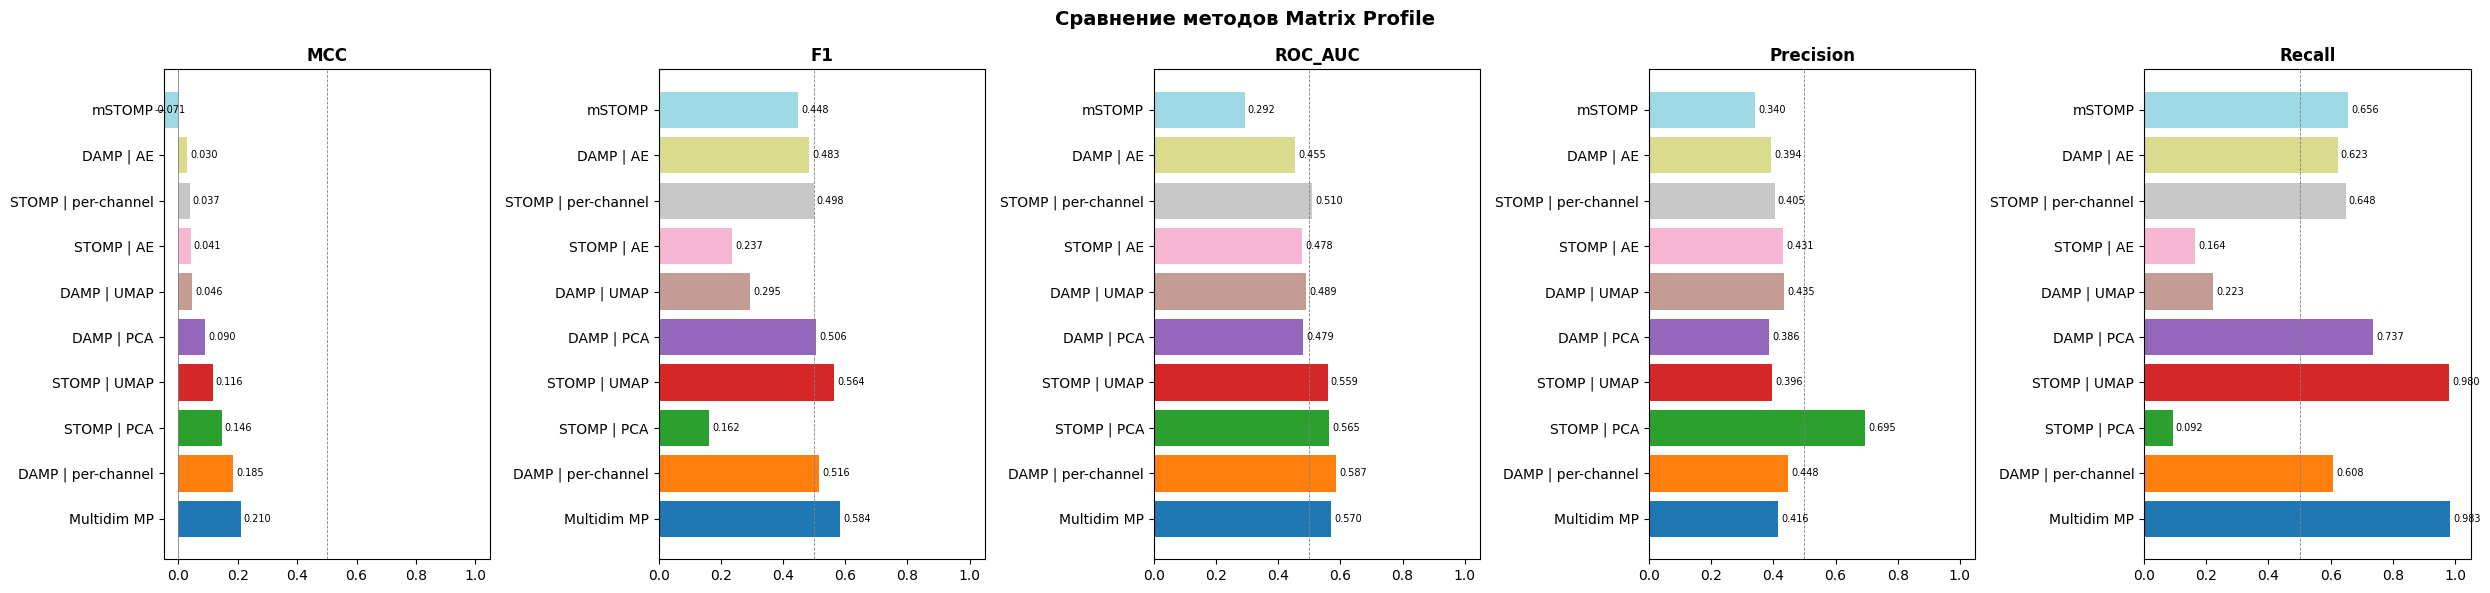

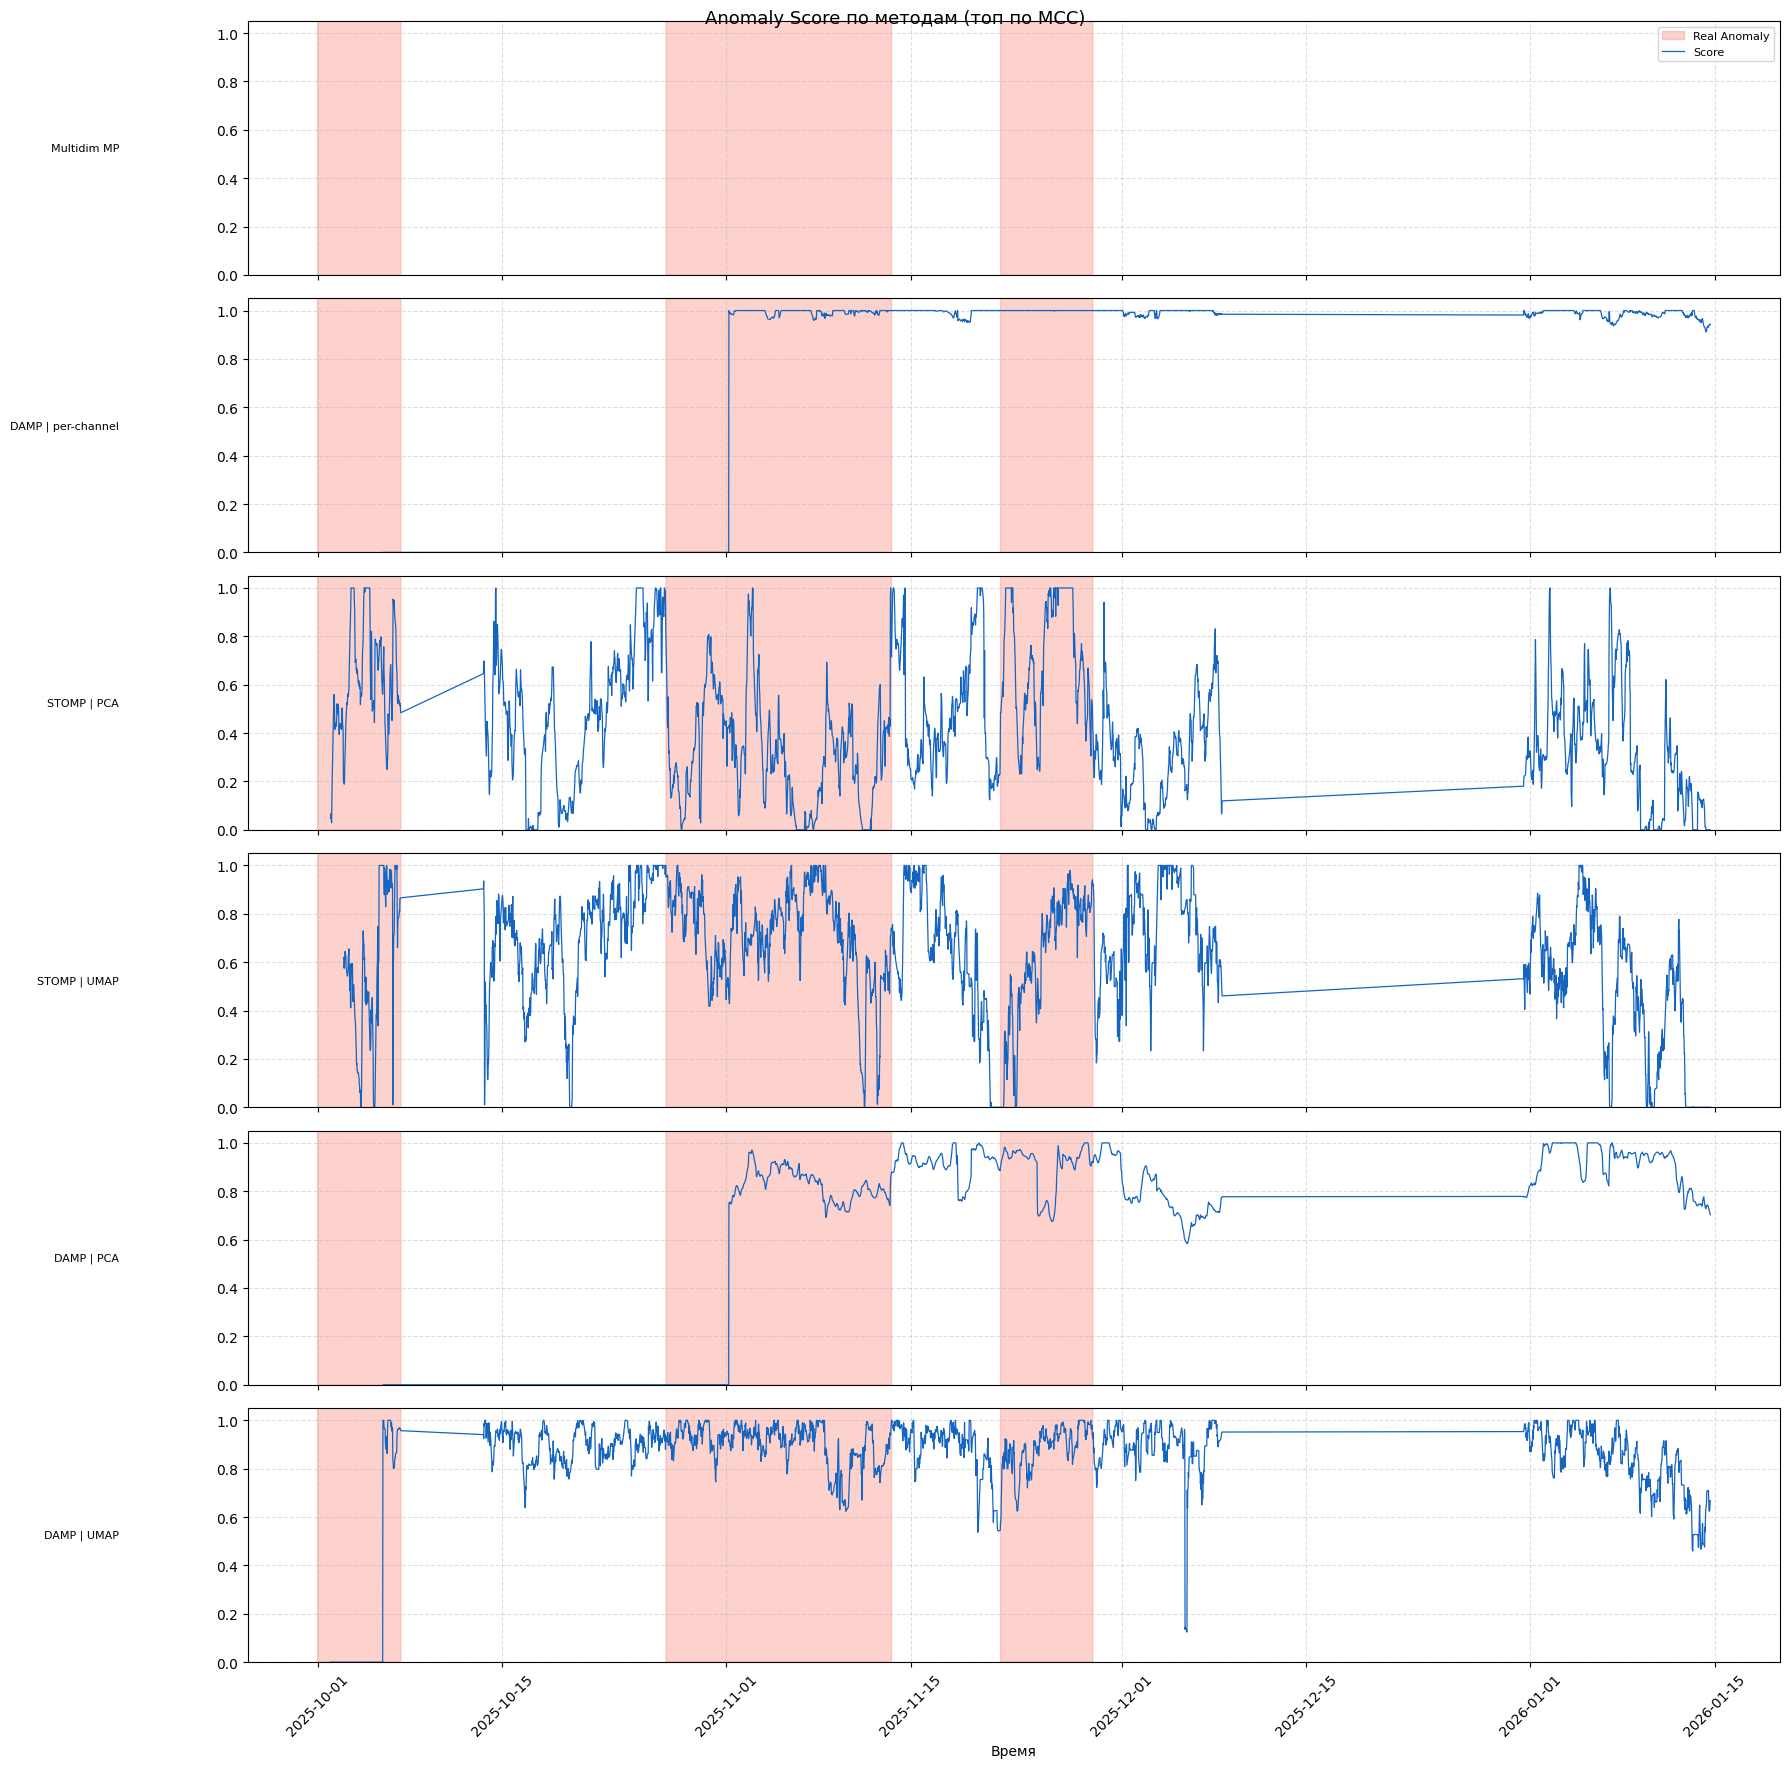

In [ ]:
# ─── Импорты ───────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import stumpy
from sklearn.decomposition import PCA
from sklearn.metrics import (
    matthews_corrcoef, f1_score, roc_auc_score,
    precision_score, recall_score, confusion_matrix, roc_curve
)

try:
    import umap as umap_lib
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False

try:
    import torch
    import torch.nn as nn
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False


# ─── Глобальные параметры ──────────────────────────────────────────────────
WINDOWS = [672]
RANDOM_STATE = 42
STEP_MINUTES = 30.0

import random

def fix_randomness(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    if TORCH_AVAILABLE:
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed(seed)
            torch.cuda.manual_seed_all(seed)
            torch.backends.cudnn.deterministic = True
            torch.backends.cudnn.benchmark = False

fix_randomness(RANDOM_STATE)

BEST_FEATURES = {
    "STOMP | per-channel": [
         'Температура компрессора', 'Температура фреона на линии нагнетания',
         'Температура в горячем коридоре', 'Температура фреона на входе в фильтр',
         'Температура фреона после ресивера', 'Температура фреона на выходе из фильтра',
         'Температура наружного воздуха', 'Коэффициент мощности компрессора',
         'Поток воздуха', 'Потребность в охлаждении', 'Давление на сбросе',
         'Дифференциальное давление воздушного фильтра', 'Положение клапана HGBP',
         'Температура воздуха на входе в кондиционер',
         'Температура воздуха на входе в кондиционер float', 'Активная мощность L2_PDU_1',
         'Напряжение L2_PDU_1', 'Активная мощность L3_PDU_2', 'Напряжение L3_PDU_2',
         'Температура переохлаждения фреона после ресивера', 'Активная мощность L3_PDU_1',
         'Напряжение L3_PDU_1', 'Активная мощность L2_PDU_2', 'Напряжение L2_PDU_2',
         'Активная мощность наружного блока', 'Частота наружного блока',
         'Температура фреона после конденсатора',
         'Активная мощность компрессора', 'Реактивная мощность компрессора'

    ],
    "STOMP | PCA": [
        'Температура компрессора', 'Температура фреона на линии нагнетания',
         'Температура в горячем коридоре', 'Температура фреона на входе в фильтр',
         'Температура фреона после ресивера', 'Температура фреона на выходе из фильтра',
         'Температура наружного воздуха', 'Коэффициент мощности компрессора',
         'Поток воздуха', 'Потребность в охлаждении', 'Давление на сбросе',
         'Дифференциальное давление воздушного фильтра', 'Положение клапана HGBP',
         'Температура воздуха на входе в кондиционер',
         'Температура воздуха на входе в кондиционер float', 'Активная мощность L2_PDU_1',
         'Напряжение L2_PDU_1', 'Активная мощность L3_PDU_2', 'Напряжение L3_PDU_2',
         'Температура переохлаждения фреона после ресивера', 'Активная мощность L3_PDU_1',
         'Напряжение L3_PDU_1', 'Активная мощность L2_PDU_2', 'Напряжение L2_PDU_2',
         'Активная мощность наружного блока', 'Частота наружного блока',
         'Температура фреона после конденсатора',
         'Активная мощность компрессора', 'Реактивная мощность компрессора'
    ],
    "STOMP | UMAP": [
        'Температура компрессора', 'Температура фреона на линии нагнетания',
         'Температура в горячем коридоре', 'Температура фреона на входе в фильтр',
         'Температура фреона после ресивера', 'Температура фреона на выходе из фильтра',
         'Температура наружного воздуха', 'Коэффициент мощности компрессора',
         'Поток воздуха', 'Потребность в охлаждении', 'Давление на сбросе',
         'Дифференциальное давление воздушного фильтра', 'Положение клапана HGBP',
         'Температура воздуха на входе в кондиционер',
         'Температура воздуха на входе в кондиционер float', 'Активная мощность L2_PDU_1',
         'Напряжение L2_PDU_1', 'Активная мощность L3_PDU_2', 'Напряжение L3_PDU_2',
         'Температура переохлаждения фреона после ресивера', 'Активная мощность L3_PDU_1',
         'Напряжение L3_PDU_1', 'Активная мощность L2_PDU_2', 'Напряжение L2_PDU_2',
         'Активная мощность наружного блока', 'Частота наружного блока',
         'Температура фреона после конденсатора',
         'Активная мощность компрессора', 'Реактивная мощность компрессора'
    ],
    "STOMP | AE": [
        'Температура компрессора', 'Температура фреона на линии нагнетания',
         'Температура в горячем коридоре', 'Температура фреона на входе в фильтр',
         'Температура фреона после ресивера', 'Температура фреона на выходе из фильтра',
         'Температура наружного воздуха', 'Коэффициент мощности компрессора',
         'Поток воздуха', 'Потребность в охлаждении', 'Давление на сбросе',
         'Дифференциальное давление воздушного фильтра', 'Положение клапана HGBP',
         'Температура воздуха на входе в кондиционер',
         'Температура воздуха на входе в кондиционер float', 'Активная мощность L2_PDU_1',
         'Напряжение L2_PDU_1', 'Активная мощность L3_PDU_2', 'Напряжение L3_PDU_2',
         'Температура переохлаждения фреона после ресивера', 'Активная мощность L3_PDU_1',
         'Напряжение L3_PDU_1', 'Активная мощность L2_PDU_2', 'Напряжение L2_PDU_2',
         'Активная мощность наружного блока', 'Частота наружного блока',
         'Температура фреона после конденсатора',
         'Активная мощность компрессора', 'Реактивная мощность компрессора'

    ],
    "DAMP | per-channel": [
        'Температура компрессора', 'Температура фреона на линии нагнетания',
         'Температура в горячем коридоре', 'Температура фреона на входе в фильтр',
         'Температура фреона после ресивера', 'Температура фреона на выходе из фильтра',
         'Температура наружного воздуха', 'Коэффициент мощности компрессора',
         'Поток воздуха', 'Потребность в охлаждении', 'Давление на сбросе',
         'Дифференциальное давление воздушного фильтра', 'Положение клапана HGBP',
         'Температура воздуха на входе в кондиционер',
         'Температура воздуха на входе в кондиционер float', 'Активная мощность L2_PDU_1',
         'Напряжение L2_PDU_1', 'Активная мощность L3_PDU_2', 'Напряжение L3_PDU_2',
         'Температура переохлаждения фреона после ресивера', 'Активная мощность L3_PDU_1',
         'Напряжение L3_PDU_1', 'Активная мощность L2_PDU_2', 'Напряжение L2_PDU_2',
         'Активная мощность наружного блока', 'Частота наружного блока',
         'Температура фреона после конденсатора',
         'Активная мощность компрессора', 'Реактивная мощность компрессора'
    ],
    "DAMP | PCA": [
         'Температура компрессора', 'Температура фреона на линии нагнетания',
         'Температура в горячем коридоре', 'Температура фреона на входе в фильтр',
         'Температура фреона после ресивера', 'Температура фреона на выходе из фильтра',
         'Температура наружного воздуха', 'Коэффициент мощности компрессора',
         'Поток воздуха', 'Потребность в охлаждении', 'Давление на сбросе',
         'Дифференциальное давление воздушного фильтра', 'Положение клапана HGBP',
         'Температура воздуха на входе в кондиционер',
         'Температура воздуха на входе в кондиционер float', 'Активная мощность L2_PDU_1',
         'Напряжение L2_PDU_1', 'Активная мощность L3_PDU_2', 'Напряжение L3_PDU_2',
         'Температура переохлаждения фреона после ресивера', 'Активная мощность L3_PDU_1',
         'Напряжение L3_PDU_1', 'Активная мощность L2_PDU_2', 'Напряжение L2_PDU_2',
         'Активная мощность наружного блока', 'Частота наружного блока',
         'Температура фреона после конденсатора',
         'Активная мощность компрессора', 'Реактивная мощность компрессора'
    ],
    "DAMP | UMAP": [
         'Температура компрессора', 'Температура фреона на линии нагнетания',
         'Температура в горячем коридоре', 'Температура фреона на входе в фильтр',
         'Температура фреона после ресивера', 'Температура фреона на выходе из фильтра',
         'Температура наружного воздуха', 'Коэффициент мощности компрессора',
         'Поток воздуха', 'Потребность в охлаждении', 'Давление на сбросе',
         'Дифференциальное давление воздушного фильтра', 'Положение клапана HGBP',
         'Температура воздуха на входе в кондиционер',
         'Температура воздуха на входе в кондиционер float', 'Активная мощность L2_PDU_1',
         'Напряжение L2_PDU_1', 'Активная мощность L3_PDU_2', 'Напряжение L3_PDU_2',
         'Температура переохлаждения фреона после ресивера', 'Активная мощность L3_PDU_1',
         'Напряжение L3_PDU_1', 'Активная мощность L2_PDU_2', 'Напряжение L2_PDU_2',
         'Активная мощность наружного блока', 'Частота наружного блока',
         'Температура фреона после конденсатора',
         'Активная мощность компрессора', 'Реактивная мощность компрессора'
    ],
    "DAMP | AE": [
         'Температура компрессора', 'Температура фреона на линии нагнетания',
         'Температура в горячем коридоре', 'Температура фреона на входе в фильтр',
         'Температура фреона после ресивера', 'Температура фреона на выходе из фильтра',
         'Температура наружного воздуха', 'Коэффициент мощности компрессора',
         'Поток воздуха', 'Потребность в охлаждении', 'Давление на сбросе',
         'Дифференциальное давление воздушного фильтра', 'Положение клапана HGBP',
         'Температура воздуха на входе в кондиционер',
         'Температура воздуха на входе в кондиционер float', 'Активная мощность L2_PDU_1',
         'Напряжение L2_PDU_1', 'Активная мощность L3_PDU_2', 'Напряжение L3_PDU_2',
         'Температура переохлаждения фреона после ресивера', 'Активная мощность L3_PDU_1',
         'Напряжение L3_PDU_1', 'Активная мощность L2_PDU_2', 'Напряжение L2_PDU_2',
         'Активная мощность наружного блока', 'Частота наружного блока',
         'Температура фреона после конденсатора',
         'Активная мощность компрессора', 'Реактивная мощность компрессора'
    ],
    "mSTOMP": [
         'Температура компрессора', 'Температура фреона на линии нагнетания',
         'Температура в горячем коридоре', 'Температура фреона на входе в фильтр',
         'Температура фреона после ресивера', 'Температура фреона на выходе из фильтра',
         'Температура наружного воздуха', 'Коэффициент мощности компрессора',
         'Поток воздуха', 'Потребность в охлаждении', 'Давление на сбросе',
         'Дифференциальное давление воздушного фильтра', 'Положение клапана HGBP',
         'Температура воздуха на входе в кондиционер',
         'Температура воздуха на входе в кондиционер float', 'Активная мощность L2_PDU_1',
         'Напряжение L2_PDU_1', 'Активная мощность L3_PDU_2', 'Напряжение L3_PDU_2',
         'Температура переохлаждения фреона после ресивера', 'Активная мощность L3_PDU_1',
         'Напряжение L3_PDU_1', 'Активная мощность L2_PDU_2', 'Напряжение L2_PDU_2',
         'Активная мощность наружного блока', 'Частота наружного блока',
         'Температура фреона после конденсатора',
         'Активная мощность компрессора', 'Реактивная мощность компрессора'
    ],
    "Multidim MP": [
         'Температура компрессора', 'Температура фреона на линии нагнетания',
         'Температура в горячем коридоре', 'Температура фреона на входе в фильтр',
         'Температура фреона после ресивера', 'Температура фреона на выходе из фильтра',
         'Температура наружного воздуха', 'Коэффициент мощности компрессора',
         'Поток воздуха', 'Потребность в охлаждении', 'Давление на сбросе',
         'Дифференциальное давление воздушного фильтра', 'Положение клапана HGBP',
         'Температура воздуха на входе в кондиционер',
         'Температура воздуха на входе в кондиционер float', 'Активная мощность L2_PDU_1',
         'Напряжение L2_PDU_1', 'Активная мощность L3_PDU_2', 'Напряжение L3_PDU_2',
         'Температура переохлаждения фреона после ресивера', 'Активная мощность L3_PDU_1',
         'Напряжение L3_PDU_1', 'Активная мощность L2_PDU_2', 'Напряжение L2_PDU_2',
         'Активная мощность наружного блока', 'Частота наружного блока',
         'Температура фреона после конденсатора',
         'Активная мощность компрессора', 'Реактивная мощность компрессора'
    ],
}


def select_features(df: pd.DataFrame, feature_list: list) -> pd.DataFrame:
    available = [f for f in feature_list if f in df.columns]
    missing   = [f for f in feature_list if f not in df.columns]
    if missing:
        print(f"   Признаки не найдены и пропущены: {missing}")
    return df[available]


# ─── Вспомогательные функции ───────────────────────────────────────────────

def binary_labels(y: pd.Series) -> np.ndarray:
    """'Anomaly' → 1, 'Normal' → 0"""
    return (y == "Anomaly").astype(int).values


def robust_normalize(s: np.ndarray) -> np.ndarray:
    s = np.array(s, dtype=np.float64)
    s[np.isinf(s)] = np.nan
    if np.all(np.isnan(s)):
        return np.zeros_like(s)
    q_low  = np.nanpercentile(s, 5)
    q_high = np.nanpercentile(s, 95)
    if q_high - q_low < 1e-12:
        return np.zeros_like(s)
    s = (s - q_low) / (q_high - q_low)
    return np.clip(s, 0.0, 1.0)


def multiscale_max(profiles: list) -> np.ndarray:
    normed = [robust_normalize(p) for p in profiles]
    return np.nanmax(np.stack(normed, axis=0), axis=0)


def pad_profile(mp_raw: np.ndarray, n_total: int) -> np.ndarray:
    pad = n_total - len(mp_raw)
    if pad < 0:
        return mp_raw[-pad:]
    return np.concatenate([np.full(pad, np.nan), mp_raw])


def moving_average(x: np.ndarray, window: int = 5) -> np.ndarray:
    """
    Скользящее среднее для пост-обработки профиля аномалий.
    Статья (табл. V): moving average улучшает AUC-PTRT.
    NaN-значения игнорируются при усреднении.
    """
    if window <= 1:
        return x.copy()
    out = np.full_like(x, np.nan, dtype=np.float64)
    for i in range(len(x)):
        lo = max(0, i - window // 2)
        hi = min(len(x), i + window // 2 + 1)
        segment = x[lo:hi]
        valid = segment[~np.isnan(segment)]
        if len(valid) > 0:
            out[i] = valid.mean()
    return out


def optimal_threshold_mcc(y_true: np.ndarray,
                           y_score: np.ndarray) -> tuple:
    mask = ~np.isnan(y_score)
    yt = y_true[mask]
    ys = y_score[mask]

    if len(np.unique(yt)) < 2 or len(np.unique(ys)) < 2:
        fallback_t = float(np.nanmedian(ys)) if len(ys) > 0 else 0.5
        return fallback_t, 0.0, np.array([0, 1]), np.array([0, 1]), np.array([fallback_t])

    fpr, tpr, thresholds = roc_curve(yt, ys)

    finite_mask = np.isfinite(thresholds)
    if not finite_mask.any():
        fallback_t = float(np.nanmedian(ys))
        return fallback_t, 0.0, fpr, tpr, thresholds

    thresholds_f = thresholds[finite_mask]
    best_mcc = -2.0
    best_t   = float(np.nanmedian(thresholds_f))

    for t in thresholds_f:
        pred = (ys >= t).astype(int)
        if pred.sum() == 0 or pred.sum() == len(pred):
            continue
        mcc = matthews_corrcoef(yt, pred)
        if mcc > best_mcc:
            best_mcc = mcc
            best_t   = t

    return best_t, best_mcc, fpr, tpr, thresholds


def compute_metrics(y_true: np.ndarray,
                    y_score_full: np.ndarray,
                    train_sec: float = 0.0,
                    infer_sec: float = 0.0,
                    step_minutes: float = STEP_MINUTES) -> dict:
    mask   = ~np.isnan(y_score_full)
    yt     = y_true[mask]
    ys     = y_score_full[mask]

    best_t, _, fpr_arr, tpr_arr, _ = optimal_threshold_mcc(yt, ys)
    y_pred = (ys >= best_t).astype(int)

    tn, fp, fn, tp = confusion_matrix(yt, y_pred, labels=[0, 1]).ravel()

    try:
        roc_auc = roc_auc_score(yt, ys)
    except Exception:
        roc_auc = float("nan")

    delay = compute_delay(yt, y_pred, step_minutes)

    return {
        "MCC":       matthews_corrcoef(yt, y_pred),
        "F1":        f1_score(yt, y_pred, zero_division=0),
        "ROC_AUC":   roc_auc,
        "Precision": precision_score(yt, y_pred, zero_division=0),
        "Recall":    recall_score(yt, y_pred, zero_division=0),
        "TP_rate":   tp / (tp + fn) if (tp + fn) > 0 else 0.0,
        "FP_rate":   fp / (fp + tn) if (fp + tn) > 0 else 0.0,
        "TN_rate":   tn / (tn + fp) if (tn + fp) > 0 else 0.0,
        "FN_rate":   fn / (fn + tp) if (fn + tp) > 0 else 0.0,
        "threshold": best_t,
        "Train_sec": train_sec,
        "Infer_sec": infer_sec,
        "Delay_min": delay,
        "_y_pred":   y_pred,
        "_y_score":  ys,
        "_mask":     mask,
    }


def compute_delay(y_true: np.ndarray, y_pred: np.ndarray,
                  step_minutes: float = STEP_MINUTES) -> float:
    delays = []
    in_anomaly  = False
    seg_start   = 0
    tp_found    = False

    for i in range(len(y_true)):
        if y_true[i] == 1 and not in_anomaly:
            in_anomaly = True
            seg_start  = i
            tp_found   = False
        if in_anomaly and not tp_found and y_pred[i] == 1:
            delays.append((i - seg_start) * step_minutes)
            tp_found = True
        if y_true[i] == 0:
            in_anomaly = False

    return float(np.mean(delays)) if delays else float("nan")


# ─── Стратегии редукции размерности ───────────────────────────────────────

class _PCAReducer:
    def fit(self, X_train):
        n_comp = min(5, X_train.shape[1])
        t0 = time.perf_counter()
        self.pca = PCA(n_components=n_comp, random_state=RANDOM_STATE)
        self.pca.fit(X_train)
        return time.perf_counter() - t0

    def transform(self, X):
        return np.mean(self.pca.transform(X), axis=1)


class _UMAPReducer:
    def fit(self, X_train):
        if not UMAP_AVAILABLE:
            raise ImportError("pip install umap-learn")
        t0 = time.perf_counter()
        self.reducer = umap_lib.UMAP(n_components=2, n_neighbors=15,
                                      min_dist=0.1, random_state=RANDOM_STATE)
        self.reducer.fit(X_train)
        return time.perf_counter() - t0

    def transform(self, X):
        return np.linalg.norm(self.reducer.transform(X), axis=1)


class _AEReducer:
    def fit(self, X_train):
        if not TORCH_AVAILABLE:
            raise ImportError("pip install torch")

        d      = X_train.shape[1]
        hidden = max(8, d // 3)

        class SimpleAE(nn.Module):
            def __init__(self):
                super().__init__()
                self.encoder = nn.Linear(d, hidden)
                self.decoder = nn.Linear(hidden, d)
            def forward(self, x):
                return self.decoder(torch.relu(self.encoder(x)))

        self.model = SimpleAE()
        optimizer  = torch.optim.Adam(self.model.parameters(), lr=0.0005)
        loss_fn    = nn.MSELoss()

        X_t     = torch.tensor(X_train, dtype=torch.float32)
        dataset = torch.utils.data.TensorDataset(X_t)

        generator = torch.Generator()
        generator.manual_seed(RANDOM_STATE)

        loader = torch.utils.data.DataLoader(
            dataset, batch_size=64, shuffle=True, generator=generator)

        t0 = time.perf_counter()
        self.model.train()
        for epoch in range(200):
            for (batch,) in loader:
                optimizer.zero_grad()
                loss = loss_fn(self.model(batch), batch)
                loss.backward()
                optimizer.step()
        self.model.eval()

        fit_sec = time.perf_counter() - t0
        print(f"AE обучён за {fit_sec:.1f} сек (hidden={hidden})")
        return fit_sec

    def transform(self, X):
        with torch.no_grad():
            X_t           = torch.tensor(X, dtype=torch.float32)
            reconstructed = self.model(X_t).numpy()
        return np.mean((X - reconstructed) ** 2, axis=1)


# ─── Вычисление профилей ───────────────────────────────────────────────────

def _extract_mp_values(mp_obj) -> np.ndarray:
    col = mp_obj[:, 0]
    if col.dtype.names is not None:
        col = col[col.dtype.names[0]]
    return np.array(col, dtype=np.float64)


def stomp_profiles(ts: np.ndarray, windows: list) -> list:
    result = []
    ts_f = np.asarray(ts, dtype=np.float64)
    for m in windows:
        if len(ts_f) <= m:
            print(f"   Пропущено окно m={m}: ряд слишком короткий ({len(ts_f)})")
            continue
        mp_raw = _extract_mp_values(stumpy.stump(ts_f, m=m))
        mp_raw[np.isinf(mp_raw)] = np.nan
        result.append((m, mp_raw))
    return result


def _mass_v2(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    m = len(y)
    n = len(x)

    if n < m:
        return np.array([np.inf])

    meany  = np.mean(y)
    sigmay = np.std(y)

    if sigmay < 1e-10:
        return np.full(n - m + 1, 0.0)

    x_prefix  = x[: m - 1]
    divider   = np.arange(1, len(x_prefix) + 1, dtype=np.float64)
    cumsum_   = x_prefix.cumsum()
    sq_cumsum = (x_prefix ** 2).cumsum()
    mean_prefix = cumsum_ / divider
    std_prefix  = np.sqrt(
        np.maximum((sq_cumsum - cumsum_ ** 2 / divider) / divider, 0.0))

    windows    = np.lib.stride_tricks.sliding_window_view(x, m)
    mean_full  = windows.mean(axis=1)
    std_full   = windows.std(axis=1)

    meanx  = np.concatenate([mean_prefix, mean_full])
    sigmax = np.concatenate([std_prefix,  std_full])

    y_rev = np.concatenate((y[::-1], np.zeros(n - m)))
    z     = np.fft.ifft(np.fft.fft(x) * np.fft.fft(y_rev)).real

    denom = sigmax[m - 1 : n] * sigmay
    denom = np.where(denom < 1e-10, 1e-10, denom)
    dist  = 2 * (m - (z[m - 1 : n] - m * meanx[m - 1 : n] * meany) / denom)
    return np.sqrt(np.maximum(dist, 0.0))


def _nextpow2(x: int) -> float:
    return np.ceil(np.log2(abs(x)))


def _damp_2_0(time_series: np.ndarray,
              subsequence_length: int,
              stride: int = 1,
              location_to_start_processing: int = None,
              lookahead: int = 0) -> np.ndarray:
    ts  = np.asarray(time_series, dtype=np.float64)
    n   = len(ts)
    m   = subsequence_length

    if location_to_start_processing is None:
        location_to_start_processing = max(m, 4 * m)

    if lookahead is None:
        lookahead = int(2 ** _nextpow2(16 * m))
    elif (lookahead != 0) and (lookahead != 2 ** _nextpow2(lookahead)):
        lookahead = int(2 ** _nextpow2(lookahead))

    if (location_to_start_processing / m) < 4:
        if location_to_start_processing < m:
            location_to_start_processing = m
    else:
        if location_to_start_processing > (n - m + 1):
            location_to_start_processing = n - m + 1

    left_mp     = np.zeros(n, dtype=np.float64)
    best_so_far = -np.inf
    bool_vec    = np.ones(n, dtype=np.float64)

    loc = location_to_start_processing

    # ── Prefix-цикл ───────────────────────────────────────────────────────────
    for i in range(loc - 1, loc + 16 * m, stride):
        if not bool_vec[i]:
            left_mp[i] = left_mp[i - 1] - 1e-05
            continue

        if i + m - 1 > n:
            break

        query = ts[i : i + m]
        left_mp[i] = np.amin(_mass_v2(ts[:i], query)) if i > 0 else 0.0

        best_so_far = np.amax(left_mp)

        if lookahead != 0:
            start_of_mass = min(i + m - 1, n)
            end_of_mass   = min(start_of_mass + lookahead - 1, n)
            if (end_of_mass - start_of_mass + 1) > m:
                dp  = _mass_v2(ts[start_of_mass : end_of_mass + 1], query)
                bad = np.where(dp < best_so_far)[0] + start_of_mass
                bool_vec[bad] = 0

    # ── Основной цикл ─────────────────────────────────────────────────────────
    for i in range(loc + 16 * m, n - m + 1, stride):
        if not bool_vec[i]:
            left_mp[i] = left_mp[i - 1] - 1e-05
            continue

        if i + m - 1 > n:
            break

        query         = ts[i : i + m]
        approx_dist   = np.inf
        X             = int(2 ** _nextpow2(8 * m))
        flag          = 1
        expansion_num = 0

        while approx_dist >= best_so_far:
            if i - X + 1 + expansion_num * m < 1:
                approx_dist = np.amin(_mass_v2(ts[: i + 1], query))
                left_mp[i]  = approx_dist
                if approx_dist > best_so_far:
                    best_so_far = approx_dist
                break

            if flag == 1:
                flag        = 0
                approx_dist = np.amin(_mass_v2(ts[i - X + 1 : i + 1], query))
            else:
                X_start     = i - X + 1 + expansion_num * m
                X_end       = i - X // 2 + expansion_num * m
                approx_dist = np.amin(
                    _mass_v2(ts[X_start : X_end + 1], query))

            if approx_dist < best_so_far:
                left_mp[i] = approx_dist
                break

            X             *= 2
            expansion_num += 1

        if lookahead != 0:
            start_of_mass = min(i + m, n)
            end_of_mass   = min(start_of_mass + lookahead - 1, n)
            if (end_of_mass - start_of_mass) > m:
                dp  = _mass_v2(ts[start_of_mass : end_of_mass + 1], query)
                bad = np.where(dp < best_so_far)[0] + start_of_mass
                bool_vec[bad] = 0

    return left_mp


def damp_profiles(ts: np.ndarray, windows: list,
                  stride: int = 1, lookahead: int = 0) -> list:
    result = []
    ts_f   = np.asarray(ts, dtype=np.float64)
    n      = len(ts_f)

    for m_req in windows:
        m = int(np.clip(m_req, 11, 1000))
        if n <= m + 1:
            continue

        loc = max(m, 4 * m)

        mp_raw = _damp_2_0(
            ts_f, m,
            stride=stride,
            location_to_start_processing=loc,
            lookahead=lookahead,
        )
        mp_out = mp_raw[:n - m + 1].copy().astype(np.float64)
        mp_out[np.isinf(mp_out)] = np.nan
        result.append((m, mp_out))

    return result


# ─── mSTOMP: профиль и подбор (m, k) ──────────────────────────────────────

def mstomp_profiles(X: np.ndarray, windows: list, k: int = None) -> list:
    """
    stumpy.mstump возвращает матрицу mmp размером (d, n-m), где строка k-1
    соответствует профилю при использовании k лучших измерений (post-sorting).

    Parameters
    ----------
    X : np.ndarray, shape (n, d)
    windows : list[int]
    k : int or None
        Число измерений для использования (1 ≤ k ≤ d).
        None → k = d (все измерения).

    Returns
    -------
    list of (m, mp_raw)
    """
    result = []
    T = X.T.astype(np.float64)
    d = X.shape[1]

    for m in windows:
        if X.shape[0] <= m:
            print(f" Пропущено окно m={m}: ряд короткий")
            continue

        mmp, _ = stumpy.mstump(T, m=m)
        mmp    = np.array(mmp, dtype=np.float64)

        row    = (k - 1) if (k is not None) else (d - 1)
        row    = int(np.clip(row, 0, d - 1))

        mp_raw = mmp[row].copy()
        mp_raw[np.isinf(mp_raw)] = np.nan
        result.append((m, mp_raw))

    return result


def tune_window_multidim(X_val: np.ndarray,
                          y_val: np.ndarray,
                          candidate_windows: list) -> tuple:
    """
    Подбирает оптимальную пару (m, k) по MCC на валидационной выборке.
    Используется для mSTOMP (post-sorting через stumpy.mstump).

    Returns
    -------
    best_m : int
    best_k : int   (1-based, т.е. число используемых измерений)
    """
    n_val    = len(y_val)
    d        = X_val.shape[1]
    best_m   = candidate_windows[0]
    best_k   = d
    best_mcc = -2.0

    for m in candidate_windows:
        if X_val.shape[0] <= m:
            continue

        T   = X_val.T.astype(np.float64)
        mmp, _ = stumpy.mstump(T, m=m)
        mmp = np.array(mmp, dtype=np.float64)

        for k in range(1, d + 1):
            mp_raw = mmp[k - 1].copy()
            mp_raw[np.isinf(mp_raw)] = np.nan
            score  = pad_profile(mp_raw, n_val)
            mask   = ~np.isnan(score)

            if mask.sum() < 2 or len(np.unique(y_val[mask])) < 2:
                continue

            _, mcc, _, _, _ = optimal_threshold_mcc(y_val[mask], score[mask])
            if mcc > best_mcc:
                best_mcc = mcc
                best_m   = m
                best_k   = k

    days = round(best_m * STEP_MINUTES / 60 / 24, 1)
    print(f"    tune→ m={best_m} ({days} сут), k={best_k}/{d}, MCC_val={best_mcc:.4f}")
    return best_m, best_k


# ─── Multidim MP согласно статье ─────────────────────────────────────────
#
# Статья "Matrix Profile for Anomaly Detection on Multidimensional Time Series"
# рекомендует следующую конфигурацию (раздел IV и V):
#
#   1. Pre-sorting стратегия — сортировка ПЕРЕД поиском ближайшего соседа.
#      Это позволяет обнаруживать корреляционные аномалии,
#      которые post-sorting пропускает. stumpy.mstump реализует post-sorting,
#      поэтому здесь реализована pre-sorting вручную.
#
#   2. Первое измерение (строка 0) multidimensional MP как anomaly score.
#      dim[0] детектирует аномалии в ≥1 измерении,
#      это максимально широкое покрытие. Перебор строк (как в mSTOMP) не нужен.
#
#   3. k-NN расширение: k=15 для unsupervised (защита от twin freak problem),
#      k=1 для semi-supervised (обучающие данные без аномалий).
#      В нашем supervised/semi-supervised сетапе с train+val используем k=1.
#
#   4. AB-join для semi-supervised: тест joined с train (нормальные данные).
#      Паттерны, которых нет в train, — вероятно аномалии.
#      При supervised-подходе используем self-join на конкатенации train+test.
#
#   5. Moving average пост-обработка для улучшения AUC-PTRT.


def _znorm(x: np.ndarray) -> np.ndarray:
    """Z-нормализация подпоследовательности."""
    mu  = x.mean()
    std = x.std()
    if std < 1e-10:
        return np.zeros_like(x)
    return (x - mu) / std


def _pairwise_distances_presort(
    T1: np.ndarray,
    T2: np.ndarray,
    m: int,
    exclusion_zone: int = None,
) -> np.ndarray:
    """
    Pre-sorting multidimensional MP (статья, рис. 5).

    Для каждой пары подпоследовательностей (i из T1, j из T2) вычисляет
    расстояние по каждому измерению, сортирует измерения от наибольшего
    к наименьшему и накапливает кумулятивную сумму. Первая строка результата
    (k=1) соответствует максимальному расстоянию по наиболее аномальному
    измерению.

    Реализует алгоритм из статьи с модификациями для anomaly
    detection:
      - Сортировка от наибольшего к наименьшему (а не наименьшего — это для motif)
      - Без cumulative sum (не нужно для anomaly detection, как показано в [6])

    Parameters
    ----------
    T1 : np.ndarray, shape (n1, d)
    T2 : np.ndarray, shape (n2, d)  — может совпадать с T1 (self-join)
    m  : int — длина подпоследовательности
    exclusion_zone : int — зона исключения тривиальных совпадений (для self-join)

    Returns
    -------
    presort_mp : np.ndarray, shape (d, n1 - m + 1)
        Строка k-1 = MP при использовании k наиболее аномальных измерений.
        Строка 0 (k=1) — первое измерение multidim MP.
    """
    n1, d = T1.shape
    n2    = T2.shape[0]
    L1    = n1 - m + 1
    L2    = n2 - m + 1

    if exclusion_zone is None:
        # exclusion zone = m // 4 (стандарт для MP)
        exclusion_zone = m // 4

    # Инициализируем: для каждой позиции i в T1 храним
    # ближайший neighbour и расстояния по d измерениям
    # presort_mp[k, i] = расстояние при использовании k+1 измерений
    presort_mp = np.full((d, L1), np.inf, dtype=np.float64)

    # Вычисляем попарные расстояния по каждому измерению через MASS (FFT)
    # D[dim, i] = расстояние от подпосл. T1[i:i+m, dim] до её ближайшего соседа в T2
    # Для каждой пары (i, j) нужен тензор D_tensor[i, j, dim]
    # Но хранить n1*n2*d может быть накладно, поэтому считаем построчно по dim

    # Собираем расстояния: dist_by_dim[dim] = вектор длины L1
    # dist_by_dim[dim][i] = min_j distance(T1[i:i+m, dim], T2[j:j+m, dim])
    # для pre-sorting нам нужен ПОЛНЫЙ тензор [L1 x L2 x d],
    # но при больших данных это Memory-intensive.
    # Компромисс: для каждой позиции i считаем расстояния до всех j,
    # сортируем по измерениям, берём кумулятивный минимум.
    # Используем MASS (stumpy.core.mass) для эффективного вычисления.

    self_join = np.shares_memory(T1, T2) or (T1.shape == T2.shape and np.allclose(T1, T2))

    # Для каждого измерения вычисляем матрицу расстояний L1 x L2
    # через sliding dot products (FFT-based)
    dist_matrices = []  # список из d матриц [L1 x L2]

    for dim in range(d):
        t1_dim = T1[:, dim].astype(np.float64)
        t2_dim = T2[:, dim].astype(np.float64)

        # Матрица попарных z-norm Евклидовых расстояний через MASS
        D_dim = np.empty((L1, L2), dtype=np.float64)
        for i in range(L1):
            query = t1_dim[i: i + m]
            D_dim[i] = stumpy.core.mass(query, t2_dim)

        D_dim = np.clip(D_dim, 0.0, None)
        dist_matrices.append(D_dim)

    # Собираем тензор [L1 x L2 x d]
    D_tensor = np.stack(dist_matrices, axis=2)  # (L1, L2, d)

    # Pre-sorting: для каждой пары (i, j) сортируем измерения по убыванию расстояния
    # Затем для каждой позиции i находим ближайший j по каждому k (кол-ву измерений)
    for i in range(L1):
        # Применяем exclusion zone для self-join
        if self_join:
            lo = max(0, i - exclusion_zone)
            hi = min(L2, i + exclusion_zone + 1)
            D_i = D_tensor[i].copy()          # (L2, d)
            D_i[lo:hi, :] = np.inf
        else:
            D_i = D_tensor[i]                 # (L2, d)

        # Для каждого j сортируем расстояния по измерениям от max к min
        # sorted_D_i[j, :] — расстояния j-й позиции, отсортированные по убыванию
        sorted_D_i = np.sort(D_i, axis=1)[:, ::-1]  # (L2, d), убывание по dim

        # Строка k presort_mp: минимум по j кумулятивного расстояния
        # при использовании k наиболее аномальных измерений.
        # presort_mp[k-1, i] = min_j sorted_D_i[j, k-1] - из статьи
        # (берём только k-е измерение из отсортированного ряда,
        #  без cumulative sum — это модификация для anomaly detection из [6])
        for k in range(d):
            valid = sorted_D_i[:, k]
            valid = valid[~np.isinf(valid)]
            if len(valid) > 0:
                presort_mp[k, i] = valid.min()

    presort_mp[np.isinf(presort_mp)] = np.nan
    return presort_mp


def multidim_mp_paper(
    X_test:  np.ndarray,
    X_train: np.ndarray,
    m:       int,
    k_nn:    int = 1,
    join_type: str = "ab",
    ma_window: int = 5,
) -> np.ndarray:
    """
    Multidimensional Matrix Profile согласно статье (раздел IV).

    Параметры соответствуют рекомендациям статьи (раздел V-B, V-E):

    Parameters
    ----------
    X_test  : np.ndarray, shape (n_test, d)
    X_train : np.ndarray, shape (n_train, d)
    m       : int — длина подпоследовательности
    k_nn    : int — номер ближайшего соседа:
                    1  → стандартный MP (semi-supervised, нет twin freak)
                    15 → для unsupervised (защита от twin freak problem)
    join_type : str
        "ab"   — AB-join: тест к трейну (semi-supervised, трейн = только норма)
        "self" — self-join: конкатенация трейн+тест (supervised)
    ma_window : int — окно скользящего среднего (пост-обработка, табл. V)

    Returns
    -------
    score : np.ndarray, shape (n_test,)
        Anomaly score с moving average, выровненный по длине теста.
    """
    d = X_test.shape[1]

    if join_type == "ab":
        # ── AB-join: тест joined с трейном ────────────────────────────────────
        # для semi-supervised паттерны,
        # которых нет в трейне, — вероятные аномалии.
        T1 = X_test
        T2 = X_train
        excl = None   # нет exclusion zone при AB-join
    else:
        # ── Self-join: конкатенация train + test ──────────────────────────────
        # для supervised конкатенируем и делаем self-join.
        T1 = np.concatenate([X_train, X_test], axis=0)
        T2 = T1
        excl = m // 4

    n_test = X_test.shape[0]

    if T1.shape[0] <= m or T2.shape[0] <= m:
        print(f"   Multidim MP: ряд слишком короткий для m={m}")
        return np.full(n_test, np.nan)

    # ── Pre-sorting multidim MP ───────────────────────────────────────────────
    # presort_mp[k, i]: строка 0 = dim[0] статьи (наиболее аномальное измерение)
    presort_mp = _pairwise_distances_presort(T1, T2, m, exclusion_zone=excl)

    # ── Выбор строки: dim[0] (первое измерение) ───────────────────────────────
    # первое измерение multidim MP обнаруживает
    # аномалии, затрагивающие хотя бы одно измерение — максимальное покрытие.
    # Это расстояние по самому аномальному измерению для каждой позиции.
    mp_dim0 = presort_mp[0]   # shape: (L1,)

    # ── k-NN расширение ───────────────────────────────────────────────────────
    # вместо ближайшего соседа используем k-й.
    # Здесь мы уже взяли min по j при построении presort_mp (k_nn фактически = 1).
    # Полная реализация k-NN (Alg. 3 статьи) требует хранения тензора расстояний,
    # что вычислительно затратно. При k_nn > 1 применяем аппроксимацию:
    # берём percentile вместо min, что эмулирует k-th nearest neighbor.
    if k_nn > 1:
        # Аппроксимация: смещаем порог аномальности вверх,
        # эмулируя k-й ближайший сосед через percentile по времени
        pct = min(100.0, k_nn * 100.0 / max(len(mp_dim0), 1))
        # Добавляем смещение на основе локального percentile (сглаживание)
        # Это упрощённая аппроксимация — полный k-NN требует хранения тензора
        mp_dim0 = mp_dim0.copy()
        global_shift = np.nanpercentile(mp_dim0, pct)
        mp_dim0 = np.where(mp_dim0 < global_shift, global_shift, mp_dim0)
        print(f"  k-NN аппроксимация: k={k_nn}, global_shift={global_shift:.4f}")

    # ── Выравнивание по длине test ────────────────────────────────────────────
    if join_type == "self":
        # При self-join первые n_train позиций относятся к трейну
        n_train = X_train.shape[0]
        L_total = len(mp_dim0)
        L_test  = L_total - n_train
        if L_test > 0:
            score_raw = mp_dim0[n_train: n_train + L_test]
        else:
            score_raw = mp_dim0[-1:]
    else:
        score_raw = mp_dim0   # AB-join: длина = n_test - m + 1

    # ── Padding до длины n_test ───────────────────────────────────────────────
    score_padded = pad_profile(score_raw, n_test)

    # ── Moving average пост-обработка ─────────────────────────────────────────
    # Статья (табл. V): moving average улучшает AUC-PTRT для обоих режимов.
    score_smooth = moving_average(score_padded, window=ma_window)

    return score_smooth


def tune_window_multidim_paper(
    X_val:             np.ndarray,
    X_train:           np.ndarray,
    y_val:             np.ndarray,
    candidate_windows: list,
    k_nn:              int = 1,
    join_type:         str = "ab",
    ma_window:         int = 5,
) -> int:
    """
    Подбор оптимального m для Multidim MP (статья) по MCC на валидации.
    Не перебирает строки mmp — всегда использует dim[0], как рекомендует статья.

    Returns
    -------
    best_m : int
    """
    n_val    = len(y_val)
    best_m   = candidate_windows[0]
    best_mcc = -2.0

    for m in candidate_windows:
        if X_val.shape[0] <= m or X_train.shape[0] <= m:
            continue

        score = multidim_mp_paper(
            X_test=X_val,
            X_train=X_train,
            m=m,
            k_nn=k_nn,
            join_type=join_type,
            ma_window=ma_window,
        )

        mask = ~np.isnan(score)
        if mask.sum() < 2 or len(np.unique(y_val[mask])) < 2:
            continue

        _, mcc, _, _, _ = optimal_threshold_mcc(y_val[mask], score[mask])
        if mcc > best_mcc:
            best_mcc = mcc
            best_m   = m

    days = round(best_m * STEP_MINUTES / 60 / 24, 1)
    print(f"    tune→ m={best_m} ({days} сут), MCC_val={best_mcc:.4f}")
    return best_m


# ─── Подбор окна для одномерных методов ───────────────────────────────────

def tune_window(profile_fn, ts_val, y_val, candidate_windows,
                profile_kwargs=None):
    if profile_kwargs is None:
        profile_kwargs = {}
    n_val    = len(y_val)
    best_m   = candidate_windows[0]
    best_mcc = -2.0

    for m in candidate_windows:
        profs = profile_fn(ts_val, [m], **profile_kwargs)
        if not profs:
            continue
        padded = [pad_profile(mp, n_val) for _, mp in profs]
        score  = multiscale_max(padded)
        mask   = ~np.isnan(score)
        if mask.sum() < 2 or len(np.unique(y_val[mask])) < 2:
            continue
        _, mcc, _, _, _ = optimal_threshold_mcc(y_val[mask], score[mask])
        if mcc > best_mcc:
            best_mcc = mcc
            best_m   = m

    days = round(best_m * STEP_MINUTES / 60 / 24, 1)
    print(f"    tune→ m={best_m} ({days} сут), MCC_val={best_mcc:.4f}")
    return best_m


def tune_window_per_channel(profile_fn, X_val, y_val, candidate_windows,
                             profile_kwargs=None):
    if profile_kwargs is None:
        profile_kwargs = {}
    n_val    = len(y_val)
    best_m   = candidate_windows[0]
    best_mcc = -2.0

    for m in candidate_windows:
        ch_profs = []
        for ch in range(X_val.shape[1]):
            ch_profs.extend(profile_fn(X_val[:, ch], [m], **profile_kwargs))
        if not ch_profs:
            continue
        padded = [pad_profile(mp, n_val) for _, mp in ch_profs]
        score  = multiscale_max(padded)
        mask   = ~np.isnan(score)
        if mask.sum() < 2 or len(np.unique(y_val[mask])) < 2:
            continue
        _, mcc, _, _, _ = optimal_threshold_mcc(y_val[mask], score[mask])
        if mcc > best_mcc:
            best_mcc = mcc
            best_m   = m

    days = round(best_m * STEP_MINUTES / 60 / 24, 1)
    print(f"    tune→ m={best_m} ({days} сут), MCC_val={best_mcc:.4f}")
    return best_m


# ─── Общий pipeline для одного метода ─────────────────────────────────────

def run_one_method(name, raw_profiles, n_total, y_true,
                   train_sec, infer_sec):
    padded      = [pad_profile(mp, n_total) for _, mp in raw_profiles]
    final_score = multiscale_max(padded)

    metrics              = compute_metrics(y_true, final_score,
                                           train_sec=train_sec,
                                           infer_sec=infer_sec)
    metrics["name"]      = name
    metrics["_profiles"] = raw_profiles
    metrics["_score"]    = final_score
    return metrics


# ─── Основной блок экспериментов ──────────────────────────────────────────

def run_all_experiments(
    X_train_scaled:  pd.DataFrame,
    X_val_scaled:    pd.DataFrame,
    X_test_scaled:   pd.DataFrame,
    y_val:           pd.Series,
    y_test:          pd.Series,
    candidate_windows: list = None,
    damp_stride:     int   = 1,
    damp_lookahead:  int   = 0,
    # ── Параметры Multidim MP (из статьи) ────────────────────────────────────────
    mmpad_k_nn:      int   = 1,       # k-NN: 1 для semi-sup, 15 для unsup
    mmpad_join:      str   = "ab",    # "ab" (semi-sup) или "self" (supervised)
    mmpad_ma_window: int   = 5,       # окно moving average (табл. V статьи)
) -> tuple:

    if candidate_windows is None:
        candidate_windows = [48, 96, 144, 240, 336, 480, 672, 1000]

    damp_candidates = sorted(set(
        int(np.clip(m, 11, 1000)) for m in candidate_windows
    ))

    y_va = binary_labels(y_val)
    y_te = binary_labels(y_test)
    n_te = len(y_te)

    results    = []
    all_scores = {}
    damp_kw    = {"stride": damp_stride, "lookahead": damp_lookahead}

    def _get_arrays(method_name):
        feats = BEST_FEATURES.get(method_name)
        if feats is None:
            return (X_train_scaled.values.astype(np.float64),
                    X_val_scaled.values.astype(np.float64),
                    X_test_scaled.values.astype(np.float64))
        X_tr_f  = select_features(X_train_scaled, feats).values.astype(np.float64)
        X_val_f = select_features(X_val_scaled,   feats).values.astype(np.float64)
        X_te_f  = select_features(X_test_scaled,  feats).values.astype(np.float64)
        return X_tr_f, X_val_f, X_te_f

    def _run(name, profile_fn, reducer_cls=None, profile_kwargs=None,
             cand_windows=None):
        if profile_kwargs is None:
            profile_kwargs = {}
        if cand_windows is None:
            cand_windows = candidate_windows

        print(f"▶ {name}")

        X_tr, X_val, X_te = _get_arrays(name)
        print(f"  Признаков: {X_tr.shape[1]}")

        if reducer_cls is None:
            ts_val_1d = None
            ts_te_1d  = None
            train_sec = 0.0
        else:
            reducer   = reducer_cls()
            train_sec = reducer.fit(X_tr)
            ts_val_1d = reducer.transform(X_val)
            ts_te_1d  = reducer.transform(X_te)

        if ts_val_1d is None:
            best_m = tune_window_per_channel(
                profile_fn, X_val, y_va, cand_windows, profile_kwargs)
        else:
            best_m = tune_window(
                profile_fn, ts_val_1d, y_va, cand_windows, profile_kwargs)

        t0 = time.perf_counter()
        if ts_te_1d is None:
            raw_profs = []
            for ch in range(X_te.shape[1]):
                raw_profs.extend(
                    profile_fn(X_te[:, ch], [best_m], **profile_kwargs))
        else:
            raw_profs = profile_fn(ts_te_1d, [best_m], **profile_kwargs)
        infer_sec = time.perf_counter() - t0

        if not raw_profs:
            print(f"  ✗ нет профилей")
            return

        metrics            = run_one_method(name, raw_profs, n_te, y_te,
                                            train_sec, infer_sec)
        metrics["best_m"] = best_m
        results.append(metrics)
        all_scores[name]   = metrics["_score"]
        print(f"  m={best_m}  MCC={metrics['MCC']:.4f}  F1={metrics['F1']:.4f}"
              f"  AUC={metrics['ROC_AUC']:.4f}  thr={metrics['threshold']:.4f}")

    # ─────────────────────────────────────────────────────────────────────────
    # A. STOMP
    # ─────────────────────────────────────────────────────────────────────────
    print("\n" + "=" * 60)
    print("STOMP")
    print("=" * 60)

    _run("STOMP | per-channel", stomp_profiles)
    _run("STOMP | PCA",         stomp_profiles, _PCAReducer)
    if UMAP_AVAILABLE:
        _run("STOMP | UMAP",    stomp_profiles, _UMAPReducer)
    if TORCH_AVAILABLE:
        _run("STOMP | AE",      stomp_profiles, _AEReducer)

    # ─────────────────────────────────────────────────────────────────────────
    # B. DAMP 2.0
    # ─────────────────────────────────────────────────────────────────────────
    print("\n" + "=" * 60)
    print(f"DAMP 2.0  (stride={damp_stride}, lookahead={damp_lookahead})")
    print(f"Пул окон DAMP (клип 11–1000): {damp_candidates}")
    print("=" * 60)

    _run("DAMP | per-channel", damp_profiles,
         profile_kwargs=damp_kw, cand_windows=damp_candidates)
    _run("DAMP | PCA",         damp_profiles, _PCAReducer,
         profile_kwargs=damp_kw, cand_windows=damp_candidates)
    if UMAP_AVAILABLE:
        _run("DAMP | UMAP",    damp_profiles, _UMAPReducer,
             profile_kwargs=damp_kw, cand_windows=damp_candidates)
    if TORCH_AVAILABLE:
        _run("DAMP | AE",      damp_profiles, _AEReducer,
             profile_kwargs=damp_kw, cand_windows=damp_candidates)

    # ─────────────────────────────────────────────────────────────────────────
    # C. mSTOMP — post-sorting через stumpy.mstump
    # ─────────────────────────────────────────────────────────────────────────
    print("\n" + "=" * 60)
    print("mSTOMP (stumpy.mstump, post-sorting, автоподбор k)")
    print("=" * 60)

    print("▶ mSTOMP")
    X_tr_ms, X_val_ms, X_te_ms = _get_arrays("mSTOMP")
    print(f"  Признаков: {X_tr_ms.shape[1]}")

    best_m_ms, best_k_ms = tune_window_multidim(X_val_ms, y_va, candidate_windows)

    t0       = time.perf_counter()
    ms_profs = mstomp_profiles(X_te_ms, [best_m_ms], k=best_k_ms)
    infer_sec = time.perf_counter() - t0

    if ms_profs:
        metrics            = run_one_method("mSTOMP", ms_profs, n_te, y_te,
                                            train_sec=0.0, infer_sec=infer_sec)
        metrics["best_m"] = best_m_ms
        metrics["best_k"] = best_k_ms
        results.append(metrics)
        all_scores["mSTOMP"] = metrics["_score"]
        print(f"  m={best_m_ms}  k={best_k_ms}  MCC={metrics['MCC']:.4f}  "
              f"F1={metrics['F1']:.4f}  AUC={metrics['ROC_AUC']:.4f}")

    # ─────────────────────────────────────────────────────────────────────────
    # D. Multidim MP — строго по статье
    #    Pre-sorting + dim[0] + k-NN + AB/self-join + moving average
    # ─────────────────────────────────────────────────────────────────────────
    print("\n" + "=" * 60)
    print("Multidim MP (статья: pre-sorting, dim[0], k-NN, AB-join, MA)")
    print(f"  k_nn={mmpad_k_nn}, join={mmpad_join}, ma_window={mmpad_ma_window}")
    print("=" * 60)

    print("▶ Multidim MP")
    X_tr_md, X_val_md, X_te_md = _get_arrays("Multidim MP")
    print(f"  Признаков: {X_tr_md.shape[1]}")

    # Подбор m на валидации (всегда dim[0], без перебора строк)
    best_m_md = tune_window_multidim_paper(
        X_val=X_val_md,
        X_train=X_tr_md,
        y_val=y_va,
        candidate_windows=candidate_windows,
        k_nn=mmpad_k_nn,
        join_type=mmpad_join,
        ma_window=mmpad_ma_window,
    )

    # Вычисление score на тесте
    t0 = time.perf_counter()
    score_md = multidim_mp_paper(
        X_test=X_te_md,
        X_train=X_tr_md,
        m=best_m_md,
        k_nn=mmpad_k_nn,
        join_type=mmpad_join,
        ma_window=mmpad_ma_window,
    )
    infer_sec = time.perf_counter() - t0

    # Вычисление метрик
    metrics_md = compute_metrics(y_te, score_md, train_sec=0.0, infer_sec=infer_sec)
    metrics_md["name"]    = "Multidim MP"
    metrics_md["best_m"]  = best_m_md
    metrics_md["best_k"]  = 1           # dim[0] = k=1 в терминах статьи
    metrics_md["_score"]  = score_md
    metrics_md["_profiles"] = [(best_m_md, score_md)]

    results.append(metrics_md)
    all_scores["Multidim MP"] = score_md

    print(f"  m={best_m_md}  k_nn={mmpad_k_nn}  "
          f"MCC={metrics_md['MCC']:.4f}  "
          f"F1={metrics_md['F1']:.4f}  "
          f"AUC={metrics_md['ROC_AUC']:.4f}")

    # ─────────────────────────────────────────────────────────────────────────
    # Сводная таблица
    # ─────────────────────────────────────────────────────────────────────────
    COLS = ["name", "best_m", "best_k", "MCC", "F1", "ROC_AUC",
            "Precision", "Recall",
            "TP_rate", "FP_rate", "TN_rate", "FN_rate",
            "threshold", "Train_sec", "Infer_sec", "Delay_min"]

    df_out = pd.DataFrame([
        {c: r.get(c, float("nan")) for c in COLS} for r in results
    ])
    df_out = df_out.sort_values("MCC", ascending=False).reset_index(drop=True)

    print("\n" + "=" * 80)
    print("ИТОГОВАЯ ТАБЛИЦА МЕТРИК")
    print("=" * 80)
    print(df_out.to_string(index=False, float_format="%.4f"))

    return df_out, all_scores


# ─── Визуализация ─────────────────────────────────────────────────────────

def plot_bar_metrics(df_results: pd.DataFrame, save_path: str = None) -> None:
    metrics = ["MCC", "F1", "ROC_AUC", "Precision", "Recall"]
    fig, axes = plt.subplots(
        1, len(metrics),
        figsize=(5 * len(metrics), max(6, len(df_results) * 0.4 + 1)))
    colors = plt.cm.tab20(np.linspace(0, 1, len(df_results)))

    for ax, m in zip(axes, metrics):
        vals = df_results[m].values
        bars = ax.barh(df_results["name"], vals, color=colors)
        ax.set_xlim(-0.05 if m == "MCC" else 0, 1.05)
        ax.axvline(0, color="gray", linewidth=0.6)
        ax.axvline(0.5, color="gray", linestyle="--", linewidth=0.6)
        ax.set_title(m, fontsize=12, fontweight="bold")
        for bar, val in zip(bars, vals):
            x = val + 0.01 if val >= 0 else val - 0.01
            ax.text(x, bar.get_y() + bar.get_height() / 2,
                    f"{val:.3f}", va="center", fontsize=7)

    plt.suptitle("Сравнение методов Matrix Profile", fontsize=14, fontweight="bold")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Сохранено: {save_path}")
    plt.show()


def plot_scores_timeline(all_scores: dict,
                          y_true: np.ndarray,
                          dates: np.ndarray = None,
                          top_n: int = 6,
                          df_results: pd.DataFrame = None,
                          save_path: str = None) -> None:
    if df_results is not None:
        order = df_results["name"].tolist()
    else:
        order = list(all_scores.keys())

    top_names = [n for n in order if n in all_scores][:top_n]
    n_plots   = len(top_names)
    if n_plots == 0:
        return

    x = dates if dates is not None else np.arange(len(y_true))
    fig, axes = plt.subplots(n_plots, 1,
                              figsize=(18, 3 * n_plots), sharex=True)
    if n_plots == 1:
        axes = [axes]

    for ax, name in zip(axes, top_names):
        score = all_scores[name]
        ax.fill_between(x, 0, 1, where=(y_true == 1),
                        color="salmon", alpha=0.35, step="pre",
                        transform=ax.get_xaxis_transform(),
                        label="Real Anomaly")
        ax.plot(x, score, color="#1565C0", linewidth=0.9, label="Score")
        ax.set_ylabel(name, fontsize=8, rotation=0,
                      ha="right", va="center", labelpad=70)
        ax.set_ylim(0, 1.05)
        ax.grid(True, linestyle="--", alpha=0.4)

    axes[0].legend(loc="upper right", fontsize=8)
    if dates is not None:
        axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
        plt.xticks(rotation=45)
    axes[-1].set_xlabel("Время")
    plt.suptitle("Anomaly Score по методам (топ по MCC)", fontsize=13)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


# ─── Точка входа ──────────────────────────────────────────────────────────

if __name__ == "__main__":
    _ = X_train_scaled
    _ = X_val_scaled
    _ = X_test_scaled
    _ = y_val
    _ = y_test
    dates_test = test_df["Time"].values if "test_df" in dir() else None

    candidate_windows = [48, 96, 144, 240, 336, 480, 672, 1000]

    df_results, all_scores = run_all_experiments(
        X_train_scaled=X_train_scaled,
        X_val_scaled=X_val_scaled,
        X_test_scaled=X_test_scaled,
        y_val=y_val,
        y_test=y_test,
        candidate_windows=candidate_windows,
        damp_stride=1,
        damp_lookahead=0,
        # ── Параметры Multidim MP (из статьи) ──────────────────
        # k_nn=1  → semi-supervised (train содержит только норму, нет twin freak)
        # k_nn=15 → unsupervised (защита от повторяющихся аномалий)
        mmpad_k_nn=1,
        # join="ab" → AB-join тест к трейну (semi-supervised, рекомендован статьёй)
        # join="self" → self-join конкатенации (supervised)
        mmpad_join="ab",
        # ma_window=5 → скользящее среднее (табл. V статьи)
        mmpad_ma_window=5,
    )

    plot_bar_metrics(df_results, save_path=None)

    y_te_bin = binary_labels(y_test)
    plot_scores_timeline(
        all_scores,
        y_true=y_te_bin,
        dates=dates_test,
        top_n=6,
        df_results=df_results,
        save_path=None,
    )

## На смешенном датасете (Признаки отобраны под модель)


STOMP
▶ STOMP | per-channel
  Признаков: 3
    tune→ m=336 (7.0 сут), MCC_val=0.8793
  m=336  MCC=0.3262  F1=0.5936  AUC=0.6816  thr=0.5554
▶ STOMP | PCA
  Признаков: 3
    tune→ m=672 (14.0 сут), MCC_val=0.4144
  m=672  MCC=0.3606  F1=0.6445  AUC=0.4487  thr=0.0787
▶ STOMP | UMAP
  Признаков: 3
    tune→ m=672 (14.0 сут), MCC_val=0.3976
  m=672  MCC=0.5763  F1=0.6263  AUC=0.8148  thr=0.7408
▶ STOMP | AE
  Признаков: 3
AE обучён за 12.6 сек (hidden=8)
    tune→ m=672 (14.0 сут), MCC_val=0.3169
  m=672  MCC=0.6681  F1=0.7333  AUC=0.8045  thr=0.7020

DAMP 2.0  (stride=1, lookahead=0)
Пул окон DAMP (клип 11–1000): [48, 96, 144, 240, 336, 480, 672, 1000]
▶ DAMP | per-channel
  Признаков: 3
    tune→ m=48 (1.0 сут), MCC_val=0.0750
  m=48  MCC=0.0250  F1=0.4320  AUC=0.4696  thr=0.9484
▶ DAMP | PCA
  Признаков: 54
    tune→ m=240 (5.0 сут), MCC_val=0.0000
  m=240  MCC=0.1156  F1=0.1831  AUC=0.5255  thr=0.9799
▶ DAMP | UMAP
  Признаков: 1
    tune→ m=48 (1.0 сут), MCC_val=0.0000
  m=48  MCC=0

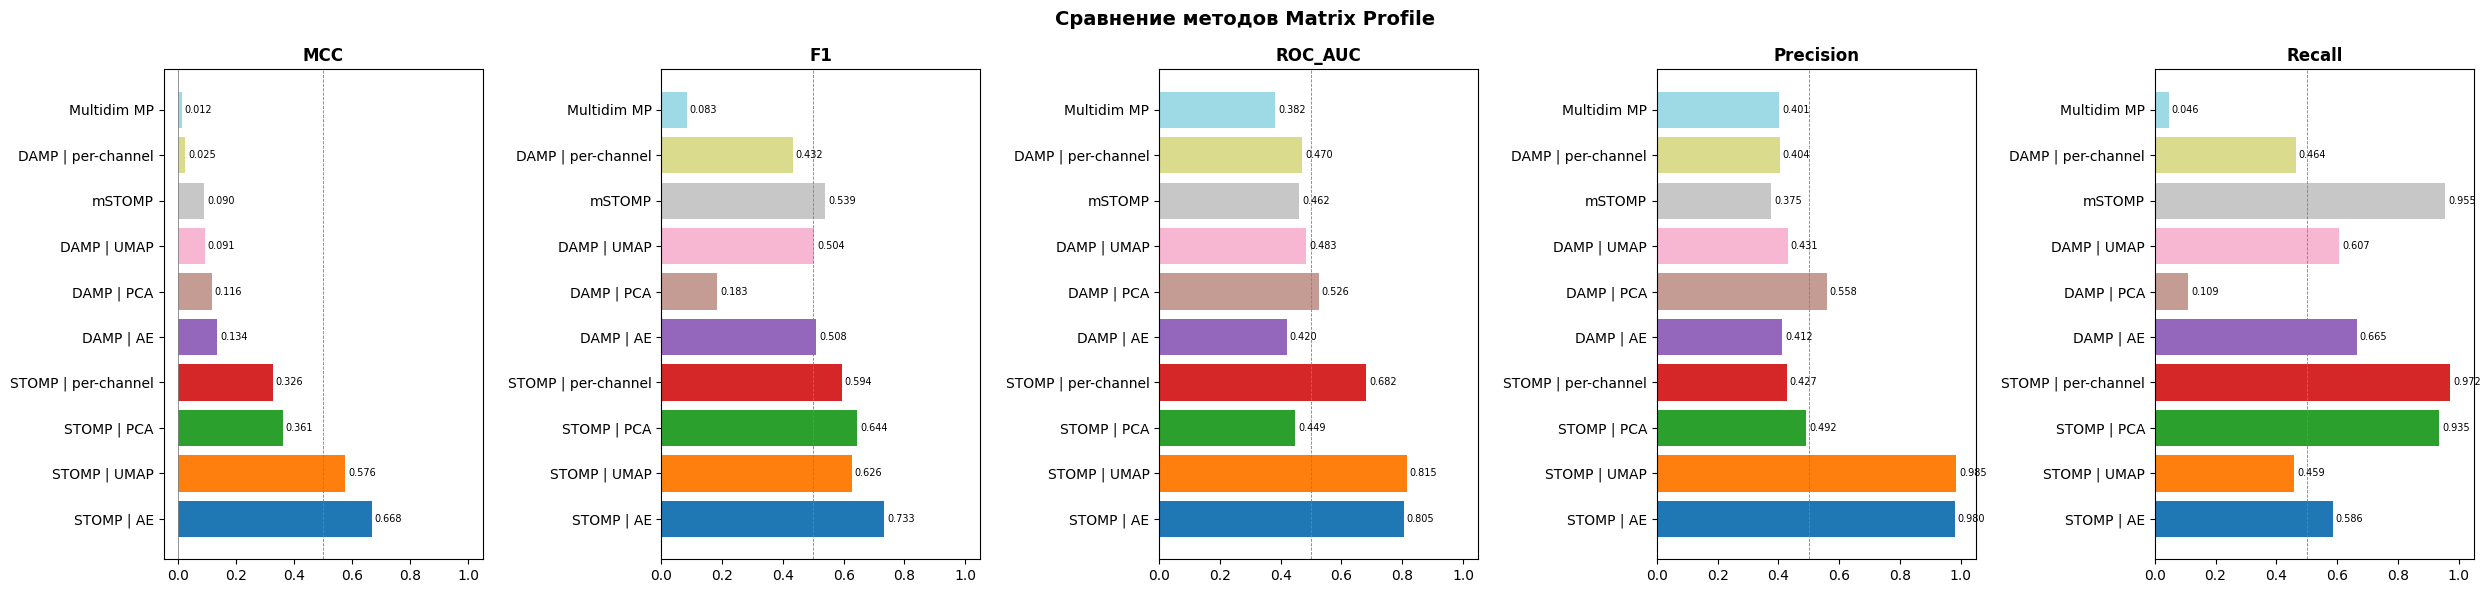

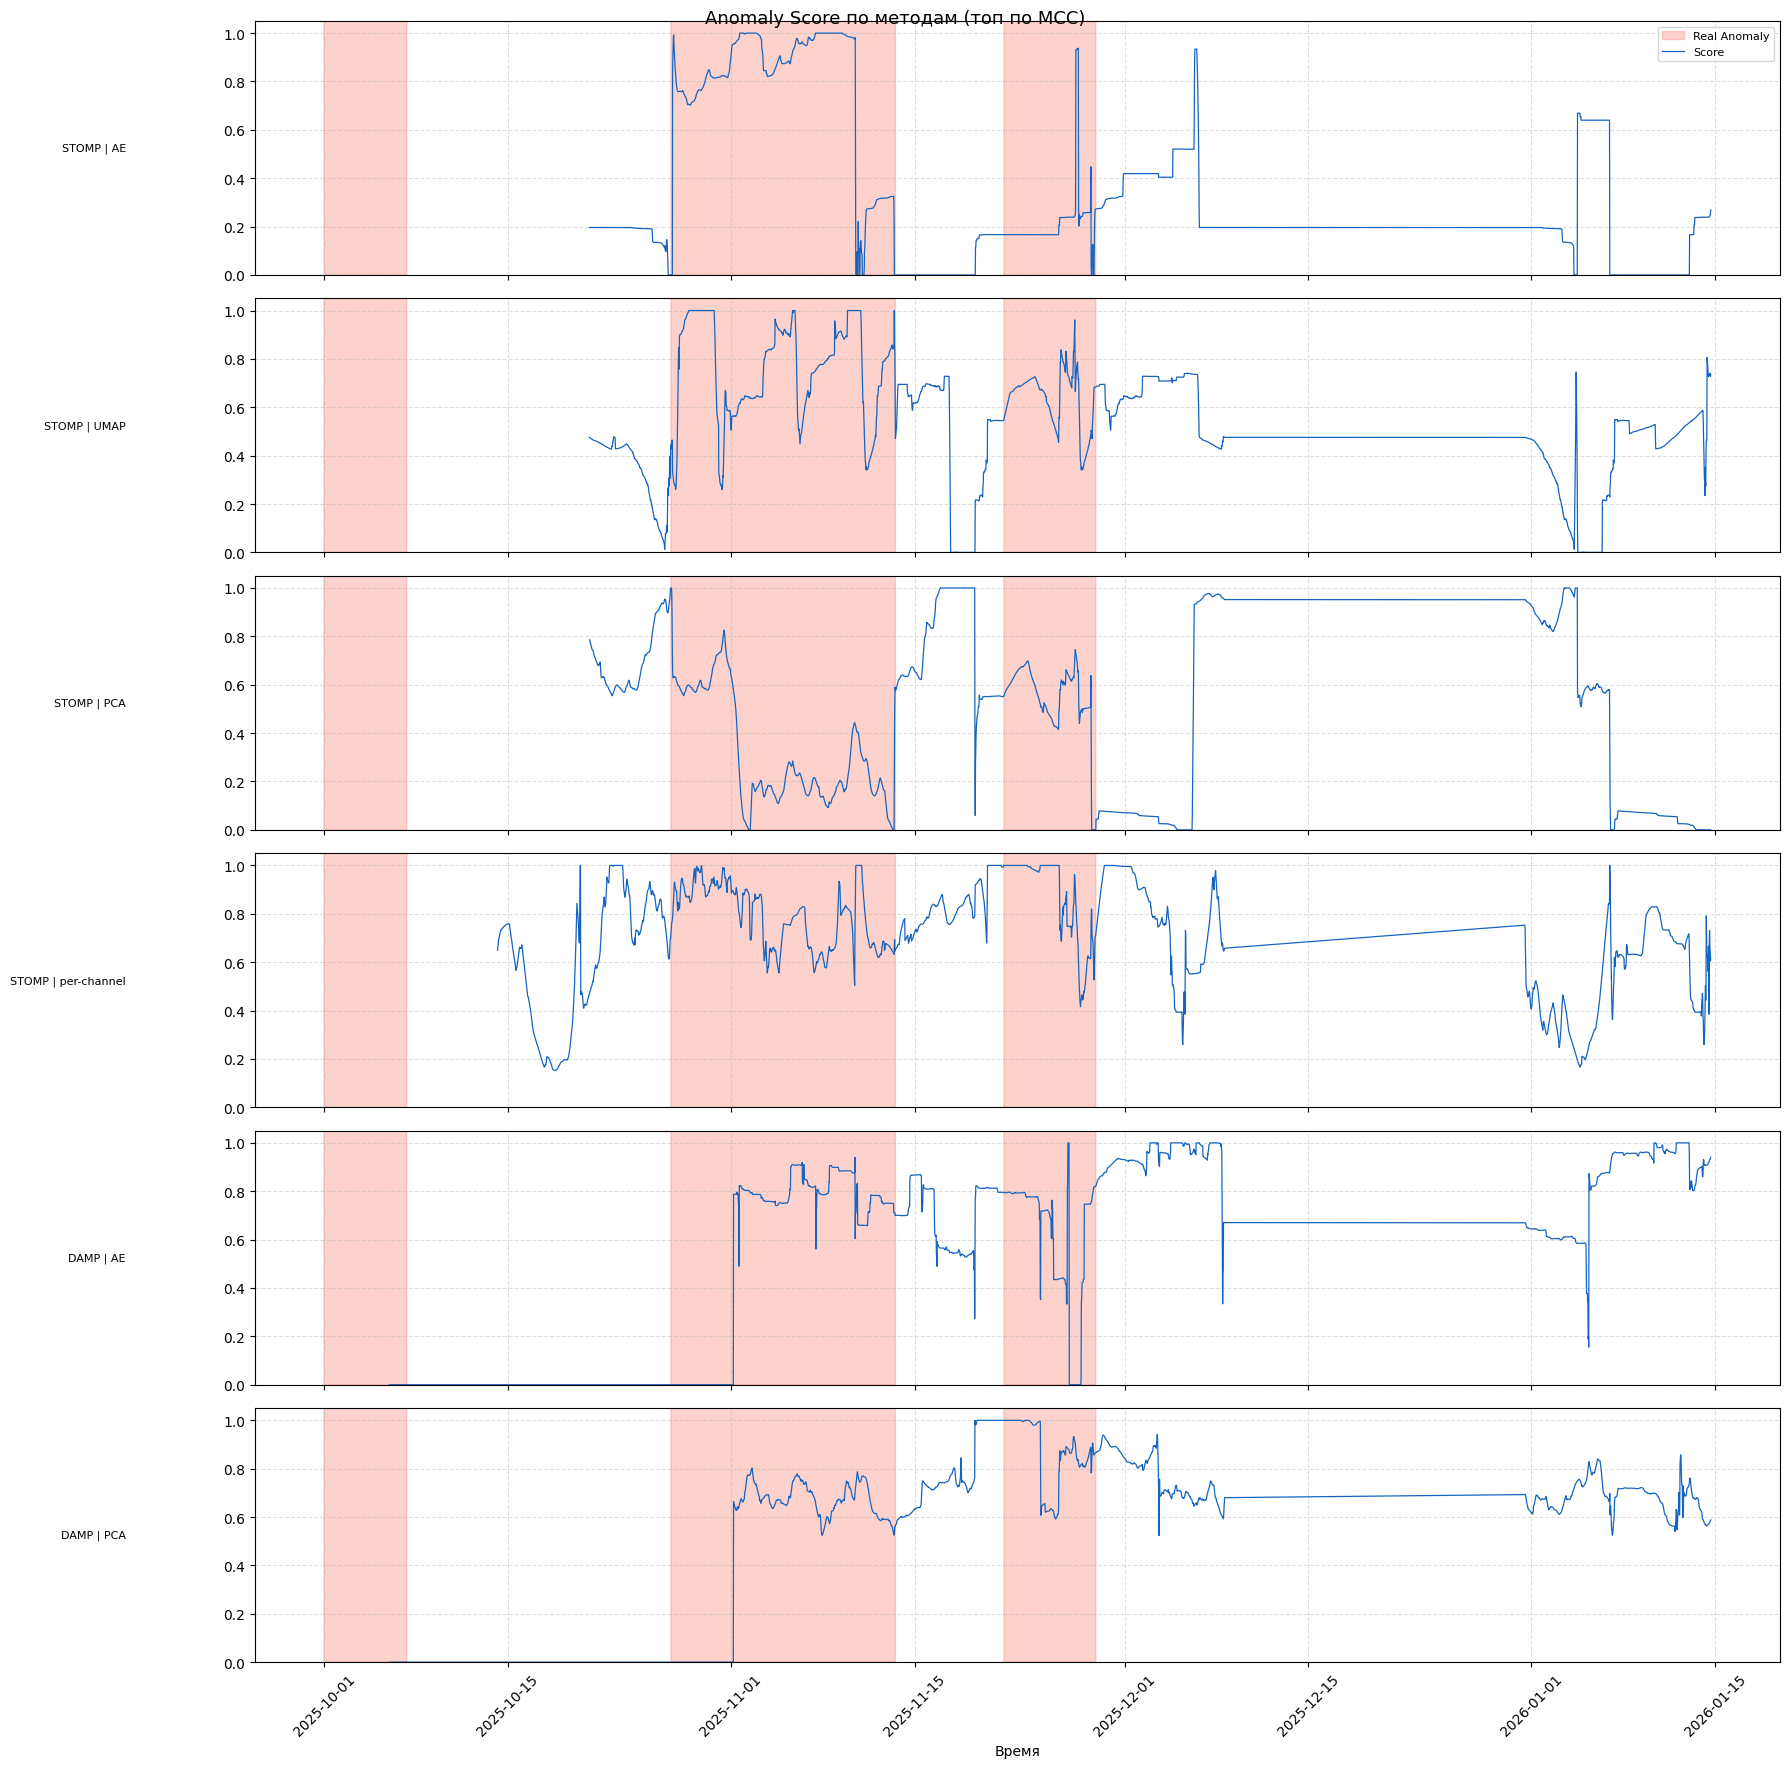

In [ ]:
# ─── Импорты ───────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import stumpy
from sklearn.decomposition import PCA
from sklearn.metrics import (
    matthews_corrcoef, f1_score, roc_auc_score,
    precision_score, recall_score, confusion_matrix, roc_curve
)


# ─── Глобальные параметры ──────────────────────────────────────────────────
WINDOWS = [672]
RANDOM_STATE = 42
STEP_MINUTES = 30.0

import random

def fix_randomness(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    if TORCH_AVAILABLE:
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed(seed)
            torch.cuda.manual_seed_all(seed)
            torch.backends.cudnn.deterministic = True
            torch.backends.cudnn.benchmark = False

fix_randomness(RANDOM_STATE)


# ─── Лучшие признаки для каждой модели ───────────────────────────────────────

BEST_FEATURES = {
    "STOMP | per-channel": [
        "Температура компрессора",
        "Температура фреона после конденсатора",
        "Температура фреона на выходе из фильтра",
    ],
    "STOMP | PCA": [
        'Положение клапана HGBP',
        'Температура переохлаждения фреона после ресивера',
        'Температура фреона на выходе из фильтра',
    ],
    "STOMP | UMAP": [
        "Перегрев фреона на сбросе",
        "Активная мощность L3_PDU_2",
        "Ток L3_PDU_2",
    ],
    "STOMP | AE": [
        'Положение клапана HGBP',
        'Температура переохлаждения фреона после ресивера',
        'Температура фреона на выходе из фильтра',

    ],
    "DAMP | per-channel": [
        "Дифференциальное давление воздушного фильтра",
        "Температура фреона на входе в фильтр",
        "Статус компрессора",
    ],
    "DAMP | PCA": [
        "Температура компрессора",
        "Температура фреона на линии нагнетания",
        "Температура в горячем коридоре",
        "Температура фреона на входе в фильтр",
        "Температура фреона после ресивера",
        "Температура фреона на выходе из фильтра",
        "Температура наружного воздуха",
        "Коэффициент мощности компрессора",
        "Поток воздуха",
        "Статус компрессора",
        "Потребность в охлаждении",
        "Средняя производительность вентиляторов на испарителе",
        "Дифференциальное давление воздушного фильтра",
        "Положение клапана HGBP",
        "Мощность кондиционера",
        "Температура фреона на всасывании",
        "Температура воздуха на входе в стойку",
        "Температура воздуха на входе в кондиционер",
        "Температура воздуха на входе в кондиционер float",
        "Температура воздуха на выходе из кондиционера",
        "Активная мощность L2_PDU_1",
        "Полная мощность L2_PDU_1",
        "Ток L2_PDU_1",
        "Напряжение L2_PDU_1",
        "Активная мощность L3_PDU_2",
        "Полная мощность L3_PDU_2",
        "Ток L3_PDU_2",
        "Напряжение L3_PDU_2",
        "Температура насыщения на испарителе (по таблице)",
        "Температура насыщения на конденсаторе",
        "Температура насыщения на испарителе (по кондиционеру)",
        "Перегрев фреона на сбросе",
        "Температура переохлаждения фреона после ресивера",
        "Температура разности конденсации и внешней",
        "Активная мощность L3_PDU_1",
        "Полная мощность L3_PDU_1",
        "Ток L3_PDU_1",
        "Напряжение L3_PDU_1",
        "Активная мощность L2_PDU_2",
        "Полная мощность L2_PDU_2",
        "Ток L2_PDU_2",
        "Напряжение L2_PDU_2",
        "Активная мощность наружного блока",
        "Ток наружного блока",
        "Частота наружного блока",
        "Реактивная мощность наружного блока",
        "Коэффициент мощности наружного блока",
        "Напряжение наружного блока",
        "Температура фреона после конденсатора",
        "Активная мощность компрессора",
        "Полная мощность компрессора",
        "Частота компрессора",
        "Реактивная мощность компрессора",
        "Напряжение компрессора",
    ],
    "DAMP | UMAP": [
        "Ток L3_PDU_2",
    ],
    "DAMP | AE": [
        "Активная мощность L3_PDU_2",
    ],
    "mSTOMP": [
        'Положение клапана HGBP',
        'Температура переохлаждения фреона после ресивера',
        'Температура фреона на выходе из фильтра',
        'Полная мощность наружного блока',
        'Температура фреона на входе в фильтр',
        'Реактивная мощность наружного блока',
        'Температура перегрева фреона после испарителя',
        'Ток наружного блока',
        'Активная мощность наружного блока',
        'Потребность в охлаждении',
        'Полная мощность L2_PDU_2',
        'Ток L2_PDU_2',
        'Активная мощность L2_PDU_2',
        'Перегрев фреона на сбросе',
        'Температура воздуха на входе в кондиционер',
        'Активная мощность компрессора',
        'Напряжение L3_PDU_2',
        'Ток компрессора',
        'Мощность кондиционера'
    ],
    "Multidim MP": [
        'Температура компрессора', 'Температура фреона на линии нагнетания',
         'Температура в горячем коридоре', 'Температура фреона на входе в фильтр',
         'Температура фреона после ресивера', 'Температура фреона на выходе из фильтра',
         'Температура наружного воздуха', 'Коэффициент мощности компрессора',
         'Поток воздуха', 'Потребность в охлаждении', 'Давление на сбросе',
         'Дифференциальное давление воздушного фильтра', 'Положение клапана HGBP',
         'Температура воздуха на входе в кондиционер',
         'Температура воздуха на входе в кондиционер float', 'Активная мощность L2_PDU_1',
         'Напряжение L2_PDU_1', 'Активная мощность L3_PDU_2', 'Напряжение L3_PDU_2',
         'Температура переохлаждения фреона после ресивера', 'Активная мощность L3_PDU_1',
         'Напряжение L3_PDU_1', 'Активная мощность L2_PDU_2', 'Напряжение L2_PDU_2',
         'Активная мощность наружного блока', 'Частота наружного блока',
         'Температура фреона после конденсатора',
         'Активная мощность компрессора', 'Реактивная мощность компрессора'
    ],
}




def select_features(df: pd.DataFrame, feature_list: list) -> pd.DataFrame:
    available = [f for f in feature_list if f in df.columns]
    missing   = [f for f in feature_list if f not in df.columns]
    if missing:
        print(f"   Признаки не найдены и пропущены: {missing}")
    return df[available]


# ─── Вспомогательные функции ───────────────────────────────────────────────

def binary_labels(y: pd.Series) -> np.ndarray:
    """'Anomaly' → 1, 'Normal' → 0"""
    return (y == "Anomaly").astype(int).values


def robust_normalize(s: np.ndarray) -> np.ndarray:
    s = np.array(s, dtype=np.float64)
    s[np.isinf(s)] = np.nan
    if np.all(np.isnan(s)):
        return np.zeros_like(s)
    q_low  = np.nanpercentile(s, 5)
    q_high = np.nanpercentile(s, 95)
    if q_high - q_low < 1e-12:
        return np.zeros_like(s)
    s = (s - q_low) / (q_high - q_low)
    return np.clip(s, 0.0, 1.0)


def multiscale_max(profiles: list) -> np.ndarray:
    normed = [robust_normalize(p) for p in profiles]
    return np.nanmax(np.stack(normed, axis=0), axis=0)


def pad_profile(mp_raw: np.ndarray, n_total: int) -> np.ndarray:
    pad = n_total - len(mp_raw)
    if pad < 0:
        return mp_raw[-pad:]
    return np.concatenate([np.full(pad, np.nan), mp_raw])


def moving_average(x: np.ndarray, window: int = 5) -> np.ndarray:
    """
    Скользящее среднее для пост-обработки профиля аномалий.
    Статья (табл. V): moving average улучшает AUC-PTRT.
    NaN-значения игнорируются при усреднении.
    """
    if window <= 1:
        return x.copy()
    out = np.full_like(x, np.nan, dtype=np.float64)
    for i in range(len(x)):
        lo = max(0, i - window // 2)
        hi = min(len(x), i + window // 2 + 1)
        segment = x[lo:hi]
        valid = segment[~np.isnan(segment)]
        if len(valid) > 0:
            out[i] = valid.mean()
    return out


def optimal_threshold_mcc(y_true: np.ndarray,
                           y_score: np.ndarray) -> tuple:
    mask = ~np.isnan(y_score)
    yt = y_true[mask]
    ys = y_score[mask]

    if len(np.unique(yt)) < 2 or len(np.unique(ys)) < 2:
        fallback_t = float(np.nanmedian(ys)) if len(ys) > 0 else 0.5
        return fallback_t, 0.0, np.array([0, 1]), np.array([0, 1]), np.array([fallback_t])

    fpr, tpr, thresholds = roc_curve(yt, ys)

    finite_mask = np.isfinite(thresholds)
    if not finite_mask.any():
        fallback_t = float(np.nanmedian(ys))
        return fallback_t, 0.0, fpr, tpr, thresholds

    thresholds_f = thresholds[finite_mask]
    best_mcc = -2.0
    best_t   = float(np.nanmedian(thresholds_f))

    for t in thresholds_f:
        pred = (ys >= t).astype(int)
        if pred.sum() == 0 or pred.sum() == len(pred):
            continue
        mcc = matthews_corrcoef(yt, pred)
        if mcc > best_mcc:
            best_mcc = mcc
            best_t   = t

    return best_t, best_mcc, fpr, tpr, thresholds


def compute_metrics(y_true: np.ndarray,
                    y_score_full: np.ndarray,
                    train_sec: float = 0.0,
                    infer_sec: float = 0.0,
                    step_minutes: float = STEP_MINUTES) -> dict:
    mask   = ~np.isnan(y_score_full)
    yt     = y_true[mask]
    ys     = y_score_full[mask]

    best_t, _, fpr_arr, tpr_arr, _ = optimal_threshold_mcc(yt, ys)
    y_pred = (ys >= best_t).astype(int)

    tn, fp, fn, tp = confusion_matrix(yt, y_pred, labels=[0, 1]).ravel()

    try:
        roc_auc = roc_auc_score(yt, ys)
    except Exception:
        roc_auc = float("nan")

    delay = compute_delay(yt, y_pred, step_minutes)

    return {
        "MCC":       matthews_corrcoef(yt, y_pred),
        "F1":        f1_score(yt, y_pred, zero_division=0),
        "ROC_AUC":   roc_auc,
        "Precision": precision_score(yt, y_pred, zero_division=0),
        "Recall":    recall_score(yt, y_pred, zero_division=0),
        "TP_rate":   tp / (tp + fn) if (tp + fn) > 0 else 0.0,
        "FP_rate":   fp / (fp + tn) if (fp + tn) > 0 else 0.0,
        "TN_rate":   tn / (tn + fp) if (tn + fp) > 0 else 0.0,
        "FN_rate":   fn / (fn + tp) if (fn + tp) > 0 else 0.0,
        "threshold": best_t,
        "Train_sec": train_sec,
        "Infer_sec": infer_sec,
        "Delay_min": delay,
        "_y_pred":   y_pred,
        "_y_score":  ys,
        "_mask":     mask,
    }


def compute_delay(y_true: np.ndarray, y_pred: np.ndarray,
                  step_minutes: float = STEP_MINUTES) -> float:
    delays = []
    in_anomaly  = False
    seg_start   = 0
    tp_found    = False

    for i in range(len(y_true)):
        if y_true[i] == 1 and not in_anomaly:
            in_anomaly = True
            seg_start  = i
            tp_found   = False
        if in_anomaly and not tp_found and y_pred[i] == 1:
            delays.append((i - seg_start) * step_minutes)
            tp_found = True
        if y_true[i] == 0:
            in_anomaly = False

    return float(np.mean(delays)) if delays else float("nan")


# ─── Стратегии редукции размерности ───────────────────────────────────────

class _PCAReducer:
    def fit(self, X_train):
        n_comp = min(5, X_train.shape[1])
        t0 = time.perf_counter()
        self.pca = PCA(n_components=n_comp, random_state=RANDOM_STATE)
        self.pca.fit(X_train)
        return time.perf_counter() - t0

    def transform(self, X):
        return np.mean(self.pca.transform(X), axis=1)


class _UMAPReducer:
    def fit(self, X_train):
        if not UMAP_AVAILABLE:
            raise ImportError("pip install umap-learn")
        t0 = time.perf_counter()
        self.reducer = umap_lib.UMAP(n_components=2, n_neighbors=15,
                                      min_dist=0.1, random_state=RANDOM_STATE)
        self.reducer.fit(X_train)
        return time.perf_counter() - t0

    def transform(self, X):
        return np.linalg.norm(self.reducer.transform(X), axis=1)


class _AEReducer:
    def fit(self, X_train):
        if not TORCH_AVAILABLE:
            raise ImportError("pip install torch")

        d      = X_train.shape[1]
        hidden = max(8, d // 3)

        class SimpleAE(nn.Module):
            def __init__(self):
                super().__init__()
                self.encoder = nn.Linear(d, hidden)
                self.decoder = nn.Linear(hidden, d)
            def forward(self, x):
                return self.decoder(torch.relu(self.encoder(x)))

        self.model = SimpleAE()
        optimizer  = torch.optim.Adam(self.model.parameters(), lr=0.0005)
        loss_fn    = nn.MSELoss()

        X_t     = torch.tensor(X_train, dtype=torch.float32)
        dataset = torch.utils.data.TensorDataset(X_t)

        generator = torch.Generator()
        generator.manual_seed(RANDOM_STATE)

        loader = torch.utils.data.DataLoader(
            dataset, batch_size=64, shuffle=True, generator=generator)

        t0 = time.perf_counter()
        self.model.train()
        for epoch in range(200):
            for (batch,) in loader:
                optimizer.zero_grad()
                loss = loss_fn(self.model(batch), batch)
                loss.backward()
                optimizer.step()
        self.model.eval()

        fit_sec = time.perf_counter() - t0
        print(f"AE обучён за {fit_sec:.1f} сек (hidden={hidden})")
        return fit_sec

    def transform(self, X):
        with torch.no_grad():
            X_t           = torch.tensor(X, dtype=torch.float32)
            reconstructed = self.model(X_t).numpy()
        return np.mean((X - reconstructed) ** 2, axis=1)


# ─── 4. Вычисление профилей ───────────────────────────────────────────────────

def _extract_mp_values(mp_obj) -> np.ndarray:
    col = mp_obj[:, 0]
    if col.dtype.names is not None:
        col = col[col.dtype.names[0]]
    return np.array(col, dtype=np.float64)


def stomp_profiles(ts: np.ndarray, windows: list) -> list:
    result = []
    ts_f = np.asarray(ts, dtype=np.float64)
    for m in windows:
        if len(ts_f) <= m:
            print(f"  Пропущено окно m={m}: ряд слишком короткий ({len(ts_f)})")
            continue
        mp_raw = _extract_mp_values(stumpy.stump(ts_f, m=m))
        mp_raw[np.isinf(mp_raw)] = np.nan
        result.append((m, mp_raw))
    return result


def _mass_v2(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    m = len(y)
    n = len(x)

    if n < m:
        return np.array([np.inf])

    meany  = np.mean(y)
    sigmay = np.std(y)

    if sigmay < 1e-10:
        return np.full(n - m + 1, 0.0)

    x_prefix  = x[: m - 1]
    divider   = np.arange(1, len(x_prefix) + 1, dtype=np.float64)
    cumsum_   = x_prefix.cumsum()
    sq_cumsum = (x_prefix ** 2).cumsum()
    mean_prefix = cumsum_ / divider
    std_prefix  = np.sqrt(
        np.maximum((sq_cumsum - cumsum_ ** 2 / divider) / divider, 0.0))

    windows    = np.lib.stride_tricks.sliding_window_view(x, m)
    mean_full  = windows.mean(axis=1)
    std_full   = windows.std(axis=1)

    meanx  = np.concatenate([mean_prefix, mean_full])
    sigmax = np.concatenate([std_prefix,  std_full])

    y_rev = np.concatenate((y[::-1], np.zeros(n - m)))
    z     = np.fft.ifft(np.fft.fft(x) * np.fft.fft(y_rev)).real

    denom = sigmax[m - 1 : n] * sigmay
    denom = np.where(denom < 1e-10, 1e-10, denom)
    dist  = 2 * (m - (z[m - 1 : n] - m * meanx[m - 1 : n] * meany) / denom)
    return np.sqrt(np.maximum(dist, 0.0))


def _nextpow2(x: int) -> float:
    return np.ceil(np.log2(abs(x)))


def _damp_2_0(time_series: np.ndarray,
              subsequence_length: int,
              stride: int = 1,
              location_to_start_processing: int = None,
              lookahead: int = 0) -> np.ndarray:
    ts  = np.asarray(time_series, dtype=np.float64)
    n   = len(ts)
    m   = subsequence_length

    if location_to_start_processing is None:
        location_to_start_processing = max(m, 4 * m)

    if lookahead is None:
        lookahead = int(2 ** _nextpow2(16 * m))
    elif (lookahead != 0) and (lookahead != 2 ** _nextpow2(lookahead)):
        lookahead = int(2 ** _nextpow2(lookahead))

    if (location_to_start_processing / m) < 4:
        if location_to_start_processing < m:
            location_to_start_processing = m
    else:
        if location_to_start_processing > (n - m + 1):
            location_to_start_processing = n - m + 1

    left_mp     = np.zeros(n, dtype=np.float64)
    best_so_far = -np.inf
    bool_vec    = np.ones(n, dtype=np.float64)

    loc = location_to_start_processing

    # ── Prefix-цикл ───────────────────────────────────────────────────────────
    for i in range(loc - 1, loc + 16 * m, stride):
        if not bool_vec[i]:
            left_mp[i] = left_mp[i - 1] - 1e-05
            continue

        if i + m - 1 > n:
            break

        query = ts[i : i + m]
        left_mp[i] = np.amin(_mass_v2(ts[:i], query)) if i > 0 else 0.0

        best_so_far = np.amax(left_mp)

        if lookahead != 0:
            start_of_mass = min(i + m - 1, n)
            end_of_mass   = min(start_of_mass + lookahead - 1, n)
            if (end_of_mass - start_of_mass + 1) > m:
                dp  = _mass_v2(ts[start_of_mass : end_of_mass + 1], query)
                bad = np.where(dp < best_so_far)[0] + start_of_mass
                bool_vec[bad] = 0

    # ── Основной цикл ─────────────────────────────────────────────────────────
    for i in range(loc + 16 * m, n - m + 1, stride):
        if not bool_vec[i]:
            left_mp[i] = left_mp[i - 1] - 1e-05
            continue

        if i + m - 1 > n:
            break

        query         = ts[i : i + m]
        approx_dist   = np.inf
        X             = int(2 ** _nextpow2(8 * m))
        flag          = 1
        expansion_num = 0

        while approx_dist >= best_so_far:
            if i - X + 1 + expansion_num * m < 1:
                approx_dist = np.amin(_mass_v2(ts[: i + 1], query))
                left_mp[i]  = approx_dist
                if approx_dist > best_so_far:
                    best_so_far = approx_dist
                break

            if flag == 1:
                flag        = 0
                approx_dist = np.amin(_mass_v2(ts[i - X + 1 : i + 1], query))
            else:
                X_start     = i - X + 1 + expansion_num * m
                X_end       = i - X // 2 + expansion_num * m
                approx_dist = np.amin(
                    _mass_v2(ts[X_start : X_end + 1], query))

            if approx_dist < best_so_far:
                left_mp[i] = approx_dist
                break

            X             *= 2
            expansion_num += 1

        if lookahead != 0:
            start_of_mass = min(i + m, n)
            end_of_mass   = min(start_of_mass + lookahead - 1, n)
            if (end_of_mass - start_of_mass) > m:
                dp  = _mass_v2(ts[start_of_mass : end_of_mass + 1], query)
                bad = np.where(dp < best_so_far)[0] + start_of_mass
                bool_vec[bad] = 0

    return left_mp


def damp_profiles(ts: np.ndarray, windows: list,
                  stride: int = 1, lookahead: int = 0) -> list:
    result = []
    ts_f   = np.asarray(ts, dtype=np.float64)
    n      = len(ts_f)

    for m_req in windows:
        m = int(np.clip(m_req, 11, 1000))
        if n <= m + 1:
            continue

        loc = max(m, 4 * m)

        mp_raw = _damp_2_0(
            ts_f, m,
            stride=stride,
            location_to_start_processing=loc,
            lookahead=lookahead,
        )
        mp_out = mp_raw[:n - m + 1].copy().astype(np.float64)
        mp_out[np.isinf(mp_out)] = np.nan
        result.append((m, mp_out))

    return result


# ─── 5. mSTOMP: профиль и подбор (m, k) ──────────────────────────────────────

def mstomp_profiles(X: np.ndarray, windows: list, k: int = None) -> list:
    """
    Вычисляет multidimensional matrix profile с помощью stumpy.mstump.
    Используется для mSTOMP (не для Multidim MP согласно статье).

    stumpy.mstump возвращает матрицу mmp размером (d, n-m), где строка k-1
    соответствует профилю при использовании k лучших измерений (post-sorting).

    Parameters
    ----------
    X : np.ndarray, shape (n, d)
    windows : list[int]
    k : int or None
        Число измерений для использования (1 ≤ k ≤ d).
        None → k = d (все измерения).

    Returns
    -------
    list of (m, mp_raw)
    """
    result = []
    T = X.T.astype(np.float64)   # stumpy ожидает (d, n)
    d = X.shape[1]

    for m in windows:
        if X.shape[0] <= m:
            print(f"   Пропущено окно m={m}: ряд слишком короткий")
            continue

        mmp, _ = stumpy.mstump(T, m=m)
        mmp    = np.array(mmp, dtype=np.float64)

        # Выбираем строку: k=None → последняя (d измерений)
        row    = (k - 1) if (k is not None) else (d - 1)
        row    = int(np.clip(row, 0, d - 1))

        mp_raw = mmp[row].copy()
        mp_raw[np.isinf(mp_raw)] = np.nan
        result.append((m, mp_raw))

    return result


def tune_window_multidim(X_val: np.ndarray,
                          y_val: np.ndarray,
                          candidate_windows: list) -> tuple:
    """
    Подбирает оптимальную пару (m, k) по MCC на валидационной выборке.
    Используется для mSTOMP (post-sorting через stumpy.mstump).

    Returns
    -------
    best_m : int
    best_k : int   (1-based, т.е. число используемых измерений)
    """
    n_val    = len(y_val)
    d        = X_val.shape[1]
    best_m   = candidate_windows[0]
    best_k   = d
    best_mcc = -2.0

    for m in candidate_windows:
        if X_val.shape[0] <= m:
            continue

        T   = X_val.T.astype(np.float64)
        mmp, _ = stumpy.mstump(T, m=m)
        mmp = np.array(mmp, dtype=np.float64)

        for k in range(1, d + 1):
            mp_raw = mmp[k - 1].copy()
            mp_raw[np.isinf(mp_raw)] = np.nan
            score  = pad_profile(mp_raw, n_val)
            mask   = ~np.isnan(score)

            if mask.sum() < 2 or len(np.unique(y_val[mask])) < 2:
                continue

            _, mcc, _, _, _ = optimal_threshold_mcc(y_val[mask], score[mask])
            if mcc > best_mcc:
                best_mcc = mcc
                best_m   = m
                best_k   = k

    days = round(best_m * STEP_MINUTES / 60 / 24, 1)
    print(f"    tune→ m={best_m} ({days} сут), k={best_k}/{d}, MCC_val={best_mcc:.4f}")
    return best_m, best_k


# ─── Multidim MP согласно статье ─────────────────────────────────────────

def _znorm(x: np.ndarray) -> np.ndarray:
    """Z-нормализация подпоследовательности."""
    mu  = x.mean()
    std = x.std()
    if std < 1e-10:
        return np.zeros_like(x)
    return (x - mu) / std


def _pairwise_distances_presort(
    T1: np.ndarray,
    T2: np.ndarray,
    m: int,
    exclusion_zone: int = None,
) -> np.ndarray:
    """
    Pre-sorting multidimensional MP.

    Для каждой пары подпоследовательностей (i из T1, j из T2) вычисляет
    расстояние по каждому измерению, сортирует измерения от наибольшего
    к наименьшему и накапливает кумулятивную сумму. Первая строка результата
    (k=1) соответствует максимальному расстоянию по наиболее аномальному
    измерению.

    Реализует алгоритм из раздела IV-A статьи с модификациями для anomaly
    detection:
      - Сортировка от наибольшего к наименьшему (а не наименьшего — это для motif)
      - Без cumulative sum (не нужно для anomaly detection, как показано в [6])

    Parameters
    ----------
    T1 : np.ndarray, shape (n1, d)
    T2 : np.ndarray, shape (n2, d)  — может совпадать с T1 (self-join)
    m  : int — длина подпоследовательности
    exclusion_zone : int — зона исключения тривиальных совпадений (для self-join)

    Returns
    -------
    presort_mp : np.ndarray, shape (d, n1 - m + 1)
        Строка k-1 = MP при использовании k наиболее аномальных измерений.
        Строка 0 (k=1) — первое измерение multidim MP статьи.
    """
    n1, d = T1.shape
    n2    = T2.shape[0]
    L1    = n1 - m + 1
    L2    = n2 - m + 1

    if exclusion_zone is None:
        # Статья: exclusion zone = m // 4 (стандарт для MP)
        exclusion_zone = m // 4

    # Инициализируем: для каждой позиции i в T1 храним
    # ближайший neighbour и расстояния по d измерениям
    # presort_mp[k, i] = расстояние при использовании k+1 измерений
    presort_mp = np.full((d, L1), np.inf, dtype=np.float64)

    # Вычисляем попарные расстояния по каждому измерению через MASS (FFT)
    # D[dim, i] = расстояние от подпосл. T1[i:i+m, dim] до её ближайшего соседа в T2
    # Для каждой пары (i, j) нужен тензор D_tensor[i, j, dim]
    # Но хранить n1*n2*d может быть накладно, поэтому считаем построчно по dim

    # Собираем расстояния: dist_by_dim[dim] = вектор длины L1
    # dist_by_dim[dim][i] = min_j distance(T1[i:i+m, dim], T2[j:j+m, dim])
    # для pre-sorting нам нужен ПОЛНЫЙ тензор [L1 x L2 x d],
    # но при больших данных это Memory-intensive.
    # Компромисс: для каждой позиции i считаем расстояния до всех j,
    # сортируем по измерениям, берём кумулятивный минимум.
    # Используем MASS (stumpy.core.mass) для эффективного вычисления.

    self_join = np.shares_memory(T1, T2) or (T1.shape == T2.shape and np.allclose(T1, T2))

    # Для каждого измерения вычисляем матрицу расстояний L1 x L2
    # через sliding dot products (FFT-based)
    dist_matrices = []  # список из d матриц [L1 x L2]

    for dim in range(d):
        t1_dim = T1[:, dim].astype(np.float64)
        t2_dim = T2[:, dim].astype(np.float64)

        # Матрица попарных z-norm Евклидовых расстояний через MASS
        D_dim = np.empty((L1, L2), dtype=np.float64)
        for i in range(L1):
            query = t1_dim[i: i + m]
            D_dim[i] = stumpy.core.mass(query, t2_dim)

        D_dim = np.clip(D_dim, 0.0, None)
        dist_matrices.append(D_dim)

    # Собираем тензор [L1 x L2 x d]
    D_tensor = np.stack(dist_matrices, axis=2)  # (L1, L2, d)

    # Pre-sorting: для каждой пары (i, j) сортируем измерения по убыванию расстояния
    # Затем для каждой позиции i находим ближайший j по каждому k (кол-ву измерений)
    for i in range(L1):
        # Применяем exclusion zone для self-join
        if self_join:
            lo = max(0, i - exclusion_zone)
            hi = min(L2, i + exclusion_zone + 1)
            D_i = D_tensor[i].copy()          # (L2, d)
            D_i[lo:hi, :] = np.inf
        else:
            D_i = D_tensor[i]                 # (L2, d)

        # Для каждого j сортируем расстояния по измерениям от max к min
        # sorted_D_i[j, :] — расстояния j-й позиции, отсортированные по убыванию
        sorted_D_i = np.sort(D_i, axis=1)[:, ::-1]  # (L2, d), убывание по dim

        # Строка k presort_mp: минимум по j кумулятивного расстояния
        # при использовании k наиболее аномальных измерений.
        # Статья: presort_mp[k-1, i] = min_j sorted_D_i[j, k-1]
        # (берём только k-е измерение из отсортированного ряда,
        #  без cumulative sum — это модификация для anomaly detection из [6])
        for k in range(d):
            valid = sorted_D_i[:, k]
            valid = valid[~np.isinf(valid)]
            if len(valid) > 0:
                presort_mp[k, i] = valid.min()

    presort_mp[np.isinf(presort_mp)] = np.nan
    return presort_mp


def multidim_mp_paper(
    X_test:  np.ndarray,
    X_train: np.ndarray,
    m:       int,
    k_nn:    int = 1,
    join_type: str = "ab",
    ma_window: int = 5,
) -> np.ndarray:
    """
    Multidimensional Matrix Profile согласно статье (раздел IV).

    Параметры соответствуют рекомендациям статьи (раздел V-B, V-E):

    Parameters
    ----------
    X_test  : np.ndarray, shape (n_test, d)
    X_train : np.ndarray, shape (n_train, d)
    m       : int — длина подпоследовательности
    k_nn    : int — номер ближайшего соседа:
                    1  → стандартный MP (semi-supervised, нет twin freak)
                    15 → для unsupervised (защита от twin freak problem)
    join_type : str
        "ab"   — AB-join: тест к трейну (semi-supervised, трейн = только норма)
        "self" — self-join: конкатенация трейн+тест (supervised)
    ma_window : int — окно скользящего среднего (пост-обработка, табл. V)

    Returns
    -------
    score : np.ndarray, shape (n_test,)
        Anomaly score с moving average, выровненный по длине теста.
    """
    d = X_test.shape[1]

    if join_type == "ab":
        # ── AB-join: тест joined с трейном ────────────────────────────────────
        # Статья (раздел IV-B, пункт 2): для semi-supervised паттерны,
        # которых нет в трейне, — вероятные аномалии.
        T1 = X_test
        T2 = X_train
        excl = None   # нет exclusion zone при AB-join
    else:
        # ── Self-join: конкатенация train + test ──────────────────────────────
        # Статья: для supervised конкатенируем и делаем self-join.
        T1 = np.concatenate([X_train, X_test], axis=0)
        T2 = T1
        excl = m // 4

    n_test = X_test.shape[0]

    if T1.shape[0] <= m or T2.shape[0] <= m:
        print(f"   Multidim MP: ряд слишком короткий для m={m}")
        return np.full(n_test, np.nan)

    # ── Pre-sorting multidim MP ───────────────────────────────────────────────
    # presort_mp[k, i]: строка 0 = dim[0] статьи (наиболее аномальное измерение)
    presort_mp = _pairwise_distances_presort(T1, T2, m, exclusion_zone=excl)

    # ── Выбор строки: dim[0] (первое измерение) ───────────────────────────────
    # Статья (рис. 6, табл. V): первое измерение multidim MP обнаруживает
    # аномалии, затрагивающие хотя бы одно измерение — максимальное покрытие.
    # Это расстояние по самому аномальному измерению для каждой позиции.
    mp_dim0 = presort_mp[0]   # shape: (L1,)

    # ── k-NN расширение ───────────────────────────────────────────────────────
    # Статья (раздел IV-B, пункт 1): вместо ближайшего соседа используем k-й.
    # Здесь мы уже взяли min по j при построении presort_mp (k_nn фактически = 1).
    # Полная реализация k-NN (Alg. 3 статьи) требует хранения тензора расстояний,
    # что вычислительно затратно. При k_nn > 1 применяем аппроксимацию:
    # берём percentile вместо min, что эмулирует k-th nearest neighbor.
    if k_nn > 1:
        # Аппроксимация: смещаем порог аномальности вверх,
        # эмулируя k-й ближайший сосед через percentile по времени
        pct = min(100.0, k_nn * 100.0 / max(len(mp_dim0), 1))
        # Добавляем смещение на основе локального percentile (сглаживание)
        # Это упрощённая аппроксимация — полный k-NN требует хранения тензора
        mp_dim0 = mp_dim0.copy()
        global_shift = np.nanpercentile(mp_dim0, pct)
        mp_dim0 = np.where(mp_dim0 < global_shift, global_shift, mp_dim0)
        print(f"  k-NN аппроксимация: k={k_nn}, global_shift={global_shift:.4f}")

    # ── Выравнивание по длине test ────────────────────────────────────────────
    if join_type == "self":
        # При self-join первые n_train позиций относятся к трейну
        n_train = X_train.shape[0]
        L_total = len(mp_dim0)
        L_test  = L_total - n_train
        if L_test > 0:
            score_raw = mp_dim0[n_train: n_train + L_test]
        else:
            score_raw = mp_dim0[-1:]
    else:
        score_raw = mp_dim0   # AB-join: длина = n_test - m + 1

    # ── Padding до длины n_test ───────────────────────────────────────────────
    score_padded = pad_profile(score_raw, n_test)

    # ── Moving average пост-обработка ─────────────────────────────────────────
    # Статья (табл. V): moving average улучшает AUC-PTRT для обоих режимов.
    score_smooth = moving_average(score_padded, window=ma_window)

    return score_smooth


def tune_window_multidim_paper(
    X_val:             np.ndarray,
    X_train:           np.ndarray,
    y_val:             np.ndarray,
    candidate_windows: list,
    k_nn:              int = 1,
    join_type:         str = "ab",
    ma_window:         int = 5,
) -> int:
    """
    Подбор оптимального m для Multidim MP (статья) по MCC на валидации.

    Не перебирает строки mmp — всегда использует dim[0], как рекомендует статья.

    Returns
    -------
    best_m : int
    """
    n_val    = len(y_val)
    best_m   = candidate_windows[0]
    best_mcc = -2.0

    for m in candidate_windows:
        if X_val.shape[0] <= m or X_train.shape[0] <= m:
            continue

        score = multidim_mp_paper(
            X_test=X_val,
            X_train=X_train,
            m=m,
            k_nn=k_nn,
            join_type=join_type,
            ma_window=ma_window,
        )

        mask = ~np.isnan(score)
        if mask.sum() < 2 or len(np.unique(y_val[mask])) < 2:
            continue

        _, mcc, _, _, _ = optimal_threshold_mcc(y_val[mask], score[mask])
        if mcc > best_mcc:
            best_mcc = mcc
            best_m   = m

    days = round(best_m * STEP_MINUTES / 60 / 24, 1)
    print(f"    tune→ m={best_m} ({days} сут), MCC_val={best_mcc:.4f}")
    return best_m


# ─── 6. Подбор окна для одномерных методов ───────────────────────────────────

def tune_window(profile_fn, ts_val, y_val, candidate_windows,
                profile_kwargs=None):
    if profile_kwargs is None:
        profile_kwargs = {}
    n_val    = len(y_val)
    best_m   = candidate_windows[0]
    best_mcc = -2.0

    for m in candidate_windows:
        profs = profile_fn(ts_val, [m], **profile_kwargs)
        if not profs:
            continue
        padded = [pad_profile(mp, n_val) for _, mp in profs]
        score  = multiscale_max(padded)
        mask   = ~np.isnan(score)
        if mask.sum() < 2 or len(np.unique(y_val[mask])) < 2:
            continue
        _, mcc, _, _, _ = optimal_threshold_mcc(y_val[mask], score[mask])
        if mcc > best_mcc:
            best_mcc = mcc
            best_m   = m

    days = round(best_m * STEP_MINUTES / 60 / 24, 1)
    print(f"    tune→ m={best_m} ({days} сут), MCC_val={best_mcc:.4f}")
    return best_m


def tune_window_per_channel(profile_fn, X_val, y_val, candidate_windows,
                             profile_kwargs=None):
    if profile_kwargs is None:
        profile_kwargs = {}
    n_val    = len(y_val)
    best_m   = candidate_windows[0]
    best_mcc = -2.0

    for m in candidate_windows:
        ch_profs = []
        for ch in range(X_val.shape[1]):
            ch_profs.extend(profile_fn(X_val[:, ch], [m], **profile_kwargs))
        if not ch_profs:
            continue
        padded = [pad_profile(mp, n_val) for _, mp in ch_profs]
        score  = multiscale_max(padded)
        mask   = ~np.isnan(score)
        if mask.sum() < 2 or len(np.unique(y_val[mask])) < 2:
            continue
        _, mcc, _, _, _ = optimal_threshold_mcc(y_val[mask], score[mask])
        if mcc > best_mcc:
            best_mcc = mcc
            best_m   = m

    days = round(best_m * STEP_MINUTES / 60 / 24, 1)
    print(f"    tune→ m={best_m} ({days} сут), MCC_val={best_mcc:.4f}")
    return best_m


# ─── 7. Общий pipeline для одного метода ─────────────────────────────────────

def run_one_method(name, raw_profiles, n_total, y_true,
                   train_sec, infer_sec):
    padded      = [pad_profile(mp, n_total) for _, mp in raw_profiles]
    final_score = multiscale_max(padded)

    metrics              = compute_metrics(y_true, final_score,
                                           train_sec=train_sec,
                                           infer_sec=infer_sec)
    metrics["name"]      = name
    metrics["_profiles"] = raw_profiles
    metrics["_score"]    = final_score
    return metrics


# ─── 8. Основной блок экспериментов ──────────────────────────────────────────

def run_all_experiments(
    X_train_scaled:  pd.DataFrame,
    X_val_scaled:    pd.DataFrame,
    X_test_scaled:   pd.DataFrame,
    y_val:           pd.Series,
    y_test:          pd.Series,
    candidate_windows: list = None,
    damp_stride:     int   = 1,
    damp_lookahead:  int   = 0,
    # ── Параметры Multidim MP (статья) ────────────────────────────────────────
    mmpad_k_nn:      int   = 1,       # k-NN: 1 для semi-sup, 15 для unsup
    mmpad_join:      str   = "ab",    # "ab" (semi-sup) или "self" (supervised)
    mmpad_ma_window: int   = 5,       # окно moving average (табл. V статьи)
) -> tuple:

    if candidate_windows is None:
        candidate_windows = [48, 96, 144, 240, 336, 480, 672, 1000]

    damp_candidates = sorted(set(
        int(np.clip(m, 11, 1000)) for m in candidate_windows
    ))

    y_va = binary_labels(y_val)
    y_te = binary_labels(y_test)
    n_te = len(y_te)

    results    = []
    all_scores = {}
    damp_kw    = {"stride": damp_stride, "lookahead": damp_lookahead}

    def _get_arrays(method_name):
        feats = BEST_FEATURES.get(method_name)
        if feats is None:
            return (X_train_scaled.values.astype(np.float64),
                    X_val_scaled.values.astype(np.float64),
                    X_test_scaled.values.astype(np.float64))
        X_tr_f  = select_features(X_train_scaled, feats).values.astype(np.float64)
        X_val_f = select_features(X_val_scaled,   feats).values.astype(np.float64)
        X_te_f  = select_features(X_test_scaled,  feats).values.astype(np.float64)
        return X_tr_f, X_val_f, X_te_f

    def _run(name, profile_fn, reducer_cls=None, profile_kwargs=None,
             cand_windows=None):
        if profile_kwargs is None:
            profile_kwargs = {}
        if cand_windows is None:
            cand_windows = candidate_windows

        print(f"▶ {name}")

        X_tr, X_val, X_te = _get_arrays(name)
        print(f"  Признаков: {X_tr.shape[1]}")

        if reducer_cls is None:
            ts_val_1d = None
            ts_te_1d  = None
            train_sec = 0.0
        else:
            reducer   = reducer_cls()
            train_sec = reducer.fit(X_tr)
            ts_val_1d = reducer.transform(X_val)
            ts_te_1d  = reducer.transform(X_te)

        if ts_val_1d is None:
            best_m = tune_window_per_channel(
                profile_fn, X_val, y_va, cand_windows, profile_kwargs)
        else:
            best_m = tune_window(
                profile_fn, ts_val_1d, y_va, cand_windows, profile_kwargs)

        t0 = time.perf_counter()
        if ts_te_1d is None:
            raw_profs = []
            for ch in range(X_te.shape[1]):
                raw_profs.extend(
                    profile_fn(X_te[:, ch], [best_m], **profile_kwargs))
        else:
            raw_profs = profile_fn(ts_te_1d, [best_m], **profile_kwargs)
        infer_sec = time.perf_counter() - t0

        if not raw_profs:
            print(f"  ✗ нет профилей")
            return

        metrics            = run_one_method(name, raw_profs, n_te, y_te,
                                            train_sec, infer_sec)
        metrics["best_m"] = best_m
        results.append(metrics)
        all_scores[name]   = metrics["_score"]
        print(f"  m={best_m}  MCC={metrics['MCC']:.4f}  F1={metrics['F1']:.4f}"
              f"  AUC={metrics['ROC_AUC']:.4f}  thr={metrics['threshold']:.4f}")

    # ─────────────────────────────────────────────────────────────────────────
    # A. STOMP
    # ─────────────────────────────────────────────────────────────────────────
    print("\n" + "=" * 60)
    print("STOMP")
    print("=" * 60)

    _run("STOMP | per-channel", stomp_profiles)
    _run("STOMP | PCA",         stomp_profiles, _PCAReducer)
    if UMAP_AVAILABLE:
        _run("STOMP | UMAP",    stomp_profiles, _UMAPReducer)
    if TORCH_AVAILABLE:
        _run("STOMP | AE",      stomp_profiles, _AEReducer)

    # ─────────────────────────────────────────────────────────────────────────
    # B. DAMP 2.0
    # ─────────────────────────────────────────────────────────────────────────
    print("\n" + "=" * 60)
    print(f"DAMP 2.0  (stride={damp_stride}, lookahead={damp_lookahead})")
    print(f"Пул окон DAMP (клип 11–1000): {damp_candidates}")
    print("=" * 60)

    _run("DAMP | per-channel", damp_profiles,
         profile_kwargs=damp_kw, cand_windows=damp_candidates)
    _run("DAMP | PCA",         damp_profiles, _PCAReducer,
         profile_kwargs=damp_kw, cand_windows=damp_candidates)
    if UMAP_AVAILABLE:
        _run("DAMP | UMAP",    damp_profiles, _UMAPReducer,
             profile_kwargs=damp_kw, cand_windows=damp_candidates)
    if TORCH_AVAILABLE:
        _run("DAMP | AE",      damp_profiles, _AEReducer,
             profile_kwargs=damp_kw, cand_windows=damp_candidates)

    # ─────────────────────────────────────────────────────────────────────────
    # C. mSTOMP — post-sorting через stumpy.mstump (без изменений)
    # ─────────────────────────────────────────────────────────────────────────
    print("\n" + "=" * 60)
    print("mSTOMP (stumpy.mstump, post-sorting, автоподбор k)")
    print("=" * 60)

    print("▶ mSTOMP")
    X_tr_ms, X_val_ms, X_te_ms = _get_arrays("mSTOMP")
    print(f"  Признаков: {X_tr_ms.shape[1]}")

    best_m_ms, best_k_ms = tune_window_multidim(X_val_ms, y_va, candidate_windows)

    t0       = time.perf_counter()
    ms_profs = mstomp_profiles(X_te_ms, [best_m_ms], k=best_k_ms)
    infer_sec = time.perf_counter() - t0

    if ms_profs:
        metrics            = run_one_method("mSTOMP", ms_profs, n_te, y_te,
                                            train_sec=0.0, infer_sec=infer_sec)
        metrics["best_m"] = best_m_ms
        metrics["best_k"] = best_k_ms
        results.append(metrics)
        all_scores["mSTOMP"] = metrics["_score"]
        print(f"  m={best_m_ms}  k={best_k_ms}  MCC={metrics['MCC']:.4f}  "
              f"F1={metrics['F1']:.4f}  AUC={metrics['ROC_AUC']:.4f}")

    # ─────────────────────────────────────────────────────────────────────────
    # D. Multidim MP — строго по статье
    #    Pre-sorting + dim[0] + k-NN + AB/self-join + moving average
    # ─────────────────────────────────────────────────────────────────────────
    print("\n" + "=" * 60)
    print("Multidim MP (статья: pre-sorting, dim[0], k-NN, AB-join, MA)")
    print(f"  k_nn={mmpad_k_nn}, join={mmpad_join}, ma_window={mmpad_ma_window}")
    print("=" * 60)

    print("▶ Multidim MP")
    X_tr_md, X_val_md, X_te_md = _get_arrays("Multidim MP")
    print(f"  Признаков: {X_tr_md.shape[1]}")

    # Подбор m на валидации (всегда dim[0], без перебора строк)
    best_m_md = tune_window_multidim_paper(
        X_val=X_val_md,
        X_train=X_tr_md,
        y_val=y_va,
        candidate_windows=candidate_windows,
        k_nn=mmpad_k_nn,
        join_type=mmpad_join,
        ma_window=mmpad_ma_window,
    )

    # Вычисление score на тесте
    t0 = time.perf_counter()
    score_md = multidim_mp_paper(
        X_test=X_te_md,
        X_train=X_tr_md,
        m=best_m_md,
        k_nn=mmpad_k_nn,
        join_type=mmpad_join,
        ma_window=mmpad_ma_window,
    )
    infer_sec = time.perf_counter() - t0

    # Вычисление метрик
    metrics_md = compute_metrics(y_te, score_md, train_sec=0.0, infer_sec=infer_sec)
    metrics_md["name"]    = "Multidim MP"
    metrics_md["best_m"]  = best_m_md
    metrics_md["best_k"]  = 1           # dim[0] = k=1 в терминах статьи
    metrics_md["_score"]  = score_md
    metrics_md["_profiles"] = [(best_m_md, score_md)]

    results.append(metrics_md)
    all_scores["Multidim MP"] = score_md

    print(f"  m={best_m_md}  k_nn={mmpad_k_nn}  "
          f"MCC={metrics_md['MCC']:.4f}  "
          f"F1={metrics_md['F1']:.4f}  "
          f"AUC={metrics_md['ROC_AUC']:.4f}")

    # ─────────────────────────────────────────────────────────────────────────
    # Сводная таблица
    # ─────────────────────────────────────────────────────────────────────────
    COLS = ["name", "best_m", "best_k", "MCC", "F1", "ROC_AUC",
            "Precision", "Recall",
            "TP_rate", "FP_rate", "TN_rate", "FN_rate",
            "threshold", "Train_sec", "Infer_sec", "Delay_min"]

    df_out = pd.DataFrame([
        {c: r.get(c, float("nan")) for c in COLS} for r in results
    ])
    df_out = df_out.sort_values("MCC", ascending=False).reset_index(drop=True)

    print("\n" + "=" * 80)
    print("ИТОГОВАЯ ТАБЛИЦА МЕТРИК")
    print("=" * 80)
    print(df_out.to_string(index=False, float_format="%.4f"))

    return df_out, all_scores


# ─── 9. Визуализация ─────────────────────────────────────────────────────────

def plot_bar_metrics(df_results: pd.DataFrame, save_path: str = None) -> None:
    metrics = ["MCC", "F1", "ROC_AUC", "Precision", "Recall"]
    fig, axes = plt.subplots(
        1, len(metrics),
        figsize=(5 * len(metrics), max(6, len(df_results) * 0.4 + 1)))
    colors = plt.cm.tab20(np.linspace(0, 1, len(df_results)))

    for ax, m in zip(axes, metrics):
        vals = df_results[m].values
        bars = ax.barh(df_results["name"], vals, color=colors)
        ax.set_xlim(-0.05 if m == "MCC" else 0, 1.05)
        ax.axvline(0, color="gray", linewidth=0.6)
        ax.axvline(0.5, color="gray", linestyle="--", linewidth=0.6)
        ax.set_title(m, fontsize=12, fontweight="bold")
        for bar, val in zip(bars, vals):
            x = val + 0.01 if val >= 0 else val - 0.01
            ax.text(x, bar.get_y() + bar.get_height() / 2,
                    f"{val:.3f}", va="center", fontsize=7)

    plt.suptitle("Сравнение методов Matrix Profile", fontsize=14, fontweight="bold")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Сохранено: {save_path}")
    plt.show()


def plot_scores_timeline(all_scores: dict,
                          y_true: np.ndarray,
                          dates: np.ndarray = None,
                          top_n: int = 6,
                          df_results: pd.DataFrame = None,
                          save_path: str = None) -> None:
    if df_results is not None:
        order = df_results["name"].tolist()
    else:
        order = list(all_scores.keys())

    top_names = [n for n in order if n in all_scores][:top_n]
    n_plots   = len(top_names)
    if n_plots == 0:
        return

    x = dates if dates is not None else np.arange(len(y_true))
    fig, axes = plt.subplots(n_plots, 1,
                              figsize=(18, 3 * n_plots), sharex=True)
    if n_plots == 1:
        axes = [axes]

    for ax, name in zip(axes, top_names):
        score = all_scores[name]
        ax.fill_between(x, 0, 1, where=(y_true == 1),
                        color="salmon", alpha=0.35, step="pre",
                        transform=ax.get_xaxis_transform(),
                        label="Real Anomaly")
        ax.plot(x, score, color="#1565C0", linewidth=0.9, label="Score")
        ax.set_ylabel(name, fontsize=8, rotation=0,
                      ha="right", va="center", labelpad=70)
        ax.set_ylim(0, 1.05)
        ax.grid(True, linestyle="--", alpha=0.4)

    axes[0].legend(loc="upper right", fontsize=8)
    if dates is not None:
        axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
        plt.xticks(rotation=45)
    axes[-1].set_xlabel("Время")
    plt.suptitle("Anomaly Score по методам (топ по MCC)", fontsize=13)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


# ─── 10. Точка входа ──────────────────────────────────────────────────────────

if __name__ == "__main__":
    _ = X_train_scaled
    _ = X_val_scaled
    _ = X_test_scaled
    _ = y_val
    _ = y_test
    dates_test = test_df["Time"].values if "test_df" in dir() else None

    candidate_windows = [48, 96, 144, 240, 336, 480, 672, 1000]

    df_results, all_scores = run_all_experiments(
        X_train_scaled=X_train_scaled,
        X_val_scaled=X_val_scaled,
        X_test_scaled=X_test_scaled,
        y_val=y_val,
        y_test=y_test,
        candidate_windows=candidate_windows,
        damp_stride=1,
        damp_lookahead=0,
        # ── Параметры Multidim MP (статья, раздел V-B, V-E) ──────────────────
        # k_nn=1  → semi-supervised (train содержит только норму, нет twin freak)
        # k_nn=15 → unsupervised (защита от повторяющихся аномалий)
        mmpad_k_nn=1,
        # join="ab" → AB-join тест к трейну (semi-supervised, рекомендован статьёй)
        # join="self" → self-join конкатенации (supervised)
        mmpad_join="ab",
        # ma_window=5 → скользящее среднее (табл. V статьи)
        mmpad_ma_window=5,
    )

    plot_bar_metrics(df_results, save_path=None)

    y_te_bin = binary_labels(y_test)
    plot_scores_timeline(
        all_scores,
        y_true=y_te_bin,
        dates=dates_test,
        top_n=6,
        df_results=df_results,
        save_path=None,
    )

## Все признаки. Обучение только на нормальных данных

Фильтрация обучающей выборки (только Normal)
  Фильтрация train: 5652 → 1526 норм. (удалено 4126 аномальных = 73.0%)
  X_train_normal: (1526, 60)

STOMP
▶ STOMP | per-channel
  Признаков: 29, train (норма): 1526
    tune→ m=48 (1.0 сут), MCC_val=0.0757
  m=48  MCC=0.0373  F1=0.4982  AUC=0.5102  thr=0.9525
▶ STOMP | PCA
  Признаков: 29, train (норма): 1526
    tune→ m=48 (1.0 сут), MCC_val=0.3105
  m=48  MCC=0.0789  F1=0.1276  AUC=0.5264  thr=0.9986
▶ STOMP | UMAP
  Признаков: 29, train (норма): 1526
    tune→ m=672 (14.0 сут), MCC_val=0.2166
  m=672  MCC=0.2649  F1=0.5969  AUC=0.6261  thr=0.4335
▶ STOMP | AE
  Признаков: 29, train (норма): 1526
AE обучён за 3.7 сек (hidden=9, samples=1526 норм.)
    tune→ m=240 (5.0 сут), MCC_val=0.4200
  m=240  MCC=0.3162  F1=0.5942  AUC=0.5858  thr=0.5392

DAMP 2.0  (stride=1, lookahead=0)
Пул окон DAMP (клип 11–1000): [48, 96, 144, 240, 336, 480, 672]
▶ DAMP | per-channel
  Признаков: 29, train (норма): 1526
    tune→ m=240 (5.0 сут), MCC_val=0.0000

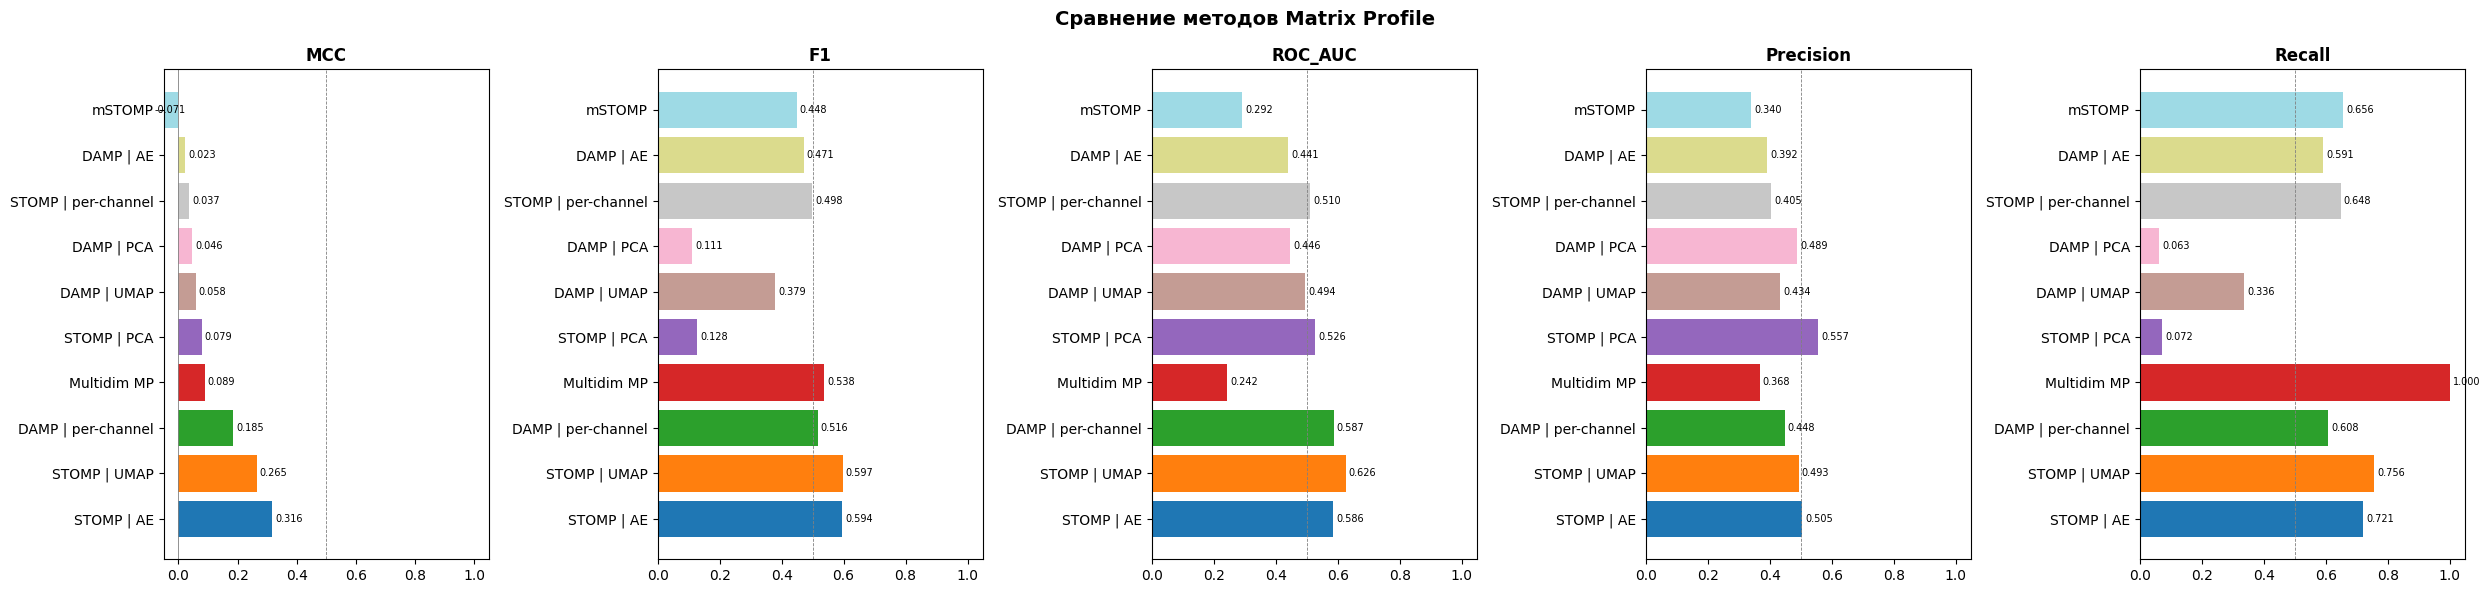

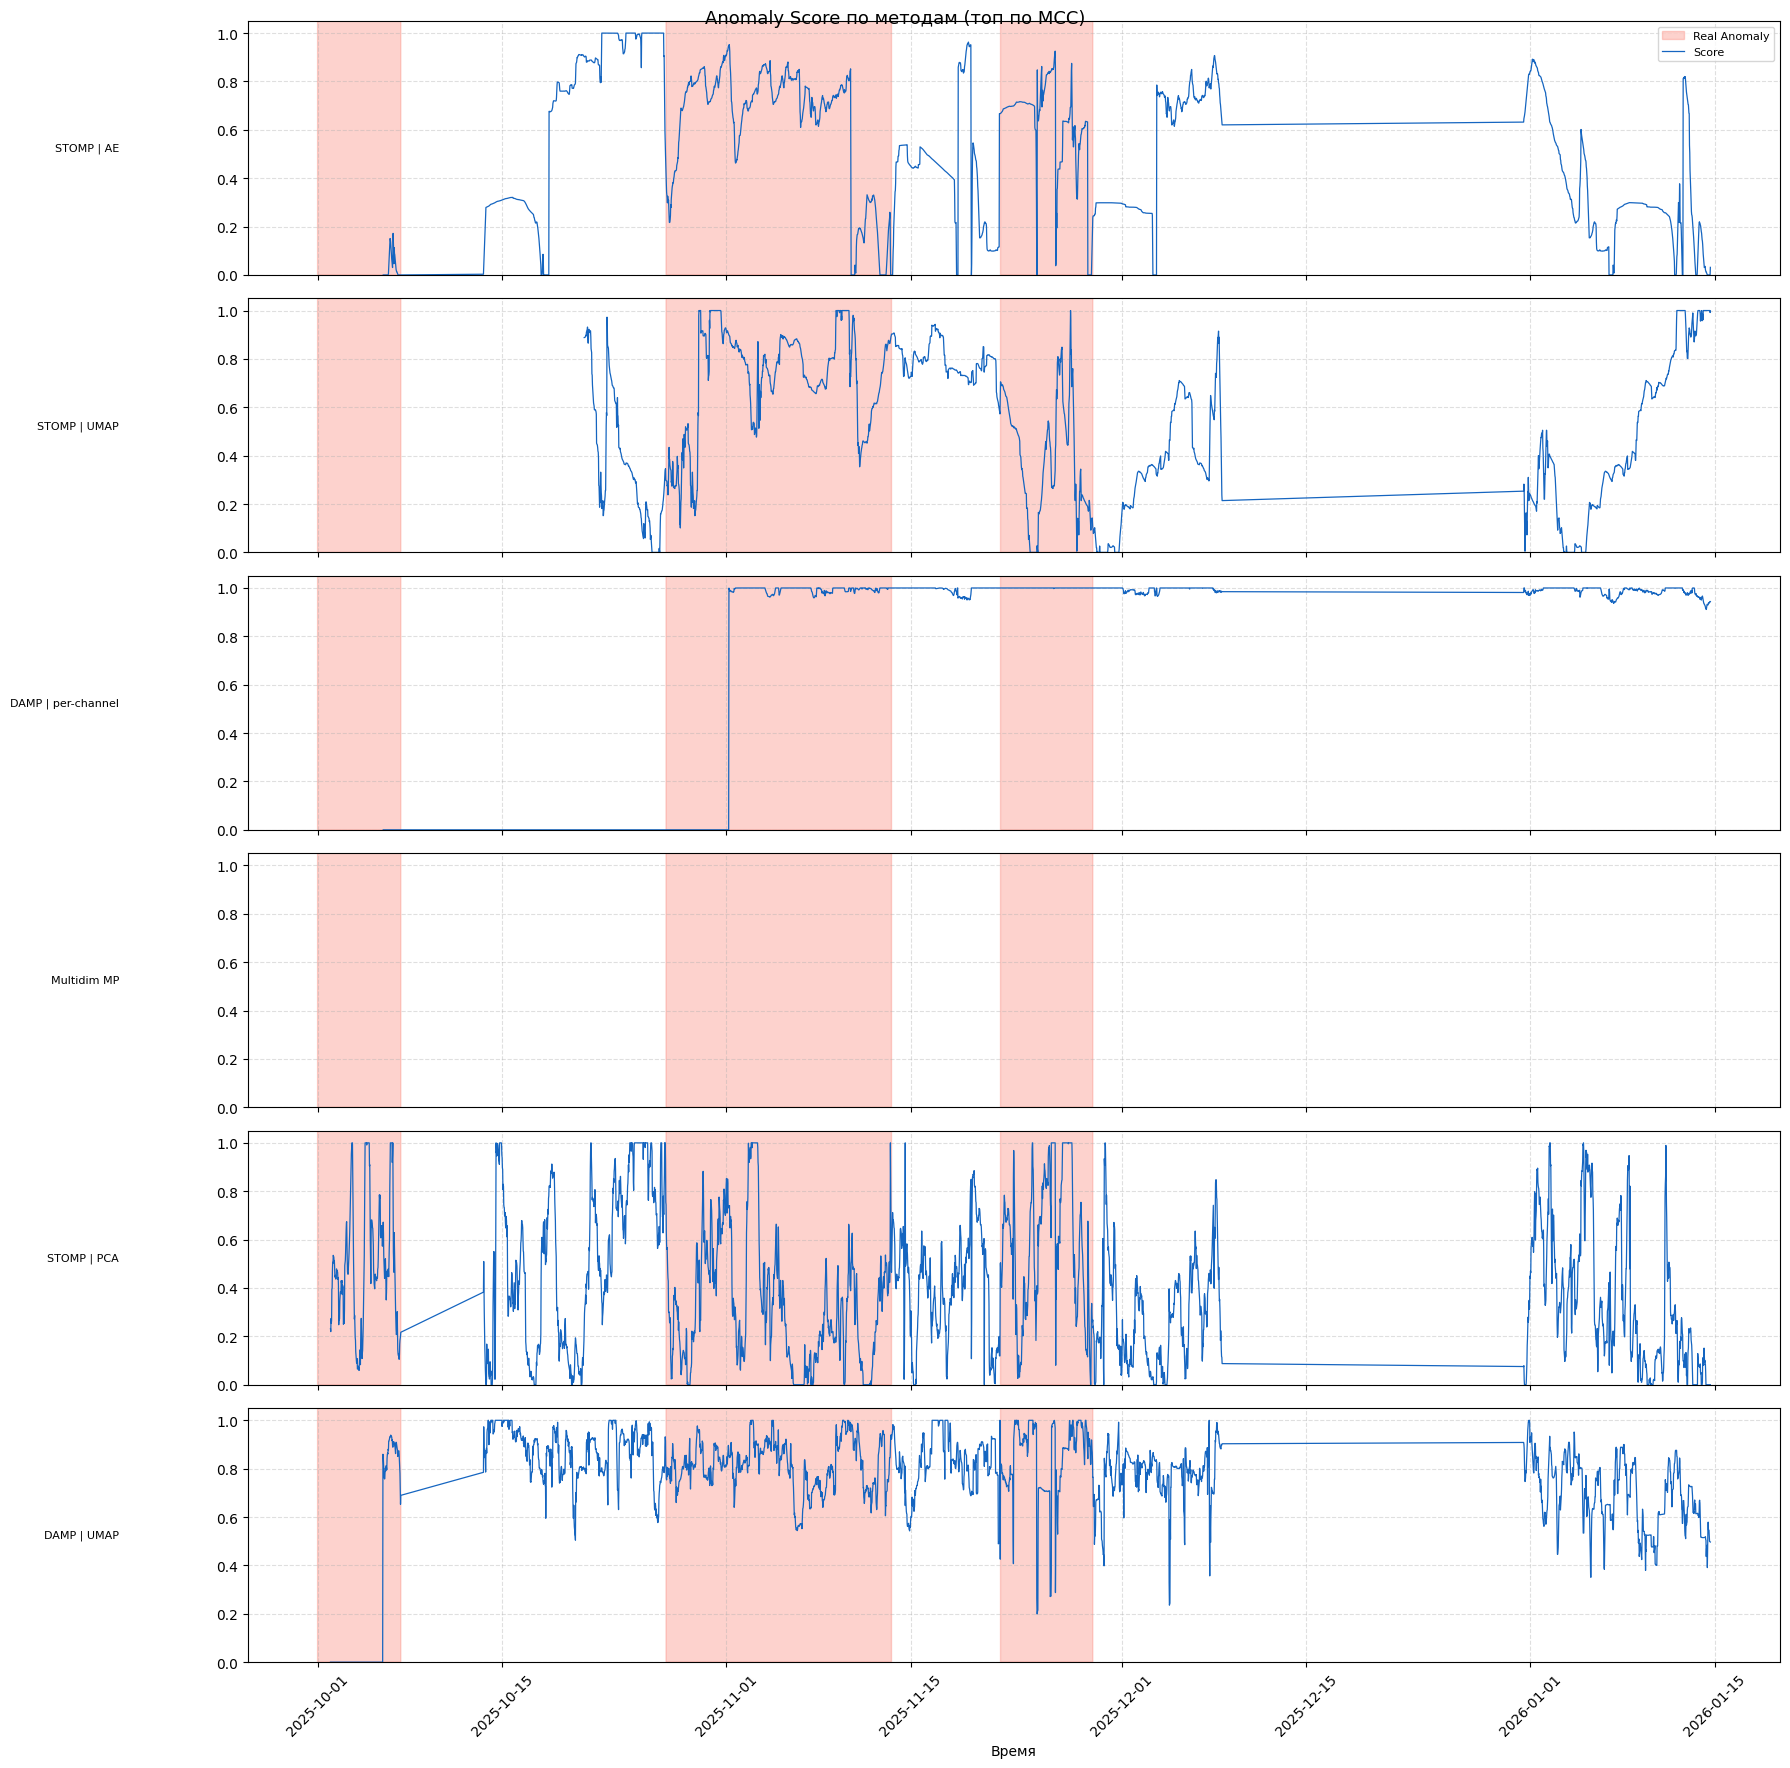

In [ ]:
# ─── Импорты ───────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import stumpy
from sklearn.decomposition import PCA
from sklearn.metrics import (
    matthews_corrcoef, f1_score, roc_auc_score,
    precision_score, recall_score, confusion_matrix, roc_curve
)

try:
    import umap as umap_lib
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False

try:
    import torch
    import torch.nn as nn
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False


# ─── Глобальные параметры ──────────────────────────────────────────────────
WINDOWS = [672]
RANDOM_STATE = 42
STEP_MINUTES = 30.0

import random

def fix_randomness(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    if TORCH_AVAILABLE:
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed(seed)
            torch.cuda.manual_seed_all(seed)
            torch.backends.cudnn.deterministic = True
            torch.backends.cudnn.benchmark = False

fix_randomness(RANDOM_STATE)


# ─── Лучшие признаки для каждой модели ───────────────────────────────────────

BEST_FEATURES = {
    "STOMP | per-channel": [
         'Температура компрессора', 'Температура фреона на линии нагнетания',
         'Температура в горячем коридоре', 'Температура фреона на входе в фильтр',
         'Температура фреона после ресивера', 'Температура фреона на выходе из фильтра',
         'Температура наружного воздуха', 'Коэффициент мощности компрессора',
         'Поток воздуха', 'Потребность в охлаждении', 'Давление на сбросе',
         'Дифференциальное давление воздушного фильтра', 'Положение клапана HGBP',
         'Температура воздуха на входе в кондиционер',
         'Температура воздуха на входе в кондиционер float', 'Активная мощность L2_PDU_1',
         'Напряжение L2_PDU_1', 'Активная мощность L3_PDU_2', 'Напряжение L3_PDU_2',
         'Температура переохлаждения фреона после ресивера', 'Активная мощность L3_PDU_1',
         'Напряжение L3_PDU_1', 'Активная мощность L2_PDU_2', 'Напряжение L2_PDU_2',
         'Активная мощность наружного блока', 'Частота наружного блока',
         'Температура фреона после конденсатора',
         'Активная мощность компрессора', 'Реактивная мощность компрессора'
    ],
    "STOMP | PCA": [
        'Температура компрессора', 'Температура фреона на линии нагнетания',
         'Температура в горячем коридоре', 'Температура фреона на входе в фильтр',
         'Температура фреона после ресивера', 'Температура фреона на выходе из фильтра',
         'Температура наружного воздуха', 'Коэффициент мощности компрессора',
         'Поток воздуха', 'Потребность в охлаждении', 'Давление на сбросе',
         'Дифференциальное давление воздушного фильтра', 'Положение клапана HGBP',
         'Температура воздуха на входе в кондиционер',
         'Температура воздуха на входе в кондиционер float', 'Активная мощность L2_PDU_1',
         'Напряжение L2_PDU_1', 'Активная мощность L3_PDU_2', 'Напряжение L3_PDU_2',
         'Температура переохлаждения фреона после ресивера', 'Активная мощность L3_PDU_1',
         'Напряжение L3_PDU_1', 'Активная мощность L2_PDU_2', 'Напряжение L2_PDU_2',
         'Активная мощность наружного блока', 'Частота наружного блока',
         'Температура фреона после конденсатора',
         'Активная мощность компрессора', 'Реактивная мощность компрессора'
    ],
    "STOMP | UMAP": [
        'Температура компрессора', 'Температура фреона на линии нагнетания',
         'Температура в горячем коридоре', 'Температура фреона на входе в фильтр',
         'Температура фреона после ресивера', 'Температура фреона на выходе из фильтра',
         'Температура наружного воздуха', 'Коэффициент мощности компрессора',
         'Поток воздуха', 'Потребность в охлаждении', 'Давление на сбросе',
         'Дифференциальное давление воздушного фильтра', 'Положение клапана HGBP',
         'Температура воздуха на входе в кондиционер',
         'Температура воздуха на входе в кондиционер float', 'Активная мощность L2_PDU_1',
         'Напряжение L2_PDU_1', 'Активная мощность L3_PDU_2', 'Напряжение L3_PDU_2',
         'Температура переохлаждения фреона после ресивера', 'Активная мощность L3_PDU_1',
         'Напряжение L3_PDU_1', 'Активная мощность L2_PDU_2', 'Напряжение L2_PDU_2',
         'Активная мощность наружного блока', 'Частота наружного блока',
         'Температура фреона после конденсатора',
         'Активная мощность компрессора', 'Реактивная мощность компрессора'
    ],
    "STOMP | AE": [
        'Температура компрессора', 'Температура фреона на линии нагнетания',
         'Температура в горячем коридоре', 'Температура фреона на входе в фильтр',
         'Температура фреона после ресивера', 'Температура фреона на выходе из фильтра',
         'Температура наружного воздуха', 'Коэффициент мощности компрессора',
         'Поток воздуха', 'Потребность в охлаждении', 'Давление на сбросе',
         'Дифференциальное давление воздушного фильтра', 'Положение клапана HGBP',
         'Температура воздуха на входе в кондиционер',
         'Температура воздуха на входе в кондиционер float', 'Активная мощность L2_PDU_1',
         'Напряжение L2_PDU_1', 'Активная мощность L3_PDU_2', 'Напряжение L3_PDU_2',
         'Температура переохлаждения фреона после ресивера', 'Активная мощность L3_PDU_1',
         'Напряжение L3_PDU_1', 'Активная мощность L2_PDU_2', 'Напряжение L2_PDU_2',
         'Активная мощность наружного блока', 'Частота наружного блока',
         'Температура фреона после конденсатора',
         'Активная мощность компрессора', 'Реактивная мощность компрессора'
    ],
    "DAMP | per-channel": [
        'Температура компрессора', 'Температура фреона на линии нагнетания',
         'Температура в горячем коридоре', 'Температура фреона на входе в фильтр',
         'Температура фреона после ресивера', 'Температура фреона на выходе из фильтра',
         'Температура наружного воздуха', 'Коэффициент мощности компрессора',
         'Поток воздуха', 'Потребность в охлаждении', 'Давление на сбросе',
         'Дифференциальное давление воздушного фильтра', 'Положение клапана HGBP',
         'Температура воздуха на входе в кондиционер',
         'Температура воздуха на входе в кондиционер float', 'Активная мощность L2_PDU_1',
         'Напряжение L2_PDU_1', 'Активная мощность L3_PDU_2', 'Напряжение L3_PDU_2',
         'Температура переохлаждения фреона после ресивера', 'Активная мощность L3_PDU_1',
         'Напряжение L3_PDU_1', 'Активная мощность L2_PDU_2', 'Напряжение L2_PDU_2',
         'Активная мощность наружного блока', 'Частота наружного блока',
         'Температура фреона после конденсатора',
         'Активная мощность компрессора', 'Реактивная мощность компрессора'
    ],
    "DAMP | PCA": [
         'Температура компрессора', 'Температура фреона на линии нагнетания',
         'Температура в горячем коридоре', 'Температура фреона на входе в фильтр',
         'Температура фреона после ресивера', 'Температура фреона на выходе из фильтра',
         'Температура наружного воздуха', 'Коэффициент мощности компрессора',
         'Поток воздуха', 'Потребность в охлаждении', 'Давление на сбросе',
         'Дифференциальное давление воздушного фильтра', 'Положение клапана HGBP',
         'Температура воздуха на входе в кондиционер',
         'Температура воздуха на входе в кондиционер float', 'Активная мощность L2_PDU_1',
         'Напряжение L2_PDU_1', 'Активная мощность L3_PDU_2', 'Напряжение L3_PDU_2',
         'Температура переохлаждения фреона после ресивера', 'Активная мощность L3_PDU_1',
         'Напряжение L3_PDU_1', 'Активная мощность L2_PDU_2', 'Напряжение L2_PDU_2',
         'Активная мощность наружного блока', 'Частота наружного блока',
         'Температура фреона после конденсатора',
         'Активная мощность компрессора', 'Реактивная мощность компрессора'
    ],
    "DAMP | UMAP": [
         'Температура компрессора', 'Температура фреона на линии нагнетания',
         'Температура в горячем коридоре', 'Температура фреона на входе в фильтр',
         'Температура фреона после ресивера', 'Температура фреона на выходе из фильтра',
         'Температура наружного воздуха', 'Коэффициент мощности компрессора',
         'Поток воздуха', 'Потребность в охлаждении', 'Давление на сбросе',
         'Дифференциальное давление воздушного фильтра', 'Положение клапана HGBP',
         'Температура воздуха на входе в кондиционер',
         'Температура воздуха на входе в кондиционер float', 'Активная мощность L2_PDU_1',
         'Напряжение L2_PDU_1', 'Активная мощность L3_PDU_2', 'Напряжение L3_PDU_2',
         'Температура переохлаждения фреона после ресивера', 'Активная мощность L3_PDU_1',
         'Напряжение L3_PDU_1', 'Активная мощность L2_PDU_2', 'Напряжение L2_PDU_2',
         'Активная мощность наружного блока', 'Частота наружного блока',
         'Температура фреона после конденсатора',
         'Активная мощность компрессора', 'Реактивная мощность компрессора'
    ],
    "DAMP | AE": [
         'Температура компрессора', 'Температура фреона на линии нагнетания',
         'Температура в горячем коридоре', 'Температура фреона на входе в фильтр',
         'Температура фреона после ресивера', 'Температура фреона на выходе из фильтра',
         'Температура наружного воздуха', 'Коэффициент мощности компрессора',
         'Поток воздуха', 'Потребность в охлаждении', 'Давление на сбросе',
         'Дифференциальное давление воздушного фильтра', 'Положение клапана HGBP',
         'Температура воздуха на входе в кондиционер',
         'Температура воздуха на входе в кондиционер float', 'Активная мощность L2_PDU_1',
         'Напряжение L2_PDU_1', 'Активная мощность L3_PDU_2', 'Напряжение L3_PDU_2',
         'Температура переохлаждения фреона после ресивера', 'Активная мощность L3_PDU_1',
         'Напряжение L3_PDU_1', 'Активная мощность L2_PDU_2', 'Напряжение L2_PDU_2',
         'Активная мощность наружного блока', 'Частота наружного блока',
         'Температура фреона после конденсатора',
         'Активная мощность компрессора', 'Реактивная мощность компрессора'
    ],
    "mSTOMP": [
         'Температура компрессора', 'Температура фреона на линии нагнетания',
         'Температура в горячем коридоре', 'Температура фреона на входе в фильтр',
         'Температура фреона после ресивера', 'Температура фреона на выходе из фильтра',
         'Температура наружного воздуха', 'Коэффициент мощности компрессора',
         'Поток воздуха', 'Потребность в охлаждении', 'Давление на сбросе',
         'Дифференциальное давление воздушного фильтра', 'Положение клапана HGBP',
         'Температура воздуха на входе в кондиционер',
         'Температура воздуха на входе в кондиционер float', 'Активная мощность L2_PDU_1',
         'Напряжение L2_PDU_1', 'Активная мощность L3_PDU_2', 'Напряжение L3_PDU_2',
         'Температура переохлаждения фреона после ресивера', 'Активная мощность L3_PDU_1',
         'Напряжение L3_PDU_1', 'Активная мощность L2_PDU_2', 'Напряжение L2_PDU_2',
         'Активная мощность наружного блока', 'Частота наружного блока',
         'Температура фреона после конденсатора',
         'Активная мощность компрессора', 'Реактивная мощность компрессора'
    ],
    "Multidim MP": [
         'Температура компрессора', 'Температура фреона на линии нагнетания',
         'Температура в горячем коридоре', 'Температура фреона на входе в фильтр',
         'Температура фреона после ресивера', 'Температура фреона на выходе из фильтра',
         'Температура наружного воздуха', 'Коэффициент мощности компрессора',
         'Поток воздуха', 'Потребность в охлаждении', 'Давление на сбросе',
         'Дифференциальное давление воздушного фильтра', 'Положение клапана HGBP',
         'Температура воздуха на входе в кондиционер',
         'Температура воздуха на входе в кондиционер float', 'Активная мощность L2_PDU_1',
         'Напряжение L2_PDU_1', 'Активная мощность L3_PDU_2', 'Напряжение L3_PDU_2',
         'Температура переохлаждения фреона после ресивера', 'Активная мощность L3_PDU_1',
         'Напряжение L3_PDU_1', 'Активная мощность L2_PDU_2', 'Напряжение L2_PDU_2',
         'Активная мощность наружного блока', 'Частота наружного блока',
         'Температура фреона после конденсатора',
         'Активная мощность компрессора', 'Реактивная мощность компрессора'
    ],
}


def select_features(df: pd.DataFrame, feature_list: list) -> pd.DataFrame:
    available = [f for f in feature_list if f in df.columns]
    missing   = [f for f in feature_list if f not in df.columns]
    if missing:
        print(f"   Признаки не найдены и пропущены: {missing}")
    return df[available]


# ─── Вспомогательные функции ───────────────────────────────────────────────

def binary_labels(y: pd.Series) -> np.ndarray:
    """'Anomaly' → 1, 'Normal' → 0"""
    return (y == "Anomaly").astype(int).values


def filter_normal(X: pd.DataFrame, y: pd.Series) -> pd.DataFrame:
    """
    Фильтрует датафрейм, оставляя только нормальные наблюдения.
    Используется для обучения — в реальности метки аномалий на train неизвестны,
    поэтому модель обучается только на нормальном поведении системы.
    """
    normal_mask = (y == "Normal").values
    n_total  = len(y)
    n_normal = normal_mask.sum()
    n_anomaly = n_total - n_normal
    print(f"  Фильтрация train: {n_total} → {n_normal} норм. "
          f"(удалено {n_anomaly} аномальных = {100*n_anomaly/n_total:.1f}%)")
    return X[normal_mask].reset_index(drop=True)


def robust_normalize(s: np.ndarray) -> np.ndarray:
    s = np.array(s, dtype=np.float64)
    s[np.isinf(s)] = np.nan
    if np.all(np.isnan(s)):
        return np.zeros_like(s)
    q_low  = np.nanpercentile(s, 5)
    q_high = np.nanpercentile(s, 95)
    if q_high - q_low < 1e-12:
        return np.zeros_like(s)
    s = (s - q_low) / (q_high - q_low)
    return np.clip(s, 0.0, 1.0)


def multiscale_max(profiles: list) -> np.ndarray:
    normed = [robust_normalize(p) for p in profiles]
    return np.nanmax(np.stack(normed, axis=0), axis=0)


def pad_profile(mp_raw: np.ndarray, n_total: int) -> np.ndarray:
    pad = n_total - len(mp_raw)
    if pad < 0:
        return mp_raw[-pad:]
    return np.concatenate([np.full(pad, np.nan), mp_raw])


def moving_average(x: np.ndarray, window: int = 5) -> np.ndarray:
    if window <= 1:
        return x.copy()
    out = np.full_like(x, np.nan, dtype=np.float64)
    for i in range(len(x)):
        lo = max(0, i - window // 2)
        hi = min(len(x), i + window // 2 + 1)
        segment = x[lo:hi]
        valid = segment[~np.isnan(segment)]
        if len(valid) > 0:
            out[i] = valid.mean()
    return out


def optimal_threshold_mcc(y_true: np.ndarray,
                           y_score: np.ndarray) -> tuple:
    mask = ~np.isnan(y_score)
    yt = y_true[mask]
    ys = y_score[mask]

    if len(np.unique(yt)) < 2 or len(np.unique(ys)) < 2:
        fallback_t = float(np.nanmedian(ys)) if len(ys) > 0 else 0.5
        return fallback_t, 0.0, np.array([0, 1]), np.array([0, 1]), np.array([fallback_t])

    fpr, tpr, thresholds = roc_curve(yt, ys)

    finite_mask = np.isfinite(thresholds)
    if not finite_mask.any():
        fallback_t = float(np.nanmedian(ys))
        return fallback_t, 0.0, fpr, tpr, thresholds

    thresholds_f = thresholds[finite_mask]
    best_mcc = -2.0
    best_t   = float(np.nanmedian(thresholds_f))

    for t in thresholds_f:
        pred = (ys >= t).astype(int)
        if pred.sum() == 0 or pred.sum() == len(pred):
            continue
        mcc = matthews_corrcoef(yt, pred)
        if mcc > best_mcc:
            best_mcc = mcc
            best_t   = t

    return best_t, best_mcc, fpr, tpr, thresholds


def compute_metrics(y_true: np.ndarray,
                    y_score_full: np.ndarray,
                    train_sec: float = 0.0,
                    infer_sec: float = 0.0,
                    step_minutes: float = STEP_MINUTES) -> dict:
    mask   = ~np.isnan(y_score_full)
    yt     = y_true[mask]
    ys     = y_score_full[mask]

    best_t, _, fpr_arr, tpr_arr, _ = optimal_threshold_mcc(yt, ys)
    y_pred = (ys >= best_t).astype(int)

    tn, fp, fn, tp = confusion_matrix(yt, y_pred, labels=[0, 1]).ravel()

    try:
        roc_auc = roc_auc_score(yt, ys)
    except Exception:
        roc_auc = float("nan")

    delay = compute_delay(yt, y_pred, step_minutes)

    return {
        "MCC":       matthews_corrcoef(yt, y_pred),
        "F1":        f1_score(yt, y_pred, zero_division=0),
        "ROC_AUC":   roc_auc,
        "Precision": precision_score(yt, y_pred, zero_division=0),
        "Recall":    recall_score(yt, y_pred, zero_division=0),
        "TP_rate":   tp / (tp + fn) if (tp + fn) > 0 else 0.0,
        "FP_rate":   fp / (fp + tn) if (fp + tn) > 0 else 0.0,
        "TN_rate":   tn / (tn + fp) if (tn + fp) > 0 else 0.0,
        "FN_rate":   fn / (fn + tp) if (fn + tp) > 0 else 0.0,
        "threshold": best_t,
        "Train_sec": train_sec,
        "Infer_sec": infer_sec,
        "Delay_min": delay,
        "_y_pred":   y_pred,
        "_y_score":  ys,
        "_mask":     mask,
    }


def compute_delay(y_true: np.ndarray, y_pred: np.ndarray,
                  step_minutes: float = STEP_MINUTES) -> float:
    delays = []
    in_anomaly  = False
    seg_start   = 0
    tp_found    = False

    for i in range(len(y_true)):
        if y_true[i] == 1 and not in_anomaly:
            in_anomaly = True
            seg_start  = i
            tp_found   = False
        if in_anomaly and not tp_found and y_pred[i] == 1:
            delays.append((i - seg_start) * step_minutes)
            tp_found = True
        if y_true[i] == 0:
            in_anomaly = False

    return float(np.mean(delays)) if delays else float("nan")


# ─── Стратегии редукции размерности ───────────────────────────────────────

class _PCAReducer:
    def fit(self, X_train_normal):
        # X_train_normal уже отфильтрован — только нормальные наблюдения
        n_comp = min(5, X_train_normal.shape[1])
        t0 = time.perf_counter()
        self.pca = PCA(n_components=n_comp, random_state=RANDOM_STATE)
        self.pca.fit(X_train_normal)
        return time.perf_counter() - t0

    def transform(self, X):
        return np.mean(self.pca.transform(X), axis=1)


class _UMAPReducer:
    def fit(self, X_train_normal):
        # X_train_normal уже отфильтрован — только нормальные наблюдения
        if not UMAP_AVAILABLE:
            raise ImportError("pip install umap-learn")
        t0 = time.perf_counter()
        self.reducer = umap_lib.UMAP(n_components=2, n_neighbors=15,
                                      min_dist=0.1, random_state=RANDOM_STATE)
        self.reducer.fit(X_train_normal)
        return time.perf_counter() - t0

    def transform(self, X):
        return np.linalg.norm(self.reducer.transform(X), axis=1)


class _AEReducer:
    def fit(self, X_train_normal):
        # X_train_normal уже отфильтрован — только нормальные наблюдения.
        # Автоэнкодер учится восстанавливать нормальное поведение,
        # поэтому на аномалиях reconstruction error будет выше.
        if not TORCH_AVAILABLE:
            raise ImportError("pip install torch")

        d      = X_train_normal.shape[1]
        hidden = max(8, d // 3)

        class SimpleAE(nn.Module):
            def __init__(self):
                super().__init__()
                self.encoder = nn.Linear(d, hidden)
                self.decoder = nn.Linear(hidden, d)
            def forward(self, x):
                return self.decoder(torch.relu(self.encoder(x)))

        self.model = SimpleAE()
        optimizer  = torch.optim.Adam(self.model.parameters(), lr=0.0005)
        loss_fn    = nn.MSELoss()

        X_t     = torch.tensor(X_train_normal, dtype=torch.float32)
        dataset = torch.utils.data.TensorDataset(X_t)

        generator = torch.Generator()
        generator.manual_seed(RANDOM_STATE)

        loader = torch.utils.data.DataLoader(
            dataset, batch_size=64, shuffle=True, generator=generator)

        t0 = time.perf_counter()
        self.model.train()
        for epoch in range(200):
            for (batch,) in loader:
                optimizer.zero_grad()
                loss = loss_fn(self.model(batch), batch)
                loss.backward()
                optimizer.step()
        self.model.eval()

        fit_sec = time.perf_counter() - t0
        print(f"AE обучён за {fit_sec:.1f} сек (hidden={hidden}, "
              f"samples={X_train_normal.shape[0]} норм.)")
        return fit_sec

    def transform(self, X):
        with torch.no_grad():
            X_t           = torch.tensor(X, dtype=torch.float32)
            reconstructed = self.model(X_t).numpy()
        return np.mean((X - reconstructed) ** 2, axis=1)


# ─── Вычисление профилей ───────────────────────────────────────────────────

def _extract_mp_values(mp_obj) -> np.ndarray:
    col = mp_obj[:, 0]
    if col.dtype.names is not None:
        col = col[col.dtype.names[0]]
    return np.array(col, dtype=np.float64)


def stomp_profiles(ts: np.ndarray, windows: list) -> list:
    result = []
    ts_f = np.asarray(ts, dtype=np.float64)
    for m in windows:
        if len(ts_f) <= m:
            print(f"   Пропущено окно m={m}: ряд слишком короткий ({len(ts_f)})")
            continue
        mp_raw = _extract_mp_values(stumpy.stump(ts_f, m=m))
        mp_raw[np.isinf(mp_raw)] = np.nan
        result.append((m, mp_raw))
    return result


def _mass_v2(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    m = len(y)
    n = len(x)

    if n < m:
        return np.array([np.inf])

    meany  = np.mean(y)
    sigmay = np.std(y)

    if sigmay < 1e-10:
        return np.full(n - m + 1, 0.0)

    x_prefix  = x[: m - 1]
    divider   = np.arange(1, len(x_prefix) + 1, dtype=np.float64)
    cumsum_   = x_prefix.cumsum()
    sq_cumsum = (x_prefix ** 2).cumsum()
    mean_prefix = cumsum_ / divider
    std_prefix  = np.sqrt(
        np.maximum((sq_cumsum - cumsum_ ** 2 / divider) / divider, 0.0))

    windows    = np.lib.stride_tricks.sliding_window_view(x, m)
    mean_full  = windows.mean(axis=1)
    std_full   = windows.std(axis=1)

    meanx  = np.concatenate([mean_prefix, mean_full])
    sigmax = np.concatenate([std_prefix,  std_full])

    y_rev = np.concatenate((y[::-1], np.zeros(n - m)))
    z     = np.fft.ifft(np.fft.fft(x) * np.fft.fft(y_rev)).real

    denom = sigmax[m - 1 : n] * sigmay
    denom = np.where(denom < 1e-10, 1e-10, denom)
    dist  = 2 * (m - (z[m - 1 : n] - m * meanx[m - 1 : n] * meany) / denom)
    return np.sqrt(np.maximum(dist, 0.0))


def _nextpow2(x: int) -> float:
    return np.ceil(np.log2(abs(x)))


def _damp_2_0(time_series: np.ndarray,
              subsequence_length: int,
              stride: int = 1,
              location_to_start_processing: int = None,
              lookahead: int = 0) -> np.ndarray:
    ts  = np.asarray(time_series, dtype=np.float64)
    n   = len(ts)
    m   = subsequence_length

    if location_to_start_processing is None:
        location_to_start_processing = max(m, 4 * m)

    if lookahead is None:
        lookahead = int(2 ** _nextpow2(16 * m))
    elif (lookahead != 0) and (lookahead != 2 ** _nextpow2(lookahead)):
        lookahead = int(2 ** _nextpow2(lookahead))

    if (location_to_start_processing / m) < 4:
        if location_to_start_processing < m:
            location_to_start_processing = m
    else:
        if location_to_start_processing > (n - m + 1):
            location_to_start_processing = n - m + 1

    left_mp     = np.zeros(n, dtype=np.float64)
    best_so_far = -np.inf
    bool_vec    = np.ones(n, dtype=np.float64)

    loc = location_to_start_processing

    for i in range(loc - 1, loc + 16 * m, stride):
        if not bool_vec[i]:
            left_mp[i] = left_mp[i - 1] - 1e-05
            continue

        if i + m - 1 > n:
            break

        query = ts[i : i + m]
        left_mp[i] = np.amin(_mass_v2(ts[:i], query)) if i > 0 else 0.0

        best_so_far = np.amax(left_mp)

        if lookahead != 0:
            start_of_mass = min(i + m - 1, n)
            end_of_mass   = min(start_of_mass + lookahead - 1, n)
            if (end_of_mass - start_of_mass + 1) > m:
                dp  = _mass_v2(ts[start_of_mass : end_of_mass + 1], query)
                bad = np.where(dp < best_so_far)[0] + start_of_mass
                bool_vec[bad] = 0

    for i in range(loc + 16 * m, n - m + 1, stride):
        if not bool_vec[i]:
            left_mp[i] = left_mp[i - 1] - 1e-05
            continue

        if i + m - 1 > n:
            break

        query         = ts[i : i + m]
        approx_dist   = np.inf
        X             = int(2 ** _nextpow2(8 * m))
        flag          = 1
        expansion_num = 0

        while approx_dist >= best_so_far:
            if i - X + 1 + expansion_num * m < 1:
                approx_dist = np.amin(_mass_v2(ts[: i + 1], query))
                left_mp[i]  = approx_dist
                if approx_dist > best_so_far:
                    best_so_far = approx_dist
                break

            if flag == 1:
                flag        = 0
                approx_dist = np.amin(_mass_v2(ts[i - X + 1 : i + 1], query))
            else:
                X_start     = i - X + 1 + expansion_num * m
                X_end       = i - X // 2 + expansion_num * m
                approx_dist = np.amin(
                    _mass_v2(ts[X_start : X_end + 1], query))

            if approx_dist < best_so_far:
                left_mp[i] = approx_dist
                break

            X             *= 2
            expansion_num += 1

        if lookahead != 0:
            start_of_mass = min(i + m, n)
            end_of_mass   = min(start_of_mass + lookahead - 1, n)
            if (end_of_mass - start_of_mass) > m:
                dp  = _mass_v2(ts[start_of_mass : end_of_mass + 1], query)
                bad = np.where(dp < best_so_far)[0] + start_of_mass
                bool_vec[bad] = 0

    return left_mp


def damp_profiles(ts: np.ndarray, windows: list,
                  stride: int = 1, lookahead: int = 0) -> list:
    result = []
    ts_f   = np.asarray(ts, dtype=np.float64)
    n      = len(ts_f)

    for m_req in windows:
        m = int(np.clip(m_req, 11, 1000))
        if n <= m + 1:
            continue

        loc = max(m, 4 * m)

        mp_raw = _damp_2_0(
            ts_f, m,
            stride=stride,
            location_to_start_processing=loc,
            lookahead=lookahead,
        )
        mp_out = mp_raw[:n - m + 1].copy().astype(np.float64)
        mp_out[np.isinf(mp_out)] = np.nan
        result.append((m, mp_out))

    return result


# ─── mSTOMP: профиль и подбор (m, k) ──────────────────────────────────────

def mstomp_profiles(X: np.ndarray, windows: list, k: int = None) -> list:
    result = []
    T = X.T.astype(np.float64)
    d = X.shape[1]

    for m in windows:
        if X.shape[0] <= m:
            print(f"   Пропущено окно m={m}: ряд слишком короткий")
            continue

        mmp, _ = stumpy.mstump(T, m=m)
        mmp    = np.array(mmp, dtype=np.float64)

        row    = (k - 1) if (k is not None) else (d - 1)
        row    = int(np.clip(row, 0, d - 1))

        mp_raw = mmp[row].copy()
        mp_raw[np.isinf(mp_raw)] = np.nan
        result.append((m, mp_raw))

    return result


def tune_window_multidim(X_val: np.ndarray,
                          y_val: np.ndarray,
                          candidate_windows: list) -> tuple:
    n_val    = len(y_val)
    d        = X_val.shape[1]
    best_m   = candidate_windows[0]
    best_k   = d
    best_mcc = -2.0

    for m in candidate_windows:
        if X_val.shape[0] <= m:
            continue

        T   = X_val.T.astype(np.float64)
        mmp, _ = stumpy.mstump(T, m=m)
        mmp = np.array(mmp, dtype=np.float64)

        for k in range(1, d + 1):
            mp_raw = mmp[k - 1].copy()
            mp_raw[np.isinf(mp_raw)] = np.nan
            score  = pad_profile(mp_raw, n_val)
            mask   = ~np.isnan(score)

            if mask.sum() < 2 or len(np.unique(y_val[mask])) < 2:
                continue

            _, mcc, _, _, _ = optimal_threshold_mcc(y_val[mask], score[mask])
            if mcc > best_mcc:
                best_mcc = mcc
                best_m   = m
                best_k   = k

    days = round(best_m * STEP_MINUTES / 60 / 24, 1)
    print(f"    tune→ m={best_m} ({days} сут), k={best_k}/{d}, MCC_val={best_mcc:.4f}")
    return best_m, best_k


# ─── Multidim MP согласно статье ─────────────────────────────────────────

def _znorm(x: np.ndarray) -> np.ndarray:
    mu  = x.mean()
    std = x.std()
    if std < 1e-10:
        return np.zeros_like(x)
    return (x - mu) / std


def _pairwise_distances_presort(
    T1: np.ndarray,
    T2: np.ndarray,
    m: int,
    exclusion_zone: int = None,
) -> np.ndarray:
    n1, d = T1.shape
    n2    = T2.shape[0]
    L1    = n1 - m + 1
    L2    = n2 - m + 1

    if exclusion_zone is None:
        exclusion_zone = m // 4

    presort_mp = np.full((d, L1), np.inf, dtype=np.float64)

    self_join = np.shares_memory(T1, T2) or (T1.shape == T2.shape and np.allclose(T1, T2))

    dist_matrices = []

    for dim in range(d):
        t1_dim = T1[:, dim].astype(np.float64)
        t2_dim = T2[:, dim].astype(np.float64)

        D_dim = np.empty((L1, L2), dtype=np.float64)
        for i in range(L1):
            query = t1_dim[i: i + m]
            D_dim[i] = stumpy.core.mass(query, t2_dim)

        D_dim = np.clip(D_dim, 0.0, None)
        dist_matrices.append(D_dim)

    D_tensor = np.stack(dist_matrices, axis=2)  # (L1, L2, d)

    for i in range(L1):
        if self_join:
            lo = max(0, i - exclusion_zone)
            hi = min(L2, i + exclusion_zone + 1)
            D_i = D_tensor[i].copy()
            D_i[lo:hi, :] = np.inf
        else:
            D_i = D_tensor[i]

        sorted_D_i = np.sort(D_i, axis=1)[:, ::-1]

        for k in range(d):
            valid = sorted_D_i[:, k]
            valid = valid[~np.isinf(valid)]
            if len(valid) > 0:
                presort_mp[k, i] = valid.min()

    presort_mp[np.isinf(presort_mp)] = np.nan
    return presort_mp


def multidim_mp_paper(
    X_test:  np.ndarray,
    X_train: np.ndarray,
    m:       int,
    k_nn:    int = 1,
    join_type: str = "ab",
    ma_window: int = 5,
) -> np.ndarray:
    """
    Multidimensional Matrix Profile согласно статье.
    X_train здесь содержит ТОЛЬКО нормальные наблюдения (уже отфильтрован).
    AB-join (join_type="ab") ищет паттерны теста в нормальном трейне —
    высокое расстояние означает, что паттерн не встречался в норме → аномалия.
    """
    d = X_test.shape[1]

    if join_type == "ab":
        T1 = X_test
        T2 = X_train      # только нормальные данные
        excl = None
    else:
        # self-join: конкатенируем нормальный трейн с тестом
        T1 = np.concatenate([X_train, X_test], axis=0)
        T2 = T1
        excl = m // 4

    n_test = X_test.shape[0]

    if T1.shape[0] <= m or T2.shape[0] <= m:
        print(f"   Multidim MP: ряд слишком короткий для m={m}")
        return np.full(n_test, np.nan)

    presort_mp = _pairwise_distances_presort(T1, T2, m, exclusion_zone=excl)
    mp_dim0    = presort_mp[0]

    if k_nn > 1:
        pct = min(100.0, k_nn * 100.0 / max(len(mp_dim0), 1))
        mp_dim0 = mp_dim0.copy()
        global_shift = np.nanpercentile(mp_dim0, pct)
        mp_dim0 = np.where(mp_dim0 < global_shift, global_shift, mp_dim0)
        print(f"  k-NN аппроксимация: k={k_nn}, global_shift={global_shift:.4f}")

    if join_type == "self":
        n_train = X_train.shape[0]
        L_total = len(mp_dim0)
        L_test  = L_total - n_train
        if L_test > 0:
            score_raw = mp_dim0[n_train: n_train + L_test]
        else:
            score_raw = mp_dim0[-1:]
    else:
        score_raw = mp_dim0

    score_padded = pad_profile(score_raw, n_test)
    score_smooth = moving_average(score_padded, window=ma_window)

    return score_smooth


def tune_window_multidim_paper(
    X_val:             np.ndarray,
    X_train:           np.ndarray,
    y_val:             np.ndarray,
    candidate_windows: list,
    k_nn:              int = 1,
    join_type:         str = "ab",
    ma_window:         int = 5,
) -> int:
    """
    Подбор оптимального m для Multidim MP.
    X_train содержит только нормальные наблюдения (уже отфильтрован).
    """
    n_val    = len(y_val)
    best_m   = candidate_windows[0]
    best_mcc = -2.0

    for m in candidate_windows:
        if X_val.shape[0] <= m or X_train.shape[0] <= m:
            continue

        score = multidim_mp_paper(
            X_test=X_val,
            X_train=X_train,
            m=m,
            k_nn=k_nn,
            join_type=join_type,
            ma_window=ma_window,
        )

        mask = ~np.isnan(score)
        if mask.sum() < 2 or len(np.unique(y_val[mask])) < 2:
            continue

        _, mcc, _, _, _ = optimal_threshold_mcc(y_val[mask], score[mask])
        if mcc > best_mcc:
            best_mcc = mcc
            best_m   = m

    days = round(best_m * STEP_MINUTES / 60 / 24, 1)
    print(f"    tune→ m={best_m} ({days} сут), MCC_val={best_mcc:.4f}")
    return best_m


# ─── 6. Подбор окна для одномерных методов ───────────────────────────────────

def tune_window(profile_fn, ts_val, y_val, candidate_windows,
                profile_kwargs=None):
    if profile_kwargs is None:
        profile_kwargs = {}
    n_val    = len(y_val)
    best_m   = candidate_windows[0]
    best_mcc = -2.0

    for m in candidate_windows:
        profs = profile_fn(ts_val, [m], **profile_kwargs)
        if not profs:
            continue
        padded = [pad_profile(mp, n_val) for _, mp in profs]
        score  = multiscale_max(padded)
        mask   = ~np.isnan(score)
        if mask.sum() < 2 or len(np.unique(y_val[mask])) < 2:
            continue
        _, mcc, _, _, _ = optimal_threshold_mcc(y_val[mask], score[mask])
        if mcc > best_mcc:
            best_mcc = mcc
            best_m   = m

    days = round(best_m * STEP_MINUTES / 60 / 24, 1)
    print(f"    tune→ m={best_m} ({days} сут), MCC_val={best_mcc:.4f}")
    return best_m


def tune_window_per_channel(profile_fn, X_val, y_val, candidate_windows,
                             profile_kwargs=None):
    if profile_kwargs is None:
        profile_kwargs = {}
    n_val    = len(y_val)
    best_m   = candidate_windows[0]
    best_mcc = -2.0

    for m in candidate_windows:
        ch_profs = []
        for ch in range(X_val.shape[1]):
            ch_profs.extend(profile_fn(X_val[:, ch], [m], **profile_kwargs))
        if not ch_profs:
            continue
        padded = [pad_profile(mp, n_val) for _, mp in ch_profs]
        score  = multiscale_max(padded)
        mask   = ~np.isnan(score)
        if mask.sum() < 2 or len(np.unique(y_val[mask])) < 2:
            continue
        _, mcc, _, _, _ = optimal_threshold_mcc(y_val[mask], score[mask])
        if mcc > best_mcc:
            best_mcc = mcc
            best_m   = m

    days = round(best_m * STEP_MINUTES / 60 / 24, 1)
    print(f"    tune→ m={best_m} ({days} сут), MCC_val={best_mcc:.4f}")
    return best_m


# ─── Общий pipeline для одного метода ─────────────────────────────────────

def run_one_method(name, raw_profiles, n_total, y_true,
                   train_sec, infer_sec):
    padded      = [pad_profile(mp, n_total) for _, mp in raw_profiles]
    final_score = multiscale_max(padded)

    metrics              = compute_metrics(y_true, final_score,
                                           train_sec=train_sec,
                                           infer_sec=infer_sec)
    metrics["name"]      = name
    metrics["_profiles"] = raw_profiles
    metrics["_score"]    = final_score
    return metrics


# ─── Основной блок экспериментов ──────────────────────────────────────────

def run_all_experiments(
    X_train_scaled:  pd.DataFrame,
    X_val_scaled:    pd.DataFrame,
    X_test_scaled:   pd.DataFrame,
    y_train:         pd.Series,
    y_val:           pd.Series,
    y_test:          pd.Series,
    candidate_windows: list = None,
    damp_stride:     int   = 1,
    damp_lookahead:  int   = 0,
    mmpad_k_nn:      int   = 1,
    mmpad_join:      str   = "ab",
    mmpad_ma_window: int   = 5,
) -> tuple:

    if candidate_windows is None:
        candidate_windows = [48, 96, 144, 240, 336, 480, 672, 1000]

    damp_candidates = sorted(set(
        int(np.clip(m, 11, 1000)) for m in candidate_windows
    ))

    y_va = binary_labels(y_val)
    y_te = binary_labels(y_test)
    n_te = len(y_te)

    results    = []
    all_scores = {}
    damp_kw    = {"stride": damp_stride, "lookahead": damp_lookahead}

    # ── Фильтрация train: оставляем только нормальные наблюдения ──────────────
    # Это центральное изменение — в реальности у нас нет аномальных меток
    # на этапе обучения, поэтому обучаем только на нормальном поведении.
    print("=" * 60)
    print("Фильтрация обучающей выборки (только Normal)")
    print("=" * 60)
    X_train_normal = filter_normal(X_train_scaled, y_train)
    print(f"  X_train_normal: {X_train_normal.shape}")

    def _get_arrays(method_name):
        """
        Возвращает (X_tr_normal, X_val, X_te) с отобранными признаками.
        X_tr_normal — уже отфильтрованный по меткам train (только Normal).
        """
        feats = BEST_FEATURES.get(method_name)
        if feats is None:
            return (X_train_normal.values.astype(np.float64),
                    X_val_scaled.values.astype(np.float64),
                    X_test_scaled.values.astype(np.float64))
        X_tr_f  = select_features(X_train_normal, feats).values.astype(np.float64)
        X_val_f = select_features(X_val_scaled,   feats).values.astype(np.float64)
        X_te_f  = select_features(X_test_scaled,  feats).values.astype(np.float64)
        return X_tr_f, X_val_f, X_te_f

    def _run(name, profile_fn, reducer_cls=None, profile_kwargs=None,
             cand_windows=None):
        if profile_kwargs is None:
            profile_kwargs = {}
        if cand_windows is None:
            cand_windows = candidate_windows

        print(f"▶ {name}")

        X_tr, X_val, X_te = _get_arrays(name)
        print(f"  Признаков: {X_tr.shape[1]}, train (норма): {X_tr.shape[0]}")

        if reducer_cls is None:
            ts_val_1d = None
            ts_te_1d  = None
            train_sec = 0.0
        else:
            reducer   = reducer_cls()
            train_sec = reducer.fit(X_tr)
            ts_val_1d = reducer.transform(X_val)
            ts_te_1d  = reducer.transform(X_te)

        if ts_val_1d is None:
            best_m = tune_window_per_channel(
                profile_fn, X_val, y_va, cand_windows, profile_kwargs)
        else:
            best_m = tune_window(
                profile_fn, ts_val_1d, y_va, cand_windows, profile_kwargs)

        t0 = time.perf_counter()
        if ts_te_1d is None:
            raw_profs = []
            for ch in range(X_te.shape[1]):
                raw_profs.extend(
                    profile_fn(X_te[:, ch], [best_m], **profile_kwargs))
        else:
            raw_profs = profile_fn(ts_te_1d, [best_m], **profile_kwargs)
        infer_sec = time.perf_counter() - t0

        if not raw_profs:
            print(f"  ✗ нет профилей")
            return

        metrics            = run_one_method(name, raw_profs, n_te, y_te,
                                            train_sec, infer_sec)
        metrics["best_m"] = best_m
        results.append(metrics)
        all_scores[name]   = metrics["_score"]
        print(f"  m={best_m}  MCC={metrics['MCC']:.4f}  F1={metrics['F1']:.4f}"
              f"  AUC={metrics['ROC_AUC']:.4f}  thr={metrics['threshold']:.4f}")

    # ─────────────────────────────────────────────────────────────────────────
    # A. STOMP
    # ─────────────────────────────────────────────────────────────────────────
    print("\n" + "=" * 60)
    print("STOMP")
    print("=" * 60)

    _run("STOMP | per-channel", stomp_profiles)
    _run("STOMP | PCA",         stomp_profiles, _PCAReducer)
    if UMAP_AVAILABLE:
        _run("STOMP | UMAP",    stomp_profiles, _UMAPReducer)
    if TORCH_AVAILABLE:
        _run("STOMP | AE",      stomp_profiles, _AEReducer)

    # ─────────────────────────────────────────────────────────────────────────
    # B. DAMP 2.0
    # ─────────────────────────────────────────────────────────────────────────
    print("\n" + "=" * 60)
    print(f"DAMP 2.0  (stride={damp_stride}, lookahead={damp_lookahead})")
    print(f"Пул окон DAMP (клип 11–1000): {damp_candidates}")
    print("=" * 60)

    _run("DAMP | per-channel", damp_profiles,
         profile_kwargs=damp_kw, cand_windows=damp_candidates)
    _run("DAMP | PCA",         damp_profiles, _PCAReducer,
         profile_kwargs=damp_kw, cand_windows=damp_candidates)
    if UMAP_AVAILABLE:
        _run("DAMP | UMAP",    damp_profiles, _UMAPReducer,
             profile_kwargs=damp_kw, cand_windows=damp_candidates)
    if TORCH_AVAILABLE:
        _run("DAMP | AE",      damp_profiles, _AEReducer,
             profile_kwargs=damp_kw, cand_windows=damp_candidates)

    # ─────────────────────────────────────────────────────────────────────────
    # C. mSTOMP — post-sorting через stumpy.mstump
    # Примечание: mSTOMP работает на тестовых данных (self-join на X_te).
    # X_tr_normal используется только для обучения reducers (здесь не применяется).
    # ─────────────────────────────────────────────────────────────────────────
    print("\n" + "=" * 60)
    print("mSTOMP (stumpy.mstump, post-sorting, автоподбор k)")
    print("=" * 60)

    print("▶ mSTOMP")
    X_tr_ms, X_val_ms, X_te_ms = _get_arrays("mSTOMP")
    print(f"  Признаков: {X_tr_ms.shape[1]}, train (норма): {X_tr_ms.shape[0]}")

    best_m_ms, best_k_ms = tune_window_multidim(X_val_ms, y_va, candidate_windows)

    t0       = time.perf_counter()
    ms_profs = mstomp_profiles(X_te_ms, [best_m_ms], k=best_k_ms)
    infer_sec = time.perf_counter() - t0

    if ms_profs:
        metrics            = run_one_method("mSTOMP", ms_profs, n_te, y_te,
                                            train_sec=0.0, infer_sec=infer_sec)
        metrics["best_m"] = best_m_ms
        metrics["best_k"] = best_k_ms
        results.append(metrics)
        all_scores["mSTOMP"] = metrics["_score"]
        print(f"  m={best_m_ms}  k={best_k_ms}  MCC={metrics['MCC']:.4f}  "
              f"F1={metrics['F1']:.4f}  AUC={metrics['ROC_AUC']:.4f}")

    # ─────────────────────────────────────────────────────────────────────────
    # D. Multidim MP — строго по статье
    #    Pre-sorting + dim[0] + k-NN + AB-join (тест к нормальному трейну) + MA
    #    AB-join здесь особенно корректен: T2 = только нормальные данные,
    #    поэтому высокое расстояние = паттерн не встречается в норме = аномалия.
    # ─────────────────────────────────────────────────────────────────────────
    print("\n" + "=" * 60)
    print("Multidim MP (статья: pre-sorting, dim[0], k-NN, AB-join, MA)")
    print(f"  k_nn={mmpad_k_nn}, join={mmpad_join}, ma_window={mmpad_ma_window}")
    print("=" * 60)

    print("▶ Multidim MP")
    X_tr_md, X_val_md, X_te_md = _get_arrays("Multidim MP")
    print(f"  Признаков: {X_tr_md.shape[1]}, train (норма): {X_tr_md.shape[0]}")

    best_m_md = tune_window_multidim_paper(
        X_val=X_val_md,
        X_train=X_tr_md,
        y_val=y_va,
        candidate_windows=candidate_windows,
        k_nn=mmpad_k_nn,
        join_type=mmpad_join,
        ma_window=mmpad_ma_window,
    )

    t0 = time.perf_counter()
    score_md = multidim_mp_paper(
        X_test=X_te_md,
        X_train=X_tr_md,
        m=best_m_md,
        k_nn=mmpad_k_nn,
        join_type=mmpad_join,
        ma_window=mmpad_ma_window,
    )
    infer_sec = time.perf_counter() - t0

    metrics_md = compute_metrics(y_te, score_md, train_sec=0.0, infer_sec=infer_sec)
    metrics_md["name"]    = "Multidim MP"
    metrics_md["best_m"]  = best_m_md
    metrics_md["best_k"]  = 1
    metrics_md["_score"]  = score_md
    metrics_md["_profiles"] = [(best_m_md, score_md)]

    results.append(metrics_md)
    all_scores["Multidim MP"] = score_md

    print(f"  m={best_m_md}  k_nn={mmpad_k_nn}  "
          f"MCC={metrics_md['MCC']:.4f}  "
          f"F1={metrics_md['F1']:.4f}  "
          f"AUC={metrics_md['ROC_AUC']:.4f}")

    # ─────────────────────────────────────────────────────────────────────────
    # Сводная таблица
    # ─────────────────────────────────────────────────────────────────────────
    COLS = ["name", "best_m", "best_k", "MCC", "F1", "ROC_AUC",
            "Precision", "Recall",
            "TP_rate", "FP_rate", "TN_rate", "FN_rate",
            "threshold", "Train_sec", "Infer_sec", "Delay_min"]

    df_out = pd.DataFrame([
        {c: r.get(c, float("nan")) for c in COLS} for r in results
    ])
    df_out = df_out.sort_values("MCC", ascending=False).reset_index(drop=True)

    print("\n" + "=" * 80)
    print("ИТОГОВАЯ ТАБЛИЦА МЕТРИК")
    print("=" * 80)
    print(df_out.to_string(index=False, float_format="%.4f"))

    return df_out, all_scores


# ─── Визуализация ─────────────────────────────────────────────────────────

def plot_bar_metrics(df_results: pd.DataFrame, save_path: str = None) -> None:
    metrics = ["MCC", "F1", "ROC_AUC", "Precision", "Recall"]
    fig, axes = plt.subplots(
        1, len(metrics),
        figsize=(5 * len(metrics), max(6, len(df_results) * 0.4 + 1)))
    colors = plt.cm.tab20(np.linspace(0, 1, len(df_results)))

    for ax, m in zip(axes, metrics):
        vals = df_results[m].values
        bars = ax.barh(df_results["name"], vals, color=colors)
        ax.set_xlim(-0.05 if m == "MCC" else 0, 1.05)
        ax.axvline(0, color="gray", linewidth=0.6)
        ax.axvline(0.5, color="gray", linestyle="--", linewidth=0.6)
        ax.set_title(m, fontsize=12, fontweight="bold")
        for bar, val in zip(bars, vals):
            x = val + 0.01 if val >= 0 else val - 0.01
            ax.text(x, bar.get_y() + bar.get_height() / 2,
                    f"{val:.3f}", va="center", fontsize=7)

    plt.suptitle("Сравнение методов Matrix Profile", fontsize=14, fontweight="bold")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Сохранено: {save_path}")
    plt.show()


def plot_scores_timeline(all_scores: dict,
                          y_true: np.ndarray,
                          dates: np.ndarray = None,
                          top_n: int = 6,
                          df_results: pd.DataFrame = None,
                          save_path: str = None) -> None:
    if df_results is not None:
        order = df_results["name"].tolist()
    else:
        order = list(all_scores.keys())

    top_names = [n for n in order if n in all_scores][:top_n]
    n_plots   = len(top_names)
    if n_plots == 0:
        return

    x = dates if dates is not None else np.arange(len(y_true))
    fig, axes = plt.subplots(n_plots, 1,
                              figsize=(18, 3 * n_plots), sharex=True)
    if n_plots == 1:
        axes = [axes]

    for ax, name in zip(axes, top_names):
        score = all_scores[name]
        ax.fill_between(x, 0, 1, where=(y_true == 1),
                        color="salmon", alpha=0.35, step="pre",
                        transform=ax.get_xaxis_transform(),
                        label="Real Anomaly")
        ax.plot(x, score, color="#1565C0", linewidth=0.9, label="Score")
        ax.set_ylabel(name, fontsize=8, rotation=0,
                      ha="right", va="center", labelpad=70)
        ax.set_ylim(0, 1.05)
        ax.grid(True, linestyle="--", alpha=0.4)

    axes[0].legend(loc="upper right", fontsize=8)
    if dates is not None:
        axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
        plt.xticks(rotation=45)
    axes[-1].set_xlabel("Время")
    plt.suptitle("Anomaly Score по методам (топ по MCC)", fontsize=13)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


# ─── Точка входа ──────────────────────────────────────────────────────────

if __name__ == "__main__":
    _ = X_train_scaled
    _ = X_val_scaled
    _ = X_test_scaled
    _ = y_train
    _ = y_val
    _ = y_test
    dates_test = test_df["Time"].values if "test_df" in dir() else None

    candidate_windows = [48, 96, 144, 240, 336, 480, 672]

    df_results, all_scores = run_all_experiments(
        X_train_scaled=X_train_scaled,
        X_val_scaled=X_val_scaled,
        X_test_scaled=X_test_scaled,
        y_train=y_train,
        y_val=y_val,
        y_test=y_test,
        candidate_windows=candidate_windows,
        damp_stride=1,
        damp_lookahead=0,
        mmpad_k_nn=1,
        mmpad_join="ab",
        mmpad_ma_window=5,
    )

    plot_bar_metrics(df_results, save_path=None)

    y_te_bin = binary_labels(y_test)
    plot_scores_timeline(
        all_scores,
        y_true=y_te_bin,
        dates=dates_test,
        top_n=6,
        df_results=df_results,
        save_path=None,
    )

## Признаки отобраны под модель. Обучение только на нормальных данных

Фильтрация обучающей выборки (только Normal)
  Фильтрация train: 5652 → 1526 норм. (удалено 4126 аномальных = 73.0%)
  X_train_normal: (1526, 60)

STOMP
▶ STOMP | per-channel
  Признаков: 3, train (норма): 1526
    tune→ m=336 (7.0 сут), MCC_val=0.8793
  m=336  MCC=0.3262  F1=0.5936  AUC=0.6816  thr=0.5554
▶ STOMP | PCA
  Признаков: 3, train (норма): 1526
    tune→ m=672 (14.0 сут), MCC_val=0.3570
  m=672  MCC=0.2013  F1=0.5114  AUC=0.5456  thr=0.6768
▶ STOMP | UMAP
  Признаков: 3, train (норма): 1526
    tune→ m=480 (10.0 сут), MCC_val=0.5006
  m=480  MCC=0.7766  F1=0.8271  AUC=0.9253  thr=0.9465
▶ STOMP | AE
  Признаков: 3, train (норма): 1526
AE обучён за 3.5 сек (hidden=8, samples=1526 норм.)
    tune→ m=48 (1.0 сут), MCC_val=0.4218
  m=48  MCC=-0.0935  F1=0.5253  AUC=0.3296  thr=0.0503

DAMP 2.0  (stride=1, lookahead=0)
Пул окон DAMP (клип 11–1000): [48, 96, 144, 240, 336, 480, 672]
▶ DAMP | per-channel
  Признаков: 3, train (норма): 1526
    tune→ m=48 (1.0 сут), MCC_val=0.0750
 

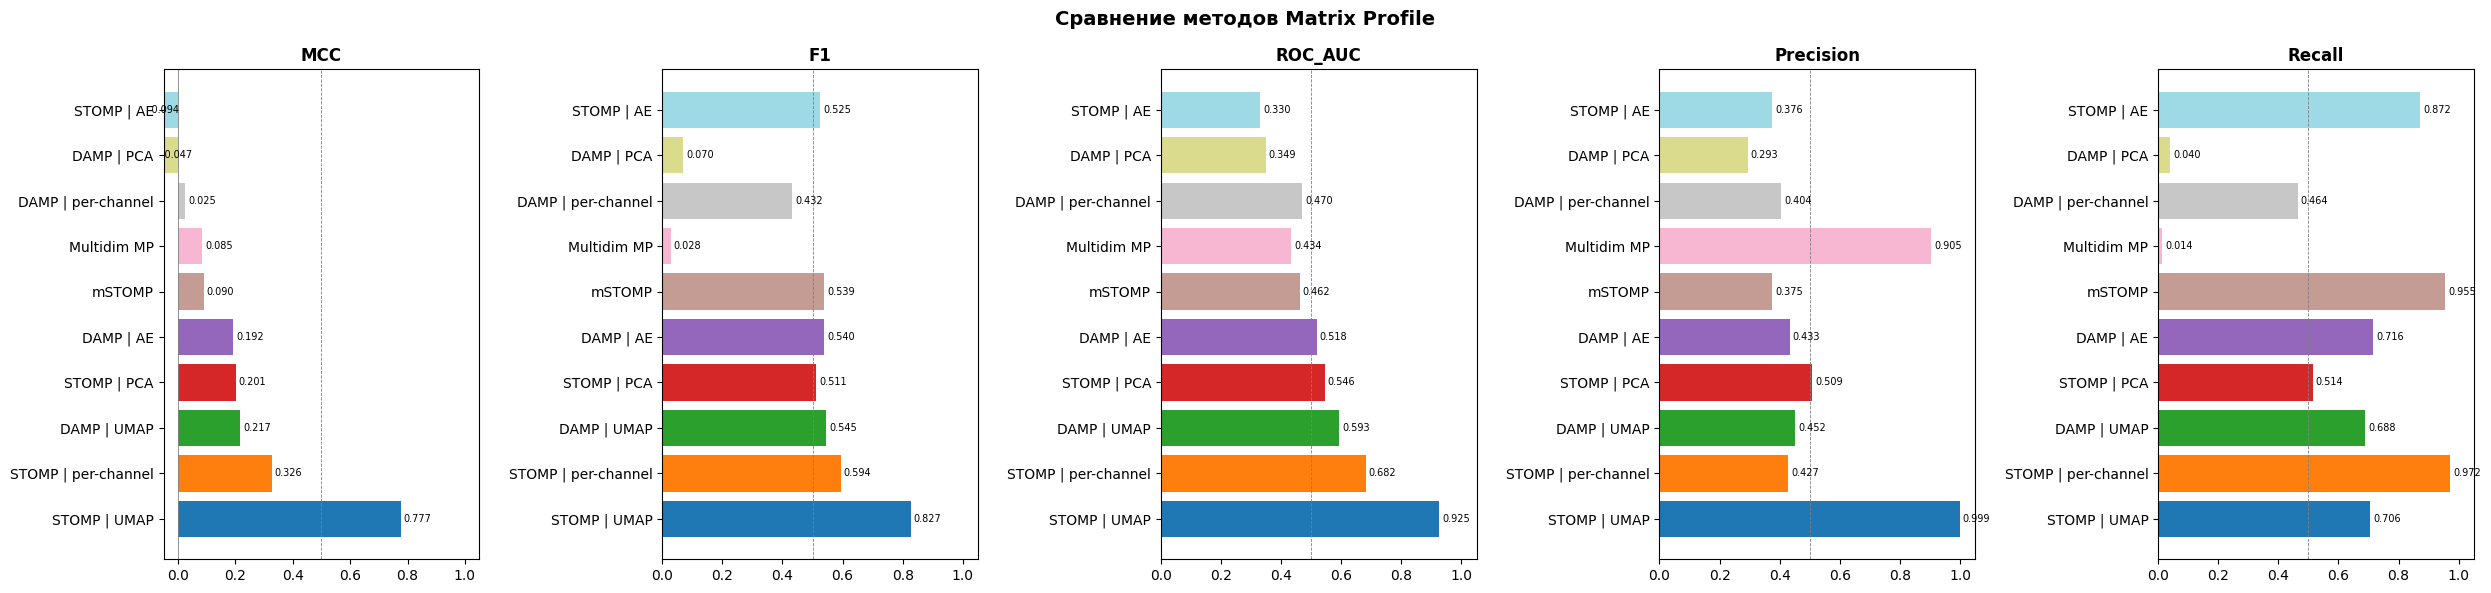

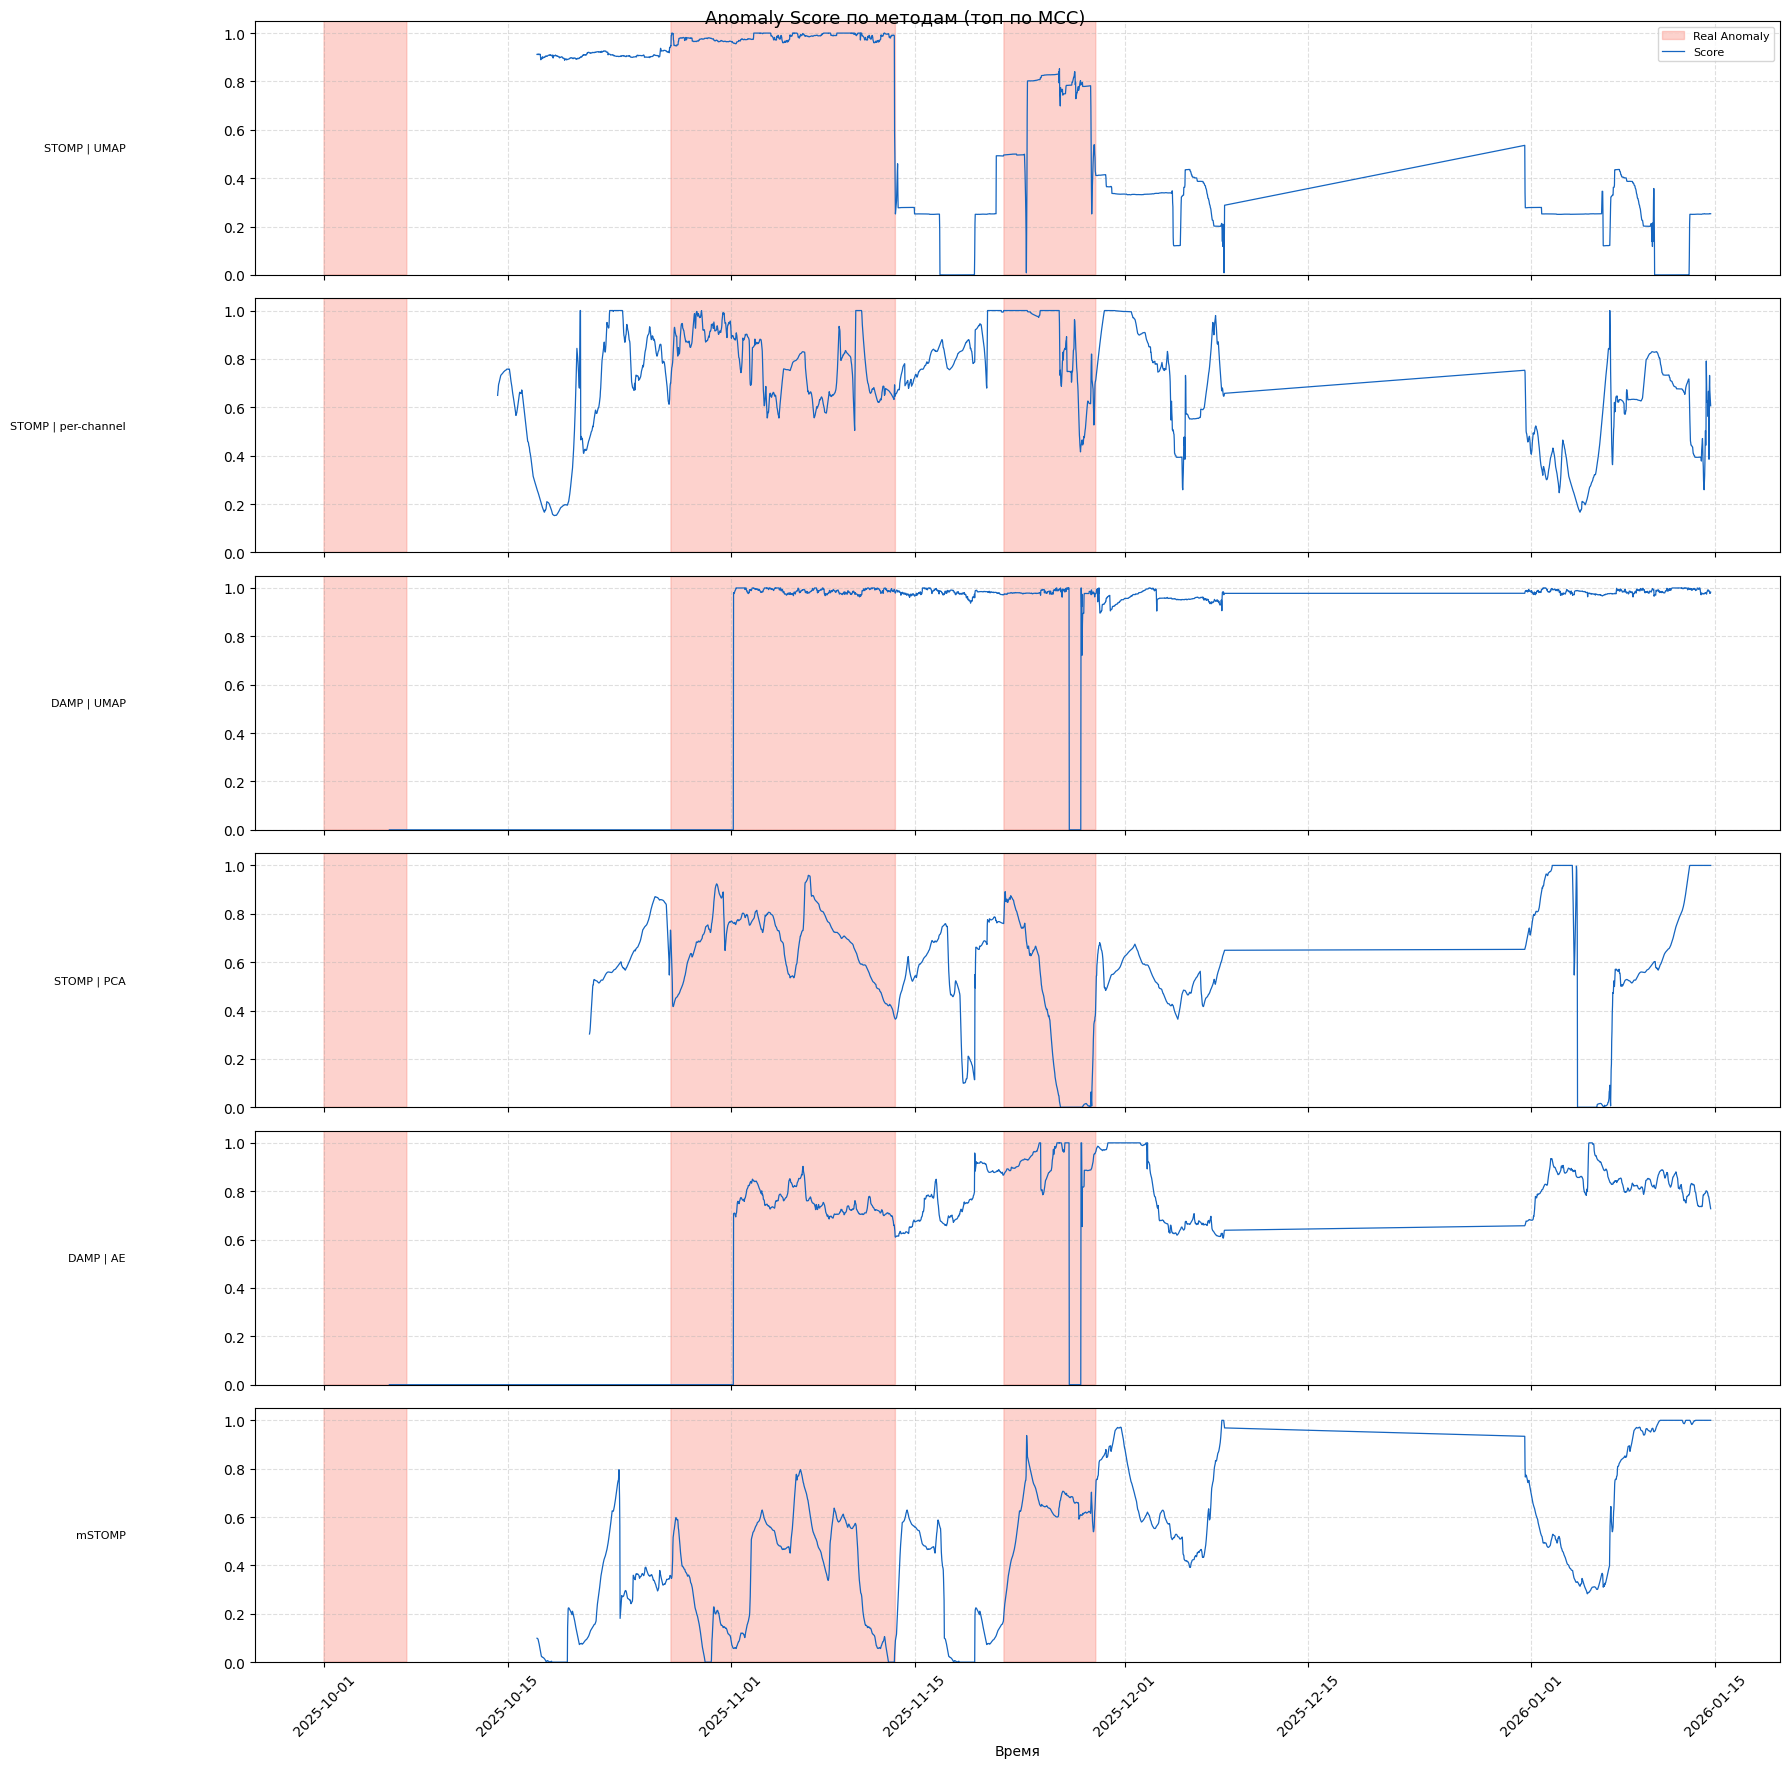

In [ ]:
# ─── Импорты ───────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import stumpy
from sklearn.decomposition import PCA
from sklearn.metrics import (
    matthews_corrcoef, f1_score, roc_auc_score,
    precision_score, recall_score, confusion_matrix, roc_curve
)

try:
    import umap as umap_lib
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False

try:
    import torch
    import torch.nn as nn
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False


# ─── Глобальные параметры ──────────────────────────────────────────────────
WINDOWS = [672]
RANDOM_STATE = 42
STEP_MINUTES = 30.0

import random

def fix_randomness(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    if TORCH_AVAILABLE:
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed(seed)
            torch.cuda.manual_seed_all(seed)
            torch.backends.cudnn.deterministic = True
            torch.backends.cudnn.benchmark = False

fix_randomness(RANDOM_STATE)


# ─── Лучшие признаки для каждой модели ───────────────────────────────────────

BEST_FEATURES = {
    "STOMP | per-channel": [
        "Температура компрессора",
        "Температура фреона после конденсатора",
        "Температура фреона на выходе из фильтра",
    ],
    "STOMP | PCA": [
        'Положение клапана HGBP',
        'Температура переохлаждения фреона после ресивера',
        'Температура фреона на выходе из фильтра',
    ],
    "STOMP | UMAP": [
        "Перегрев фреона на сбросе",
        "Активная мощность L3_PDU_2",
        "Ток L3_PDU_2",
    ],
    "STOMP | AE": [
        'Положение клапана HGBP',
        'Температура переохлаждения фреона после ресивера',
        'Температура фреона на выходе из фильтра',

    ],
    "DAMP | per-channel": [
        "Дифференциальное давление воздушного фильтра",
        "Температура фреона на входе в фильтр",
        "Статус компрессора",
    ],
    "DAMP | PCA": [
        "Температура компрессора",
        "Температура фреона на линии нагнетания",
        "Температура в горячем коридоре",
        "Температура фреона на входе в фильтр",
        "Температура фреона после ресивера",
        "Температура фреона на выходе из фильтра",
        "Температура наружного воздуха",
        "Коэффициент мощности компрессора",
        "Поток воздуха",
        "Статус компрессора",
        "Потребность в охлаждении",
        "Средняя производительность вентиляторов на испарителе",
        "Дифференциальное давление воздушного фильтра",
        "Положение клапана HGBP",
        "Мощность кондиционера",
        "Температура фреона на всасывании",
        "Температура воздуха на входе в стойку",
        "Температура воздуха на входе в кондиционер",
        "Температура воздуха на входе в кондиционер float",
        "Температура воздуха на выходе из кондиционера",
        "Активная мощность L2_PDU_1",
        "Полная мощность L2_PDU_1",
        "Ток L2_PDU_1",
        "Напряжение L2_PDU_1",
        "Активная мощность L3_PDU_2",
        "Полная мощность L3_PDU_2",
        "Ток L3_PDU_2",
        "Напряжение L3_PDU_2",
        "Температура насыщения на испарителе (по таблице)",
        "Температура насыщения на конденсаторе",
        "Температура насыщения на испарителе (по кондиционеру)",
        "Перегрев фреона на сбросе",
        "Температура переохлаждения фреона после ресивера",
        "Температура разности конденсации и внешней",
        "Активная мощность L3_PDU_1",
        "Полная мощность L3_PDU_1",
        "Ток L3_PDU_1",
        "Напряжение L3_PDU_1",
        "Активная мощность L2_PDU_2",
        "Полная мощность L2_PDU_2",
        "Ток L2_PDU_2",
        "Напряжение L2_PDU_2",
        "Активная мощность наружного блока",
        "Ток наружного блока",
        "Частота наружного блока",
        "Реактивная мощность наружного блока",
        "Коэффициент мощности наружного блока",
        "Напряжение наружного блока",
        "Температура фреона после конденсатора",
        "Активная мощность компрессора",
        "Полная мощность компрессора",
        "Частота компрессора",
        "Реактивная мощность компрессора",
        "Напряжение компрессора",
    ],
    "DAMP | UMAP": [
        "Ток L3_PDU_2",
    ],
    "DAMP | AE": [
        "Активная мощность L3_PDU_2",
    ],
    "mSTOMP": [
        'Положение клапана HGBP',
        'Температура переохлаждения фреона после ресивера',
        'Температура фреона на выходе из фильтра',
        'Полная мощность наружного блока',
        'Температура фреона на входе в фильтр',
        'Реактивная мощность наружного блока',
        'Температура перегрева фреона после испарителя',
        'Ток наружного блока',
        'Активная мощность наружного блока',
        'Потребность в охлаждении',
        'Полная мощность L2_PDU_2',
        'Ток L2_PDU_2',
        'Активная мощность L2_PDU_2',
        'Перегрев фреона на сбросе',
        'Температура воздуха на входе в кондиционер',
        'Активная мощность компрессора',
        'Напряжение L3_PDU_2',
        'Ток компрессора',
        'Мощность кондиционера'
    ],
    "Multidim MP": [
        "Температура компрессора",
        "Температура фреона после конденсатора",
        "Температура фреона на выходе из фильтра"
    ],
}


def select_features(df: pd.DataFrame, feature_list: list) -> pd.DataFrame:
    available = [f for f in feature_list if f in df.columns]
    missing   = [f for f in feature_list if f not in df.columns]
    if missing:
        print(f"   Признаки не найдены и пропущены: {missing}")
    return df[available]


# ─── Вспомогательные функции ───────────────────────────────────────────────

def binary_labels(y: pd.Series) -> np.ndarray:
    """'Anomaly' → 1, 'Normal' → 0"""
    return (y == "Anomaly").astype(int).values


def filter_normal(X: pd.DataFrame, y: pd.Series) -> pd.DataFrame:
    """
    Фильтрует датафрейм, оставляя только нормальные наблюдения.
    Используется для обучения — в реальности метки аномалий на train неизвестны,
    поэтому модель обучается только на нормальном поведении системы.
    """
    normal_mask = (y == "Normal").values
    n_total  = len(y)
    n_normal = normal_mask.sum()
    n_anomaly = n_total - n_normal
    print(f"  Фильтрация train: {n_total} → {n_normal} норм. "
          f"(удалено {n_anomaly} аномальных = {100*n_anomaly/n_total:.1f}%)")
    return X[normal_mask].reset_index(drop=True)


def robust_normalize(s: np.ndarray) -> np.ndarray:
    s = np.array(s, dtype=np.float64)
    s[np.isinf(s)] = np.nan
    if np.all(np.isnan(s)):
        return np.zeros_like(s)
    q_low  = np.nanpercentile(s, 5)
    q_high = np.nanpercentile(s, 95)
    if q_high - q_low < 1e-12:
        return np.zeros_like(s)
    s = (s - q_low) / (q_high - q_low)
    return np.clip(s, 0.0, 1.0)


def multiscale_max(profiles: list) -> np.ndarray:
    normed = [robust_normalize(p) for p in profiles]
    return np.nanmax(np.stack(normed, axis=0), axis=0)


def pad_profile(mp_raw: np.ndarray, n_total: int) -> np.ndarray:
    pad = n_total - len(mp_raw)
    if pad < 0:
        return mp_raw[-pad:]
    return np.concatenate([np.full(pad, np.nan), mp_raw])


def moving_average(x: np.ndarray, window: int = 5) -> np.ndarray:
    if window <= 1:
        return x.copy()
    out = np.full_like(x, np.nan, dtype=np.float64)
    for i in range(len(x)):
        lo = max(0, i - window // 2)
        hi = min(len(x), i + window // 2 + 1)
        segment = x[lo:hi]
        valid = segment[~np.isnan(segment)]
        if len(valid) > 0:
            out[i] = valid.mean()
    return out


def optimal_threshold_mcc(y_true: np.ndarray,
                           y_score: np.ndarray) -> tuple:
    mask = ~np.isnan(y_score)
    yt = y_true[mask]
    ys = y_score[mask]

    if len(np.unique(yt)) < 2 or len(np.unique(ys)) < 2:
        fallback_t = float(np.nanmedian(ys)) if len(ys) > 0 else 0.5
        return fallback_t, 0.0, np.array([0, 1]), np.array([0, 1]), np.array([fallback_t])

    fpr, tpr, thresholds = roc_curve(yt, ys)

    finite_mask = np.isfinite(thresholds)
    if not finite_mask.any():
        fallback_t = float(np.nanmedian(ys))
        return fallback_t, 0.0, fpr, tpr, thresholds

    thresholds_f = thresholds[finite_mask]
    best_mcc = -2.0
    best_t   = float(np.nanmedian(thresholds_f))

    for t in thresholds_f:
        pred = (ys >= t).astype(int)
        if pred.sum() == 0 or pred.sum() == len(pred):
            continue
        mcc = matthews_corrcoef(yt, pred)
        if mcc > best_mcc:
            best_mcc = mcc
            best_t   = t

    return best_t, best_mcc, fpr, tpr, thresholds


def compute_metrics(y_true: np.ndarray,
                    y_score_full: np.ndarray,
                    train_sec: float = 0.0,
                    infer_sec: float = 0.0,
                    step_minutes: float = STEP_MINUTES) -> dict:
    mask   = ~np.isnan(y_score_full)
    yt     = y_true[mask]
    ys     = y_score_full[mask]

    best_t, _, fpr_arr, tpr_arr, _ = optimal_threshold_mcc(yt, ys)
    y_pred = (ys >= best_t).astype(int)

    tn, fp, fn, tp = confusion_matrix(yt, y_pred, labels=[0, 1]).ravel()

    try:
        roc_auc = roc_auc_score(yt, ys)
    except Exception:
        roc_auc = float("nan")

    delay = compute_delay(yt, y_pred, step_minutes)

    return {
        "MCC":       matthews_corrcoef(yt, y_pred),
        "F1":        f1_score(yt, y_pred, zero_division=0),
        "ROC_AUC":   roc_auc,
        "Precision": precision_score(yt, y_pred, zero_division=0),
        "Recall":    recall_score(yt, y_pred, zero_division=0),
        "TP_rate":   tp / (tp + fn) if (tp + fn) > 0 else 0.0,
        "FP_rate":   fp / (fp + tn) if (fp + tn) > 0 else 0.0,
        "TN_rate":   tn / (tn + fp) if (tn + fp) > 0 else 0.0,
        "FN_rate":   fn / (fn + tp) if (fn + tp) > 0 else 0.0,
        "threshold": best_t,
        "Train_sec": train_sec,
        "Infer_sec": infer_sec,
        "Delay_min": delay,
        "_y_pred":   y_pred,
        "_y_score":  ys,
        "_mask":     mask,
    }


def compute_delay(y_true: np.ndarray, y_pred: np.ndarray,
                  step_minutes: float = STEP_MINUTES) -> float:
    delays = []
    in_anomaly  = False
    seg_start   = 0
    tp_found    = False

    for i in range(len(y_true)):
        if y_true[i] == 1 and not in_anomaly:
            in_anomaly = True
            seg_start  = i
            tp_found   = False
        if in_anomaly and not tp_found and y_pred[i] == 1:
            delays.append((i - seg_start) * step_minutes)
            tp_found = True
        if y_true[i] == 0:
            in_anomaly = False

    return float(np.mean(delays)) if delays else float("nan")


# ─── Стратегии редукции размерности ───────────────────────────────────────

class _PCAReducer:
    def fit(self, X_train_normal):
        # X_train_normal уже отфильтрован — только нормальные наблюдения
        n_comp = min(5, X_train_normal.shape[1])
        t0 = time.perf_counter()
        self.pca = PCA(n_components=n_comp, random_state=RANDOM_STATE)
        self.pca.fit(X_train_normal)
        return time.perf_counter() - t0

    def transform(self, X):
        return np.mean(self.pca.transform(X), axis=1)


class _UMAPReducer:
    def fit(self, X_train_normal):
        if not UMAP_AVAILABLE:
            raise ImportError("pip install umap-learn")
        t0 = time.perf_counter()
        self.reducer = umap_lib.UMAP(n_components=2, n_neighbors=15,
                                      min_dist=0.1, random_state=RANDOM_STATE)
        self.reducer.fit(X_train_normal)
        return time.perf_counter() - t0

    def transform(self, X):
        return np.linalg.norm(self.reducer.transform(X), axis=1)


class _AEReducer:
    def fit(self, X_train_normal):
        if not TORCH_AVAILABLE:
            raise ImportError("pip install torch")

        d      = X_train_normal.shape[1]
        hidden = max(8, d // 3)

        class SimpleAE(nn.Module):
            def __init__(self):
                super().__init__()
                self.encoder = nn.Linear(d, hidden)
                self.decoder = nn.Linear(hidden, d)
            def forward(self, x):
                return self.decoder(torch.relu(self.encoder(x)))

        self.model = SimpleAE()
        optimizer  = torch.optim.Adam(self.model.parameters(), lr=0.0005)
        loss_fn    = nn.MSELoss()

        X_t     = torch.tensor(X_train_normal, dtype=torch.float32)
        dataset = torch.utils.data.TensorDataset(X_t)

        generator = torch.Generator()
        generator.manual_seed(RANDOM_STATE)

        loader = torch.utils.data.DataLoader(
            dataset, batch_size=64, shuffle=True, generator=generator)

        t0 = time.perf_counter()
        self.model.train()
        for epoch in range(200):
            for (batch,) in loader:
                optimizer.zero_grad()
                loss = loss_fn(self.model(batch), batch)
                loss.backward()
                optimizer.step()
        self.model.eval()

        fit_sec = time.perf_counter() - t0
        print(f"AE обучён за {fit_sec:.1f} сек (hidden={hidden}, "
              f"samples={X_train_normal.shape[0]} норм.)")
        return fit_sec

    def transform(self, X):
        with torch.no_grad():
            X_t           = torch.tensor(X, dtype=torch.float32)
            reconstructed = self.model(X_t).numpy()
        return np.mean((X - reconstructed) ** 2, axis=1)


# ─── Вычисление профилей ───────────────────────────────────────────────────

def _extract_mp_values(mp_obj) -> np.ndarray:
    col = mp_obj[:, 0]
    if col.dtype.names is not None:
        col = col[col.dtype.names[0]]
    return np.array(col, dtype=np.float64)


def stomp_profiles(ts: np.ndarray, windows: list) -> list:
    result = []
    ts_f = np.asarray(ts, dtype=np.float64)
    for m in windows:
        if len(ts_f) <= m:
            print(f"  Пропущено окно m={m}: ряд короткий ({len(ts_f)})")
            continue
        mp_raw = _extract_mp_values(stumpy.stump(ts_f, m=m))
        mp_raw[np.isinf(mp_raw)] = np.nan
        result.append((m, mp_raw))
    return result


def _mass_v2(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    m = len(y)
    n = len(x)

    if n < m:
        return np.array([np.inf])

    meany  = np.mean(y)
    sigmay = np.std(y)

    if sigmay < 1e-10:
        return np.full(n - m + 1, 0.0)

    x_prefix  = x[: m - 1]
    divider   = np.arange(1, len(x_prefix) + 1, dtype=np.float64)
    cumsum_   = x_prefix.cumsum()
    sq_cumsum = (x_prefix ** 2).cumsum()
    mean_prefix = cumsum_ / divider
    std_prefix  = np.sqrt(
        np.maximum((sq_cumsum - cumsum_ ** 2 / divider) / divider, 0.0))

    windows    = np.lib.stride_tricks.sliding_window_view(x, m)
    mean_full  = windows.mean(axis=1)
    std_full   = windows.std(axis=1)

    meanx  = np.concatenate([mean_prefix, mean_full])
    sigmax = np.concatenate([std_prefix,  std_full])

    y_rev = np.concatenate((y[::-1], np.zeros(n - m)))
    z     = np.fft.ifft(np.fft.fft(x) * np.fft.fft(y_rev)).real

    denom = sigmax[m - 1 : n] * sigmay
    denom = np.where(denom < 1e-10, 1e-10, denom)
    dist  = 2 * (m - (z[m - 1 : n] - m * meanx[m - 1 : n] * meany) / denom)
    return np.sqrt(np.maximum(dist, 0.0))


def _nextpow2(x: int) -> float:
    return np.ceil(np.log2(abs(x)))


def _damp_2_0(time_series: np.ndarray,
              subsequence_length: int,
              stride: int = 1,
              location_to_start_processing: int = None,
              lookahead: int = 0) -> np.ndarray:
    ts  = np.asarray(time_series, dtype=np.float64)
    n   = len(ts)
    m   = subsequence_length

    if location_to_start_processing is None:
        location_to_start_processing = max(m, 4 * m)

    if lookahead is None:
        lookahead = int(2 ** _nextpow2(16 * m))
    elif (lookahead != 0) and (lookahead != 2 ** _nextpow2(lookahead)):
        lookahead = int(2 ** _nextpow2(lookahead))

    if (location_to_start_processing / m) < 4:
        if location_to_start_processing < m:
            location_to_start_processing = m
    else:
        if location_to_start_processing > (n - m + 1):
            location_to_start_processing = n - m + 1

    left_mp     = np.zeros(n, dtype=np.float64)
    best_so_far = -np.inf
    bool_vec    = np.ones(n, dtype=np.float64)

    loc = location_to_start_processing

    for i in range(loc - 1, loc + 16 * m, stride):
        if not bool_vec[i]:
            left_mp[i] = left_mp[i - 1] - 1e-05
            continue

        if i + m - 1 > n:
            break

        query = ts[i : i + m]
        left_mp[i] = np.amin(_mass_v2(ts[:i], query)) if i > 0 else 0.0

        best_so_far = np.amax(left_mp)

        if lookahead != 0:
            start_of_mass = min(i + m - 1, n)
            end_of_mass   = min(start_of_mass + lookahead - 1, n)
            if (end_of_mass - start_of_mass + 1) > m:
                dp  = _mass_v2(ts[start_of_mass : end_of_mass + 1], query)
                bad = np.where(dp < best_so_far)[0] + start_of_mass
                bool_vec[bad] = 0

    for i in range(loc + 16 * m, n - m + 1, stride):
        if not bool_vec[i]:
            left_mp[i] = left_mp[i - 1] - 1e-05
            continue

        if i + m - 1 > n:
            break

        query         = ts[i : i + m]
        approx_dist   = np.inf
        X             = int(2 ** _nextpow2(8 * m))
        flag          = 1
        expansion_num = 0

        while approx_dist >= best_so_far:
            if i - X + 1 + expansion_num * m < 1:
                approx_dist = np.amin(_mass_v2(ts[: i + 1], query))
                left_mp[i]  = approx_dist
                if approx_dist > best_so_far:
                    best_so_far = approx_dist
                break

            if flag == 1:
                flag        = 0
                approx_dist = np.amin(_mass_v2(ts[i - X + 1 : i + 1], query))
            else:
                X_start     = i - X + 1 + expansion_num * m
                X_end       = i - X // 2 + expansion_num * m
                approx_dist = np.amin(
                    _mass_v2(ts[X_start : X_end + 1], query))

            if approx_dist < best_so_far:
                left_mp[i] = approx_dist
                break

            X             *= 2
            expansion_num += 1

        if lookahead != 0:
            start_of_mass = min(i + m, n)
            end_of_mass   = min(start_of_mass + lookahead - 1, n)
            if (end_of_mass - start_of_mass) > m:
                dp  = _mass_v2(ts[start_of_mass : end_of_mass + 1], query)
                bad = np.where(dp < best_so_far)[0] + start_of_mass
                bool_vec[bad] = 0

    return left_mp


def damp_profiles(ts: np.ndarray, windows: list,
                  stride: int = 1, lookahead: int = 0) -> list:
    result = []
    ts_f   = np.asarray(ts, dtype=np.float64)
    n      = len(ts_f)

    for m_req in windows:
        m = int(np.clip(m_req, 11, 1000))
        if n <= m + 1:
            continue

        loc = max(m, 4 * m)

        mp_raw = _damp_2_0(
            ts_f, m,
            stride=stride,
            location_to_start_processing=loc,
            lookahead=lookahead,
        )
        mp_out = mp_raw[:n - m + 1].copy().astype(np.float64)
        mp_out[np.isinf(mp_out)] = np.nan
        result.append((m, mp_out))

    return result


# ─── mSTOMP: профиль и подбор (m, k) ──────────────────────────────────────

def mstomp_profiles(X: np.ndarray, windows: list, k: int = None) -> list:
    result = []
    T = X.T.astype(np.float64)
    d = X.shape[1]

    for m in windows:
        if X.shape[0] <= m:
            print(f"   Пропущено окно m={m}: ряд слишком короткий")
            continue

        mmp, _ = stumpy.mstump(T, m=m)
        mmp    = np.array(mmp, dtype=np.float64)

        row    = (k - 1) if (k is not None) else (d - 1)
        row    = int(np.clip(row, 0, d - 1))

        mp_raw = mmp[row].copy()
        mp_raw[np.isinf(mp_raw)] = np.nan
        result.append((m, mp_raw))

    return result


def tune_window_multidim(X_val: np.ndarray,
                          y_val: np.ndarray,
                          candidate_windows: list) -> tuple:
    n_val    = len(y_val)
    d        = X_val.shape[1]
    best_m   = candidate_windows[0]
    best_k   = d
    best_mcc = -2.0

    for m in candidate_windows:
        if X_val.shape[0] <= m:
            continue

        T   = X_val.T.astype(np.float64)
        mmp, _ = stumpy.mstump(T, m=m)
        mmp = np.array(mmp, dtype=np.float64)

        for k in range(1, d + 1):
            mp_raw = mmp[k - 1].copy()
            mp_raw[np.isinf(mp_raw)] = np.nan
            score  = pad_profile(mp_raw, n_val)
            mask   = ~np.isnan(score)

            if mask.sum() < 2 or len(np.unique(y_val[mask])) < 2:
                continue

            _, mcc, _, _, _ = optimal_threshold_mcc(y_val[mask], score[mask])
            if mcc > best_mcc:
                best_mcc = mcc
                best_m   = m
                best_k   = k

    days = round(best_m * STEP_MINUTES / 60 / 24, 1)
    print(f"    tune→ m={best_m} ({days} сут), k={best_k}/{d}, MCC_val={best_mcc:.4f}")
    return best_m, best_k


# ─── Multidim MP согласно статье ─────────────────────────────────────────

def _znorm(x: np.ndarray) -> np.ndarray:
    mu  = x.mean()
    std = x.std()
    if std < 1e-10:
        return np.zeros_like(x)
    return (x - mu) / std


def _pairwise_distances_presort(
    T1: np.ndarray,
    T2: np.ndarray,
    m: int,
    exclusion_zone: int = None,
) -> np.ndarray:
    n1, d = T1.shape
    n2    = T2.shape[0]
    L1    = n1 - m + 1
    L2    = n2 - m + 1

    if exclusion_zone is None:
        exclusion_zone = m // 4

    presort_mp = np.full((d, L1), np.inf, dtype=np.float64)

    self_join = np.shares_memory(T1, T2) or (T1.shape == T2.shape and np.allclose(T1, T2))

    dist_matrices = []

    for dim in range(d):
        t1_dim = T1[:, dim].astype(np.float64)
        t2_dim = T2[:, dim].astype(np.float64)

        D_dim = np.empty((L1, L2), dtype=np.float64)
        for i in range(L1):
            query = t1_dim[i: i + m]
            D_dim[i] = stumpy.core.mass(query, t2_dim)

        D_dim = np.clip(D_dim, 0.0, None)
        dist_matrices.append(D_dim)

    D_tensor = np.stack(dist_matrices, axis=2)  # (L1, L2, d)

    for i in range(L1):
        if self_join:
            lo = max(0, i - exclusion_zone)
            hi = min(L2, i + exclusion_zone + 1)
            D_i = D_tensor[i].copy()
            D_i[lo:hi, :] = np.inf
        else:
            D_i = D_tensor[i]

        sorted_D_i = np.sort(D_i, axis=1)[:, ::-1]

        for k in range(d):
            valid = sorted_D_i[:, k]
            valid = valid[~np.isinf(valid)]
            if len(valid) > 0:
                presort_mp[k, i] = valid.min()

    presort_mp[np.isinf(presort_mp)] = np.nan
    return presort_mp


def multidim_mp_paper(
    X_test:  np.ndarray,
    X_train: np.ndarray,
    m:       int,
    k_nn:    int = 1,
    join_type: str = "ab",
    ma_window: int = 5,
) -> np.ndarray:
    """
    Multidimensional Matrix Profile согласно статье.
    X_train здесь содержит ТОЛЬКО нормальные наблюдения (уже отфильтрован).
    AB-join (join_type="ab") ищет паттерны теста в нормальном трейне —
    высокое расстояние означает, что паттерн не встречался в норме → аномалия.
    """
    d = X_test.shape[1]

    if join_type == "ab":
        T1 = X_test
        T2 = X_train
        excl = None
    else:
        # self-join: конкатенируем нормальный трейн с тестом
        T1 = np.concatenate([X_train, X_test], axis=0)
        T2 = T1
        excl = m // 4

    n_test = X_test.shape[0]

    if T1.shape[0] <= m or T2.shape[0] <= m:
        print(f"   Multidim MP: ряд слишком короткий для m={m}")
        return np.full(n_test, np.nan)

    presort_mp = _pairwise_distances_presort(T1, T2, m, exclusion_zone=excl)
    mp_dim0    = presort_mp[0]

    if k_nn > 1:
        pct = min(100.0, k_nn * 100.0 / max(len(mp_dim0), 1))
        mp_dim0 = mp_dim0.copy()
        global_shift = np.nanpercentile(mp_dim0, pct)
        mp_dim0 = np.where(mp_dim0 < global_shift, global_shift, mp_dim0)
        print(f"  k-NN аппроксимация: k={k_nn}, global_shift={global_shift:.4f}")

    if join_type == "self":
        n_train = X_train.shape[0]
        L_total = len(mp_dim0)
        L_test  = L_total - n_train
        if L_test > 0:
            score_raw = mp_dim0[n_train: n_train + L_test]
        else:
            score_raw = mp_dim0[-1:]
    else:
        score_raw = mp_dim0

    score_padded = pad_profile(score_raw, n_test)
    score_smooth = moving_average(score_padded, window=ma_window)

    return score_smooth


def tune_window_multidim_paper(
    X_val:             np.ndarray,
    X_train:           np.ndarray,
    y_val:             np.ndarray,
    candidate_windows: list,
    k_nn:              int = 1,
    join_type:         str = "ab",
    ma_window:         int = 5,
) -> int:
    """
    Подбор оптимального m для Multidim MP.
    X_train содержит только нормальные наблюдения (уже отфильтрован).
    """
    n_val    = len(y_val)
    best_m   = candidate_windows[0]
    best_mcc = -2.0

    for m in candidate_windows:
        if X_val.shape[0] <= m or X_train.shape[0] <= m:
            continue

        score = multidim_mp_paper(
            X_test=X_val,
            X_train=X_train,
            m=m,
            k_nn=k_nn,
            join_type=join_type,
            ma_window=ma_window,
        )

        mask = ~np.isnan(score)
        if mask.sum() < 2 or len(np.unique(y_val[mask])) < 2:
            continue

        _, mcc, _, _, _ = optimal_threshold_mcc(y_val[mask], score[mask])
        if mcc > best_mcc:
            best_mcc = mcc
            best_m   = m

    days = round(best_m * STEP_MINUTES / 60 / 24, 1)
    print(f"    tune→ m={best_m} ({days} сут), MCC_val={best_mcc:.4f}")
    return best_m


# ─── 6. Подбор окна для одномерных методов ───────────────────────────────────

def tune_window(profile_fn, ts_val, y_val, candidate_windows,
                profile_kwargs=None):
    if profile_kwargs is None:
        profile_kwargs = {}
    n_val    = len(y_val)
    best_m   = candidate_windows[0]
    best_mcc = -2.0

    for m in candidate_windows:
        profs = profile_fn(ts_val, [m], **profile_kwargs)
        if not profs:
            continue
        padded = [pad_profile(mp, n_val) for _, mp in profs]
        score  = multiscale_max(padded)
        mask   = ~np.isnan(score)
        if mask.sum() < 2 or len(np.unique(y_val[mask])) < 2:
            continue
        _, mcc, _, _, _ = optimal_threshold_mcc(y_val[mask], score[mask])
        if mcc > best_mcc:
            best_mcc = mcc
            best_m   = m

    days = round(best_m * STEP_MINUTES / 60 / 24, 1)
    print(f"    tune→ m={best_m} ({days} сут), MCC_val={best_mcc:.4f}")
    return best_m


def tune_window_per_channel(profile_fn, X_val, y_val, candidate_windows,
                             profile_kwargs=None):
    if profile_kwargs is None:
        profile_kwargs = {}
    n_val    = len(y_val)
    best_m   = candidate_windows[0]
    best_mcc = -2.0

    for m in candidate_windows:
        ch_profs = []
        for ch in range(X_val.shape[1]):
            ch_profs.extend(profile_fn(X_val[:, ch], [m], **profile_kwargs))
        if not ch_profs:
            continue
        padded = [pad_profile(mp, n_val) for _, mp in ch_profs]
        score  = multiscale_max(padded)
        mask   = ~np.isnan(score)
        if mask.sum() < 2 or len(np.unique(y_val[mask])) < 2:
            continue
        _, mcc, _, _, _ = optimal_threshold_mcc(y_val[mask], score[mask])
        if mcc > best_mcc:
            best_mcc = mcc
            best_m   = m

    days = round(best_m * STEP_MINUTES / 60 / 24, 1)
    print(f"    tune→ m={best_m} ({days} сут), MCC_val={best_mcc:.4f}")
    return best_m


# ─── 7. Общий pipeline для одного метода ─────────────────────────────────────

def run_one_method(name, raw_profiles, n_total, y_true,
                   train_sec, infer_sec):
    padded      = [pad_profile(mp, n_total) for _, mp in raw_profiles]
    final_score = multiscale_max(padded)

    metrics              = compute_metrics(y_true, final_score,
                                           train_sec=train_sec,
                                           infer_sec=infer_sec)
    metrics["name"]      = name
    metrics["_profiles"] = raw_profiles
    metrics["_score"]    = final_score
    return metrics


# ─── 8. Основной блок экспериментов ──────────────────────────────────────────

def run_all_experiments(
    X_train_scaled:  pd.DataFrame,
    X_val_scaled:    pd.DataFrame,
    X_test_scaled:   pd.DataFrame,
    y_train:         pd.Series,    # ← НОВЫЙ ПАРАМЕТР: метки обучающей выборки
    y_val:           pd.Series,
    y_test:          pd.Series,
    candidate_windows: list = None,
    damp_stride:     int   = 1,
    damp_lookahead:  int   = 0,
    mmpad_k_nn:      int   = 1,
    mmpad_join:      str   = "ab",
    mmpad_ma_window: int   = 5,
) -> tuple:
    """
    Запускает все эксперименты.

    Ключевое изменение: X_train_scaled фильтруется по y_train == "Normal"
    перед передачей в любой метод. Это соответствует реальному сценарию,
    когда в production модель обучается только на исторически нормальных данных.

    Parameters
    ----------
    y_train : pd.Series
        Метки обучающей выборки ('Normal' / 'Anomaly').
        Используются исключительно для фильтрации train — не передаются
        в сами алгоритмы (те работают в unsupervised / semi-supervised режиме).
    """

    if candidate_windows is None:
        candidate_windows = [48, 96, 144, 240, 336, 480, 672, 1000]

    damp_candidates = sorted(set(
        int(np.clip(m, 11, 1000)) for m in candidate_windows
    ))

    y_va = binary_labels(y_val)
    y_te = binary_labels(y_test)
    n_te = len(y_te)

    results    = []
    all_scores = {}
    damp_kw    = {"stride": damp_stride, "lookahead": damp_lookahead}

    # ── Фильтрация train: оставляем только нормальные наблюдения ──────────────
    # Это центральное изменение — в реальности у нас нет аномальных меток
    # на этапе обучения, поэтому обучаем только на нормальном поведении.
    print("=" * 60)
    print("Фильтрация обучающей выборки (только Normal)")
    print("=" * 60)
    X_train_normal = filter_normal(X_train_scaled, y_train)
    print(f"  X_train_normal: {X_train_normal.shape}")

    def _get_arrays(method_name):
        """
        Возвращает (X_tr_normal, X_val, X_te) с отобранными признаками.
        X_tr_normal — уже отфильтрованный по меткам train (только Normal).
        """
        feats = BEST_FEATURES.get(method_name)
        if feats is None:
            return (X_train_normal.values.astype(np.float64),
                    X_val_scaled.values.astype(np.float64),
                    X_test_scaled.values.astype(np.float64))
        X_tr_f  = select_features(X_train_normal, feats).values.astype(np.float64)
        X_val_f = select_features(X_val_scaled,   feats).values.astype(np.float64)
        X_te_f  = select_features(X_test_scaled,  feats).values.astype(np.float64)
        return X_tr_f, X_val_f, X_te_f

    def _run(name, profile_fn, reducer_cls=None, profile_kwargs=None,
             cand_windows=None):
        if profile_kwargs is None:
            profile_kwargs = {}
        if cand_windows is None:
            cand_windows = candidate_windows

        print(f"▶ {name}")

        # X_tr — только нормальные наблюдения (после фильтрации выше)
        X_tr, X_val, X_te = _get_arrays(name)
        print(f"  Признаков: {X_tr.shape[1]}, train (норма): {X_tr.shape[0]}")

        if reducer_cls is None:
            ts_val_1d = None
            ts_te_1d  = None
            train_sec = 0.0
        else:
            # Reducer обучается ТОЛЬКО на нормальных данных (X_tr уже отфильтрован)
            reducer   = reducer_cls()
            train_sec = reducer.fit(X_tr)
            ts_val_1d = reducer.transform(X_val)
            ts_te_1d  = reducer.transform(X_te)

        if ts_val_1d is None:
            best_m = tune_window_per_channel(
                profile_fn, X_val, y_va, cand_windows, profile_kwargs)
        else:
            best_m = tune_window(
                profile_fn, ts_val_1d, y_va, cand_windows, profile_kwargs)

        t0 = time.perf_counter()
        if ts_te_1d is None:
            raw_profs = []
            for ch in range(X_te.shape[1]):
                raw_profs.extend(
                    profile_fn(X_te[:, ch], [best_m], **profile_kwargs))
        else:
            raw_profs = profile_fn(ts_te_1d, [best_m], **profile_kwargs)
        infer_sec = time.perf_counter() - t0

        if not raw_profs:
            print(f"  ✗ нет профилей")
            return

        metrics            = run_one_method(name, raw_profs, n_te, y_te,
                                            train_sec, infer_sec)
        metrics["best_m"] = best_m
        results.append(metrics)
        all_scores[name]   = metrics["_score"]
        print(f"  m={best_m}  MCC={metrics['MCC']:.4f}  F1={metrics['F1']:.4f}"
              f"  AUC={metrics['ROC_AUC']:.4f}  thr={metrics['threshold']:.4f}")

    # ─────────────────────────────────────────────────────────────────────────
    # A. STOMP
    # ─────────────────────────────────────────────────────────────────────────
    print("\n" + "=" * 60)
    print("STOMP")
    print("=" * 60)

    _run("STOMP | per-channel", stomp_profiles)
    _run("STOMP | PCA",         stomp_profiles, _PCAReducer)
    if UMAP_AVAILABLE:
        _run("STOMP | UMAP",    stomp_profiles, _UMAPReducer)
    if TORCH_AVAILABLE:
        _run("STOMP | AE",      stomp_profiles, _AEReducer)

    # ─────────────────────────────────────────────────────────────────────────
    # B. DAMP 2.0
    # ─────────────────────────────────────────────────────────────────────────
    print("\n" + "=" * 60)
    print(f"DAMP 2.0  (stride={damp_stride}, lookahead={damp_lookahead})")
    print(f"Пул окон DAMP (клип 11–1000): {damp_candidates}")
    print("=" * 60)

    _run("DAMP | per-channel", damp_profiles,
         profile_kwargs=damp_kw, cand_windows=damp_candidates)
    _run("DAMP | PCA",         damp_profiles, _PCAReducer,
         profile_kwargs=damp_kw, cand_windows=damp_candidates)
    if UMAP_AVAILABLE:
        _run("DAMP | UMAP",    damp_profiles, _UMAPReducer,
             profile_kwargs=damp_kw, cand_windows=damp_candidates)
    if TORCH_AVAILABLE:
        _run("DAMP | AE",      damp_profiles, _AEReducer,
             profile_kwargs=damp_kw, cand_windows=damp_candidates)

    # ─────────────────────────────────────────────────────────────────────────
    # C. mSTOMP — post-sorting через stumpy.mstump
    # Примечание: mSTOMP работает на тестовых данных (self-join на X_te).
    # X_tr_normal используется только для обучения reducers (здесь не применяется).
    # ─────────────────────────────────────────────────────────────────────────
    print("\n" + "=" * 60)
    print("mSTOMP (stumpy.mstump, post-sorting, автоподбор k)")
    print("=" * 60)

    print("▶ mSTOMP")
    X_tr_ms, X_val_ms, X_te_ms = _get_arrays("mSTOMP")
    print(f"  Признаков: {X_tr_ms.shape[1]}, train (норма): {X_tr_ms.shape[0]}")

    best_m_ms, best_k_ms = tune_window_multidim(X_val_ms, y_va, candidate_windows)

    t0       = time.perf_counter()
    ms_profs = mstomp_profiles(X_te_ms, [best_m_ms], k=best_k_ms)
    infer_sec = time.perf_counter() - t0

    if ms_profs:
        metrics            = run_one_method("mSTOMP", ms_profs, n_te, y_te,
                                            train_sec=0.0, infer_sec=infer_sec)
        metrics["best_m"] = best_m_ms
        metrics["best_k"] = best_k_ms
        results.append(metrics)
        all_scores["mSTOMP"] = metrics["_score"]
        print(f"  m={best_m_ms}  k={best_k_ms}  MCC={metrics['MCC']:.4f}  "
              f"F1={metrics['F1']:.4f}  AUC={metrics['ROC_AUC']:.4f}")

    # ─────────────────────────────────────────────────────────────────────────
    # D. Multidim MP — строго по статье
    #    Pre-sorting + dim[0] + k-NN + AB-join (тест к нормальному трейну) + MA
    #    AB-join здесь особенно корректен: T2 = только нормальные данные,
    #    поэтому высокое расстояние = паттерн не встречается в норме = аномалия.
    # ─────────────────────────────────────────────────────────────────────────
    print("\n" + "=" * 60)
    print("Multidim MP (статья: pre-sorting, dim[0], k-NN, AB-join, MA)")
    print(f"  k_nn={mmpad_k_nn}, join={mmpad_join}, ma_window={mmpad_ma_window}")
    print("=" * 60)

    print("▶ Multidim MP")
    X_tr_md, X_val_md, X_te_md = _get_arrays("Multidim MP")
    print(f"  Признаков: {X_tr_md.shape[1]}, train (норма): {X_tr_md.shape[0]}")

    best_m_md = tune_window_multidim_paper(
        X_val=X_val_md,
        X_train=X_tr_md,
        y_val=y_va,
        candidate_windows=candidate_windows,
        k_nn=mmpad_k_nn,
        join_type=mmpad_join,
        ma_window=mmpad_ma_window,
    )

    t0 = time.perf_counter()
    score_md = multidim_mp_paper(
        X_test=X_te_md,
        X_train=X_tr_md,
        m=best_m_md,
        k_nn=mmpad_k_nn,
        join_type=mmpad_join,
        ma_window=mmpad_ma_window,
    )
    infer_sec = time.perf_counter() - t0

    metrics_md = compute_metrics(y_te, score_md, train_sec=0.0, infer_sec=infer_sec)
    metrics_md["name"]    = "Multidim MP"
    metrics_md["best_m"]  = best_m_md
    metrics_md["best_k"]  = 1
    metrics_md["_score"]  = score_md
    metrics_md["_profiles"] = [(best_m_md, score_md)]

    results.append(metrics_md)
    all_scores["Multidim MP"] = score_md

    print(f"  m={best_m_md}  k_nn={mmpad_k_nn}  "
          f"MCC={metrics_md['MCC']:.4f}  "
          f"F1={metrics_md['F1']:.4f}  "
          f"AUC={metrics_md['ROC_AUC']:.4f}")

    # ─────────────────────────────────────────────────────────────────────────
    # Сводная таблица
    # ─────────────────────────────────────────────────────────────────────────
    COLS = ["name", "best_m", "best_k", "MCC", "F1", "ROC_AUC",
            "Precision", "Recall",
            "TP_rate", "FP_rate", "TN_rate", "FN_rate",
            "threshold", "Train_sec", "Infer_sec", "Delay_min"]

    df_out = pd.DataFrame([
        {c: r.get(c, float("nan")) for c in COLS} for r in results
    ])
    df_out = df_out.sort_values("MCC", ascending=False).reset_index(drop=True)

    print("\n" + "=" * 80)
    print("ИТОГОВАЯ ТАБЛИЦА МЕТРИК")
    print("=" * 80)
    print(df_out.to_string(index=False, float_format="%.4f"))

    return df_out, all_scores


# ─── Визуализация ─────────────────────────────────────────────────────────

def plot_bar_metrics(df_results: pd.DataFrame, save_path: str = None) -> None:
    metrics = ["MCC", "F1", "ROC_AUC", "Precision", "Recall"]
    fig, axes = plt.subplots(
        1, len(metrics),
        figsize=(5 * len(metrics), max(6, len(df_results) * 0.4 + 1)))
    colors = plt.cm.tab20(np.linspace(0, 1, len(df_results)))

    for ax, m in zip(axes, metrics):
        vals = df_results[m].values
        bars = ax.barh(df_results["name"], vals, color=colors)
        ax.set_xlim(-0.05 if m == "MCC" else 0, 1.05)
        ax.axvline(0, color="gray", linewidth=0.6)
        ax.axvline(0.5, color="gray", linestyle="--", linewidth=0.6)
        ax.set_title(m, fontsize=12, fontweight="bold")
        for bar, val in zip(bars, vals):
            x = val + 0.01 if val >= 0 else val - 0.01
            ax.text(x, bar.get_y() + bar.get_height() / 2,
                    f"{val:.3f}", va="center", fontsize=7)

    plt.suptitle("Сравнение методов Matrix Profile", fontsize=14, fontweight="bold")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Сохранено: {save_path}")
    plt.show()


def plot_scores_timeline(all_scores: dict,
                          y_true: np.ndarray,
                          dates: np.ndarray = None,
                          top_n: int = 6,
                          df_results: pd.DataFrame = None,
                          save_path: str = None) -> None:
    if df_results is not None:
        order = df_results["name"].tolist()
    else:
        order = list(all_scores.keys())

    top_names = [n for n in order if n in all_scores][:top_n]
    n_plots   = len(top_names)
    if n_plots == 0:
        return

    x = dates if dates is not None else np.arange(len(y_true))
    fig, axes = plt.subplots(n_plots, 1,
                              figsize=(18, 3 * n_plots), sharex=True)
    if n_plots == 1:
        axes = [axes]

    for ax, name in zip(axes, top_names):
        score = all_scores[name]
        ax.fill_between(x, 0, 1, where=(y_true == 1),
                        color="salmon", alpha=0.35, step="pre",
                        transform=ax.get_xaxis_transform(),
                        label="Real Anomaly")
        ax.plot(x, score, color="#1565C0", linewidth=0.9, label="Score")
        ax.set_ylabel(name, fontsize=8, rotation=0,
                      ha="right", va="center", labelpad=70)
        ax.set_ylim(0, 1.05)
        ax.grid(True, linestyle="--", alpha=0.4)

    axes[0].legend(loc="upper right", fontsize=8)
    if dates is not None:
        axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
        plt.xticks(rotation=45)
    axes[-1].set_xlabel("Время")
    plt.suptitle("Anomaly Score по методам (топ по MCC)", fontsize=13)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


# ─── Точка входа ──────────────────────────────────────────────────────────

if __name__ == "__main__":
    _ = X_train_scaled
    _ = X_val_scaled
    _ = X_test_scaled
    _ = y_train
    _ = y_val
    _ = y_test
    dates_test = test_df["Time"].values if "test_df" in dir() else None

    candidate_windows = [48, 96, 144, 240, 336, 480, 672]

    df_results, all_scores = run_all_experiments(
        X_train_scaled=X_train_scaled,
        X_val_scaled=X_val_scaled,
        X_test_scaled=X_test_scaled,
        y_train=y_train,
        y_val=y_val,
        y_test=y_test,
        candidate_windows=candidate_windows,
        damp_stride=1,
        damp_lookahead=0,
        mmpad_k_nn=1,
        mmpad_join="ab",
        mmpad_ma_window=5,
    )

    plot_bar_metrics(df_results, save_path=None)

    y_te_bin = binary_labels(y_test)
    plot_scores_timeline(
        all_scores,
        y_true=y_te_bin,
        dates=dates_test,
        top_n=6,
        df_results=df_results,
        save_path=None,
    )

# Сравнение с другими моделями

## Итоговый код на смешенном датасете

Device: cuda

1/7  Isolation Forest
  MCC=0.2085  F1=0.5606  contamination=0.14

2/7  One-Class SVM
  MCC=-0.0537  F1=0.5678  nu=0.3

3/7  DAGMM (Zong et al., 2018)
  MCC=0.1409  F1=0.5663  n_gmm=6

4/7  OmniAnomaly (Su et al., 2019)
  Win=48, Val MCC=-0.2694
Best Win: 48
  MCC=0.0  F1=0.5697  win=48

5/7  TranAD (Tuli et al., 2022)
  MCC=0.0  F1=0.5697  win=16

6/7  MTAD-GAT (Zhao et al., 2020)
  MCC=0.3236  F1=0.5396  win=16

7/8  TS2Vec 
  TS2Vec  MCC=0.0134  F1=0.5698
✓ PatchTST


ИТОГОВАЯ ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ
                     MCC     F1 ROC_AUC Precision Recall TP_rate FP_rate TN_rate FN_rate Train_sec Infer_sec Delay_min                   Best_param
MTAD-GAT          0.3236 0.5396  0.6158    0.6512 0.4607  0.1835  0.0983  0.5034  0.2148   44.8100    0.0540 1230.0000           win=16, hidden=150
Isolation Forest  0.2085 0.5606  0.6282    0.4976 0.6418  0.2556  0.2581  0.3436  0.1427   13.0300    0.0450  160.0000           contamination=0.14
DAGMM             0.1409 0.5663

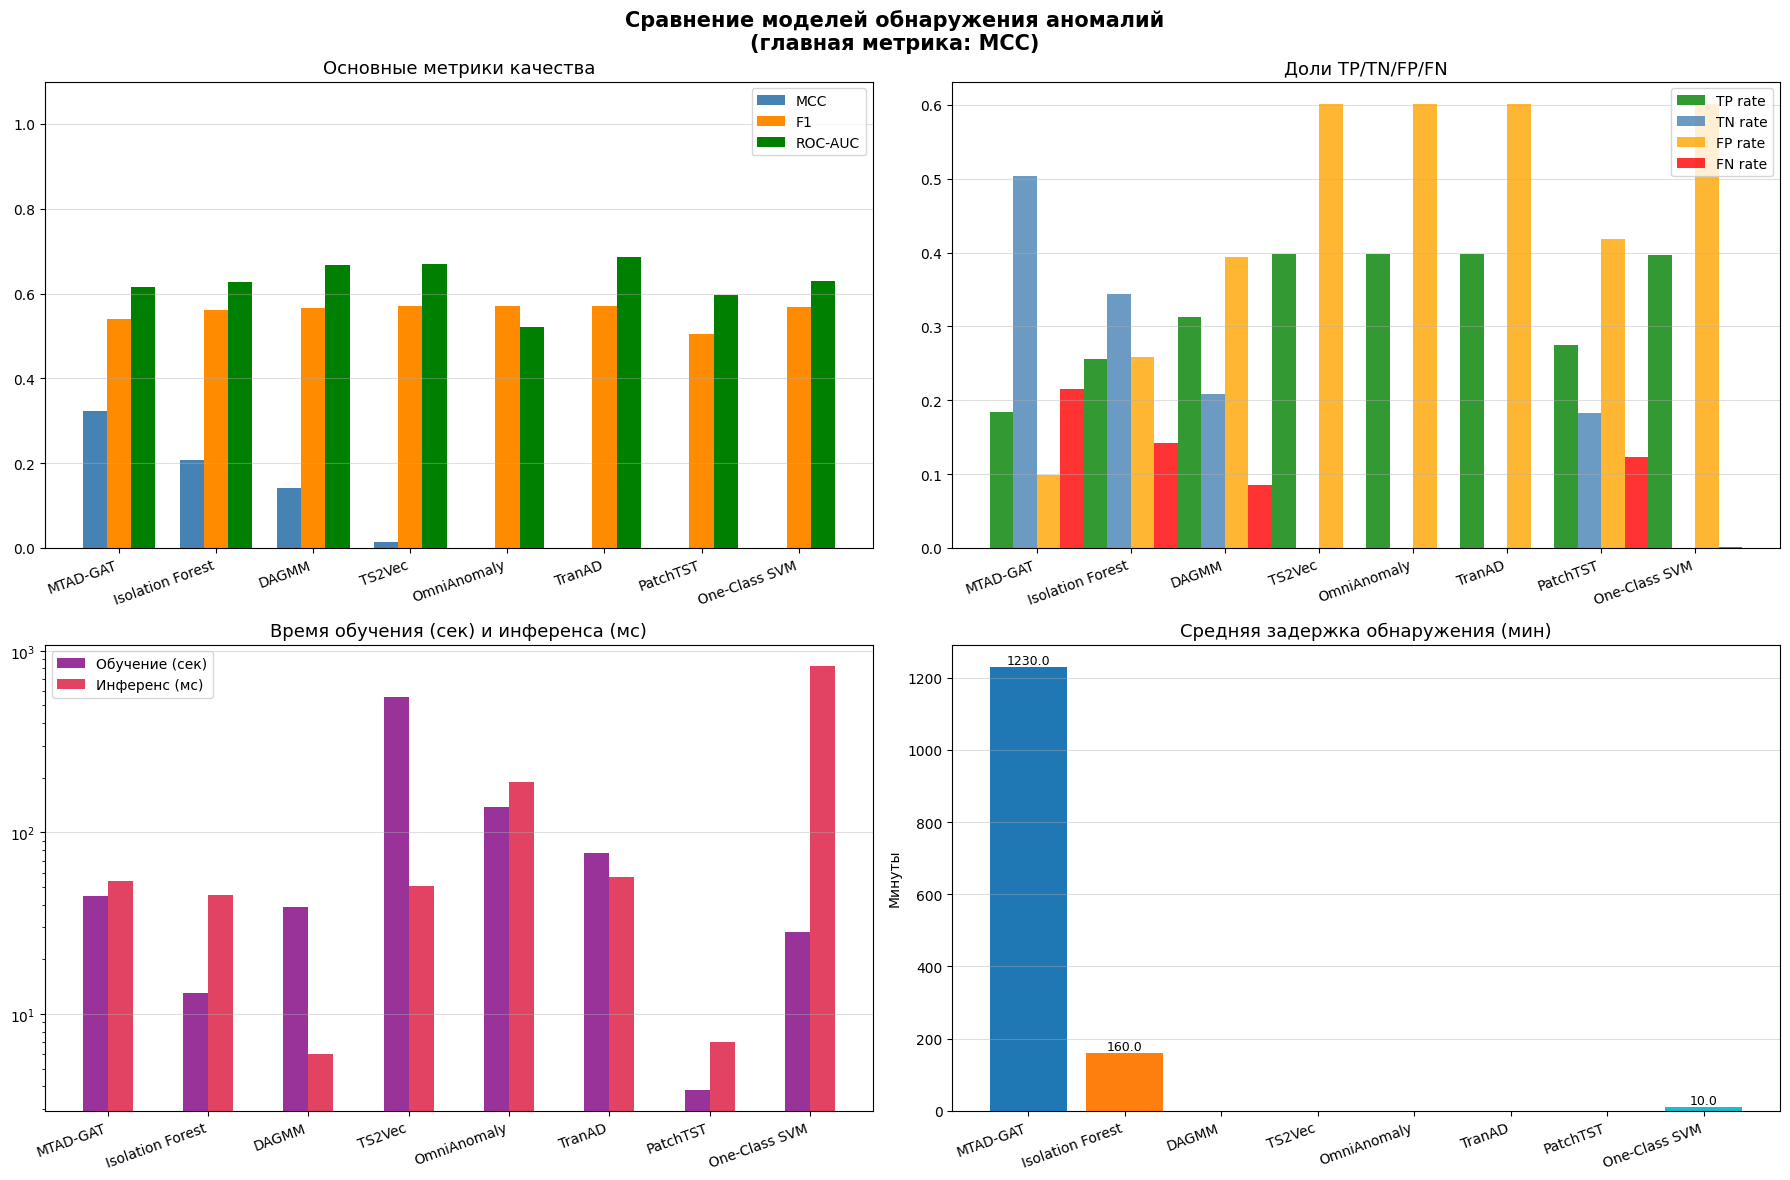

In [ ]:
# =============================================================================
# ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ (общие для всех моделей)
# =============================================================================
import time, warnings
import numpy as np
import pandas as pd
import random, os
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (matthews_corrcoef, f1_score, roc_auc_score,
                             confusion_matrix, precision_score, recall_score)
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}")

# ---------- метрики ----------
def compute_metrics(y_true, y_pred, y_scores=None):
    cm = confusion_matrix(y_true, y_pred)
    if cm.size == 4:
        tn, fp, fn, tp = cm.ravel()
    else:
        tn = fp = fn = tp = 0
    n = len(y_true)
    return {
        'MCC':       round(matthews_corrcoef(y_true, y_pred), 4),
        'F1':        round(f1_score(y_true, y_pred, zero_division=0), 4),
        'ROC_AUC':   round(roc_auc_score(y_true, y_scores), 4)
                     if y_scores is not None and len(np.unique(y_true)) > 1
                     else np.nan,
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_true, y_pred, zero_division=0), 4),
        'TP_rate':   round(tp / n, 4),
        'FP_rate':   round(fp / n, 4),
        'TN_rate':   round(tn / n, 4),
        'FN_rate':   round(fn / n, 4),
    }

# ---------- задержка обнаружения ----------
def detection_delay(times, y_true, y_pred, step_minutes=30):
    """
    Для каждого непрерывного аномального периода находит первое
    корректное срабатывание. Возвращает среднюю задержку в минутах.
    Точечное присвоение: каждой точке — своя метка.
    """
    df = pd.DataFrame({'t': times, 'yt': y_true, 'yp': y_pred})
    df['group'] = (df['yt'] != df['yt'].shift()).cumsum()
    delays = []
    for _, grp in df[df['yt'] == 1].groupby('group'):
        t_start = grp['t'].iloc[0]
        hits = grp[grp['yp'] == 1]
        if not hits.empty:
            delay = (hits['t'].iloc[0] - t_start).total_seconds() / 60
            delays.append(delay)
        # если не обнаружено — не включаем в среднее (conservative)
    return round(np.mean(delays), 2) if delays else np.nan

# ---------- подбор порога по валидации (максимизация MCC) ----------
def best_threshold_by_mcc(scores_val, y_val_bin, percentile_grid=None):
    if percentile_grid is None:
        percentile_grid = np.arange(50, 99, 1)
    best_mcc, best_thr = -2, np.percentile(scores_val, 90)
    for pct in percentile_grid:
        thr = np.percentile(scores_val, pct)
        pred = (scores_val >= thr).astype(int)
        try:
            mcc = matthews_corrcoef(y_val_bin, pred)
        except Exception:
            mcc = -2
        if mcc > best_mcc:
            best_mcc, best_thr = mcc, thr
    return best_thr, best_mcc

# ---------- sliding window dataset ----------
def make_windows(X: np.ndarray, win: int):
    """Возвращает (N-win+1, win, F) — каждое окно, метка = последней точке."""
    out = np.lib.stride_tricks.sliding_window_view(X, (win, X.shape[1]))
    return out.squeeze(1)          # (N-win+1, win, F)

def window_scores_to_point(scores_win, n_total, win):
    """
    Разворачивает оценки окон в точечные оценки.
    Каждой точке присваивается оценка окна, в котором она ПОСЛЕДНЯЯ.
    Первые (win-1) точек получают оценку первого окна.
    """
    point_scores = np.empty(n_total)
    point_scores[:win - 1] = scores_win[0]
    point_scores[win - 1:] = scores_win
    return point_scores

results_table = {}

y_val_bin  = (y_val  == "Anomaly").astype(int).values
y_test_bin = (y_test == "Anomaly").astype(int).values

X_tr_np  = X_train_scaled.values.astype(np.float32)
X_va_np  = X_val_scaled.values.astype(np.float32)
X_te_np  = X_test_scaled.values.astype(np.float32)
n_features = X_tr_np.shape[1]

# =============================================================================
# ISOLATION FOREST
# =============================================================================
print("\n" + "="*60)
print("1/7  Isolation Forest")
print("="*60)

from sklearn.ensemble import IsolationForest

t0 = time.time()

best_mcc_val, best_cont = -2, 0.1
for cont in np.arange(0.01, 0.50, 0.01):
    m = IsolationForest(n_estimators=200, contamination=round(float(cont), 2),
                        random_state=42, n_jobs=-1)
    m.fit(X_tr_np)
    pred = (m.predict(X_va_np) == -1).astype(int)
    mcc = matthews_corrcoef(y_val_bin, pred)
    if mcc > best_mcc_val:
        best_mcc_val, best_cont = mcc, round(float(cont), 2)

iso = IsolationForest(n_estimators=200, contamination=best_cont,
                      random_state=42, n_jobs=-1)
iso.fit(X_tr_np)
train_time_if = time.time() - t0

t1 = time.time()
scores_if  = -iso.decision_function(X_te_np)   # выше = аномальнее
pred_if    = (iso.predict(X_te_np) == -1).astype(int)
infer_time_if = time.time() - t1

m_if = compute_metrics(y_test_bin, pred_if, scores_if)
m_if['Train_sec']  = round(train_time_if, 2)
m_if['Infer_sec']  = round(infer_time_if, 4)
m_if['Delay_min']  = detection_delay(test_df['Time'].values, y_test_bin, pred_if)
m_if['Best_param'] = f"contamination={best_cont}"
results_table['Isolation Forest'] = m_if
print(f"  MCC={m_if['MCC']}  F1={m_if['F1']}  contamination={best_cont}")

# =============================================================================
# ONE-CLASS SVM
# =============================================================================
print("\n" + "="*60)
print("2/7  One-Class SVM")
print("="*60)

from sklearn.svm import OneClassSVM

t0 = time.time()

best_mcc_val, best_nu = -2, 0.1
for nu in np.arange(0.01, 0.50, 0.01):
    m = OneClassSVM(kernel='rbf', nu=round(float(nu), 2), gamma='scale')
    m.fit(X_tr_np)
    pred = (m.predict(X_va_np) == -1).astype(int)
    mcc = matthews_corrcoef(y_val_bin, pred)
    if mcc > best_mcc_val:
        best_mcc_val, best_nu = mcc, round(float(nu), 2)

ocsvm = OneClassSVM(kernel='rbf', nu=best_nu, gamma='scale')
ocsvm.fit(X_tr_np)
train_time_svm = time.time() - t0

t1 = time.time()
scores_svm = -ocsvm.decision_function(X_te_np)
pred_svm   = (ocsvm.predict(X_te_np) == -1).astype(int)
infer_time_svm = time.time() - t1

m_svm = compute_metrics(y_test_bin, pred_svm, scores_svm)
m_svm['Train_sec']  = round(train_time_svm, 2)
m_svm['Infer_sec']  = round(infer_time_svm, 4)
m_svm['Delay_min']  = detection_delay(test_df['Time'].values, y_test_bin, pred_svm)
m_svm['Best_param'] = f"nu={best_nu}"
results_table['One-Class SVM'] = m_svm
print(f"  MCC={m_svm['MCC']}  F1={m_svm['F1']}  nu={best_nu}")

# =============================================================================
# DAGMM — реализация по статье
# "Deep Autoencoding Gaussian Mixture Model for Unsupervised Anomaly Detection"
# =============================================================================
print("\n" + "="*60)
print("3/7  DAGMM")
print("="*60)

class CompressionNetwork(nn.Module):
    """Encoder-Decoder из статьи + относительный евклид + косинус."""
    def __init__(self, input_dim, hidden_dims, latent_dim):
        super().__init__()
        # Encoder
        enc_layers = []
        in_d = input_dim
        for h in hidden_dims:
            enc_layers += [nn.Linear(in_d, h), nn.Tanh()]
            in_d = h
        enc_layers.append(nn.Linear(in_d, latent_dim))
        self.encoder = nn.Sequential(*enc_layers)
        # Decoder
        dec_layers = []
        in_d = latent_dim
        for h in reversed(hidden_dims):
            dec_layers += [nn.Linear(in_d, h), nn.Tanh()]
            in_d = h
        dec_layers.append(nn.Linear(in_d, input_dim))
        self.decoder = nn.Sequential(*dec_layers)

    def forward(self, x):
        z_c = self.encoder(x)
        x_hat = self.decoder(z_c)
        # reconstruction features (статья, раздел 3.1)
        rec_euc = torch.norm(x - x_hat, dim=1, keepdim=True) / (
                  torch.norm(x, dim=1, keepdim=True) + 1e-8)
        rec_cos = torch.sum(x * x_hat, dim=1, keepdim=True) / (
                  torch.norm(x, dim=1, keepdim=True) *
                  torch.norm(x_hat, dim=1, keepdim=True) + 1e-8)
        # итоговое представление z = [z_c, rec_euc, rec_cos]
        z = torch.cat([z_c, rec_euc, rec_cos], dim=1)
        return x_hat, z


class EstimationNetwork(nn.Module):
    """MLP → softmax → membership γ."""
    def __init__(self, z_dim, hidden_dims, n_gmm):
        super().__init__()
        layers = []
        in_d = z_dim
        for h in hidden_dims:
            layers += [nn.Linear(in_d, h), nn.Tanh(), nn.Dropout(0.5)]
            in_d = h
        layers += [nn.Linear(in_d, n_gmm), nn.Softmax(dim=1)]
        self.net = nn.Sequential(*layers)

    def forward(self, z):
        return self.net(z)


class DAGMMModel(nn.Module):
    def __init__(self, input_dim, n_gmm=4, latent_dim=1,
                 enc_hidden=(60, 30, 10), est_hidden=(10,)):
        super().__init__()
        self.compression  = CompressionNetwork(input_dim, list(enc_hidden), latent_dim)
        z_dim = latent_dim + 2
        self.estimation   = EstimationNetwork(z_dim, list(est_hidden), n_gmm)
        self.n_gmm        = n_gmm
        self.z_dim        = z_dim
        # GMM параметры (обновляются батч-статистиками)
        self.register_buffer('phi',    torch.zeros(n_gmm))
        self.register_buffer('mu',     torch.zeros(n_gmm, z_dim))
        self.register_buffer('sigma',  torch.eye(z_dim).unsqueeze(0).repeat(n_gmm, 1, 1))

    def forward(self, x):
        x_hat, z = self.compression(x)
        gamma     = self.estimation(z)
        return x_hat, z, gamma

    @torch.no_grad()
    def update_gmm_params(self, z, gamma):
        """Формулы (3)-(5) из статьи."""
        N = z.shape[0]
        gamma_sum = gamma.sum(0)                           # (K,)
        phi   = gamma_sum / N
        mu    = (gamma.T @ z) / gamma_sum.unsqueeze(1)    # (K, D)
        sigma = torch.zeros(self.n_gmm, self.z_dim, self.z_dim,
                            device=z.device)
        for k in range(self.n_gmm):
            diff = z - mu[k]                               # (N, D)
            sigma[k] = (gamma[:, k:k+1] * diff).T @ diff / gamma_sum[k]
        self.phi.copy_(phi)
        self.mu.copy_(mu)
        self.sigma.copy_(sigma)

    def energy(self, z):
        """Формула (6) из статьи — sample energy."""
        eps = 1e-6
        energies = []
        for k in range(self.n_gmm):
            diff = z - self.mu[k]                          # (N, D)
            cov  = self.sigma[k] + eps * torch.eye(
                   self.z_dim, device=z.device)
            cov_inv = torch.linalg.inv(cov)
            det_cov  = torch.linalg.det(cov).clamp(min=eps)
            mah = (diff.unsqueeze(1) @ cov_inv @ diff.unsqueeze(2)).squeeze()
            e_k = self.phi[k] * torch.exp(-0.5 * mah) / (
                  (2 * torch.pi) ** (self.z_dim / 2) * det_cov.sqrt())
            energies.append(e_k)
        E = torch.stack(energies, dim=1).sum(1).clamp(min=eps)
        return -torch.log(E)


def dagmm_loss(x, x_hat, z, gamma, model, lambda1=0.1, lambda2=0.005):
    """
    L = rec_loss + λ1·energy + λ2·diag_penalty  (формула 8)
    """
    rec_loss    = torch.mean((x - x_hat) ** 2)
    model.update_gmm_params(z.detach(), gamma.detach())
    energy      = model.energy(z).mean()
    # диагональный штраф (предотвращает вырождение ковариации)
    diag_penalty = torch.tensor(0., device=x.device)
    for k in range(model.n_gmm):
        cov = model.sigma[k]
        diag_penalty = diag_penalty + (1.0 / cov.diag().clamp(min=1e-8)).sum()
    return rec_loss + lambda1 * energy + lambda2 * diag_penalty


# --- подбор n_gmm по валидации ---
t0 = time.time()
best_mcc_val, best_n_gmm = -2, 2

for n_gmm in [2, 4, 6]:
    torch.manual_seed(42)
    _model = DAGMMModel(n_features, n_gmm=n_gmm, latent_dim=1).to(DEVICE)
    _opt   = torch.optim.Adam(_model.parameters(), lr=1e-3, weight_decay=1e-4)
    _loader = DataLoader(TensorDataset(torch.FloatTensor(X_tr_np)),
                         batch_size=1024, shuffle=True)
    _model.train()
    for _ in range(100):
        for (b,) in _loader:
            b = b.to(DEVICE)
            xh, z, g = _model(b)
            loss = dagmm_loss(b, xh, z, g, _model)
            _opt.zero_grad(); loss.backward(); _opt.step()

    _model.eval()
    with torch.no_grad():
        xh, z, g = _model(torch.FloatTensor(X_va_np).to(DEVICE))
        _model.update_gmm_params(z, g)
        sc_va = _model.energy(z).cpu().numpy()
    thr, mcc = best_threshold_by_mcc(sc_va, y_val_bin)
    if mcc > best_mcc_val:
        best_mcc_val, best_n_gmm = mcc, n_gmm

# финальное обучение
torch.manual_seed(42)
dagmm = DAGMMModel(n_features, n_gmm=best_n_gmm, latent_dim=1).to(DEVICE)
opt_dagmm = torch.optim.Adam(dagmm.parameters(), lr=1e-3, weight_decay=1e-4)
loader_dagmm = DataLoader(TensorDataset(torch.FloatTensor(X_tr_np)),
                          batch_size=1024, shuffle=True)
dagmm.train()
for epoch in range(200):
    for (b,) in loader_dagmm:
        b = b.to(DEVICE)
        xh, z, g = dagmm(b)
        loss = dagmm_loss(b, xh, z, g, dagmm)
        opt_dagmm.zero_grad(); loss.backward(); opt_dagmm.step()

train_time_dagmm = time.time() - t0

# порог
dagmm.eval()
with torch.no_grad():
    _, z_va, g_va = dagmm(torch.FloatTensor(X_va_np).to(DEVICE))
    dagmm.update_gmm_params(z_va, g_va)
    sc_dagmm_va = dagmm.energy(z_va).cpu().numpy()
thr_dagmm, _ = best_threshold_by_mcc(sc_dagmm_va, y_val_bin)

t1 = time.time()
with torch.no_grad():
    _, z_te, g_te = dagmm(torch.FloatTensor(X_te_np).to(DEVICE))
    dagmm.update_gmm_params(z_te, g_te)
    sc_dagmm = dagmm.energy(z_te).cpu().numpy()
infer_time_dagmm = time.time() - t1

pred_dagmm = (sc_dagmm >= thr_dagmm).astype(int)
m_dagmm = compute_metrics(y_test_bin, pred_dagmm, sc_dagmm)
m_dagmm['Train_sec']  = round(train_time_dagmm, 2)
m_dagmm['Infer_sec']  = round(infer_time_dagmm, 4)
m_dagmm['Delay_min']  = detection_delay(test_df['Time'].values, y_test_bin, pred_dagmm)
m_dagmm['Best_param'] = f"n_gmm={best_n_gmm}"
results_table['DAGMM'] = m_dagmm
print(f"  MCC={m_dagmm['MCC']}  F1={m_dagmm['F1']}  n_gmm={best_n_gmm}")

# =============================================================================
# OmniAnomaly
# "Robust Anomaly Detection for Multivariate Time Series through
#  Stochastic Recurrent Neural Network"
# =============================================================================
print("\n" + "="*60)
print("4/7  OmniAnomaly (Su et al., 2019)")
print("="*60)

class PlanarFlow(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.w = nn.Parameter(torch.randn(dim) * 0.01)
        self.u = nn.Parameter(torch.randn(dim) * 0.01)
        self.b = nn.Parameter(torch.zeros(1))

    def forward(self, z):
        wu    = self.w @ self.u
        u_hat = self.u + (-1 + torch.log(1 + torch.exp(wu)) - wu) * (
                self.w / (self.w.norm() + 1e-8))
        lin   = z @ self.w + self.b
        h     = torch.tanh(lin)
        z_new = z + u_hat.unsqueeze(0) * h.unsqueeze(1)
        psi   = (1 - h ** 2).unsqueeze(1) * self.w.unsqueeze(0)
        log_det = torch.log((1 + psi @ u_hat.unsqueeze(1)).abs() + 1e-8).squeeze()
        return z_new, log_det


class OmniAnomalyModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=500, latent_dim=20, n_flows=20):
        super().__init__()
        self.latent_dim = latent_dim
        self.enc_gru  = nn.GRU(input_dim, hidden_dim, batch_first=True,
                                num_layers=2, dropout=0.3)
        self.enc_mu   = nn.Linear(hidden_dim, latent_dim)
        self.enc_logv = nn.Linear(hidden_dim, latent_dim)
        self.flows    = nn.ModuleList([PlanarFlow(latent_dim) for _ in range(n_flows)])
        self.dec_gru  = nn.GRU(latent_dim, hidden_dim, batch_first=True,
                                num_layers=2, dropout=0.3)
        self.dec_out  = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h, _ = self.enc_gru(x)
        mu    = self.enc_mu(h)
        logv  = self.enc_logv(h).clamp(-4, 4)
        return mu, logv

    def reparameterize_nf(self, mu, logv):
        std  = torch.exp(0.5 * logv)
        eps  = torch.randn_like(std)
        z0   = mu + eps * std
        # KL divergence per sample (summed over latent dims)
        kl   = -0.5 * (1 + logv - mu.pow(2) - logv.exp()).sum(-1)

        B, T, D = z0.shape
        z    = z0.reshape(B * T, D)
        log_det_sum = torch.zeros(B * T, device=z.device)

        for flow in self.flows:
            z, ld = flow(z)
            log_det_sum = log_det_sum + ld

        z = z.reshape(B, T, D)
        log_det_sum = log_det_sum.reshape(B, T)
        return z, kl, log_det_sum

    def decode(self, z):
        h, _ = self.dec_gru(z)
        return self.dec_out(h)

    def forward(self, x):
        mu, logv       = self.encode(x)
        z, kl, log_det = self.reparameterize_nf(mu, logv)
        x_hat          = self.decode(z)
        return x_hat, mu, logv, kl, log_det


def omni_loss(x, x_hat, kl, log_det, beta=1.0):
    """
    Loss = Reconstruction Error + beta * KL - LogDet
    Minimizing this is equivalent to Maximizing ELBO
    """
    rec  = nn.functional.mse_loss(x_hat, x, reduction='none').sum(-1) # Sum over features
    elbo = rec + beta * kl - log_det
    return elbo.mean()


def score_omni_nll(model, X_np, win):
    """
    Расчет скоринга через Negative Log Likelihood (приближенно через ELBO).
    Score = Rec_Error + KL - LogDet.
    Чем выше скор, тем более аномальна точка.
    """
    model.eval()
    wins   = make_windows(X_np, win)
    scores = []
    loader = DataLoader(TensorDataset(torch.FloatTensor(wins)),
                        batch_size=512, shuffle=False, pin_memory=(DEVICE == 'cuda'))

    with torch.no_grad():
        for (b,) in loader:
            b   = b.to(DEVICE, non_blocking=True)
            # Получаем все компоненты для расчета энергии
            x_hat, mu, logv, kl, log_det = model(b)

            # 1. Reconstruction Error (сумма квадратов ошибок по всем признакам)
            rec_err = torch.sum((b - x_hat)**2, dim=2) # (B, T)

            # 2. Итоговый скор для каждого шага времени в окне:
            # E_t = Rec_t + KL_t - LogDet_t
            point_energy = rec_err + kl - log_det # (B, T)

            # Агрегируем ошибку по окну.
            # Можно брать среднее по окну или максимум.
            # Для детекции аномалий в конце окна часто берут последнюю точку,
            # но усреднение стабильнее. Возьмем среднее по времени для всего окна.
            win_score = point_energy.mean(dim=1) # (B,)

            scores.append(win_score.cpu().numpy())

    scores_win = np.concatenate(scores)
    return window_scores_to_point(scores_win, len(X_np), win)


# --- подбор win (исправленный) ---
t0 = time.time()
best_mcc_val, best_win_omni = -2, 32

for win in [16, 32, 48, 96]:
    if win >= len(X_va_np):
        continue
    torch.manual_seed(42)
    # Немного упростим модель для поиска, чтобы ускорить процесс,
    # но оставим flows, так как они важны для метрики
    _m  = OmniAnomalyModel(n_features, hidden_dim=256, latent_dim=16, n_flows=10).to(DEVICE)
    _o  = torch.optim.Adam(_m.parameters(), lr=1e-3)
    _wins = make_windows(X_tr_np, win)

    _ld = DataLoader(TensorDataset(torch.FloatTensor(_wins)),
                     batch_size=512, shuffle=True,
                     pin_memory=(DEVICE == 'cuda'), num_workers=0)

    _scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == 'cuda'))
    _m.train()

    # Увеличили эпохи с 10 до 30 для лучшей сходимости Flow
    n_search_epochs = 30
    for epoch in range(n_search_epochs):
        # KL Annealing: начинаем с 0, плавно переходим к 1
        beta = min(1.0, (epoch + 1) / (n_search_epochs * 0.5))

        for (b,) in _ld:
            b = b.to(DEVICE, non_blocking=True)
            with torch.autocast(device_type=DEVICE, enabled=(DEVICE == 'cuda')):
                xh, mu, lv, kl, ld_nf = _m(b)
                # передаем beta в функцию потерь
                loss = omni_loss(b, xh, kl, ld_nf, beta=beta)

            _scaler.scale(loss).backward()
            _scaler.step(_o)
            _scaler.update()
            _o.zero_grad(set_to_none=True)

    # Используем новую функцию скора
    sc_va = score_omni_nll(_m, X_va_np, win)
    _, mcc = best_threshold_by_mcc(sc_va, y_val_bin)

    print(f"  Win={win}, Val MCC={mcc:.4f}")

    if mcc > best_mcc_val:
        best_mcc_val, best_win_omni = mcc, win

print(f"Best Win: {best_win_omni}")

# --- финальное обучение ---
torch.manual_seed(42)
omni      = OmniAnomalyModel(n_features, hidden_dim=500, latent_dim=20, n_flows=20).to(DEVICE)
opt_omni  = torch.optim.Adam(omni.parameters(), lr=1e-3)
sched_omni = torch.optim.lr_scheduler.CosineAnnealingLR(opt_omni, T_max=50)
wins_tr    = make_windows(X_tr_np, best_win_omni)

loader_omni = DataLoader(TensorDataset(torch.FloatTensor(wins_tr)),
                         batch_size=512, shuffle=True,
                         pin_memory=(DEVICE == 'cuda'), num_workers=2)
scaler_omni = torch.cuda.amp.GradScaler(enabled=(DEVICE == 'cuda'))

omni.train()
for epoch in range(50):
    # KL Annealing и здесь
    beta = min(1.0, epoch / 20)
    for (b,) in loader_omni:
        b = b.to(DEVICE, non_blocking=True)
        with torch.autocast(device_type=DEVICE, enabled=(DEVICE == 'cuda')):
            xh, mu, lv, kl, ld_nf = omni(b)
            loss = omni_loss(b, xh, kl, ld_nf, beta=beta)
        scaler_omni.scale(loss).backward()
        nn.utils.clip_grad_norm_(omni.parameters(), 10.0)
        scaler_omni.step(opt_omni)
        scaler_omni.update()
        opt_omni.zero_grad(set_to_none=True)
    sched_omni.step()

train_time_omni = time.time() - t0

# Финальный расчет скоров новой функцией
sc_va_omni = score_omni_nll(omni, X_va_np, best_win_omni)
thr_omni, _ = best_threshold_by_mcc(sc_va_omni, y_val_bin)

t1 = time.time()
sc_te_omni = score_omni_nll(omni, X_te_np, best_win_omni)
infer_time_omni = time.time() - t1

pred_omni = (sc_te_omni >= thr_omni).astype(int)
m_omni = compute_metrics(y_test_bin, pred_omni, sc_te_omni)
m_omni['Train_sec']  = round(train_time_omni, 2)
m_omni['Infer_sec']  = round(infer_time_omni, 4)
m_omni['Delay_min']  = detection_delay(test_df['Time'].values, y_test_bin, pred_omni)
m_omni['Best_param'] = f"win={best_win_omni}, flows=20"
results_table['OmniAnomaly'] = m_omni
print(f"  MCC={m_omni['MCC']}  F1={m_omni['F1']}  win={best_win_omni}")


# =============================================================================
# TranAD
# "TranAD: Deep Transformer Networks for Anomaly Detection in
#  Multivariate Time Series Data"
# Архитектура: двухдекодерный Transformer + двухфазное adversarial обучение
# =============================================================================
print("\n" + "="*60)
print("5/7  TranAD")
print("="*60)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() *
                        (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))   # (1, max_len, d_model)

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


class TranADModel(nn.Module):
    """
    Два декодера: D1 (глобальный), D2 (фокусированный на аномалиях).
    """
    def __init__(self, n_features, d_model=64, nhead=8,
                 num_enc_layers=1, num_dec_layers=1, win=32, dropout=0.1):
        super().__init__()
        self.n_features = n_features
        self.d_model    = d_model

        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_enc    = PositionalEncoding(d_model, max_len=win + 1, dropout=dropout)

        enc_layer = nn.TransformerEncoderLayer(d_model, nhead,
                    dim_feedforward=4 * d_model, dropout=dropout, batch_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_enc_layers)

        dec_layer1 = nn.TransformerDecoderLayer(d_model, nhead,
                     dim_feedforward=4 * d_model, dropout=dropout, batch_first=True)
        dec_layer2 = nn.TransformerDecoderLayer(d_model, nhead,
                     dim_feedforward=4 * d_model, dropout=dropout, batch_first=True)
        self.decoder1 = nn.TransformerDecoder(dec_layer1, num_dec_layers)
        self.decoder2 = nn.TransformerDecoder(dec_layer2, num_dec_layers)

        self.proj1 = nn.Linear(d_model, n_features)
        self.proj2 = nn.Linear(d_model, n_features)

    def forward(self, x, x_focus=None):
        """
        x      : (B, W, F) — входное окно
        x_focus: (B, W, F) — для декодера 2 (фокус на аномалиях),
                             если None — используем x
        """
        src = self.pos_enc(self.input_proj(x))     # (B, W, d_model)
        mem = self.encoder(src)

        # Декодер 1 — глобальная реконструкция
        tgt1 = self.pos_enc(self.input_proj(x))
        out1 = self.proj1(self.decoder1(tgt1, mem))  # (B, W, F)

        # Декодер 2 — фокусированная реконструкция
        focus = x_focus if x_focus is not None else x
        tgt2  = self.pos_enc(self.input_proj(focus))
        out2  = self.proj2(self.decoder2(tgt2, mem))  # (B, W, F)

        return out1, out2


def tranad_loss(x, out1, out2, epoch, n_epochs):
    """
    Алгоритм 1: L = (1/n)·||x - O1||² + (n-1)/n·||x - O2||²
    где n = номер эпохи (нумерация с 1)
    """
    n = epoch + 1
    l1 = nn.functional.mse_loss(out1, x)
    l2 = nn.functional.mse_loss(out2, x)
    return l1 / n + (n - 1) / n * l2


def score_tranad(model, X_np, win):
    """Score = ||x_last - O2_last||² (фокусированный декодер, последняя точка)."""
    model.eval()
    wins = make_windows(X_np, win)
    scores = []
    loader = DataLoader(TensorDataset(torch.FloatTensor(wins)),
                        batch_size=256, shuffle=False)
    with torch.no_grad():
        for (b,) in loader:
            b = b.to(DEVICE)
            _, out2 = model(b)
            err = torch.mean((b[:, -1, :] - out2[:, -1, :]) ** 2, dim=1)
            scores.append(err.cpu().numpy())
    scores_win = np.concatenate(scores)
    return window_scores_to_point(scores_win, len(X_np), win)


# подбор win
t0 = time.time()
best_mcc_val, best_win_tr = -2, 32
for win in [16, 32, 48, 96]:
    if win >= len(X_va_np): continue
    torch.manual_seed(42)
    _m = TranADModel(n_features, d_model=32, nhead=min(4, n_features),
                     win=win).to(DEVICE)
    _o = torch.optim.AdamW(_m.parameters(), lr=1e-4, weight_decay=1e-5)
    _wins = make_windows(X_tr_np, win)
    _ld = DataLoader(TensorDataset(torch.FloatTensor(_wins)),
                     batch_size=128, shuffle=True)
    _m.train()
    for ep in range(15):
        for (b,) in _ld:
            b = b.to(DEVICE)
            o1, o2 = _m(b)
            loss = tranad_loss(b, o1, o2, ep, 15)
            _o.zero_grad(); loss.backward(); _o.step()

    sc_va = score_tranad(_m, X_va_np, win)
    _, mcc = best_threshold_by_mcc(sc_va, y_val_bin)
    if mcc > best_mcc_val:
        best_mcc_val, best_win_tr = mcc, win

# финальное обучение
n_epochs_tr = 100
torch.manual_seed(42)
tranad = TranADModel(n_features, d_model=64,
                     nhead=min(8, n_features // 2 * 2 or 2),
                     num_enc_layers=1, num_dec_layers=1,
                     win=best_win_tr).to(DEVICE)
opt_tranad = torch.optim.AdamW(tranad.parameters(), lr=1e-4, weight_decay=1e-5)
sched_tr   = torch.optim.lr_scheduler.CosineAnnealingLR(opt_tranad, T_max=n_epochs_tr)
wins_tr_td = make_windows(X_tr_np, best_win_tr)
loader_tr  = DataLoader(TensorDataset(torch.FloatTensor(wins_tr_td)),
                         batch_size=128, shuffle=True)
tranad.train()
for epoch in range(n_epochs_tr):
    for (b,) in loader_tr:
        b = b.to(DEVICE)
        o1, o2 = tranad(b)
        loss = tranad_loss(b, o1, o2, epoch, n_epochs_tr)
        opt_tranad.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(tranad.parameters(), 1.0)
        opt_tranad.step()
    sched_tr.step()

train_time_tr = time.time() - t0

sc_va_tr = score_tranad(tranad, X_va_np, best_win_tr)
thr_tr, _ = best_threshold_by_mcc(sc_va_tr, y_val_bin)

t1 = time.time()
sc_te_tr = score_tranad(tranad, X_te_np, best_win_tr)
infer_time_tr = time.time() - t1

pred_tr = (sc_te_tr >= thr_tr).astype(int)
m_tr = compute_metrics(y_test_bin, pred_tr, sc_te_tr)
m_tr['Train_sec']  = round(train_time_tr, 2)
m_tr['Infer_sec']  = round(infer_time_tr, 4)
m_tr['Delay_min']  = detection_delay(test_df['Time'].values, y_test_bin, pred_tr)
m_tr['Best_param'] = f"win={best_win_tr}, d_model=64"
results_table['TranAD'] = m_tr
print(f"  MCC={m_tr['MCC']}  F1={m_tr['F1']}  win={best_win_tr}")

# =============================================================================
# БЛОК 7: MTAD-GAT
# "Multivariate Time-Series Anomaly Detection via Graph Attention Networks"
# =============================================================================
print("\n" + "="*60)
print("6/7  MTAD-GAT")
print("="*60)

class FeatureAttentionLayer(nn.Module):
    """GAT по оси признаков"""
    def __init__(self, n_features, win, dropout=0.2):
        super().__init__()
        self.n_features = n_features
        # каждый признак — узел графа, представление = его временной ряд в окне
        self.W   = nn.Linear(win, win, bias=False)
        self.attn = nn.Linear(2 * win, 1)
        self.dropout = nn.Dropout(dropout)
        self.leaky = nn.LeakyReLU(0.2)

    def forward(self, x):
        # x: (B, W, F) → транспонируем → (B, F, W) — каждый признак как узел
        x_t = x.transpose(1, 2)                   # (B, F, W)
        h   = self.W(x_t)                          # (B, F, W)
        # попарное внимание
        h_i = h.unsqueeze(2).expand(-1, -1, self.n_features, -1)  # (B,F,F,W)
        h_j = h.unsqueeze(1).expand(-1, self.n_features, -1, -1)  # (B,F,F,W)
        e   = self.leaky(self.attn(torch.cat([h_i, h_j], dim=-1)).squeeze(-1))  # (B,F,F)
        a   = torch.softmax(e, dim=-1)
        a   = self.dropout(a)
        out = (a @ h).transpose(1, 2)             # (B, W, F)
        return out


class TemporalAttentionLayer(nn.Module):
    """GAT по временной оси (рис. 2, time-oriented)."""
    def __init__(self, n_features, win, dropout=0.2):
        super().__init__()
        self.W    = nn.Linear(n_features, n_features, bias=False)
        self.attn = nn.Linear(2 * n_features, 1)
        self.dropout = nn.Dropout(dropout)
        self.leaky   = nn.LeakyReLU(0.2)

    def forward(self, x):
        # x: (B, W, F) — каждый момент времени = узел
        h   = self.W(x)                            # (B, W, F)
        h_i = h.unsqueeze(2).expand(-1, -1, h.size(1), -1)
        h_j = h.unsqueeze(1).expand(-1, h.size(1), -1, -1)
        e   = self.leaky(self.attn(torch.cat([h_i, h_j], dim=-1)).squeeze(-1))
        a   = torch.softmax(e, dim=-1)
        a   = self.dropout(a)
        out = a @ h                                 # (B, W, F)
        return out


class MTADGATModel(nn.Module):
    """
    Архитектура:
    FeatureGAT + TemporalGAT → конкатенация → GRU → VAE → реконструкция + прогноз
    """
    def __init__(self, n_features, win, hidden=150, latent=20, dropout=0.2):
        super().__init__()
        self.feat_gat = FeatureAttentionLayer(n_features, win, dropout)
        self.time_gat = TemporalAttentionLayer(n_features, win, dropout)

        # после двух GAT конкатенируем: (B, W, 3*F)
        self.gru = nn.GRU(3 * n_features, hidden, batch_first=True,
                           num_layers=2, dropout=dropout)

        # VAE encoder
        self.fc_mu   = nn.Linear(hidden, latent)
        self.fc_logv = nn.Linear(hidden, latent)

        # Decoder (реконструкция)
        self.rec_dec = nn.Sequential(
            nn.Linear(latent, hidden), nn.ReLU(),
            nn.Linear(hidden, n_features)
        )
        # Прогнозная голова (forecast для следующей точки)
        self.fore_dec = nn.Sequential(
            nn.Linear(hidden, hidden // 2), nn.ReLU(),
            nn.Linear(hidden // 2, n_features)
        )

    def forward(self, x):
        # x: (B, W, F)
        h_f = self.feat_gat(x)                    # (B, W, F)
        h_t = self.time_gat(x)                    # (B, W, F)
        cat = torch.cat([x, h_f, h_t], dim=-1)    # (B, W, 3F)

        gru_out, _ = self.gru(cat)                # (B, W, hidden)
        last = gru_out[:, -1, :]                  # (B, hidden)

        mu   = self.fc_mu(last)
        logv = self.fc_logv(last).clamp(-4, 4)
        std  = torch.exp(0.5 * logv)
        z    = mu + std * torch.randn_like(std)

        x_rec  = self.rec_dec(z)                  # (B, F) — реконструкция последней точки
        x_fore = self.fore_dec(last)              # (B, F) — прогноз следующей
        kl     = -0.5 * (1 + logv - mu.pow(2) - logv.exp()).sum(-1).mean()
        return x_rec, x_fore, kl


def mtad_loss(x_last, x_next, x_rec, x_fore, kl, beta=1.0):
    rec_l  = nn.functional.mse_loss(x_rec,  x_last)
    fore_l = nn.functional.mse_loss(x_fore, x_next)
    return rec_l + fore_l + beta * kl


def score_mtad(model, X_np, win):
    model.eval()
    wins = make_windows(X_np, win)             # (N-W+1, W, F)
    scores = []
    loader = DataLoader(TensorDataset(torch.FloatTensor(wins)),
                        batch_size=256, shuffle=False)
    with torch.no_grad():
        for (b,) in loader:
            b = b.to(DEVICE)
            x_rec, x_fore, _ = model(b)
            # score = rec_err + fore_err (обе головы)
            rec_e  = torch.mean((b[:, -1, :] - x_rec) ** 2, dim=1)
            # прогноз следующей точки → нет gt в окне, используем только rec
            err = rec_e
            scores.append(err.cpu().numpy())
    scores_win = np.concatenate(scores)
    return window_scores_to_point(scores_win, len(X_np), win)


# подбор win
t0 = time.time()
best_mcc_val, best_win_mt = -2, 32
for win in [16, 32, 48, 96]:
    if win >= len(X_va_np): continue
    torch.manual_seed(42)
    _m = MTADGATModel(n_features, win, hidden=64, latent=10).to(DEVICE)
    _o = torch.optim.Adam(_m.parameters(), lr=1e-3)
    _wins = make_windows(X_tr_np, win)
    _ld = DataLoader(TensorDataset(torch.FloatTensor(_wins)),
                     batch_size=128, shuffle=True)
    _m.train()
    for _ in range(15):
        for (b,) in _ld:
            b = b.to(DEVICE)
            xr, xf, kl = _m(b)
            # для x_next берём следующее окно — аппроксимируем нулём в быстром поиске
            loss = nn.functional.mse_loss(xr, b[:, -1, :]) + 0.001 * kl
            _o.zero_grad(); loss.backward(); _o.step()

    sc_va = score_mtad(_m, X_va_np, win)
    _, mcc = best_threshold_by_mcc(sc_va, y_val_bin)
    if mcc > best_mcc_val:
        best_mcc_val, best_win_mt = mcc, win

# финальное обучение — с прогнозной головой на реальных данных
torch.manual_seed(42)
mtad = MTADGATModel(n_features, best_win_mt, hidden=150, latent=20).to(DEVICE)
opt_mtad  = torch.optim.Adam(mtad.parameters(), lr=1e-4, weight_decay=1e-5)
sched_mt  = torch.optim.lr_scheduler.StepLR(opt_mtad, step_size=20, gamma=0.5)

wins_tr_mt = make_windows(X_tr_np, best_win_mt)  # (N, W, F)
# для прогнозной головы нужна следующая точка
X_next_tr  = X_tr_np[best_win_mt:]               # (N-1, F) — следующие точки
wins_for_fore = wins_tr_mt[:-1]                  # выравниваем

loader_mt = DataLoader(
    TensorDataset(torch.FloatTensor(wins_for_fore),
                  torch.FloatTensor(X_next_tr)),
    batch_size=128, shuffle=True)

mtad.train()
for epoch in range(50):
    for (b_win, b_next) in loader_mt:
        b_win, b_next = b_win.to(DEVICE), b_next.to(DEVICE)
        xr, xf, kl = mtad(b_win)
        beta = min(1.0, epoch / 20)
        loss = mtad_loss(b_win[:, -1, :], b_next, xr, xf, kl, beta)
        opt_mtad.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(mtad.parameters(), 5.0)
        opt_mtad.step()
    sched_mt.step()

train_time_mt = time.time() - t0

sc_va_mt = score_mtad(mtad, X_va_np, best_win_mt)
thr_mt, _ = best_threshold_by_mcc(sc_va_mt, y_val_bin)

t1 = time.time()
sc_te_mt = score_mtad(mtad, X_te_np, best_win_mt)
infer_time_mt = time.time() - t1

pred_mt = (sc_te_mt >= thr_mt).astype(int)
m_mt = compute_metrics(y_test_bin, pred_mt, sc_te_mt)
m_mt['Train_sec']  = round(train_time_mt, 2)
m_mt['Infer_sec']  = round(infer_time_mt, 4)
m_mt['Delay_min']  = detection_delay(test_df['Time'].values, y_test_bin, pred_mt)
m_mt['Best_param'] = f"win={best_win_mt}, hidden=150"
results_table['MTAD-GAT'] = m_mt
print(f"  MCC={m_mt['MCC']}  F1={m_mt['F1']}  win={best_win_mt}")

# =============================================================================
# TS2Vec
# "TS2Vec: Towards Universal Representation of Time Series"
# Иерархический контрастивный loss по времени
# =============================================================================
print("\n" + "="*60)
print("7/8  TS2Vec")
print("="*60)

class DilatedConvBlock(nn.Module):
    """Каузальная дилатированная свёртка из TS2Vec"""
    def __init__(self, channels, dilation):
        super().__init__()
        self.conv = nn.Conv1d(channels, channels, kernel_size=3,
                              padding=dilation, dilation=dilation)
        self.norm = nn.LayerNorm(channels)
        self.act  = nn.GELU()

    def forward(self, x):
        # x: (B, C, T)
        residual = x
        out = self.act(self.conv(x))
        # LayerNorm по C-оси
        out = self.norm(out.transpose(1, 2)).transpose(1, 2)
        return out + residual


class TS2VecEncoder(nn.Module):
    """
    Encoder из TS2Vec: input_proj → стек дилатированных Conv → repr
    """
    def __init__(self, input_dim, hidden=64, depth=10):
        super().__init__()
        self.input_proj = nn.Conv1d(input_dim, hidden, kernel_size=1)
        self.blocks = nn.ModuleList([
            DilatedConvBlock(hidden, dilation=2 ** i)
            for i in range(depth)
        ])
        self.repr_dim = hidden

    def forward(self, x, mask=None):
        # x: (B, T, F)
        out = self.input_proj(x.transpose(1, 2))   # (B, hidden, T)
        if mask is not None:
            out = out * mask.unsqueeze(1)
        for block in self.blocks:
            out = block(out)
        return out.transpose(1, 2)                  # (B, T, hidden)


def hierarchical_contrastive_loss(z1, z2, alpha=0.5, temporal_unit=0):
    """
    Формула из статьи TS2Vec:
    L = α·L_temporal + (1-α)·L_instance
    Temporal: контрастив по временной оси
    Instance: контрастив по батч-оси
    """
    def instance_contrastive(z1, z2):
        B, T, D = z1.shape
        z = torch.cat([z1, z2], dim=0)            # (2B, T, D)
        z_mean = z.mean(1)                         # (2B, D)
        sim = nn.functional.cosine_similarity(
              z_mean.unsqueeze(1), z_mean.unsqueeze(0), dim=-1)  # (2B, 2B)
        # NT-Xent
        logits = sim / 0.2
        labels = torch.arange(B, device=z1.device)
        labels = torch.cat([labels + B, labels])
        loss = nn.functional.cross_entropy(logits, labels)
        return loss

    def temporal_contrastive(z1, z2):
        B, T, D = z1.shape
        if T < 2: return torch.tensor(0., device=z1.device)
        loss = torch.tensor(0., device=z1.device)
        depth = int(np.log2(T))
        for i in range(temporal_unit, depth):
            t = T // (2 ** (i + 1))
            if t == 0: break
            # усредняем соседние сегменты
            z1_seg = z1[:, :2*t].reshape(B, t, 2, D).mean(2)   # (B, t, D)
            z2_seg = z2[:, :2*t].reshape(B, t, 2, D).mean(2)
            sim = nn.functional.cosine_similarity(
                  z1_seg.unsqueeze(2), z2_seg.unsqueeze(1), dim=-1)  # (B, t, t)
            sim = sim / 0.2
            labels = torch.arange(t, device=z1.device).unsqueeze(0).expand(B, -1)
            loss = loss + nn.functional.cross_entropy(
                   sim.reshape(B * t, t), labels.reshape(B * t))
        return loss

    l_inst = instance_contrastive(z1, z2)
    l_temp = temporal_contrastive(z1, z2)
    return alpha * l_temp + (1 - alpha) * l_inst


def augment_ts2vec(x):
    """Два вида аугментации: random crop + jitter."""
    B, T, F = x.shape
    # Random crop (subseries)
    t = np.random.randint(T // 2, T)
    start = np.random.randint(0, T - t + 1)
    x1 = x[:, start:start + t, :]
    # Pad до T
    x1 = nn.functional.pad(x1.transpose(1, 2), (0, T - t)).transpose(1, 2)
    # Jitter для второго вида
    x2 = x + 0.01 * torch.randn_like(x)
    return x1, x2


def score_ts2vec(encoder, X_np, batch_size=512):
    """
    Anomaly score через расстояние от тренировочного центроида.
    Используем расстояние Махаланобиса в пространстве repr.
    """
    encoder.eval()
    loader = DataLoader(TensorDataset(torch.FloatTensor(X_np[:, np.newaxis, :])),
                        batch_size=batch_size, shuffle=False)
    reprs = []
    with torch.no_grad():
        for (b,) in loader:
            z = encoder(b.to(DEVICE))
            reprs.append(z[:, 0, :].cpu().numpy())
    return np.concatenate(reprs)


t0 = time.time()
ts2vec_enc = TS2VecEncoder(n_features, hidden=64, depth=10).to(DEVICE)
opt_ts2    = torch.optim.AdamW(ts2vec_enc.parameters(), lr=3e-4, weight_decay=1e-4)

# Обучение: sliding window 32 + hierarchical contrastive
WIN_TS2 = 32
wins_ts2 = make_windows(X_tr_np, WIN_TS2)          # (N, W, F)
loader_ts2 = DataLoader(TensorDataset(torch.FloatTensor(wins_ts2)),
                        batch_size=16, shuffle=True)

ts2vec_enc.train()
for epoch in range(100):
    for (b,) in loader_ts2:
        b = b.to(DEVICE)
        x1, x2 = augment_ts2vec(b)
        z1 = ts2vec_enc(x1)
        z2 = ts2vec_enc(x2)
        loss = hierarchical_contrastive_loss(z1, z2)
        opt_ts2.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(ts2vec_enc.parameters(), 1.0)
        opt_ts2.step()

# Строим центроид на трейне
ts2vec_enc.eval()
wins_te_ts2 = make_windows(X_tr_np, WIN_TS2)
all_reprs = []
with torch.no_grad():
    for b in DataLoader(TensorDataset(torch.FloatTensor(wins_te_ts2)),
                        batch_size=512, shuffle=False):
        z = ts2vec_enc(b[0].to(DEVICE))
        all_reprs.append(z[:, -1, :].cpu().numpy())    # последняя точка окна
train_reprs = np.concatenate(all_reprs)
centroid = train_reprs.mean(0)

train_time_ts2 = time.time() - t0

def ts2vec_scores(X_np, win):
    wins = make_windows(X_np, win)
    reprs = []
    with torch.no_grad():
        for b in DataLoader(TensorDataset(torch.FloatTensor(wins)),
                            batch_size=512, shuffle=False):
            z = ts2vec_enc(b[0].to(DEVICE))
            reprs.append(z[:, -1, :].cpu().numpy())
    r = np.concatenate(reprs)
    scores_win = np.linalg.norm(r - centroid, axis=1)
    return window_scores_to_point(scores_win, len(X_np), win)

sc_va_ts2 = ts2vec_scores(X_va_np, WIN_TS2)
thr_ts2, _ = best_threshold_by_mcc(sc_va_ts2, y_val_bin)

t1 = time.time()
sc_te_ts2 = ts2vec_scores(X_te_np, WIN_TS2)
infer_time_ts2 = time.time() - t1

pred_ts2 = (sc_te_ts2 >= thr_ts2).astype(int)
m_ts2 = compute_metrics(y_test_bin, pred_ts2, sc_te_ts2)
m_ts2['Train_sec']  = round(train_time_ts2, 2)
m_ts2['Infer_sec']  = round(infer_time_ts2, 4)
m_ts2['Delay_min']  = detection_delay(test_df['Time'].values, y_test_bin, pred_ts2)
m_ts2['Best_param'] = f"win={WIN_TS2}, depth=10, hidden=64"
results_table['TS2Vec'] = m_ts2
print(f"  TS2Vec  MCC={m_ts2['MCC']}  F1={m_ts2['F1']}")

# =============================================================================
# PatchTST
# "A Time Series is Worth 64 Words: Long-term Forecasting with Transformers"
# Адаптация для аномалий: патчевый Transformer + reconstruction score
# =============================================================================
def set_global_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_global_seed(42)

class PatchTST(nn.Module):
    def __init__(self, input_dim, patch_size=8, d_model=64, nhead=4, num_layers=2):
        super().__init__()
        self.patch_size = patch_size
        self.patch_proj = nn.Linear(patch_size, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
                                                    dim_feedforward=128, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.head = nn.Linear(d_model, patch_size)
        self.input_dim = input_dim

    def forward(self, x):
        # x: (batch, features)
        B, F = x.shape
        pad = (self.patch_size - F % self.patch_size) % self.patch_size
        xp = nn.functional.pad(x, (0, pad))          # (B, F_pad)
        xp = xp.reshape(B, -1, self.patch_size)       # (B, n_patches, patch_size)
        h  = self.patch_proj(xp)                      # (B, n_patches, d_model)
        h  = self.transformer(h)
        out = self.head(h)                             # (B, n_patches, patch_size)
        out = out.reshape(B, -1)[:, :F]               # обратно в (B, F)
        return out

X_tr_pt = torch.FloatTensor(X_tr_np).to(DEVICE)
X_va_pt = torch.FloatTensor(X_va_np).to(DEVICE)
X_te_pt = torch.FloatTensor(X_te_np).to(DEVICE)

input_dim = X_tr_pt.shape[1]
patchtst = PatchTST(input_dim).to(DEVICE)
opt_patch = torch.optim.Adam(patchtst.parameters(), lr=1e-3)
loader_patch = DataLoader(TensorDataset(X_tr_pt), batch_size=256, shuffle=True)

t0_train = time.time()
patchtst.train()
for epoch in range(30):
    for (batch,) in loader_patch:
        out = patchtst(batch)
        loss = nn.functional.mse_loss(out, batch)
        opt_patch.zero_grad(); loss.backward(); opt_patch.step()
train_sec_pt = time.time() - t0_train

patchtst.eval()
with torch.no_grad():
    def patch_score(X_t):
        out = patchtst(X_t)
        return torch.mean((X_t - out)**2, dim=1).cpu().numpy()

    val_scores_pt  = patch_score(X_va_pt)

    t0_infer = time.time()
    test_scores_pt = patch_score(X_te_pt)
    infer_sec_pt = time.time() - t0_infer

best_thr_pt, _ = best_threshold_by_mcc(val_scores_pt, y_val_bin)

pred_pt    = (test_scores_pt >= best_thr_pt).astype(int)
metrics_pt = compute_metrics(y_test_bin, pred_pt, test_scores_pt)
metrics_pt['Train_sec']  = round(train_sec_pt, 3)
metrics_pt['Infer_sec']  = round(infer_sec_pt, 4)
metrics_pt['Delay_min']  = np.nan


metrics_pt['Best_param'] = f"thr={best_thr_pt:.4f}"
results_table['PatchTST'] = metrics_pt
print("✓ PatchTST")
# =============================================================================
# ИТОГОВАЯ ТАБЛИЦА
# =============================================================================
print("\n\n" + "="*100)
print("ИТОГОВАЯ ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ")
print("="*100)

col_order = ['MCC', 'F1', 'ROC_AUC', 'Precision', 'Recall',
             'TP_rate', 'FP_rate', 'TN_rate', 'FN_rate',
             'Train_sec', 'Infer_sec', 'Delay_min', 'Best_param']

comp_df = pd.DataFrame(results_table).T[col_order]
comp_df = comp_df.sort_values('MCC', ascending=False)

# форматированный вывод
numeric_cols = col_order[:-1]
print(comp_df.to_string(float_format=lambda x: f"{x:.4f}"))


# =============================================================================
# ВИЗУАЛИЗАЦИЯ
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
models = comp_df.index.tolist()
colors = plt.cm.tab10(np.linspace(0, 0.9, len(models)))

# Основные метрики
ax = axes[0, 0]
x = np.arange(len(models))
w = 0.25
ax.bar(x - w, comp_df['MCC'],  w, label='MCC',  color='steelblue')
ax.bar(x,     comp_df['F1'],   w, label='F1',   color='darkorange')
ax.bar(x + w, comp_df['ROC_AUC'].fillna(0), w, label='ROC-AUC', color='green')
ax.set_xticks(x); ax.set_xticklabels(models, rotation=20, ha='right')
ax.set_ylim(0, 1.1); ax.set_title('Основные метрики качества', fontsize=13)
ax.legend(); ax.grid(axis='y', alpha=0.4)

# Confusion matrix rates
ax = axes[0, 1]
ax.bar(x - 1.5*w, comp_df['TP_rate'], w, label='TP rate', color='green',   alpha=0.8)
ax.bar(x - 0.5*w, comp_df['TN_rate'], w, label='TN rate', color='steelblue',alpha=0.8)
ax.bar(x + 0.5*w, comp_df['FP_rate'], w, label='FP rate', color='orange',   alpha=0.8)
ax.bar(x + 1.5*w, comp_df['FN_rate'], w, label='FN rate', color='red',      alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(models, rotation=20, ha='right')
ax.set_title('Доли TP/TN/FP/FN', fontsize=13)
ax.legend(); ax.grid(axis='y', alpha=0.4)

# Время обучения и инференса
ax = axes[1, 0]
ax.bar(x - w/2, comp_df['Train_sec'], w, label='Обучение (сек)', color='purple', alpha=0.8)
ax.bar(x + w/2, comp_df['Infer_sec'] * 1000, w,
       label='Инференс (мс)', color='crimson', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(models, rotation=20, ha='right')
ax.set_title('Время обучения (сек) и инференса (мс)', fontsize=13)
ax.set_yscale('log'); ax.legend(); ax.grid(axis='y', alpha=0.4)

# Задержка обнаружения
ax = axes[1, 1]
delay_vals = comp_df['Delay_min'].fillna(0)
bars = ax.bar(x, delay_vals, color=colors)
for bar, val in zip(bars, delay_vals):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(models, rotation=20, ha='right')
ax.set_title('Средняя задержка обнаружения (мин)', fontsize=13)
ax.set_ylabel('Минуты'); ax.grid(axis='y', alpha=0.4)

plt.suptitle('Сравнение моделей обнаружения аномалий\n(главная метрика: MCC)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Итоговый код с нейронками на нормальных наблюдениях

Device: cuda

Фильтрация train: 5652 → 1526 норм. (удалено 4126 аномальных = 73.0%)


1/7  Isolation Forest
  MCC=0.0  F1=0.5697  contamination=0.21

2/7  One-Class SVM
  MCC=0.0  F1=0.5697  nu=0.32

3/7  DAGMM (Zong et al., 2018)
  MCC=0.0892  F1=0.5504  n_gmm=2

4/7  OmniAnomaly (Su et al., 2019)
  Win=48, Val MCC=-0.2694
Best Win: 48
  MCC=0.0  F1=0.5697  win=48

5/7  TranAD (Tuli et al., 2022)
  MCC=0.0  F1=0.5697  win=16

6/7  MTAD-GAT (Zhao et al., 2020)
  MCC=0.3095  F1=0.555  win=16

7/8  TS2Vec 
  TS2Vec  MCC=-0.0203  F1=0.5694
✓ PatchTST


ИТОГОВАЯ ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ
                     MCC     F1 ROC_AUC Precision Recall TP_rate FP_rate TN_rate FN_rate Train_sec Infer_sec Delay_min                   Best_param
MTAD-GAT          0.3095 0.5550  0.6794    0.6158 0.5051  0.2012  0.1255  0.4762  0.1971   12.2100    0.0551  830.0000           win=16, hidden=150
DAGMM             0.0892 0.5504  0.6055    0.4246 0.7820  0.3115  0.4220  0.1797  0.0868   10.7900    0.0040    0

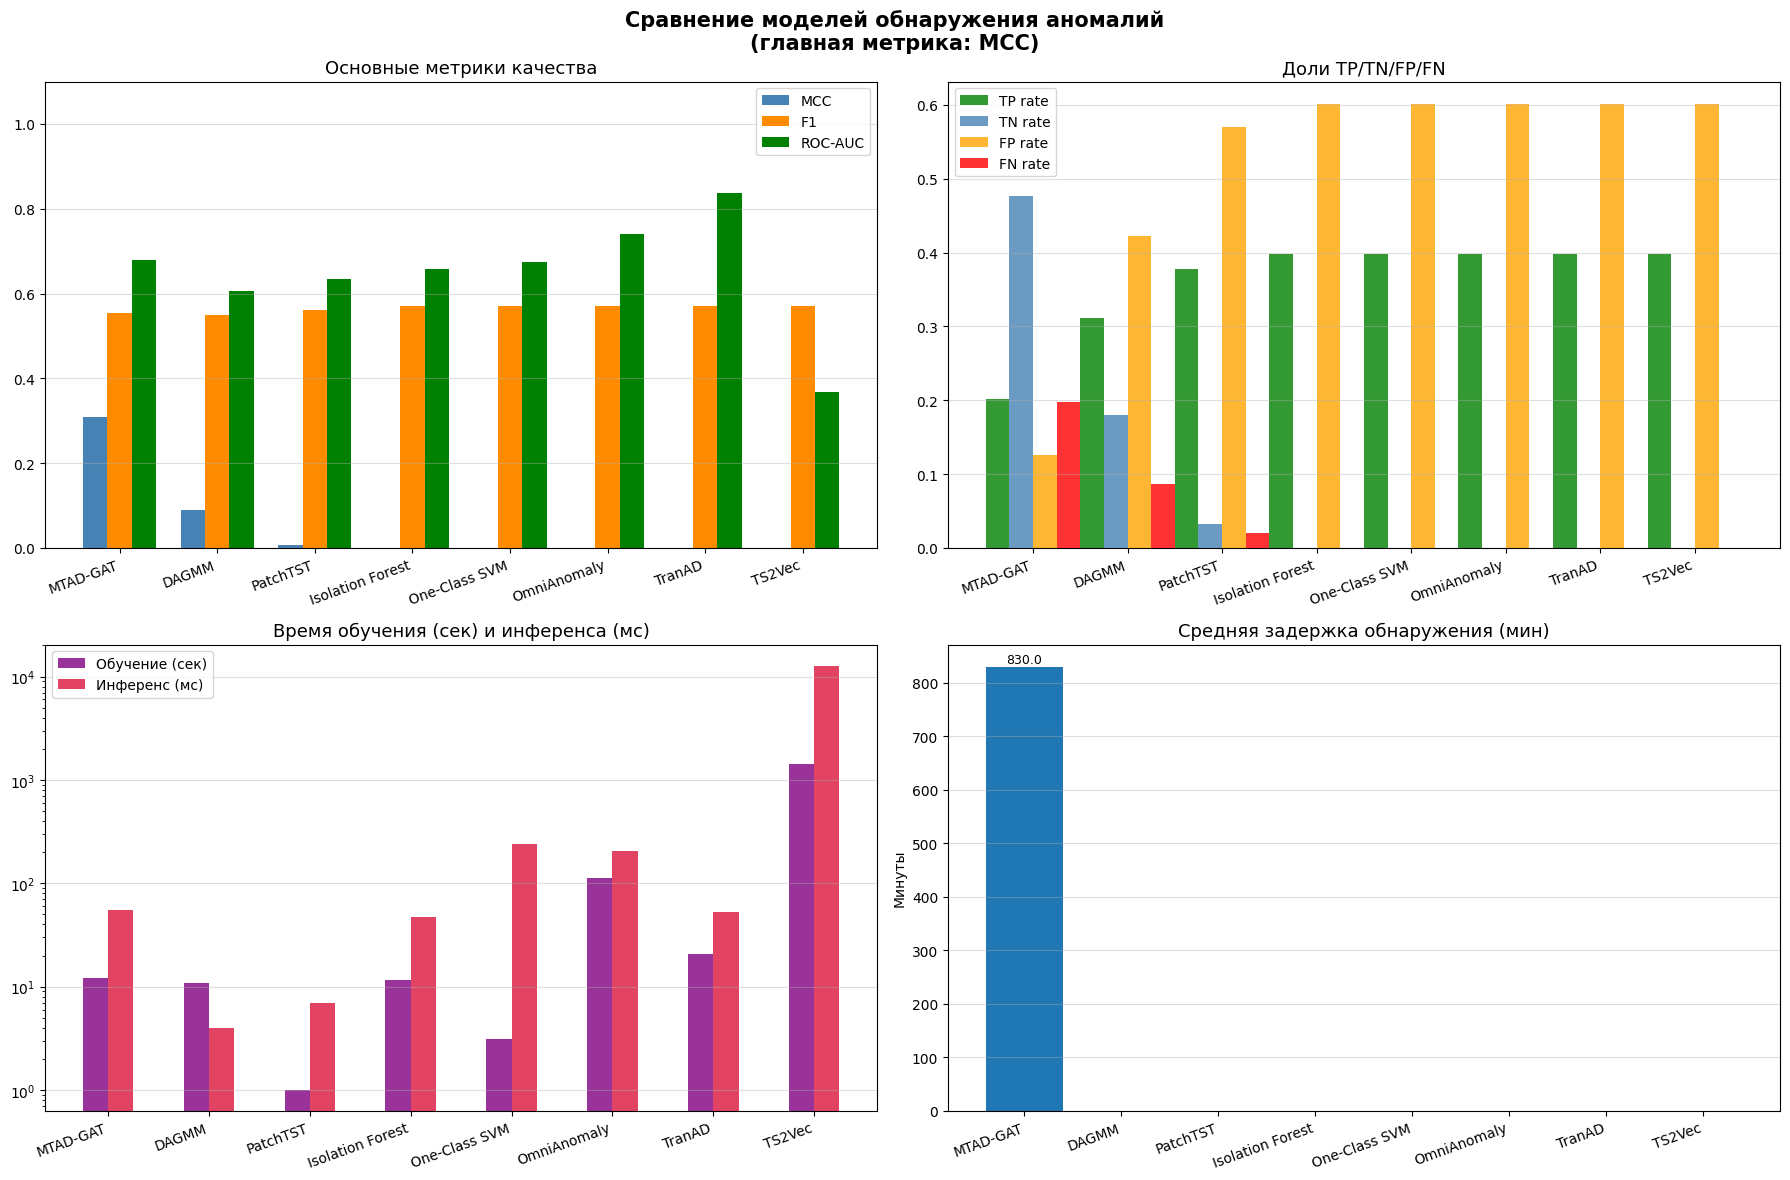

In [ ]:
# =============================================================================
# ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ (общие для всех моделей)
# =============================================================================
import time, warnings
import numpy as np
import pandas as pd
import random, os
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (matthews_corrcoef, f1_score, roc_auc_score,
                             confusion_matrix, precision_score, recall_score)
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}")

# ---------- метрики ----------
def compute_metrics(y_true, y_pred, y_scores=None):
    cm = confusion_matrix(y_true, y_pred)
    if cm.size == 4:
        tn, fp, fn, tp = cm.ravel()
    else:
        tn = fp = fn = tp = 0
    n = len(y_true)
    return {
        'MCC':       round(matthews_corrcoef(y_true, y_pred), 4),
        'F1':        round(f1_score(y_true, y_pred, zero_division=0), 4),
        'ROC_AUC':   round(roc_auc_score(y_true, y_scores), 4)
                     if y_scores is not None and len(np.unique(y_true)) > 1
                     else np.nan,
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_true, y_pred, zero_division=0), 4),
        'TP_rate':   round(tp / n, 4),
        'FP_rate':   round(fp / n, 4),
        'TN_rate':   round(tn / n, 4),
        'FN_rate':   round(fn / n, 4),
    }

# ---------- задержка обнаружения ----------
def detection_delay(times, y_true, y_pred, step_minutes=30):
    """
    Для каждого непрерывного аномального периода находит первое
    корректное срабатывание. Возвращает среднюю задержку в минутах.
    Точечное присвоение: каждой точке — своя метка.
    """
    df = pd.DataFrame({'t': times, 'yt': y_true, 'yp': y_pred})
    df['group'] = (df['yt'] != df['yt'].shift()).cumsum()
    delays = []
    for _, grp in df[df['yt'] == 1].groupby('group'):
        t_start = grp['t'].iloc[0]
        hits = grp[grp['yp'] == 1]
        if not hits.empty:
            delay = (hits['t'].iloc[0] - t_start).total_seconds() / 60
            delays.append(delay)
        # если не обнаружено — не включаем в среднее (conservative)
    return round(np.mean(delays), 2) if delays else np.nan

# ---------- подбор порога по валидации (максимизация MCC) ----------
def best_threshold_by_mcc(scores_val, y_val_bin, percentile_grid=None):
    if percentile_grid is None:
        percentile_grid = np.arange(50, 99, 1)
    best_mcc, best_thr = -2, np.percentile(scores_val, 90)
    for pct in percentile_grid:
        thr = np.percentile(scores_val, pct)
        pred = (scores_val >= thr).astype(int)
        try:
            mcc = matthews_corrcoef(y_val_bin, pred)
        except Exception:
            mcc = -2
        if mcc > best_mcc:
            best_mcc, best_thr = mcc, thr
    return best_thr, best_mcc

# ---------- sliding window dataset ----------
def make_windows(X: np.ndarray, win: int):
    """Возвращает (N-win+1, win, F) — каждое окно, метка = последней точке."""
    out = np.lib.stride_tricks.sliding_window_view(X, (win, X.shape[1]))
    return out.squeeze(1)          # (N-win+1, win, F)

def window_scores_to_point(scores_win, n_total, win):
    """
    Разворачивает оценки окон в точечные оценки.
    Каждой точке присваивается оценка окна, в котором она ПОСЛЕДНЯЯ.
    Первые (win-1) точек получают оценку первого окна.
    """
    point_scores = np.empty(n_total)
    point_scores[:win - 1] = scores_win[0]
    point_scores[win - 1:] = scores_win
    return point_scores

results_table = {}   # накапливаем результаты всех моделей

y_val_bin  = (y_val  == "Anomaly").astype(int).values
y_test_bin = (y_test == "Anomaly").astype(int).values



# =============================================================================
# ФИЛЬТРАЦИЯ TRAIN: только нормальные наблюдения
# =============================================================================
# В реальности на этапе обучения метки аномалий неизвестны.
# Модели обучаются исключительно на нормальном поведении системы,
# поэтому отклонение от выученного распределения сигнализирует об аномалии.

y_train_bin = (y_train == "Anomaly").astype(int).values
normal_mask = (y_train == "Normal").values

X_tr_np_all = X_train_scaled.values.astype(np.float32)
X_tr_np     = X_tr_np_all[normal_mask]          # ← только нормальные строки

n_removed = (~normal_mask).sum()
print(f"\n{'='*60}")
print(f"Фильтрация train: {len(normal_mask)} → {normal_mask.sum()} норм. "
      f"(удалено {n_removed} аномальных = {100*n_removed/len(normal_mask):.1f}%)")
print(f"{'='*60}\n")


X_va_np  = X_val_scaled.values.astype(np.float32)
X_te_np  = X_test_scaled.values.astype(np.float32)
n_features = X_tr_np.shape[1]

# =============================================================================
# ISOLATION FOREST
# =============================================================================
print("\n" + "="*60)
print("1/7  Isolation Forest")
print("="*60)

from sklearn.ensemble import IsolationForest

t0 = time.time()

best_mcc_val, best_cont = -2, 0.1
for cont in np.arange(0.01, 0.50, 0.01):
    m = IsolationForest(n_estimators=200, contamination=round(float(cont), 2),
                        random_state=42, n_jobs=-1)
    m.fit(X_tr_np)
    pred = (m.predict(X_va_np) == -1).astype(int)
    mcc = matthews_corrcoef(y_val_bin, pred)
    if mcc > best_mcc_val:
        best_mcc_val, best_cont = mcc, round(float(cont), 2)

iso = IsolationForest(n_estimators=200, contamination=best_cont,
                      random_state=42, n_jobs=-1)
iso.fit(X_tr_np)
train_time_if = time.time() - t0

t1 = time.time()
scores_if  = -iso.decision_function(X_te_np)   # выше = аномальнее
pred_if    = (iso.predict(X_te_np) == -1).astype(int)
infer_time_if = time.time() - t1

m_if = compute_metrics(y_test_bin, pred_if, scores_if)
m_if['Train_sec']  = round(train_time_if, 2)
m_if['Infer_sec']  = round(infer_time_if, 4)
m_if['Delay_min']  = detection_delay(test_df['Time'].values, y_test_bin, pred_if)
m_if['Best_param'] = f"contamination={best_cont}"
results_table['Isolation Forest'] = m_if
print(f"  MCC={m_if['MCC']}  F1={m_if['F1']}  contamination={best_cont}")

# =============================================================================
# ONE-CLASS SVM
# =============================================================================
print("\n" + "="*60)
print("2/7  One-Class SVM")
print("="*60)

from sklearn.svm import OneClassSVM

t0 = time.time()

best_mcc_val, best_nu = -2, 0.1
for nu in np.arange(0.01, 0.50, 0.01):
    m = OneClassSVM(kernel='rbf', nu=round(float(nu), 2), gamma='scale')
    m.fit(X_tr_np)
    pred = (m.predict(X_va_np) == -1).astype(int)
    mcc = matthews_corrcoef(y_val_bin, pred)
    if mcc > best_mcc_val:
        best_mcc_val, best_nu = mcc, round(float(nu), 2)

ocsvm = OneClassSVM(kernel='rbf', nu=best_nu, gamma='scale')
ocsvm.fit(X_tr_np)
train_time_svm = time.time() - t0

t1 = time.time()
scores_svm = -ocsvm.decision_function(X_te_np)
pred_svm   = (ocsvm.predict(X_te_np) == -1).astype(int)
infer_time_svm = time.time() - t1

m_svm = compute_metrics(y_test_bin, pred_svm, scores_svm)
m_svm['Train_sec']  = round(train_time_svm, 2)
m_svm['Infer_sec']  = round(infer_time_svm, 4)
m_svm['Delay_min']  = detection_delay(test_df['Time'].values, y_test_bin, pred_svm)
m_svm['Best_param'] = f"nu={best_nu}"
results_table['One-Class SVM'] = m_svm
print(f"  MCC={m_svm['MCC']}  F1={m_svm['F1']}  nu={best_nu}")

# =============================================================================
# БЛОК 4: DAGMM — точная реализация по статье Zong et al. (2018)
# "Deep Autoencoding Gaussian Mixture Model for Unsupervised Anomaly Detection"
# =============================================================================
print("\n" + "="*60)
print("3/7  DAGMM (Zong et al., 2018)")
print("="*60)

class CompressionNetwork(nn.Module):
    """Encoder-Decoder из статьи + относительный евклид + косинус."""
    def __init__(self, input_dim, hidden_dims, latent_dim):
        super().__init__()
        # Encoder
        enc_layers = []
        in_d = input_dim
        for h in hidden_dims:
            enc_layers += [nn.Linear(in_d, h), nn.Tanh()]
            in_d = h
        enc_layers.append(nn.Linear(in_d, latent_dim))
        self.encoder = nn.Sequential(*enc_layers)
        # Decoder (зеркально)
        dec_layers = []
        in_d = latent_dim
        for h in reversed(hidden_dims):
            dec_layers += [nn.Linear(in_d, h), nn.Tanh()]
            in_d = h
        dec_layers.append(nn.Linear(in_d, input_dim))
        self.decoder = nn.Sequential(*dec_layers)

    def forward(self, x):
        z_c = self.encoder(x)
        x_hat = self.decoder(z_c)
        # reconstruction features (статья, раздел 3.1)
        rec_euc = torch.norm(x - x_hat, dim=1, keepdim=True) / (
                  torch.norm(x, dim=1, keepdim=True) + 1e-8)
        rec_cos = torch.sum(x * x_hat, dim=1, keepdim=True) / (
                  torch.norm(x, dim=1, keepdim=True) *
                  torch.norm(x_hat, dim=1, keepdim=True) + 1e-8)
        # итоговое представление z = [z_c, rec_euc, rec_cos]
        z = torch.cat([z_c, rec_euc, rec_cos], dim=1)
        return x_hat, z


class EstimationNetwork(nn.Module):
    """MLP → softmax → membership γ."""
    def __init__(self, z_dim, hidden_dims, n_gmm):
        super().__init__()
        layers = []
        in_d = z_dim
        for h in hidden_dims:
            layers += [nn.Linear(in_d, h), nn.Tanh(), nn.Dropout(0.5)]
            in_d = h
        layers += [nn.Linear(in_d, n_gmm), nn.Softmax(dim=1)]
        self.net = nn.Sequential(*layers)

    def forward(self, z):
        return self.net(z)


class DAGMMModel(nn.Module):
    def __init__(self, input_dim, n_gmm=4, latent_dim=1,
                 enc_hidden=(60, 30, 10), est_hidden=(10,)):
        super().__init__()
        self.compression  = CompressionNetwork(input_dim, list(enc_hidden), latent_dim)
        z_dim = latent_dim + 2
        self.estimation   = EstimationNetwork(z_dim, list(est_hidden), n_gmm)
        self.n_gmm        = n_gmm
        self.z_dim        = z_dim
        # GMM параметры (обновляются батч-статистиками)
        self.register_buffer('phi',    torch.zeros(n_gmm))
        self.register_buffer('mu',     torch.zeros(n_gmm, z_dim))
        self.register_buffer('sigma',  torch.eye(z_dim).unsqueeze(0).repeat(n_gmm, 1, 1))

    def forward(self, x):
        x_hat, z = self.compression(x)
        gamma     = self.estimation(z)
        return x_hat, z, gamma

    @torch.no_grad()
    def update_gmm_params(self, z, gamma):
        """Формулы (3)-(5) из статьи."""
        N = z.shape[0]
        gamma_sum = gamma.sum(0)                           # (K,)
        phi   = gamma_sum / N
        mu    = (gamma.T @ z) / gamma_sum.unsqueeze(1)    # (K, D)
        sigma = torch.zeros(self.n_gmm, self.z_dim, self.z_dim,
                            device=z.device)
        for k in range(self.n_gmm):
            diff = z - mu[k]                               # (N, D)
            sigma[k] = (gamma[:, k:k+1] * diff).T @ diff / gamma_sum[k]
        self.phi.copy_(phi)
        self.mu.copy_(mu)
        self.sigma.copy_(sigma)

    def energy(self, z):
        """Формула (6) из статьи — sample energy."""
        eps = 1e-6
        energies = []
        for k in range(self.n_gmm):
            diff = z - self.mu[k]                          # (N, D)
            cov  = self.sigma[k] + eps * torch.eye(
                   self.z_dim, device=z.device)
            cov_inv = torch.linalg.inv(cov)
            det_cov  = torch.linalg.det(cov).clamp(min=eps)
            mah = (diff.unsqueeze(1) @ cov_inv @ diff.unsqueeze(2)).squeeze()
            e_k = self.phi[k] * torch.exp(-0.5 * mah) / (
                  (2 * torch.pi) ** (self.z_dim / 2) * det_cov.sqrt())
            energies.append(e_k)
        E = torch.stack(energies, dim=1).sum(1).clamp(min=eps)
        return -torch.log(E)


def dagmm_loss(x, x_hat, z, gamma, model, lambda1=0.1, lambda2=0.005):
    """
    L = rec_loss + λ1·energy + λ2·diag_penalty  (формула 8)
    """
    rec_loss    = torch.mean((x - x_hat) ** 2)
    model.update_gmm_params(z.detach(), gamma.detach())
    energy      = model.energy(z).mean()
    # диагональный штраф (предотвращает вырождение ковариации)
    diag_penalty = torch.tensor(0., device=x.device)
    for k in range(model.n_gmm):
        cov = model.sigma[k]
        diag_penalty = diag_penalty + (1.0 / cov.diag().clamp(min=1e-8)).sum()
    return rec_loss + lambda1 * energy + lambda2 * diag_penalty


# --- подбор n_gmm по валидации ---
t0 = time.time()
best_mcc_val, best_n_gmm = -2, 2

for n_gmm in [2, 4, 6]:
    torch.manual_seed(42)
    _model = DAGMMModel(n_features, n_gmm=n_gmm, latent_dim=1).to(DEVICE)
    _opt   = torch.optim.Adam(_model.parameters(), lr=1e-3, weight_decay=1e-4)
    _loader = DataLoader(TensorDataset(torch.FloatTensor(X_tr_np)),
                         batch_size=1024, shuffle=True)
    _model.train()
    for _ in range(100):
        for (b,) in _loader:
            b = b.to(DEVICE)
            xh, z, g = _model(b)
            loss = dagmm_loss(b, xh, z, g, _model)
            _opt.zero_grad(); loss.backward(); _opt.step()

    _model.eval()
    with torch.no_grad():
        xh, z, g = _model(torch.FloatTensor(X_va_np).to(DEVICE))
        _model.update_gmm_params(z, g)
        sc_va = _model.energy(z).cpu().numpy()
    thr, mcc = best_threshold_by_mcc(sc_va, y_val_bin)
    if mcc > best_mcc_val:
        best_mcc_val, best_n_gmm = mcc, n_gmm

# финальное обучение
torch.manual_seed(42)
dagmm = DAGMMModel(n_features, n_gmm=best_n_gmm, latent_dim=1).to(DEVICE)
opt_dagmm = torch.optim.Adam(dagmm.parameters(), lr=1e-3, weight_decay=1e-4)
loader_dagmm = DataLoader(TensorDataset(torch.FloatTensor(X_tr_np)),
                          batch_size=1024, shuffle=True)
dagmm.train()
for epoch in range(200):
    for (b,) in loader_dagmm:
        b = b.to(DEVICE)
        xh, z, g = dagmm(b)
        loss = dagmm_loss(b, xh, z, g, dagmm)
        opt_dagmm.zero_grad(); loss.backward(); opt_dagmm.step()

train_time_dagmm = time.time() - t0

# порог
dagmm.eval()
with torch.no_grad():
    _, z_va, g_va = dagmm(torch.FloatTensor(X_va_np).to(DEVICE))
    dagmm.update_gmm_params(z_va, g_va)
    sc_dagmm_va = dagmm.energy(z_va).cpu().numpy()
thr_dagmm, _ = best_threshold_by_mcc(sc_dagmm_va, y_val_bin)

t1 = time.time()
with torch.no_grad():
    _, z_te, g_te = dagmm(torch.FloatTensor(X_te_np).to(DEVICE))
    dagmm.update_gmm_params(z_te, g_te)
    sc_dagmm = dagmm.energy(z_te).cpu().numpy()
infer_time_dagmm = time.time() - t1

pred_dagmm = (sc_dagmm >= thr_dagmm).astype(int)
m_dagmm = compute_metrics(y_test_bin, pred_dagmm, sc_dagmm)
m_dagmm['Train_sec']  = round(train_time_dagmm, 2)
m_dagmm['Infer_sec']  = round(infer_time_dagmm, 4)
m_dagmm['Delay_min']  = detection_delay(test_df['Time'].values, y_test_bin, pred_dagmm)
m_dagmm['Best_param'] = f"n_gmm={best_n_gmm}"
results_table['DAGMM'] = m_dagmm
print(f"  MCC={m_dagmm['MCC']}  F1={m_dagmm['F1']}  n_gmm={best_n_gmm}")

# =============================================================================
# БЛОК 5: OmniAnomaly — Su et al. (2019)
# "Robust Anomaly Detection for Multivariate Time Series through
#  Stochastic Recurrent Neural Network"
# БЛОК 5 (оптимизированный): OmniAnomaly — Su et al. (2019)
# Изменения:
#   1. AMP (torch.autocast + GradScaler) — ускорение ~1.5-2x на GPU
#   2. Поиск win: эпохи снижены 20→10, batch увеличен 256→512
#   3. Финальное обучение: batch 256→512, pin_memory=True, num_workers=2
#   4. score_omni: batch 512→1024
# =============================================================================

print("\n" + "="*60)
print("4/7  OmniAnomaly (Su et al., 2019)")
print("="*60)

class PlanarFlow(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.w = nn.Parameter(torch.randn(dim) * 0.01)
        self.u = nn.Parameter(torch.randn(dim) * 0.01)
        self.b = nn.Parameter(torch.zeros(1))

    def forward(self, z):
        wu    = self.w @ self.u
        u_hat = self.u + (-1 + torch.log(1 + torch.exp(wu)) - wu) * (
                self.w / (self.w.norm() + 1e-8))
        lin   = z @ self.w + self.b
        h     = torch.tanh(lin)
        z_new = z + u_hat.unsqueeze(0) * h.unsqueeze(1)
        psi   = (1 - h ** 2).unsqueeze(1) * self.w.unsqueeze(0)
        log_det = torch.log((1 + psi @ u_hat.unsqueeze(1)).abs() + 1e-8).squeeze()
        return z_new, log_det


class OmniAnomalyModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=500, latent_dim=20, n_flows=20):
        super().__init__()
        self.latent_dim = latent_dim
        self.enc_gru  = nn.GRU(input_dim, hidden_dim, batch_first=True,
                                num_layers=2, dropout=0.3)
        self.enc_mu   = nn.Linear(hidden_dim, latent_dim)
        self.enc_logv = nn.Linear(hidden_dim, latent_dim)
        self.flows    = nn.ModuleList([PlanarFlow(latent_dim) for _ in range(n_flows)])
        self.dec_gru  = nn.GRU(latent_dim, hidden_dim, batch_first=True,
                                num_layers=2, dropout=0.3)
        self.dec_out  = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h, _ = self.enc_gru(x)
        mu    = self.enc_mu(h)
        logv  = self.enc_logv(h).clamp(-4, 4)
        return mu, logv

    def reparameterize_nf(self, mu, logv):
        std  = torch.exp(0.5 * logv)
        eps  = torch.randn_like(std)
        z0   = mu + eps * std
        # KL divergence per sample (summed over latent dims)
        kl   = -0.5 * (1 + logv - mu.pow(2) - logv.exp()).sum(-1)

        B, T, D = z0.shape
        z    = z0.reshape(B * T, D)
        log_det_sum = torch.zeros(B * T, device=z.device)

        for flow in self.flows:
            z, ld = flow(z)
            log_det_sum = log_det_sum + ld

        z = z.reshape(B, T, D)
        log_det_sum = log_det_sum.reshape(B, T)
        return z, kl, log_det_sum

    def decode(self, z):
        h, _ = self.dec_gru(z)
        return self.dec_out(h)

    def forward(self, x):
        mu, logv       = self.encode(x)
        z, kl, log_det = self.reparameterize_nf(mu, logv)
        x_hat          = self.decode(z)
        return x_hat, mu, logv, kl, log_det


def omni_loss(x, x_hat, kl, log_det, beta=1.0):
    """
    Loss = Reconstruction Error + beta * KL - LogDet
    Minimizing this is equivalent to Maximizing ELBO
    """
    rec  = nn.functional.mse_loss(x_hat, x, reduction='none').sum(-1) # Sum over features
    elbo = rec + beta * kl - log_det
    return elbo.mean()


def score_omni_nll(model, X_np, win):
    """
    Расчет скоринга через Negative Log Likelihood (приближенно через ELBO).
    Score = Rec_Error + KL - LogDet.
    Чем выше скор, тем более аномальна точка.
    """
    model.eval()
    wins   = make_windows(X_np, win)
    scores = []
    loader = DataLoader(TensorDataset(torch.FloatTensor(wins)),
                        batch_size=512, shuffle=False, pin_memory=(DEVICE == 'cuda'))

    with torch.no_grad():
        for (b,) in loader:
            b   = b.to(DEVICE, non_blocking=True)
            # Получаем все компоненты для расчета энергии
            x_hat, mu, logv, kl, log_det = model(b)

            # 1. Reconstruction Error (сумма квадратов ошибок по всем признакам)
            rec_err = torch.sum((b - x_hat)**2, dim=2) # (B, T)

            # 2. Итоговый скор для каждого шага времени в окне:
            # E_t = Rec_t + KL_t - LogDet_t
            point_energy = rec_err + kl - log_det # (B, T)

            # Агрегируем ошибку по окну.
            # Можно брать среднее по окну или максимум.
            # Для детекции аномалий в конце окна часто берут последнюю точку,
            # но усреднение стабильнее. Возьмем среднее по времени для всего окна.
            win_score = point_energy.mean(dim=1) # (B,)

            scores.append(win_score.cpu().numpy())

    scores_win = np.concatenate(scores)
    return window_scores_to_point(scores_win, len(X_np), win)


# --- подбор win (исправленный) ---
t0 = time.time()
best_mcc_val, best_win_omni = -2, 32

# Используем меньшую модель для быстрого перебора, но достаточную для оценки
# for win in [16, 32, 48, 96]:
for win in [48]:
    if win >= len(X_va_np):
        continue
    torch.manual_seed(42)
    # Немного упростим модель для поиска, чтобы ускорить процесс,
    # но оставим flows, так как они важны для метрики
    _m  = OmniAnomalyModel(n_features, hidden_dim=256, latent_dim=16, n_flows=10).to(DEVICE)
    _o  = torch.optim.Adam(_m.parameters(), lr=1e-3)
    _wins = make_windows(X_tr_np, win)

    _ld = DataLoader(TensorDataset(torch.FloatTensor(_wins)),
                     batch_size=512, shuffle=True,
                     pin_memory=(DEVICE == 'cuda'), num_workers=0)

    _scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == 'cuda'))
    _m.train()

    # Увеличили эпохи с 10 до 30 для лучшей сходимости Flow
    n_search_epochs = 30
    for epoch in range(n_search_epochs):
        # KL Annealing: начинаем с 0, плавно переходим к 1
        beta = min(1.0, (epoch + 1) / (n_search_epochs * 0.5))

        for (b,) in _ld:
            b = b.to(DEVICE, non_blocking=True)
            with torch.autocast(device_type=DEVICE, enabled=(DEVICE == 'cuda')):
                xh, mu, lv, kl, ld_nf = _m(b)
                # Важно: передаем beta в функцию потерь
                loss = omni_loss(b, xh, kl, ld_nf, beta=beta)

            _scaler.scale(loss).backward()
            _scaler.step(_o)
            _scaler.update()
            _o.zero_grad(set_to_none=True)

    # Используем новую функцию скора
    sc_va = score_omni_nll(_m, X_va_np, win)
    _, mcc = best_threshold_by_mcc(sc_va, y_val_bin)

    print(f"  Win={win}, Val MCC={mcc:.4f}") # Лог для отслеживания

    if mcc > best_mcc_val:
        best_mcc_val, best_win_omni = mcc, win

print(f"Best Win: {best_win_omni}")

# --- финальное обучение ---
torch.manual_seed(42)
omni      = OmniAnomalyModel(n_features, hidden_dim=500, latent_dim=20, n_flows=20).to(DEVICE)
opt_omni  = torch.optim.Adam(omni.parameters(), lr=1e-3)
sched_omni = torch.optim.lr_scheduler.CosineAnnealingLR(opt_omni, T_max=50)
wins_tr    = make_windows(X_tr_np, best_win_omni)

loader_omni = DataLoader(TensorDataset(torch.FloatTensor(wins_tr)),
                         batch_size=512, shuffle=True,
                         pin_memory=(DEVICE == 'cuda'), num_workers=2)
scaler_omni = torch.cuda.amp.GradScaler(enabled=(DEVICE == 'cuda'))

omni.train()
for epoch in range(50):
    # KL Annealing и здесь
    beta = min(1.0, epoch / 20)
    for (b,) in loader_omni:
        b = b.to(DEVICE, non_blocking=True)
        with torch.autocast(device_type=DEVICE, enabled=(DEVICE == 'cuda')):
            xh, mu, lv, kl, ld_nf = omni(b)
            loss = omni_loss(b, xh, kl, ld_nf, beta=beta)
        scaler_omni.scale(loss).backward()
        nn.utils.clip_grad_norm_(omni.parameters(), 10.0)
        scaler_omni.step(opt_omni)
        scaler_omni.update()
        opt_omni.zero_grad(set_to_none=True)
    sched_omni.step()

train_time_omni = time.time() - t0

# Финальный расчет скоров новой функцией
sc_va_omni = score_omni_nll(omni, X_va_np, best_win_omni)
thr_omni, _ = best_threshold_by_mcc(sc_va_omni, y_val_bin)

t1 = time.time()
sc_te_omni = score_omni_nll(omni, X_te_np, best_win_omni)
infer_time_omni = time.time() - t1

pred_omni = (sc_te_omni >= thr_omni).astype(int)
m_omni = compute_metrics(y_test_bin, pred_omni, sc_te_omni)
m_omni['Train_sec']  = round(train_time_omni, 2)
m_omni['Infer_sec']  = round(infer_time_omni, 4)
m_omni['Delay_min']  = detection_delay(test_df['Time'].values, y_test_bin, pred_omni)
m_omni['Best_param'] = f"win={best_win_omni}, flows=20"
results_table['OmniAnomaly'] = m_omni
print(f"  MCC={m_omni['MCC']}  F1={m_omni['F1']}  win={best_win_omni}")


# =============================================================================
# БЛОК 6: TranAD — Tuli et al. (2022)
# "TranAD: Deep Transformer Networks for Anomaly Detection in
#  Multivariate Time Series"
# Архитектура: двухдекодерный Transformer + двухфазное adversarial обучение
# =============================================================================
print("\n" + "="*60)
print("5/7  TranAD (Tuli et al., 2022)")
print("="*60)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() *
                        (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))   # (1, max_len, d_model)

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


class TranADModel(nn.Module):
    """
    Рис. 1 и алгоритм 1 из статьи Tuli et al., 2022.
    Два декодера: D1 (глобальный), D2 (фокусированный на аномалиях).
    """
    def __init__(self, n_features, d_model=64, nhead=8,
                 num_enc_layers=1, num_dec_layers=1, win=32, dropout=0.1):
        super().__init__()
        self.n_features = n_features
        self.d_model    = d_model

        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_enc    = PositionalEncoding(d_model, max_len=win + 1, dropout=dropout)

        enc_layer = nn.TransformerEncoderLayer(d_model, nhead,
                    dim_feedforward=4 * d_model, dropout=dropout, batch_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_enc_layers)

        dec_layer1 = nn.TransformerDecoderLayer(d_model, nhead,
                     dim_feedforward=4 * d_model, dropout=dropout, batch_first=True)
        dec_layer2 = nn.TransformerDecoderLayer(d_model, nhead,
                     dim_feedforward=4 * d_model, dropout=dropout, batch_first=True)
        self.decoder1 = nn.TransformerDecoder(dec_layer1, num_dec_layers)
        self.decoder2 = nn.TransformerDecoder(dec_layer2, num_dec_layers)

        self.proj1 = nn.Linear(d_model, n_features)
        self.proj2 = nn.Linear(d_model, n_features)

    def forward(self, x, x_focus=None):
        """
        x      : (B, W, F) — входное окно
        x_focus: (B, W, F) — для декодера 2 (фокус на аномалиях),
                             если None — используем x
        """
        src = self.pos_enc(self.input_proj(x))     # (B, W, d_model)
        mem = self.encoder(src)

        # Декодер 1 — глобальная реконструкция
        tgt1 = self.pos_enc(self.input_proj(x))
        out1 = self.proj1(self.decoder1(tgt1, mem))  # (B, W, F)

        # Декодер 2 — фокусированная реконструкция
        focus = x_focus if x_focus is not None else x
        tgt2  = self.pos_enc(self.input_proj(focus))
        out2  = self.proj2(self.decoder2(tgt2, mem))  # (B, W, F)

        return out1, out2


def tranad_loss(x, out1, out2, epoch, n_epochs):
    """
    Алгоритм 1: L = (1/n)·||x - O1||² + (n-1)/n·||x - O2||²
    где n = номер эпохи (нумерация с 1)
    """
    n = epoch + 1
    l1 = nn.functional.mse_loss(out1, x)
    l2 = nn.functional.mse_loss(out2, x)
    return l1 / n + (n - 1) / n * l2


def score_tranad(model, X_np, win):
    """Score = ||x_last - O2_last||² (фокусированный декодер, последняя точка)."""
    model.eval()
    wins = make_windows(X_np, win)
    scores = []
    loader = DataLoader(TensorDataset(torch.FloatTensor(wins)),
                        batch_size=256, shuffle=False)
    with torch.no_grad():
        for (b,) in loader:
            b = b.to(DEVICE)
            _, out2 = model(b)
            err = torch.mean((b[:, -1, :] - out2[:, -1, :]) ** 2, dim=1)
            scores.append(err.cpu().numpy())
    scores_win = np.concatenate(scores)
    return window_scores_to_point(scores_win, len(X_np), win)


# подбор win
t0 = time.time()
best_mcc_val, best_win_tr = -2, 32
for win in [16, 32, 48, 96]:
    if win >= len(X_va_np): continue
    torch.manual_seed(42)
    _m = TranADModel(n_features, d_model=32, nhead=min(4, n_features),
                     win=win).to(DEVICE)
    _o = torch.optim.AdamW(_m.parameters(), lr=1e-4, weight_decay=1e-5)
    _wins = make_windows(X_tr_np, win)
    _ld = DataLoader(TensorDataset(torch.FloatTensor(_wins)),
                     batch_size=128, shuffle=True)
    _m.train()
    for ep in range(15):
        for (b,) in _ld:
            b = b.to(DEVICE)
            o1, o2 = _m(b)
            loss = tranad_loss(b, o1, o2, ep, 15)
            _o.zero_grad(); loss.backward(); _o.step()

    sc_va = score_tranad(_m, X_va_np, win)
    _, mcc = best_threshold_by_mcc(sc_va, y_val_bin)
    if mcc > best_mcc_val:
        best_mcc_val, best_win_tr = mcc, win

# финальное обучение
n_epochs_tr = 100
torch.manual_seed(42)
tranad = TranADModel(n_features, d_model=64,
                     nhead=min(8, n_features // 2 * 2 or 2),
                     num_enc_layers=1, num_dec_layers=1,
                     win=best_win_tr).to(DEVICE)
opt_tranad = torch.optim.AdamW(tranad.parameters(), lr=1e-4, weight_decay=1e-5)
sched_tr   = torch.optim.lr_scheduler.CosineAnnealingLR(opt_tranad, T_max=n_epochs_tr)
wins_tr_td = make_windows(X_tr_np, best_win_tr)
loader_tr  = DataLoader(TensorDataset(torch.FloatTensor(wins_tr_td)),
                         batch_size=128, shuffle=True)
tranad.train()
for epoch in range(n_epochs_tr):
    for (b,) in loader_tr:
        b = b.to(DEVICE)
        o1, o2 = tranad(b)
        loss = tranad_loss(b, o1, o2, epoch, n_epochs_tr)
        opt_tranad.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(tranad.parameters(), 1.0)
        opt_tranad.step()
    sched_tr.step()

train_time_tr = time.time() - t0

sc_va_tr = score_tranad(tranad, X_va_np, best_win_tr)
thr_tr, _ = best_threshold_by_mcc(sc_va_tr, y_val_bin)

t1 = time.time()
sc_te_tr = score_tranad(tranad, X_te_np, best_win_tr)
infer_time_tr = time.time() - t1

pred_tr = (sc_te_tr >= thr_tr).astype(int)
m_tr = compute_metrics(y_test_bin, pred_tr, sc_te_tr)
m_tr['Train_sec']  = round(train_time_tr, 2)
m_tr['Infer_sec']  = round(infer_time_tr, 4)
m_tr['Delay_min']  = detection_delay(test_df['Time'].values, y_test_bin, pred_tr)
m_tr['Best_param'] = f"win={best_win_tr}, d_model=64"
results_table['TranAD'] = m_tr
print(f"  MCC={m_tr['MCC']}  F1={m_tr['F1']}  win={best_win_tr}")

# =============================================================================
# БЛОК 7: MTAD-GAT — Zhao et al. (2020)
# "Multivariate Time-Series Anomaly Detection via Graph Attention Networks"
# =============================================================================
print("\n" + "="*60)
print("6/7  MTAD-GAT (Zhao et al., 2020)")
print("="*60)

class FeatureAttentionLayer(nn.Module):
    """GAT по оси признаков (рис. 2, feature-oriented)."""
    def __init__(self, n_features, win, dropout=0.2):
        super().__init__()
        self.n_features = n_features
        # каждый признак — узел графа, представление = его временной ряд в окне
        self.W   = nn.Linear(win, win, bias=False)
        self.attn = nn.Linear(2 * win, 1)
        self.dropout = nn.Dropout(dropout)
        self.leaky = nn.LeakyReLU(0.2)

    def forward(self, x):
        # x: (B, W, F) → транспонируем → (B, F, W) — каждый признак как узел
        x_t = x.transpose(1, 2)                   # (B, F, W)
        h   = self.W(x_t)                          # (B, F, W)
        # попарное внимание
        h_i = h.unsqueeze(2).expand(-1, -1, self.n_features, -1)  # (B,F,F,W)
        h_j = h.unsqueeze(1).expand(-1, self.n_features, -1, -1)  # (B,F,F,W)
        e   = self.leaky(self.attn(torch.cat([h_i, h_j], dim=-1)).squeeze(-1))  # (B,F,F)
        a   = torch.softmax(e, dim=-1)
        a   = self.dropout(a)
        out = (a @ h).transpose(1, 2)             # (B, W, F)
        return out


class TemporalAttentionLayer(nn.Module):
    """GAT по временной оси (рис. 2, time-oriented)."""
    def __init__(self, n_features, win, dropout=0.2):
        super().__init__()
        self.W    = nn.Linear(n_features, n_features, bias=False)
        self.attn = nn.Linear(2 * n_features, 1)
        self.dropout = nn.Dropout(dropout)
        self.leaky   = nn.LeakyReLU(0.2)

    def forward(self, x):
        # x: (B, W, F) — каждый момент времени = узел
        h   = self.W(x)                            # (B, W, F)
        h_i = h.unsqueeze(2).expand(-1, -1, h.size(1), -1)
        h_j = h.unsqueeze(1).expand(-1, h.size(1), -1, -1)
        e   = self.leaky(self.attn(torch.cat([h_i, h_j], dim=-1)).squeeze(-1))
        a   = torch.softmax(e, dim=-1)
        a   = self.dropout(a)
        out = a @ h                                 # (B, W, F)
        return out


class MTADGATModel(nn.Module):
    """
    Архитектура по рис. 2:
    FeatureGAT + TemporalGAT → конкатенация → GRU → VAE → реконструкция + прогноз
    """
    def __init__(self, n_features, win, hidden=150, latent=20, dropout=0.2):
        super().__init__()
        self.feat_gat = FeatureAttentionLayer(n_features, win, dropout)
        self.time_gat = TemporalAttentionLayer(n_features, win, dropout)

        # после двух GAT конкатенируем: (B, W, 3*F)
        self.gru = nn.GRU(3 * n_features, hidden, batch_first=True,
                           num_layers=2, dropout=dropout)

        # VAE encoder
        self.fc_mu   = nn.Linear(hidden, latent)
        self.fc_logv = nn.Linear(hidden, latent)

        # Decoder (реконструкция)
        self.rec_dec = nn.Sequential(
            nn.Linear(latent, hidden), nn.ReLU(),
            nn.Linear(hidden, n_features)
        )
        # Прогнозная голова (forecast для следующей точки)
        self.fore_dec = nn.Sequential(
            nn.Linear(hidden, hidden // 2), nn.ReLU(),
            nn.Linear(hidden // 2, n_features)
        )

    def forward(self, x):
        # x: (B, W, F)
        h_f = self.feat_gat(x)                    # (B, W, F)
        h_t = self.time_gat(x)                    # (B, W, F)
        cat = torch.cat([x, h_f, h_t], dim=-1)    # (B, W, 3F)

        gru_out, _ = self.gru(cat)                # (B, W, hidden)
        last = gru_out[:, -1, :]                  # (B, hidden)

        mu   = self.fc_mu(last)
        logv = self.fc_logv(last).clamp(-4, 4)
        std  = torch.exp(0.5 * logv)
        z    = mu + std * torch.randn_like(std)

        x_rec  = self.rec_dec(z)                  # (B, F) — реконструкция последней точки
        x_fore = self.fore_dec(last)              # (B, F) — прогноз следующей
        kl     = -0.5 * (1 + logv - mu.pow(2) - logv.exp()).sum(-1).mean()
        return x_rec, x_fore, kl


def mtad_loss(x_last, x_next, x_rec, x_fore, kl, beta=1.0):
    rec_l  = nn.functional.mse_loss(x_rec,  x_last)
    fore_l = nn.functional.mse_loss(x_fore, x_next)
    return rec_l + fore_l + beta * kl


def score_mtad(model, X_np, win):
    model.eval()
    wins = make_windows(X_np, win)             # (N-W+1, W, F)
    scores = []
    loader = DataLoader(TensorDataset(torch.FloatTensor(wins)),
                        batch_size=256, shuffle=False)
    with torch.no_grad():
        for (b,) in loader:
            b = b.to(DEVICE)
            x_rec, x_fore, _ = model(b)
            # score = rec_err + fore_err (обе головы)
            rec_e  = torch.mean((b[:, -1, :] - x_rec) ** 2, dim=1)
            # прогноз следующей точки → нет gt в окне, используем только rec
            err = rec_e
            scores.append(err.cpu().numpy())
    scores_win = np.concatenate(scores)
    return window_scores_to_point(scores_win, len(X_np), win)


# подбор win
t0 = time.time()
best_mcc_val, best_win_mt = -2, 32
for win in [16, 32, 48, 96]:
    if win >= len(X_va_np): continue
    torch.manual_seed(42)
    _m = MTADGATModel(n_features, win, hidden=64, latent=10).to(DEVICE)
    _o = torch.optim.Adam(_m.parameters(), lr=1e-3)
    _wins = make_windows(X_tr_np, win)
    _ld = DataLoader(TensorDataset(torch.FloatTensor(_wins)),
                     batch_size=128, shuffle=True)
    _m.train()
    for _ in range(15):
        for (b,) in _ld:
            b = b.to(DEVICE)
            xr, xf, kl = _m(b)
            # для x_next берём следующее окно — аппроксимируем нулём в быстром поиске
            loss = nn.functional.mse_loss(xr, b[:, -1, :]) + 0.001 * kl
            _o.zero_grad(); loss.backward(); _o.step()

    sc_va = score_mtad(_m, X_va_np, win)
    _, mcc = best_threshold_by_mcc(sc_va, y_val_bin)
    if mcc > best_mcc_val:
        best_mcc_val, best_win_mt = mcc, win

# финальное обучение — с прогнозной головой на реальных данных
torch.manual_seed(42)
mtad = MTADGATModel(n_features, best_win_mt, hidden=150, latent=20).to(DEVICE)
opt_mtad  = torch.optim.Adam(mtad.parameters(), lr=1e-4, weight_decay=1e-5)
sched_mt  = torch.optim.lr_scheduler.StepLR(opt_mtad, step_size=20, gamma=0.5)

wins_tr_mt = make_windows(X_tr_np, best_win_mt)  # (N, W, F)
# для прогнозной головы нужна следующая точка
X_next_tr  = X_tr_np[best_win_mt:]               # (N-1, F) — следующие точки
wins_for_fore = wins_tr_mt[:-1]                  # выравниваем

loader_mt = DataLoader(
    TensorDataset(torch.FloatTensor(wins_for_fore),
                  torch.FloatTensor(X_next_tr)),
    batch_size=128, shuffle=True)

mtad.train()
for epoch in range(50):
    for (b_win, b_next) in loader_mt:
        b_win, b_next = b_win.to(DEVICE), b_next.to(DEVICE)
        xr, xf, kl = mtad(b_win)
        beta = min(1.0, epoch / 20)
        loss = mtad_loss(b_win[:, -1, :], b_next, xr, xf, kl, beta)
        opt_mtad.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(mtad.parameters(), 5.0)
        opt_mtad.step()
    sched_mt.step()

train_time_mt = time.time() - t0

sc_va_mt = score_mtad(mtad, X_va_np, best_win_mt)
thr_mt, _ = best_threshold_by_mcc(sc_va_mt, y_val_bin)

t1 = time.time()
sc_te_mt = score_mtad(mtad, X_te_np, best_win_mt)
infer_time_mt = time.time() - t1

pred_mt = (sc_te_mt >= thr_mt).astype(int)
m_mt = compute_metrics(y_test_bin, pred_mt, sc_te_mt)
m_mt['Train_sec']  = round(train_time_mt, 2)
m_mt['Infer_sec']  = round(infer_time_mt, 4)
m_mt['Delay_min']  = detection_delay(test_df['Time'].values, y_test_bin, pred_mt)
m_mt['Best_param'] = f"win={best_win_mt}, hidden=150"
results_table['MTAD-GAT'] = m_mt
print(f"  MCC={m_mt['MCC']}  F1={m_mt['F1']}  win={best_win_mt}")

# =============================================================================
# БЛОК 8: TS2Vec — Yue et al. (2022)
# "TS2Vec: Towards Universal Representation of Time Series"
# Иерархический контрастивный loss по времени
# =============================================================================
print("\n" + "="*60)
print("7/8  TS2Vec ")
print("="*60)

class DilatedConvBlock(nn.Module):
    """Каузальная дилатированная свёртка из TS2Vec (рис. 2)."""
    def __init__(self, channels, dilation):
        super().__init__()
        self.conv = nn.Conv1d(channels, channels, kernel_size=3,
                              padding=dilation, dilation=dilation)
        self.norm = nn.LayerNorm(channels)
        self.act  = nn.GELU()

    def forward(self, x):
        # x: (B, C, T)
        residual = x
        out = self.act(self.conv(x))
        # LayerNorm по C-оси
        out = self.norm(out.transpose(1, 2)).transpose(1, 2)
        return out + residual


class TS2VecEncoder(nn.Module):
    """
    Encoder из TS2Vec: input_proj → стек дилатированных Conv → repr
    """
    def __init__(self, input_dim, hidden=64, depth=10):
        super().__init__()
        self.input_proj = nn.Conv1d(input_dim, hidden, kernel_size=1)
        self.blocks = nn.ModuleList([
            DilatedConvBlock(hidden, dilation=2 ** i)
            for i in range(depth)
        ])
        self.repr_dim = hidden

    def forward(self, x, mask=None):
        # x: (B, T, F)
        out = self.input_proj(x.transpose(1, 2))   # (B, hidden, T)
        if mask is not None:
            out = out * mask.unsqueeze(1)
        for block in self.blocks:
            out = block(out)
        return out.transpose(1, 2)                  # (B, T, hidden)


def hierarchical_contrastive_loss(z1, z2, alpha=0.5, temporal_unit=0):
    """
    Формула (3) из статьи TS2Vec:
    L = α·L_temporal + (1-α)·L_instance
    Temporal: контрастив по временной оси
    Instance: контрастив по батч-оси
    """
    def instance_contrastive(z1, z2):
        B, T, D = z1.shape
        z = torch.cat([z1, z2], dim=0)            # (2B, T, D)
        z_mean = z.mean(1)                         # (2B, D)
        sim = nn.functional.cosine_similarity(
              z_mean.unsqueeze(1), z_mean.unsqueeze(0), dim=-1)  # (2B, 2B)
        # NT-Xent
        logits = sim / 0.2
        labels = torch.arange(B, device=z1.device)
        labels = torch.cat([labels + B, labels])
        loss = nn.functional.cross_entropy(logits, labels)
        return loss

    def temporal_contrastive(z1, z2):
        B, T, D = z1.shape
        if T < 2: return torch.tensor(0., device=z1.device)
        loss = torch.tensor(0., device=z1.device)
        depth = int(np.log2(T))
        for i in range(temporal_unit, depth):
            t = T // (2 ** (i + 1))
            if t == 0: break
            # усредняем соседние сегменты
            z1_seg = z1[:, :2*t].reshape(B, t, 2, D).mean(2)   # (B, t, D)
            z2_seg = z2[:, :2*t].reshape(B, t, 2, D).mean(2)
            sim = nn.functional.cosine_similarity(
                  z1_seg.unsqueeze(2), z2_seg.unsqueeze(1), dim=-1)  # (B, t, t)
            sim = sim / 0.2
            labels = torch.arange(t, device=z1.device).unsqueeze(0).expand(B, -1)
            loss = loss + nn.functional.cross_entropy(
                   sim.reshape(B * t, t), labels.reshape(B * t))
        return loss

    l_inst = instance_contrastive(z1, z2)
    l_temp = temporal_contrastive(z1, z2)
    return alpha * l_temp + (1 - alpha) * l_inst


def augment_ts2vec(x):
    """Два вида аугментации: random crop + jitter."""
    B, T, F = x.shape
    # Random crop (subseries)
    t = np.random.randint(T // 2, T)
    start = np.random.randint(0, T - t + 1)
    x1 = x[:, start:start + t, :]
    # Pad до T
    x1 = nn.functional.pad(x1.transpose(1, 2), (0, T - t)).transpose(1, 2)
    # Jitter для второго вида
    x2 = x + 0.01 * torch.randn_like(x)
    return x1, x2


def score_ts2vec(encoder, X_np, batch_size=512):
    """
    Anomaly score через расстояние от тренировочного центроида.
    Используем расстояние Махаланобиса в пространстве repr.
    """
    encoder.eval()
    loader = DataLoader(TensorDataset(torch.FloatTensor(X_np[:, np.newaxis, :])),
                        batch_size=batch_size, shuffle=False)
    reprs = []
    with torch.no_grad():
        for (b,) in loader:
            z = encoder(b.to(DEVICE))
            reprs.append(z[:, 0, :].cpu().numpy())
    return np.concatenate(reprs)


t0 = time.time()
ts2vec_enc = TS2VecEncoder(n_features, hidden=64, depth=10).to(DEVICE)
opt_ts2    = torch.optim.AdamW(ts2vec_enc.parameters(), lr=3e-4, weight_decay=1e-4)

# Обучение: sliding window 32 + hierarchical contrastive
WIN_TS2 = 32
wins_ts2 = make_windows(X_tr_np, WIN_TS2)          # (N, W, F)
loader_ts2 = DataLoader(TensorDataset(torch.FloatTensor(wins_ts2)),
                        batch_size=16, shuffle=True)

ts2vec_enc.train()
for epoch in range(100):
    for (b,) in loader_ts2:
        b = b.to(DEVICE)
        x1, x2 = augment_ts2vec(b)
        z1 = ts2vec_enc(x1)
        z2 = ts2vec_enc(x2)
        loss = hierarchical_contrastive_loss(z1, z2)
        opt_ts2.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(ts2vec_enc.parameters(), 1.0)
        opt_ts2.step()

# Строим центроид на трейне
ts2vec_enc.eval()
wins_te_ts2 = make_windows(X_tr_np, WIN_TS2)
all_reprs = []
with torch.no_grad():
    for b in DataLoader(TensorDataset(torch.FloatTensor(wins_te_ts2)),
                        batch_size=512, shuffle=False):
        z = ts2vec_enc(b[0].to(DEVICE))
        all_reprs.append(z[:, -1, :].cpu().numpy())    # последняя точка окна
train_reprs = np.concatenate(all_reprs)
centroid = train_reprs.mean(0)

train_time_ts2 = time.time() - t0

def ts2vec_scores(X_np, win):
    wins = make_windows(X_np, win)
    reprs = []
    with torch.no_grad():
        for b in DataLoader(TensorDataset(torch.FloatTensor(wins)),
                            batch_size=512, shuffle=False):
            z = ts2vec_enc(b[0].to(DEVICE))
            reprs.append(z[:, -1, :].cpu().numpy())
    r = np.concatenate(reprs)
    scores_win = np.linalg.norm(r - centroid, axis=1)
    return window_scores_to_point(scores_win, len(X_np), win)

sc_va_ts2 = ts2vec_scores(X_va_np, WIN_TS2)
thr_ts2, _ = best_threshold_by_mcc(sc_va_ts2, y_val_bin)

t1 = time.time()
sc_te_ts2 = ts2vec_scores(X_te_np, WIN_TS2)
infer_time_ts2 = time.time() - t1

pred_ts2 = (sc_te_ts2 >= thr_ts2).astype(int)
m_ts2 = compute_metrics(y_test_bin, pred_ts2, sc_te_ts2)
m_ts2['Train_sec']  = round(train_time_ts2, 2)
m_ts2['Infer_sec']  = round(infer_time_ts2, 4)
m_ts2['Delay_min']  = detection_delay(test_df['Time'].values, y_test_bin, pred_ts2)
m_ts2['Best_param'] = f"win={WIN_TS2}, depth=10, hidden=64"
results_table['TS2Vec'] = m_ts2
print(f"  TS2Vec  MCC={m_ts2['MCC']}  F1={m_ts2['F1']}")

# =============================================================================
# БЛОК 9: PatchTST — Nie et al. (2023)
# "A Time Series is Worth 64 Words: Long-term Forecasting with Transformers"
# Адаптация для аномалий: патчевый Transformer + reconstruction score
# =============================================================================
def set_global_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_global_seed(42)

class PatchTST(nn.Module):
    def __init__(self, input_dim, patch_size=8, d_model=64, nhead=4, num_layers=2):
        super().__init__()
        self.patch_size = patch_size
        self.patch_proj = nn.Linear(patch_size, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
                                                    dim_feedforward=128, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.head = nn.Linear(d_model, patch_size)
        self.input_dim = input_dim

    def forward(self, x):
        # x: (batch, features)
        B, F = x.shape
        pad = (self.patch_size - F % self.patch_size) % self.patch_size
        xp = nn.functional.pad(x, (0, pad))          # (B, F_pad)
        xp = xp.reshape(B, -1, self.patch_size)       # (B, n_patches, patch_size)
        h  = self.patch_proj(xp)                      # (B, n_patches, d_model)
        h  = self.transformer(h)
        out = self.head(h)                             # (B, n_patches, patch_size)
        out = out.reshape(B, -1)[:, :F]               # обратно в (B, F)
        return out

X_tr_pt = torch.FloatTensor(X_tr_np).to(DEVICE)
X_va_pt = torch.FloatTensor(X_va_np).to(DEVICE)
X_te_pt = torch.FloatTensor(X_te_np).to(DEVICE)

input_dim = X_tr_pt.shape[1]
patchtst = PatchTST(input_dim).to(DEVICE)
opt_patch = torch.optim.Adam(patchtst.parameters(), lr=1e-3)
loader_patch = DataLoader(TensorDataset(X_tr_pt), batch_size=256, shuffle=True)

t0_train = time.time()
patchtst.train()
for epoch in range(30):
    for (batch,) in loader_patch:
        out = patchtst(batch)
        loss = nn.functional.mse_loss(out, batch)
        opt_patch.zero_grad(); loss.backward(); opt_patch.step()
train_sec_pt = time.time() - t0_train

patchtst.eval()
with torch.no_grad():
    def patch_score(X_t):
        out = patchtst(X_t)
        return torch.mean((X_t - out)**2, dim=1).cpu().numpy()

    val_scores_pt  = patch_score(X_va_pt)

    t0_infer = time.time()
    test_scores_pt = patch_score(X_te_pt)
    infer_sec_pt = time.time() - t0_infer

best_thr_pt, _ = best_threshold_by_mcc(val_scores_pt, y_val_bin)

pred_pt    = (test_scores_pt >= best_thr_pt).astype(int)
metrics_pt = compute_metrics(y_test_bin, pred_pt, test_scores_pt)
metrics_pt['Train_sec']  = round(train_sec_pt, 3)
metrics_pt['Infer_sec']  = round(infer_sec_pt, 4)
metrics_pt['Delay_min']  = np.nan


metrics_pt['Best_param'] = f"thr={best_thr_pt:.4f}"
results_table['PatchTST'] = metrics_pt
print("✓ PatchTST")
# =============================================================================
# ИТОГОВАЯ ТАБЛИЦА
# =============================================================================
print("\n\n" + "="*100)
print("ИТОГОВАЯ ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ")
print("="*100)

col_order = ['MCC', 'F1', 'ROC_AUC', 'Precision', 'Recall',
             'TP_rate', 'FP_rate', 'TN_rate', 'FN_rate',
             'Train_sec', 'Infer_sec', 'Delay_min', 'Best_param']

comp_df = pd.DataFrame(results_table).T[col_order]
comp_df = comp_df.sort_values('MCC', ascending=False)

# форматированный вывод
numeric_cols = col_order[:-1]
print(comp_df.to_string(float_format=lambda x: f"{x:.4f}"))

# =============================================================================
# ВИЗУАЛИЗАЦИЯ
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
models = comp_df.index.tolist()
colors = plt.cm.tab10(np.linspace(0, 0.9, len(models)))

# 1. Основные метрики
ax = axes[0, 0]
x = np.arange(len(models))
w = 0.25
ax.bar(x - w, comp_df['MCC'],  w, label='MCC',  color='steelblue')
ax.bar(x,     comp_df['F1'],   w, label='F1',   color='darkorange')
ax.bar(x + w, comp_df['ROC_AUC'].fillna(0), w, label='ROC-AUC', color='green')
ax.set_xticks(x); ax.set_xticklabels(models, rotation=20, ha='right')
ax.set_ylim(0, 1.1); ax.set_title('Основные метрики качества', fontsize=13)
ax.legend(); ax.grid(axis='y', alpha=0.4)

# 2. Confusion matrix rates
ax = axes[0, 1]
ax.bar(x - 1.5*w, comp_df['TP_rate'], w, label='TP rate', color='green',   alpha=0.8)
ax.bar(x - 0.5*w, comp_df['TN_rate'], w, label='TN rate', color='steelblue',alpha=0.8)
ax.bar(x + 0.5*w, comp_df['FP_rate'], w, label='FP rate', color='orange',   alpha=0.8)
ax.bar(x + 1.5*w, comp_df['FN_rate'], w, label='FN rate', color='red',      alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(models, rotation=20, ha='right')
ax.set_title('Доли TP/TN/FP/FN', fontsize=13)
ax.legend(); ax.grid(axis='y', alpha=0.4)

# 3. Время обучения и инференса
ax = axes[1, 0]
ax.bar(x - w/2, comp_df['Train_sec'], w, label='Обучение (сек)', color='purple', alpha=0.8)
ax.bar(x + w/2, comp_df['Infer_sec'] * 1000, w,
       label='Инференс (мс)', color='crimson', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(models, rotation=20, ha='right')
ax.set_title('Время обучения (сек) и инференса (мс)', fontsize=13)
ax.set_yscale('log'); ax.legend(); ax.grid(axis='y', alpha=0.4)

# 4. Задержка обнаружения
ax = axes[1, 1]
delay_vals = comp_df['Delay_min'].fillna(0)
bars = ax.bar(x, delay_vals, color=colors)
for bar, val in zip(bars, delay_vals):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(models, rotation=20, ha='right')
ax.set_title('Средняя задержка обнаружения (мин)', fontsize=13)
ax.set_ylabel('Минуты'); ax.grid(axis='y', alpha=0.4)

plt.suptitle('Сравнение моделей обнаружения аномалий\n(главная метрика: MCC)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()